## 📊 Structural & Socioeconomic Analysis – Netherlands Dataset

### 💡 Introduction

This notebook presents an exploratory analysis of the Dutch residential building stock, combining **dwelling-level structural characteristics** from the VNG dataset with **PC6-level socioeconomic and energy indicators** from the CBS dataset.

The objective is to:

- Identify relationships between physical dwelling characteristics  
- Map internal dependencies within the housing stock  
- Align structural dwelling data with observed PC6-level electricity and gas consumption  
- Prepare a robust feature architecture for regression modelling of residential energy demand  

The workflow is structured in three stages:

- First, load and align the VNG structural dataset with CBS PC6 data  
- Then, analyze dwelling-level structural characteristics  
- Finally, construct PC6-level composition variables for regression modelling  

This combined approach enables a more comprehensive and interpretable modelling of residential energy demand across the Netherlands.

### 1️⃣ Environment Setup

We use:

- pandas for data handling

- numpy for numerical operations

- matplotlib and seaborn for visualization

In [2]:
import scipy
import statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster

sns.set(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

pandas: 3.0.1
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.0
statsmodels: 0.14.6


## 2️⃣ Read and Filter the National Dwelling Dataset and CBS PC6 Dataset

In this step, two datasets are loaded and prepared:

1. The national dwelling-level structural dataset from DEGO/VNG  
2. The CBS PC6 dataset containing socioeconomic indicators and average energy consumption values  

The VNG dataset is used only for dwelling-level structural characteristics. Electricity and gas consumption are not taken from the VNG dataset, because these variables are instead sourced from the CBS PC6 dataset.

The CBS dataset is used to provide:

- PC6-level socioeconomic and housing-context variables
- average electricity consumption per dwelling
- average gas consumption per dwelling

CBS placeholder values for missing, confidential, or unavailable observations are converted to missing values. Only PC6 areas with reported electricity and gas consumption values are retained in the CBS dataset.

The actual alignment between the VNG and CBS datasets is performed later in Chapter 3, after the dwelling-level structural dataset has been prepared.

### 2.1 National Dwelling Dataset (Structural Housing Data) - DEGO VNG

In this step, we load the national dwelling-level dataset and construct a residential-only structural dataset.

The filtering is applied at two levels:

- Row level: keep observations where  
  - `gebruiksdoelen == "woonfunctie"`  
  - `sbicode` is missing, indicating a residential-only building

- PC6 level: retain only postcode areas where all observations satisfy the residential condition  

This ensures that each retained PC6 represents a purely residential area, which is essential for consistent aggregation and interpretation in later stages.

Only structural dwelling variables are loaded from the VNG dataset. Electricity and gas consumption variables are deliberately excluded, because electricity and gas consumption are taken from the CBS PC6 dataset in Section 2.2.

In [3]:
# ----------------------------
# 2.1 Load and filter structural data (residential-only PC6)
# ----------------------------

file_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\dook_vng_gemeenten_csv\energiedata-match-gemeentecode_NL.csv"
)

sep = ";"

# --- Step 1: identify residential-only PC6 codes (fast pass)

pc6_df = pd.read_csv(
    file_path,
    sep=sep,
    usecols=["postcode", "gebruiksdoelen", "sbicode"],
    dtype=str,
    low_memory=False,
)

pc6_df["is_residential_row"] = (
    pc6_df["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & pc6_df["sbicode"].isna()
)

residential_pc6_mask = pc6_df.groupby("postcode")["is_residential_row"].all()
residential_pc6_codes = residential_pc6_mask[residential_pc6_mask].index

print("Residential-only PC6 codes:", len(residential_pc6_codes))


# --- Step 2: load structural variables for those PC6 only

usecols_structural = [
    "gemeentecode",
    "postcode",
    "sbicode",
    "gebruiksdoelen",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_productie_2023",
]

df_structural = pd.read_csv(
    file_path,
    sep=sep,
    usecols=usecols_structural,
    dtype=str,
    low_memory=False,
)

# keep only residential PC6
df_structural = df_structural[
    df_structural["postcode"].isin(residential_pc6_codes)
].copy()

# enforce residential definition at row level
df_structural = df_structural[
    df_structural["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & df_structural["sbicode"].isna()
].copy()

# --- Step 3: clean and rename to English

df_structural = df_structural.drop(columns=["gebruiksdoelen", "sbicode"])

df_structural = df_structural.rename(columns={
    "gemeentecode": "municipality_code",
    "postcode": "postcode",
    "woning_type": "dwelling_type",
    "oppervlakte": "floor_area",
    "pand_bouwjaar": "building_year",
    "energieklasse": "energy_label",
    "gas_ean_count": "gas_connection_count",
    "p6_kwh_productie_2023": "pc6_electricity_production_2023"
})

# convert numeric columns
df_structural["floor_area"] = pd.to_numeric(df_structural["floor_area"], errors="coerce")
df_structural["building_year"] = pd.to_numeric(df_structural["building_year"], errors="coerce")
df_structural["gas_connection_count"] = pd.to_numeric(df_structural["gas_connection_count"], errors="coerce")
df_structural["pc6_electricity_production_2023"] = pd.to_numeric(
    df_structural["pc6_electricity_production_2023"], errors="coerce"
)

# --- Step 4: keep final columns

final_columns = [
    "municipality_code",
    "postcode",
    "dwelling_type",
    "floor_area",
    "building_year",
    "energy_label",
    "gas_connection_count",
    "pc6_electricity_production_2023",
]

df_structural = df_structural[final_columns].copy()

# --- Output check

print("Residential-only structural dataset")
print("Rows:", len(df_structural))
print("Unique PC6:", df_structural["postcode"].nunique())

df_structural.head()

Residential-only PC6 codes: 261729
Residential-only structural dataset
Rows: 4881410
Unique PC6: 261729


,municipality_code,postcode,dwelling_type,floor_area,building_year,energy_label,gas_connection_count,pc6_electricity_production_2023
0,GM0014,9725CZ,Flatwoning (overig),166.0,2008,A,0,0.0
1,GM0014,9731HJ,NaN,135.0,1981,NaN,1,0.0
2,GM0014,9744BD,NaN,163.0,1912,NaN,1,0.0
3,GM0014,9736CS,Flatwoning (overig),47.0,1982,B,1,0.0
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.0,1970,A,1,0.0


### 2.2 CBS PC6 Dataset (Socioeconomic, Housing Context, Electricity and Gas Consumption)

In this step, we load and prepare the CBS dataset at PC6 level.

The dataset complements the dwelling-level structural data with contextual information on residents, households, housing characteristics, and social security. In addition, CBS provides average residential electricity and gas consumption per dwelling at PC6 level.

Due to the structure of the raw file, the correct header row is specified during loading and non-data rows are excluded. Only the relevant variables are selected in order to keep the dataset focused and computationally efficient.

In the raw CSV, some variables appear under generic labels such as `Totaal` and `Totaal.1`. Based on the CBS documentation, these are mapped to their official meanings.

The selected variables follow the official CBS definitions and naming:

- `Inwoners totaal` - total number of residents
- `Huishoudens totaal` - total number of private households
- `Gemiddelde huishoudgrootte` - average household size
- `Niet bewoonde woningen` - number of unoccupied dwellings
- `Gemiddelde WOZ-waarde woningen` - average WOZ value of dwellings
- `Gemiddeld elektriciteitsverbruik woning` - average electricity consumption per dwelling
- `Gemiddeld gasverbruik woning` - average gas consumption per dwelling
- `Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering` - residents receiving unemployment benefits, social assistance, and/or disability benefits

CBS data uses special placeholder values to encode missing or confidential information:

- `-99997`: 0 to 4 / secret / not present
- `-99995`: subject will be published in a later version

These values do not represent valid observations and are therefore treated as missing values (`NaN`) in the analysis.

Only PC6 areas with valid CBS electricity and gas consumption values are retained. This ensures that the final analysis sample contains only postcode areas for which the dependent energy variables are available from CBS.

In [4]:
# ----------------------------
# 2.2 Load and Prepare CBS PC6 Dataset
# ----------------------------

cbs_file_path = r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\2025-cbs_pc6_2023_v2\pc6_2023_v2.csv"

# use the actual CSV headers, then immediately map them to official CBS meanings
cbs_usecols = [
    "Postcode-6",
    "Totaal",
    "Totaal.1",
    "Huishoudgrootte",
    "Niet bewoond",
    "WOZ-waarde\nwoning",
    "Elektra \nverbruik",
    "Gas\nverbruik",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd"
]

df_cbs_pc6 = pd.read_csv(
    cbs_file_path,
    header=8,
    skiprows=[9],
    usecols=cbs_usecols
)

df_cbs_pc6 = df_cbs_pc6.rename(columns={
    "Postcode-6": "postcode",
    "Totaal": "number_of_inhabitants",
    "Totaal.1": "number_of_private_households",
    "Huishoudgrootte": "average_household_size",
    "Niet bewoond": "number_of_unoccupied_dwellings",
    "WOZ-waarde\nwoning": "average_woz_value_home",
    "Gas\nverbruik": "average_gas_consumption_home",
    "Elektra \nverbruik": "average_electricity_consumption_dwelling",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd":
        "number_of_people_receiving_benefits_below_pension_age"
})

# replace CBS placeholder values with NaN
df_cbs_pc6 = df_cbs_pc6.replace([-99997, -99995], np.nan)

# convert non-postcode columns to numeric
numeric_cols_cbs = [
    "number_of_inhabitants",
    "number_of_private_households",
    "average_household_size",
    "number_of_unoccupied_dwellings",
    "average_woz_value_home",
    "average_gas_consumption_home",
    "average_electricity_consumption_dwelling",
    "number_of_people_receiving_benefits_below_pension_age"
]

df_cbs_pc6[numeric_cols_cbs] = df_cbs_pc6[numeric_cols_cbs].apply(
    pd.to_numeric,
    errors="coerce"
)

print("CBS dataset before energy filtering")
print("Rows:", len(df_cbs_pc6))
print("Unique PC6:", df_cbs_pc6["postcode"].nunique())

# keep only PC6 with valid CBS electricity and gas consumption
df_cbs_pc6 = df_cbs_pc6.dropna(
    subset=[
        "average_electricity_consumption_dwelling",
        "average_gas_consumption_home"
    ]
).copy()

print("\nCBS dataset after filtering to valid electricity and gas values")
print("Rows:", len(df_cbs_pc6))
print("Unique PC6:", df_cbs_pc6["postcode"].nunique())

df_cbs_pc6.head()

CBS dataset before energy filtering
Rows: 464138
Unique PC6: 464138

CBS dataset after filtering to valid electricity and gas values
Rows: 390824
Unique PC6: 390824


,postcode,number_of_inhabitants,number_of_private_households,average_household_size,number_of_unoccupied_dwellings,average_woz_value_home,average_gas_consumption_home,average_electricity_consumption_dwelling,number_of_people_receiving_benefits_below_pension_age
1,1011AC,25.0,15.0,1.5,NaN,794.0,1260.0,2680.0,NaN
5,1011AH,30.0,20.0,1.7,NaN,362.0,810.0,1430.0,NaN
6,1011AJ,20.0,10.0,1.6,NaN,858.0,920.0,2140.0,NaN
9,1011AM,5.0,5.0,1.0,NaN,855.0,1050.0,1740.0,NaN
10,1011AN,40.0,25.0,1.6,NaN,622.0,580.0,2060.0,NaN


## 3️⃣ Preparation of the dwelling-level structural dataset

Before analysing the structural characteristics of the housing stock, the dwelling-level dataset must be prepared to ensure that key variables are consistently formatted, numerically interpretable, and free of obvious data issues.

This preparation step focuses on **structural dwelling features**, which will later be used for exploratory analysis and aggregation to postcode (PC6) level.

Electricity and gas consumption are not handled in this chapter, because these variables are sourced from the CBS PC6 dataset and enter the workflow later at PC6 level.

The preparation consists of four steps:

1. **Standardizing categorical variables**  
   Text-based categorical variables such as dwelling type (`dwelling_type`) and energy label (`energy_label`) are cleaned to ensure consistent formatting and avoid artificial category duplication caused by whitespace or inconsistent strings.

2. **Ensuring numeric variables are correctly formatted**  
   Structural characteristics such as floor area, construction year, gas connection count, and PV production are explicitly converted to numeric format.

3. **Removing implausible observations**  
   Basic plausibility checks are applied to remove clearly invalid structural values, such as missing or non-positive floor areas and construction years that exceed the current year.

4. **Handling categorical availability**  
   Dwellings without a registered energy label are retained and assigned to a dedicated category (`no_label`). Similarly, dwellings without a registered dwelling type are retained and assigned to a dedicated category (`unknown`). This preserves dataset completeness while making missing categorical information explicit.

### 3.1 Structural dataset preparation

In [5]:
# ----------------------------
# 3.1 Structural dataset preparation
# ----------------------------

df_dwelling = df_structural.copy()

# 1) standardize categorical strings
for c in ["dwelling_type", "energy_label"]:
    df_dwelling[c] = df_dwelling[c].astype(str).str.strip()

df_dwelling["dwelling_type"] = df_dwelling["dwelling_type"].replace({"nan": np.nan, "": np.nan})
df_dwelling["energy_label"] = df_dwelling["energy_label"].replace({"nan": np.nan, "": np.nan})

# 2) numeric conversions
num_cols = [
    "floor_area",
    "building_year",
    "gas_connection_count",
    "pc6_electricity_production_2023"
]

for c in num_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# 3) remove implausible structural values
df_dwelling = df_dwelling[df_dwelling["floor_area"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["floor_area"] > 0].copy()

df_dwelling = df_dwelling[df_dwelling["building_year"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["building_year"] <= 2026].copy()

# 4) treat missing categorical values as explicit structural categories
df_dwelling["energy_label"] = df_dwelling["energy_label"].fillna("no_label")
df_dwelling["dwelling_type"] = df_dwelling["dwelling_type"].fillna("unknown")

label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energy_label"] = pd.Categorical(
    df_dwelling["energy_label"],
    categories=label_order,
    ordered=False
)

print("Structural dwelling dataset prepared")
print("Number of dwelling observations:", len(df_dwelling))
print("Number of PC6 areas:", df_dwelling["postcode"].nunique())

df_dwelling.head()

Structural dwelling dataset prepared
Number of dwelling observations: 4881409
Number of PC6 areas: 261729


,municipality_code,postcode,dwelling_type,floor_area,building_year,energy_label,gas_connection_count,pc6_electricity_production_2023
0,GM0014,9725CZ,Flatwoning (overig),166.0,2008,A,0,0.0
1,GM0014,9731HJ,unknown,135.0,1981,no_label,1,0.0
2,GM0014,9744BD,unknown,163.0,1912,no_label,1,0.0
3,GM0014,9736CS,Flatwoning (overig),47.0,1982,B,1,0.0
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.0,1970,A,1,0.0


### 3.2 Alignment of VNG and CBS datasets at PC6 level

After preparing the structural dataset and filtering the CBS dataset to valid energy observations, the next step is to align both datasets at PC6 level.

Both datasets are defined at the PC6 (full postcode) level, but they originate from different sources and may not cover exactly the same set of postcode areas. Therefore, a consistent intersection must be constructed.

The alignment is performed in two steps:

1. **Identification of common PC6 areas**  
   The residential-only PC6 areas from the VNG structural dataset are compared with the PC6 areas available in the CBS dataset.

2. **Construction of a consistent analytical sample**  
   Both the VNG structural dataset and the CBS dataset are restricted to the same final set of PC6 areas.

This ensures that each postcode area used in the analysis contains both structural dwelling characteristics and valid CBS electricity and gas consumption data.

In [6]:
# ----------------------------
# 3.2 PC6 alignment VNG - CBS
# ----------------------------

# Ensure consistent postcode format
df_dwelling["postcode"] = df_dwelling["postcode"].astype(str).str.strip()
df_cbs_pc6["postcode"] = df_cbs_pc6["postcode"].astype(str).str.strip()

# ----------------------------
# 1. Identify common PC6s
# ----------------------------

pc6_vng = set(df_dwelling["postcode"].unique())
pc6_cbs = set(df_cbs_pc6["postcode"].unique())

pc6_common = pc6_vng.intersection(pc6_cbs)

print("PC6 in VNG after structural preparation:", len(pc6_vng))
print("PC6 in CBS after valid energy filtering:", len(pc6_cbs))
print("Common PC6:", len(pc6_common))

print("\nPC6 in VNG but not in CBS:", len(pc6_vng - pc6_cbs))
print("PC6 in CBS but not in VNG:", len(pc6_cbs - pc6_vng))

# ----------------------------
# 2. Restrict both datasets to common PC6s
# ----------------------------

df_dwelling = df_dwelling[
    df_dwelling["postcode"].isin(pc6_common)
].copy()

df_cbs_pc6 = df_cbs_pc6[
    df_cbs_pc6["postcode"].isin(pc6_common)
].copy()

# ----------------------------
# 3. Final consistency checks
# ----------------------------

pc6_vng_final = set(df_dwelling["postcode"].unique())
pc6_cbs_final = set(df_cbs_pc6["postcode"].unique())

print("\nAfter alignment")
print("VNG dwelling rows:", len(df_dwelling))
print("VNG unique PC6:", df_dwelling["postcode"].nunique())
print("CBS rows:", len(df_cbs_pc6))
print("CBS unique PC6:", df_cbs_pc6["postcode"].nunique())

print("\nPC6 sets identical:", pc6_vng_final == pc6_cbs_final)

PC6 in VNG after structural preparation: 261729
PC6 in CBS after valid energy filtering: 390824
Common PC6: 237000

PC6 in VNG but not in CBS: 24729
PC6 in CBS but not in VNG: 153824

After alignment
VNG dwelling rows: 4685285
VNG unique PC6: 237000
CBS rows: 237000
CBS unique PC6: 237000

PC6 sets identical: True


#### Interpretation of PC6 alignment results

The alignment between the VNG structural dataset and the CBS PC6 dataset results in a final analytical sample of **237,000 residential-only postcode areas (PC6)**.

A comparison of the initial datasets shows that not all PC6 areas are shared between the two sources:

- The VNG dataset contains **261,729 residential-only PC6 areas**, of which **24,729** are not present in the CBS dataset after filtering.  
  These PC6 areas are excluded because the CBS dataset does not provide usable energy consumption values for them.

- The CBS dataset contains **390,824 PC6 areas**, of which **153,824** are not present in the VNG dataset.  
  These areas typically correspond to non-residential or mixed-use postcode areas that were removed by the residential-only filtering applied to the VNG dataset.

In this context, **valid electricity and gas consumption values** refer to PC6 areas where:

- both electricity and gas consumption are reported by CBS  
- values are not missing (`NaN`)  
- values are not coded as confidential or unavailable, such as `-99997` or `-99995`, which were converted to missing values during preprocessing

Only PC6 areas satisfying these conditions are retained, ensuring that the dependent variables used in later modelling are observed and meaningful.

The intersection of both datasets yields a consistent sample of **237,000 PC6 areas**, for which:

- all dwellings belong to purely residential postcode areas  
- electricity and gas consumption are observed at PC6 level  
- structural and socioeconomic information can be jointly analysed  

At this stage, the dataset preparation is complete. The dwelling-level structural dataset and the CBS PC6 dataset have been aligned to a common set of postcode areas. Each PC6 included in the analysis satisfies the following conditions:

- it represents a purely residential postcode area  
- it contains valid electricity and gas consumption values from CBS  
- it is present in both the structural and socioeconomic datasets  

The dwelling-level dataset (`df_dwelling`) contains one row per dwelling, including structural characteristics such as dwelling type, floor area, construction year, energy label, and gas connection status.

The CBS dataset (`df_cbs_pc6`) contains one row per PC6 area, including electricity and gas consumption as well as socioeconomic indicators.

This step is critical for the validity of the analysis, as it guarantees that all subsequent analysis is performed on a harmonized and internally consistent spatial sample before dwelling-level exploration, aggregation, and modelling are introduced.

## 4️⃣ Structural-only exploratory analysis (dwelling features)

This section investigates the internal structure of the housing stock at dwelling level, before introducing energy consumption modelling or spatial aggregation.

The purpose is to:

- Quantify variation in structural dwelling features
- Identify distributional patterns
- Detect structural imbalances or anomalies
- Examine relationships between dwelling characteristics

At this stage, the analysis remains at the dwelling level. Electricity and gas consumption are not analysed here, because these variables are sourced from CBS at PC6 level and will be introduced later after postcode-level aggregation.

The analysis proceeds in four steps:

1. Descriptive statistics  
2. Distribution visualization  
3. Structural diagnostics  
4. Correlation analysis between dwelling features

### 4.1 Descriptive statistics

We begin with univariate descriptive statistics to characterize the structural distribution of dwelling features.

This step provides:

- Central tendency, such as mean and median
- Dispersion, such as standard deviation and interquartile range
- Preliminary insight into skewness and spread
- Structural composition across categorical classes

Extreme-value diagnostics are conducted separately in Section 4.3. Continuous and categorical variables are treated separately.

In [7]:
# ----------------------------
# 4.1A Continuous variables: descriptive statistics
# ----------------------------

summary_cont = df_dwelling[num_cols].describe(
    percentiles=[0.001, 0.25, 0.5, 0.75, 0.999]
).T

summary_cont

,count,mean,std,min,0.1%,25%,50%,75%,99.9%,max
floor_area,4685285.0,115.653175,809.622386,1.0,21.0,83.0,108.0,135.0,480.0,999999.0
building_year,4685285.0,1971.235763,96.106666,0.0,0.0,1963.0,1977.0,1994.0,2023.0,2024.0
gas_connection_count,4685285.0,0.872544,0.346021,0.0,0.0,1.0,1.0,1.0,2.0,18.0
pc6_electricity_production_2023,4685285.0,254.221819,522.832618,0.0,0.0,0.0,0.0,248.0,3593.0,17977.0


In [8]:
# ----------------------------
# 4.1B Categorical variables: energy label counts and shares
# ----------------------------

counts_label = (
    df_dwelling["energy_label"]
    .value_counts(sort=False)
    .reindex(label_order)
)

summary_label = pd.DataFrame({
    "count": counts_label,
    "share_%": (counts_label / len(df_dwelling) * 100).round(3)
})

summary_label

,count,share_%
energy_label,,
A++++,10799,0.230
A+++,35352,0.755
A++,21790,0.465
A+,50204,1.072
A,907677,19.373
B,518913,11.075
C,782098,16.693
D,295924,6.316
E,169322,3.614


In [9]:
# ----------------------------
# 4.1C Categorical variables: dwelling type counts and shares
# ----------------------------

counts_type = df_dwelling["dwelling_type"].value_counts(dropna=False)

summary_type = pd.DataFrame({
    "count": counts_type,
    "share_%": (counts_type / len(df_dwelling) * 100).round(3)
})

summary_type

,count,share_%
dwelling_type,,
unknown,1722656,36.767
Rijwoning tussen,934218,19.939
Flatwoning (overig),595545,12.711
Twee-onder-een-kap / rijwoning hoek,570946,12.186
Appartement,338795,7.231
Vrijstaande woning,217057,4.633
Rijwoning hoek,123983,2.646
Maisonnette,86162,1.839
Twee-onder-één-kap,57757,1.233


#### Interpretation of descriptive statistics

The descriptive statistics provide an overview of the structural characteristics of the Dutch residential building stock.

For continuous variables, the results indicate that typical dwellings have a floor area of around 108 m² (median), with most observations concentrated well below 500 m². However, the presence of extremely large values (up to 999,999 m²) and a high standard deviation reveal significant outliers in the dataset. Similarly, construction year is centered around the 1970s, but includes a small number of zero values, which represent administrative placeholders rather than valid observations. These extreme values are investigated further in the structural diagnostics (Section 4.3).

Gas connection counts show that the vast majority of dwellings have either zero or one connection, confirming that gas availability behaves effectively as a binary structural characteristic. Photovoltaic (PV) production is highly skewed, with a large share of dwellings reporting zero production, indicating that PV adoption is uneven across the housing stock.

For categorical variables, the distribution of energy labels shows a clear concentration in mid-efficiency classes (A–C), but also reveals that a substantial share of dwellings (approximately 37%) does not have a registered energy label (`no_label`). This reflects incomplete coverage of the energy label registry and is explicitly retained as a separate category in the analysis.

A similar pattern is observed for dwelling type. Approximately 37% of dwellings do not have a registered dwelling type and are therefore classified as `unknown`. Rather than excluding these observations, they are retained as a distinct category to preserve dataset completeness and avoid introducing selection bias.

Overall, the descriptive statistics confirm that the dataset captures realistic structural variation in the housing stock, while also highlighting data limitations and extreme values that require further diagnostic analysis before modelling.

### 4.2 Distribution visualization

Descriptive statistics are complemented with visual inspection to identify:

- Skewness
- Heavy tails
- Outliers
- Dominant categories
- Structural concentration

Visual inspection provides intuition about distribution shape, which is important before correlation analysis.

For variables with extreme outliers (e.g., floor area), we show both the full-scale distribution and a clipped view for readability.

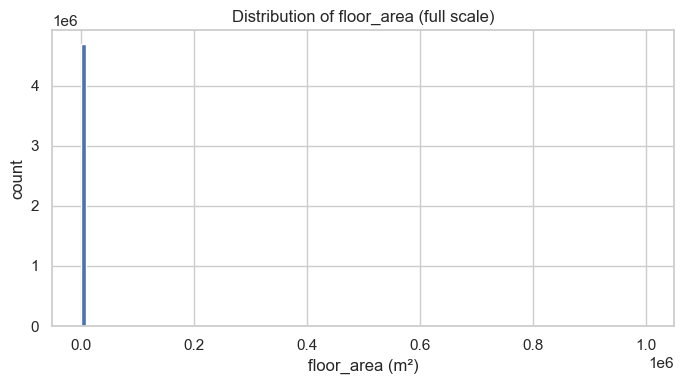

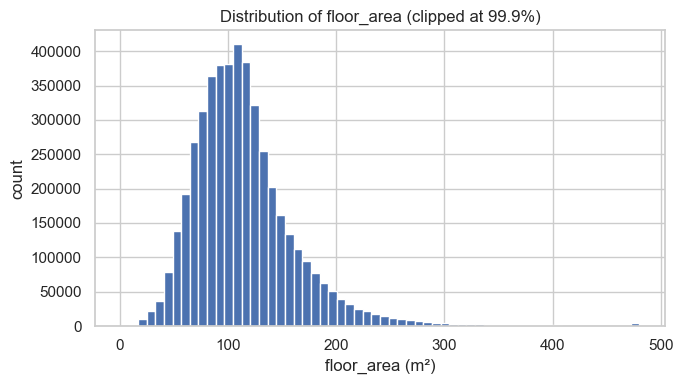

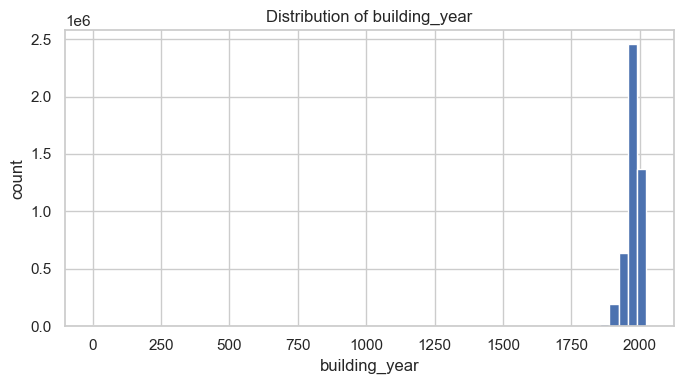

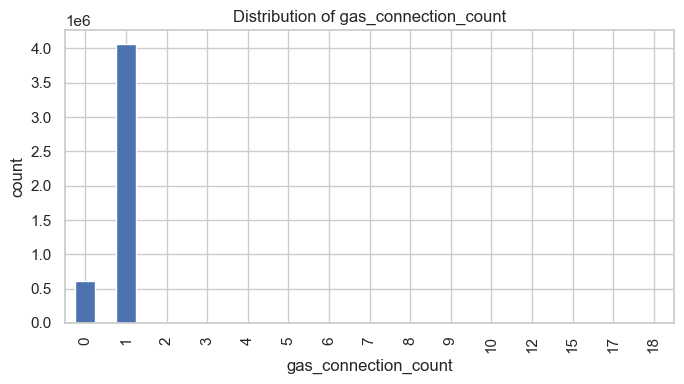

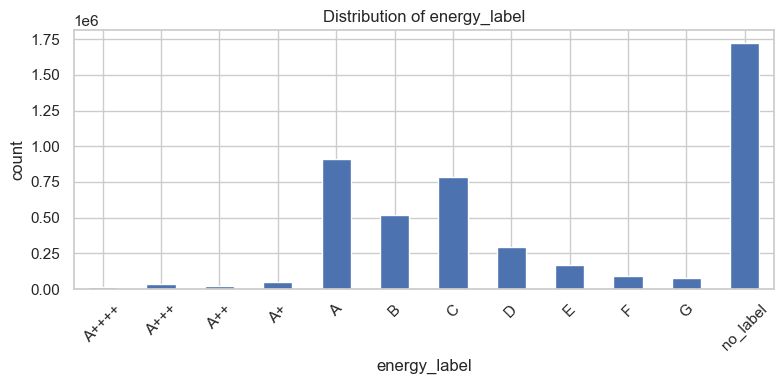

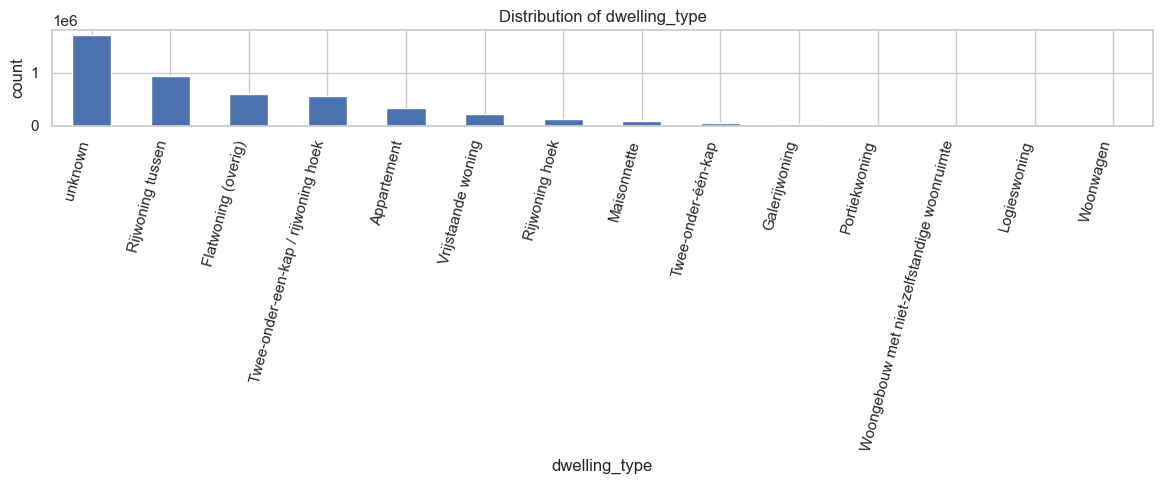

In [10]:
# ----------------------------
# 4.2A numeric distributions
# ----------------------------

# 1) floor_area: full scale
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["floor_area"].dropna(), bins=100)
plt.title("Distribution of floor_area (full scale)")
plt.xlabel("floor_area (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) floor_area: clipped view
upper_99 = df_dwelling["floor_area"].quantile(0.999)

plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["floor_area"].dropna().clip(upper=upper_99), bins=60)
plt.title("Distribution of floor_area (clipped at 99.9%)")
plt.xlabel("floor_area (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3) building_year
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["building_year"].dropna(), bins=60)
plt.title("Distribution of building_year")
plt.xlabel("building_year")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 4) gas_connection_count (discrete)
vc_gas = df_dwelling["gas_connection_count"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
vc_gas.plot(kind="bar")
plt.title("Distribution of gas_connection_count")
plt.xlabel("gas_connection_count")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# ----------------------------
# 4.2B categorical distributions
# ----------------------------

# energy_label
plt.figure(figsize=(8, 4))
df_dwelling["energy_label"].value_counts().reindex(label_order).plot(kind="bar")
plt.title("Distribution of energy_label")
plt.xlabel("energy_label")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# dwelling_type
plt.figure(figsize=(12, 5))
df_dwelling["dwelling_type"].value_counts().plot(kind="bar")
plt.title("Distribution of dwelling_type")
plt.xlabel("dwelling_type")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Interpretation of structural distributions

The distribution plots confirm several key structural properties of the dwelling dataset.

Floor area exhibits strong right-skewness, with most dwellings concentrated within a relatively narrow range and a small number of extreme values distorting the upper tail. Construction year is largely concentrated in the post-war period, with a small number of administrative artifacts (e.g. year = 0). Gas connection counts are heavily concentrated at values of 0 and 1, indicating that gas availability behaves effectively as a binary characteristic.

The categorical distributions show that energy labels are concentrated in mid-efficiency classes, while a substantial share of dwellings lacks a registered label. Dwelling type follows a realistic structural pattern but includes a large `unknown` category, reflecting incomplete classification in the source data.

These observations highlight the presence of skewness, extreme values, and category imbalances, which motivate the targeted structural diagnostics and cleaning steps performed in the next section.

### 4.3 Structural diagnostics

This subsection examines key structural properties of the dwelling-level dataset and applies transformations only when supported by clear empirical evidence.

The objective is to ensure that the structural variables used in later analysis are:

- consistent  
- interpretable  
- free from obvious artefacts  

The diagnostics focus on four aspects:

- 4.3A Gas connection structure (`gas_connection_count`)  
- 4.3B Rare housing type categories (`dwelling_type`)  
- 4.3C Floor area tail diagnostics and threshold decision (`floor_area`)  
- 4.3D Construction year diagnostics (`building_year`)  

Because energy variables are defined at **PC6 level (CBS averages per dwelling)**, all structural filtering decisions are applied at **PC6 level** to preserve consistency between structural composition and energy values.

### 4.3A Gas connection structure (`gas_connection_count`)

We examine the structural distribution of gas connections across dwellings.

The purpose of this analysis is to:

1. determine whether `gas_connection_count` behaves effectively as a binary variable  
2. assess variation within PC6 areas  
3. evaluate whether simplification improves interpretability  

This analysis focuses exclusively on the **structural variable**, since gas consumption is not available at dwelling level.

In [11]:
# ----------------------------
# 4.3A Gas connection diagnostics
# ----------------------------

# Step 1: Inspect overall distribution of gas connections
print("=== gas_connection_count distribution ===")
vc_gas = df_dwelling["gas_connection_count"].value_counts().sort_index()
display(vc_gas)

print("\nNumber of unique gas_connection_count values:")
print(df_dwelling["gas_connection_count"].nunique())

# Step 2: Check variation within PC6 areas
pc6_variation_gas = df_dwelling.groupby("postcode")["gas_connection_count"].nunique()

print("\nShare of PC6s with more than one unique gas_connection_count value:")
print((pc6_variation_gas > 1).mean())

print("\nDistribution of unique gas_connection_count values per PC6:")
display(pc6_variation_gas.value_counts().sort_index())

=== gas_connection_count distribution ===


gas_connection_count
0      613035
1     4059330
2       10498
3        2100
4         243
5          42
6           9
7          14
8           2
9           5
10          2
12          2
15          1
17          1
18          1
Name: count, dtype: int64


Number of unique gas_connection_count values:
15

Share of PC6s with more than one unique gas_connection_count value:
0.2200379746835443

Distribution of unique gas_connection_count values per PC6:


gas_connection_count
1    184851
2     46823
3      4741
4       542
5        38
6         3
7         1
8         1
Name: count, dtype: int64

In [12]:
# ----------------------------
# create binary gas connection indicator
# ----------------------------

df_dwelling["has_gas"] = df_dwelling["gas_connection_count"].fillna(0) > 0

print("share of dwellings with gas connection (has_gas=True):")
print(round(df_dwelling["has_gas"].mean(), 4))

share of dwellings with gas connection (has_gas=True):
0.8692


#### Interpretation and modelling decision

The distribution of `gas_connection_count` shows a very strong concentration at values **0 and 1**. The vast majority of dwellings have exactly one gas connection, while a smaller but still substantial group has no gas connection. Values above 1 exist but are extremely rare and represent only a negligible share of the dataset.

This confirms that the variable does not behave as a continuous quantity, but rather captures the **presence or absence of a gas connection**.

At PC6 level, approximately **22% of postcode areas exhibit variation** in gas connection counts across dwellings, while the majority of PC6 areas are structurally homogeneous. This indicates that mixed gas availability exists but is not dominant.

In total, **86.9% of dwellings have a gas connection**, while the remaining share corresponds to dwellings without gas.

Given this distribution, retaining the full numeric representation of `gas_connection_count` does not provide additional useful information. Instead, the structural characteristic is more clearly and robustly captured using a binary indicator.

Therefore, the variable is transformed into:

- `has_gas = True` if `gas_connection_count > 0`  
- `has_gas = False` if `gas_connection_count = 0`  

This transformation preserves the relevant structural information while improving interpretability and stability for subsequent analysis.

#### 4.3B Rare housing type categories (`woning_type`)

Very rare housing categories may create unstable estimates in later modelling stages.  
When PC6 compositions are computed, categories with extremely small sample sizes can produce noisy or unreliable shares.

To diagnose this, we first examine the structural characteristics and sample size of each housing type.

The objective of this step is to:

- understand structural differences between housing types
- detect extremely rare categories
- determine whether any categories should be removed from the modelling dataset

In [13]:
# ----------------------------
# 4.3B dwelling_type structural comparison
# ----------------------------

type_structure = (
    df_dwelling
    .groupby("dwelling_type")[["floor_area", "building_year"]]
    .agg(["mean", "median", "count"])
)

display(type_structure)

floor_area                  \
                                                   mean median    count   
dwelling_type                                                             
Appartement                                   73.671043   72.0   338795   
Flatwoning (overig)                           73.695672   72.0   595545   
Galerijwoning                                 67.273059   69.0    28221   
Logieswoning                                 106.320000   97.0       75   
Maisonnette                                   88.726991   86.0    86162   
Portiekwoning                                 69.015570   68.0     9698   
Rijwoning hoek                               110.925062  107.0   123983   
Rijwoning tussen                             109.885054  108.0   934218   
Twee-onder-een-kap / rijwoning hoek          128.670414  124.0   570946   
Twee-onder-één-kap                           137.241114  135.0    57757   
Vrijstaande woning                           190.894032  180.0   217057   
Woongebouw met niet-zelfstandige woonruimte   59.890244   33.0      164   
Woonwagen                                     96.125000   69.5        8   
unknown                                      129.772591  119.0  1722656   

                                            building_year                   
                                                     mean  median    count  
dwelling_type                                                               
Appartement                                   1971.905518  1974.0   338795  
Flatwoning (overig)                           1975.090576  1975.0   595545  
Galerijwoning                                 1982.381205  1980.0    28221  
Logieswoning                                  1973.866667  1976.0       75  
Maisonnette                                   1967.553399  1977.0    86162  
Portiekwoning                                 1964.425655  1962.0     9698  
Rijwoning hoek                                1972.427357  1974.0   123983  
Rijwoning tussen                              1976.700936  1978.0   934218  
Twee-onder-een-kap / rijwoning hoek           1979.740578  1981.0   570946  
Twee-onder-één-kap                            1975.983967  1977.0    57757  
Vrijstaande woning                            1979.397734  1988.0   217057  
Woongebouw met niet-zelfstandige woonruimte   1968.725610  1985.0      164  
Woonwagen                                     1727.625000  1987.0        8  
unknown                                       1962.756579  1977.0  1722656

In [14]:
# ----------------------------
# Diagnostic: PC6 affected by rare housing types
# ----------------------------

rare_types = [
    "Logieswoning",
    "Woongebouw met niet-zelfstandige woonruimte",
    "Woonwagen"
]

# PC6 that contain at least one rare type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["dwelling_type"].isin(rare_types),
    "postcode"
].unique()

n_pc6_with_rare = len(pc6_with_rare)
total_pc6 = df_dwelling["postcode"].nunique()

print("PC6 containing rare dwelling types:", n_pc6_with_rare)
print("Total PC6:", total_pc6)
print("Share of PC6 affected:", round(n_pc6_with_rare / total_pc6, 4))


# ----------------------------
# How many dwellings would be removed?
# ----------------------------

rows_in_pc6_with_rare = df_dwelling["postcode"].isin(pc6_with_rare).sum()
total_rows = len(df_dwelling)

print("\nDwellings located in those PC6:", rows_in_pc6_with_rare)
print("Total dwellings:", total_rows)
print("Share of dwellings affected:", round(rows_in_pc6_with_rare / total_rows, 4))


# ----------------------------
# How many rare dwellings themselves?
# ----------------------------

rare_rows = df_dwelling["dwelling_type"].isin(rare_types).sum()

print("\nRare dwelling rows only:", rare_rows)
print("Share of rare dwellings:", round(rare_rows / total_rows, 6))

PC6 containing rare dwelling types: 100
Total PC6: 237000
Share of PC6 affected: 0.0004

Dwellings located in those PC6: 2518
Total dwellings: 4685285
Share of dwellings affected: 0.0005

Rare dwelling rows only: 247
Share of rare dwellings: 5.3e-05


#### Final modelling decision

The structural comparison and diagnostics confirm that three housing types are extremely rare within the national dataset:

- **Logieswoning**  
- **Woongebouw met niet-zelfstandige woonruimte**  
- **Woonwagen**

These categories represent only **247 dwellings (≈0.005% of the dataset)** and occur across **100 PC6 areas (≈0.04% of all postcode areas)**. In total, the affected PC6 areas contain **2,518 dwellings (≈0.05% of the dataset)**.

This confirms that the presence of these categories has a **negligible impact on the overall structure of the housing stock**.

Because the energy variables in the dataset are defined at **PC6 level**, removing only individual dwelling observations would create an inconsistency between the structural composition of a postcode area and its associated energy values.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing these rare dwelling types are removed from the modelling dataset**.

Given the extremely small share of affected PC6 areas and dwellings, this exclusion does not materially affect the representativeness of the Dutch residential housing stock.

The analysis proceeds with the remaining PC6 areas, which represent virtually the entire residential building stock.

In [15]:
# ----------------------------
# remove PC6 areas containing extremely rare housing types
# ----------------------------

# identify PC6 that contain any rare dwelling type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["dwelling_type"].isin(rare_types),
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_rare)
].copy()

print("Remaining PC6:", df_dwelling["postcode"].nunique())
print("Remaining dwellings:", len(df_dwelling))

print("\nRemaining dwelling types:")
print(df_dwelling["dwelling_type"].value_counts())

Remaining PC6: 236900
Remaining dwellings: 4682767

Remaining dwelling types:
dwelling_type
unknown                                1721617
Rijwoning tussen                        934037
Flatwoning (overig)                     595230
Twee-onder-een-kap / rijwoning hoek     570865
Appartement                             338477
Vrijstaande woning                      216818
Rijwoning hoek                          123954
Maisonnette                              86143
Twee-onder-één-kap                       57741
Galerijwoning                            28203
Portiekwoning                             9682
Name: count, dtype: int64


#### Post-filtering dataset summary

After removing PC6 areas containing extremely rare dwelling types, the dataset is only marginally reduced.

- Remaining PC6 areas: **236,900**  
- Remaining dwelling observations: **4,682,767**  

The distribution of dwelling types remains effectively unchanged, confirming that the removed categories had a negligible impact on the overall structure of the housing stock.

This further supports the validity of the filtering step, as it improves consistency without affecting representativeness.

#### 4.3C Floor area tail diagnostics and threshold decision (`floor_area`)

The floor area distribution contains extreme values that strongly distort scale.  
We treat percentiles as diagnostic evidence, and we choose thresholds using a hybrid approach:

- Percentiles to understand where the bulk of the housing stock lies  
- Direct inspection to detect sentinel or implausible magnitudes  
- Candidate threshold testing to quantify how much data is affected  

Based on the diagnostics in Sections 4.3C1–4.3C5, floor area limits are defined to remove implausible observations while preserving realistic housing variability.

In [16]:
# 4.3C1 inspect upper tail values directly (structural plausibility check)

# --- extremely large values (>2000 m²)
extreme_threshold = 2000

extreme_values = (
    df_dwelling[df_dwelling["floor_area"] > extreme_threshold]["floor_area"]
    .value_counts()
    .head(20)
)

print(f"most frequent floor area values above {extreme_threshold} m²:")
display(extreme_values)


# --- large but potentially plausible band (1000–2000 m²)
large_band = (
    df_dwelling[
        (df_dwelling["floor_area"] > 1000) &
        (df_dwelling["floor_area"] <= 2000)
    ]["floor_area"]
    .value_counts()
    .head(20)
)

print("most frequent floor area values between 1000 and 2000 m²:")
display(large_band)


# --- diagnostic summary
n_above_1000 = (df_dwelling["floor_area"] > 1000).sum()
share_above_1000 = 100 * n_above_1000 / len(df_dwelling)

print(f"total dwellings above 1000 m²: {n_above_1000}")
print(f"share of dataset above 1000 m²: {share_above_1000:.6f}%")

most frequent floor area values above 2000 m²:


floor_area
999999.0    3
2003.0      3
99999.0     2
2993.0      2
6745.0      2
13388.0     2
110171.0    2
6214.0      1
9316.0      1
7440.0      1
117615.0    1
9288.0      1
3298.0      1
4920.0      1
4518.0      1
6191.0      1
2465.0      1
2335.0      1
2378.0      1
2011.0      1
Name: count, dtype: int64

most frequent floor area values between 1000 and 2000 m²:


floor_area
1009.0    3
1172.0    3
1019.0    3
1135.0    3
1128.0    3
1092.0    3
1081.0    3
1021.0    2
1031.0    2
1051.0    2
1010.0    2
1496.0    2
1138.0    2
1003.0    2
1244.0    2
1098.0    2
1372.0    2
1221.0    2
1490.0    2
1211.0    2
Name: count, dtype: int64

total dwellings above 1000 m²: 352
share of dataset above 1000 m²: 0.007517%


In [17]:
# 4.3C2 candidate upper limits and removal shares

candidate_upper_limits = [800, 1000, 1500, 2000]

print("removal share for candidate upper limits:")
for limit in candidate_upper_limits:
    removed_share = (df_dwelling["floor_area"] > limit).mean() * 100
    print(f"upper limit {limit} m² → {removed_share:.5f}% removed")

removal share for candidate upper limits:
upper limit 800 m² → 0.01416% removed
upper limit 1000 m² → 0.00752% removed
upper limit 1500 m² → 0.00269% removed
upper limit 2000 m² → 0.00156% removed


In [18]:
# 4.3C3 inspect lower tail values directly (structural plausibility check)

# --- extremely small values (<10 m²)
extreme_lower_threshold = 10

extreme_lower_values = (
    df_dwelling[df_dwelling["floor_area"] < extreme_lower_threshold]["floor_area"]
    .value_counts()
)

print(f"most frequent floor area values below {extreme_lower_threshold} m²:")
display(extreme_lower_values)


# --- small but potentially plausible band (10–20 m²)
small_band = (
    df_dwelling[
        (df_dwelling["floor_area"] >= 10) &
        (df_dwelling["floor_area"] < 20)
    ]["floor_area"]
    .value_counts()
)

print("most frequent floor area values between 10 and 20 m²:")
display(small_band)


# --- diagnostic summary
n_below_10 = (df_dwelling["floor_area"] < 10).sum()
share_below_10 = 100 * n_below_10 / len(df_dwelling)

print(f"total dwellings below 10 m²: {n_below_10}")
print(f"share of dataset below 10 m²: {share_below_10:.6f}%")

most frequent floor area values below 10 m²:


floor_area
1.0    139
9.0     12
5.0      3
8.0      2
2.0      1
7.0      1
Name: count, dtype: int64

most frequent floor area values between 10 and 20 m²:


floor_area
19.0    1410
18.0     708
15.0     664
17.0     414
16.0     301
14.0      73
13.0      55
11.0      45
12.0      31
10.0      23
Name: count, dtype: int64

total dwellings below 10 m²: 158
share of dataset below 10 m²: 0.003374%


In [19]:
# 4.3C4 candidate lower limits and removal shares

candidate_lower_limits = [5, 10, 15, 20]

print("removal share for candidate lower limits:")
for limit in candidate_lower_limits:
    removed_share = (df_dwelling["floor_area"] < limit).mean() * 100
    print(f"lower limit {limit} m² → {removed_share:.6f}% removed")

removal share for candidate lower limits:
lower limit 5 m² → 0.002990% removed
lower limit 10 m² → 0.003374% removed
lower limit 15 m² → 0.008222% removed
lower limit 20 m² → 0.082900% removed


In [20]:
# ----------------------------
# 4.3C5 diagnostic: effect of removing whole PC6 vs only outlier rows
# ----------------------------

lower_limit = 10
upper_limit = 1000

area_outlier_mask = (
    (df_dwelling["floor_area"] < lower_limit) |
    (df_dwelling["floor_area"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[area_outlier_mask, "postcode"].unique()

n_pc6_total = df_dwelling["postcode"].nunique()
n_rows_total = len(df_dwelling)

n_outlier_rows = area_outlier_mask.sum()
share_outlier_rows = n_outlier_rows / n_rows_total

n_pc6_with_outliers = len(pc6_with_area_outliers)
share_pc6_with_outliers = n_pc6_with_outliers / n_pc6_total

rows_in_affected_pc6 = df_dwelling["postcode"].isin(pc6_with_area_outliers).sum()
share_rows_in_affected_pc6 = rows_in_affected_pc6 / n_rows_total

print("=== Floor area outlier diagnostic ===")
print(f"Outlier dwellings only: {n_outlier_rows}")
print(f"Share of outlier dwellings: {share_outlier_rows:.6%}")

print(f"\nPC6 containing at least one area outlier: {n_pc6_with_outliers}")
print(f"Share of PC6 affected: {share_pc6_with_outliers:.6%}")

print(f"\nDwellings located in those affected PC6: {rows_in_affected_pc6}")
print(f"Share of dwellings affected if whole PC6 were removed: {share_rows_in_affected_pc6:.6%}")

=== Floor area outlier diagnostic ===
Outlier dwellings only: 510
Share of outlier dwellings: 0.010891%

PC6 containing at least one area outlier: 416
Share of PC6 affected: 0.175602%

Dwellings located in those affected PC6: 10857
Share of dwellings affected if whole PC6 were removed: 0.231850%


#### Final floor area threshold decision

The diagnostic analysis of the floor area distribution reveals the presence of extreme and implausible values in both tails, while the vast majority of dwellings lie within a well-defined central range.

Inspection of the upper tail shows the existence of clear sentinel and erroneous values, such as **99,999 m² and 999,999 m²**, alongside highly implausible dwelling sizes exceeding several thousand square meters. At the same time, values between **1000 and 2000 m²** are extremely sparse and do not represent a meaningful segment of the residential building stock. In total, only **352 dwellings (0.0075%)** exceed 1000 m².

Lower-tail inspection identifies a small number of dwellings with floor areas below **10 m²**, including repeated values such as **1 m²**, which are physically implausible for residential units and likely reflect data entry errors or misclassification. These observations account for only **158 dwellings (0.0034%)** of the dataset.

Evaluation of candidate thresholds confirms that removing observations outside the range **[10, 1000] m²** affects only a negligible fraction of the data. However, when accounting for the PC6 structure of the dataset, removing individual outlier dwellings would create inconsistencies between the structural composition of a postcode area and its associated energy values.

A PC6-level diagnostic shows that while only **510 dwellings (0.011%)** are direct outliers, they are distributed across **416 PC6 areas (0.18%)**, affecting a total of **10,857 dwellings (0.23%)** if entire postcode areas are removed.

To preserve consistency between structural variables and PC6-level energy data, the filtering is therefore applied at postcode level.

The adopted structural limits are:

- **Lower limit:** 10 m²  
- **Upper limit:** 1000 m²  

All PC6 areas containing dwellings outside this range are excluded from the dataset. This approach ensures structural consistency while removing only a very small fraction of the overall sample, and does not materially affect the representation of the Dutch residential housing stock.

In [21]:
# 4.3C6 final structural thresholds (PC6-consistent filtering)

lower_limit = 10
upper_limit = 1000

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one floor-area outlier
area_outlier_mask = (
    (df_dwelling["floor_area"] < lower_limit) |
    (df_dwelling["floor_area"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[
    area_outlier_mask, "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_area_outliers)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent floor area filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent floor area filtering
remaining PC6: 236484
remaining rows: 4671910

PC6 removed: 416
dwellings removed: 10857

share of PC6 removed: 0.17560%
share of dwellings removed: 0.23185%


#### Dataset after floor area filtering

After applying the PC6-consistent floor area thresholds, the dataset remains largely unchanged in size, confirming that extreme values are rare and concentrated in a small number of postcode areas.

A total of **416 PC6 areas (0.176%)** are removed, corresponding to **10,857 dwellings (0.232%)**. The resulting dataset contains:

- **236,484 PC6 areas**
- **4,671,910 dwellings**

This limited reduction indicates that the applied thresholds effectively remove implausible observations while preserving the overall structure and representativeness of the Dutch residential housing stock.

#### 4.3D Construction year diagnostics and threshold decision (`pand_bouwjaar`)

Construction year is retained during minimal cleaning so that lower-tail values can be diagnosed before applying a structural threshold.

We inspect the lower tail of `pand_bouwjaar` to identify clearly implausible or administrative values and then apply a final lower bound supported by the observed distribution.

In [22]:
# 4.3D1 construction year diagnostics

print("minimum building_year:", df_dwelling["building_year"].min())
print(df_dwelling["building_year"].describe(percentiles=[0.001, 0.01, 0.05]))

print("most frequent building_year values below 1700:")
display(
    df_dwelling.loc[df_dwelling["building_year"] < 1700, "building_year"]
    .value_counts()
    .head(20)
)

print("Construction year values between 1 and 999:")

display(
    df_dwelling.loc[
        (df_dwelling["building_year"] >= 1) &
        (df_dwelling["building_year"] < 1000),
        "building_year"
    ]
    .value_counts()
    .sort_index()
)

minimum building_year: 0
count    4.671910e+06
mean     1.971264e+03
std      9.596176e+01
min      0.000000e+00
0.1%     0.000000e+00
1%       1.897000e+03
5%       1.923000e+03
max      2.024000e+03
Name: building_year, dtype: float64
most frequent building_year values below 1700:


building_year
0       10101
1650      258
1600       95
1681       75
1450       70
1660       69
1625       54
1592       51
1631       51
1666       36
1675       34
1680       30
1005       29
1350       28
1670       26
1690       26
1659       24
1671       23
1616       22
1683       21
Name: count, dtype: int64

Construction year values between 1 and 999:


Series([], Name: count, dtype: int64)

#### Final construction year threshold decision

The diagnostic analysis of the construction year variable reveals a clear distinction between valid historical values and administrative artifacts.

The lower tail is dominated by entries with **building_year = 0**, which appear **10,101 times** and represent placeholder or missing values rather than actual construction years. These values do not correspond to real buildings and cannot be interpreted meaningfully.

In contrast, all other low construction years correspond to plausible historical buildings (e.g. 1400–1700 range), reflecting the presence of older structures in the Dutch housing stock. Importantly, no values are observed in the range **1–999**, confirming that the only problematic lower-tail value is the administrative zero.

Given this structure, a minimal and data-consistent threshold is applied:

- **Lower limit:** 1 (i.e. remove only `building_year = 0`)

This approach ensures that only clearly invalid entries are excluded, while preserving the full range of historically valid construction years. The resulting dataset maintains both accuracy and completeness in representing the temporal structure of the housing stock.

In [23]:
# 4.3D2 final construction year threshold 

year_lower_limit = 1

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one invalid construction year
pc6_with_invalid_building_year = df_dwelling.loc[
    df_dwelling["building_year"] < year_lower_limit,
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_invalid_building_year)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent construction year filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent construction year filtering
remaining PC6: 234882
remaining rows: 4627049

PC6 removed: 1602
dwellings removed: 44861

share of PC6 removed: 0.67742%
share of dwellings removed: 0.96023%


#### Dataset after construction year filtering

After removing PC6 areas containing invalid construction year values (`building_year = 0`), the dataset remains largely unchanged in overall structure, although the impact is slightly larger than in previous filtering steps.

A total of **1,602 PC6 areas (0.677%)** are removed, corresponding to **44,861 dwellings (0.960%)**. The resulting dataset contains:

- **234,882 PC6 areas**
- **4,627,049 dwellings**

This PC6-consistent filtering step ensures that all retained postcode areas contain valid construction year values, while preserving the structural integrity and representativeness of the Dutch residential housing stock.

### 4.4 Correlation analysis between dwelling features

This section quantifies statistical relationships between dwelling characteristics, building directly on the previous steps:

- **4.1 Descriptive statistics** confirmed that each feature has meaningful variation.
- **4.2 Distribution visualization** revealed skewness, heavy tails, and category imbalance.
- **4.3 Structural diagnostics** handled artifacts (especially in `floor_area`) and clarified how variables behave. In particular, the gas connection variable was shown to behave largely as a binary structural characteristic, so the derived indicator `has_gas` is used in the correlation analysis that follows.

Because the dataset includes mixed variable types, no single association measure is appropriate for all variable pairs. Therefore, associations are evaluated using measures matched to variable type:

- **Spearman correlation** for numeric-numeric relationships
- **Cramér’s V** for categorical-categorical relationships
- **Correlation ratio (η)** for categorical-numeric relationships

After evaluating each pair type separately, a **mixed-type association matrix** is constructed to provide a unified overview of all relationships between dwelling features.

Finally, a **Variance Inflation Factor (VIF)** diagnostic is performed to detect multicollinearity within the predictor set used later in regression modelling.

#### 4.4A Prepare analysis variables

The association analysis uses a set of structural dwelling variables describing building characteristics and energy-related attributes.

Numeric variables:

- `floor_area` – dwelling floor area  
- `building_year` – construction year  

Categorical variables:

- `energy_label` – energy performance label  
- `dwelling_type` – dwelling type  
- `has_gas` – indicator of gas connection presence  

Energy labels are treated as categorical variables, including the category `no_label`, which represents dwellings without a registered energy label.

The variable `has_gas` is derived from `gas_connection_count` and used as a binary structural indicator.

In [24]:
# ----------------------------
# 4.4A Prepare analysis variables
# ----------------------------

# numeric features used in association analysis
num_cols = ["floor_area", "building_year"]

# categorical features used in association analysis
cat_cols = ["energy_label", "dwelling_type", "has_gas"]

# ensure has_gas exists
if "has_gas" not in df_dwelling.columns:
    df_dwelling["has_gas"] = df_dwelling["gas_connection_count"].fillna(0) > 0

# ensure energy_label remains an explicit categorical variable
label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energy_label"] = pd.Categorical(
    df_dwelling["energy_label"],
    categories=label_order,
    ordered=False
)

# quick sanity checks
print("sanity checks")
print("rows:", len(df_dwelling))
print("unique pc6:", df_dwelling["postcode"].nunique())
print("share has_gas = true:", round(df_dwelling["has_gas"].mean(), 4))
print("share energy_label == 'no_label':",
      round((df_dwelling["energy_label"] == "no_label").mean(), 4))

print("\nenergy_label counts:")
display(df_dwelling["energy_label"].value_counts(dropna=False).sort_index())

sanity checks
rows: 4627049
unique pc6: 234882
share has_gas = true: 0.8733
share energy_label == 'no_label': 0.3662

energy_label counts:


energy_label
A++++          9896
A+++          32428
A++           20859
A+            49444
A            897072
B            516095
C            778247
D            293930
E            168037
F             92510
G             74011
no_label    1694520
Name: count, dtype: int64

#### Data consistency check

After structural diagnostics and PC6-consistent filtering, the dataset contains:

- **4,627,049 dwellings**
- **234,882 PC6 areas**

The gas connection indicator shows that **87.3% of dwellings have a gas connection**, confirming the dominance of gas-based heating in the current housing stock.

The energy label distribution reveals that **36.6% of dwellings do not have a registered energy label (`no_label`)**, indicating a substantial share of missing label information. This reinforces the importance of treating energy labels as categorical variables with an explicit `no_label` category.

Overall, the dataset remains large, structurally consistent, and suitable for correlation analysis.

#### 4.4B Numeric structural correlations: Spearman correlation

Relationships between numeric dwelling characteristics are evaluated using **Spearman rank correlation**.

Spearman correlation measures how strongly two variables move together in a **monotonic way**, meaning that as one variable increases, the other tends to either consistently increase or decrease.

Instead of using the raw values, Spearman correlation is based on the **rank ordering** of the data. This means that each observation is replaced by its position when the data are sorted.

For example, the smallest value receives rank 1, the second smallest rank 2, and so on, making the measure more robust to skewed distributions and extreme values.

Formally, Spearman correlation is defined as the Pearson correlation between the ranked variables:

$$
\rho_s = Corr(rank(X), rank(Y))
$$

where:

- $rank(X)$ and $rank(Y)$ are the ranks of the observations  
- $\rho_s$ ranges from **-1** to **1**  

Interpretation:

- **+1** → perfect increasing relationship  
- **-1** → perfect decreasing relationship  
- **0** → no monotonic relationship  

The analysis focuses on:

- `floor_area` – dwelling floor area  
- `building_year` – construction year  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

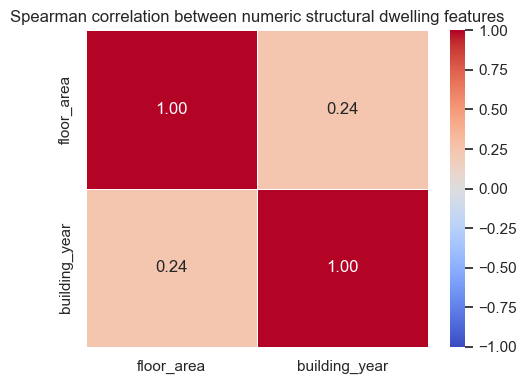

In [25]:
# ----------------------------
# 4.4B Spearman correlation heatmap
# ----------------------------

spearman_cols = ["floor_area", "building_year"]

corr_spearman = df_dwelling[spearman_cols].corr(method="spearman")

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Spearman correlation between numeric structural dwelling features")
plt.tight_layout()
plt.show()

#### 4.4C Categorical-categorical associations: Cramér’s V

Associations between categorical dwelling characteristics are measured using **Cramér’s V**.

Cramér’s V measures how strongly two categorical variables are related by comparing the **observed distribution of combinations** to what would be expected if the variables were independent.

For example, it evaluates whether certain dwelling types appear more frequently with specific energy labels than would occur by chance.

The measure is based on the chi-squared statistic computed from a contingency table, which summarizes how often each combination of categories occurs.

It is defined as:

$$
V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}}
$$

where:

- $\chi^2$ measures how far the observed category combinations deviate from independence  
- $n$ is the total number of observations  
- $r$ and $c$ are the number of categories in each variable  

Cramér’s V ranges from **0** to **1**:

- **0** indicates no association (variables are independent)  
- **1** indicates perfect association  

The categorical variables considered are:

- `energy_label` – energy performance label  
- `dwelling_type` – dwelling type  
- `has_gas` – gas connection indicator  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

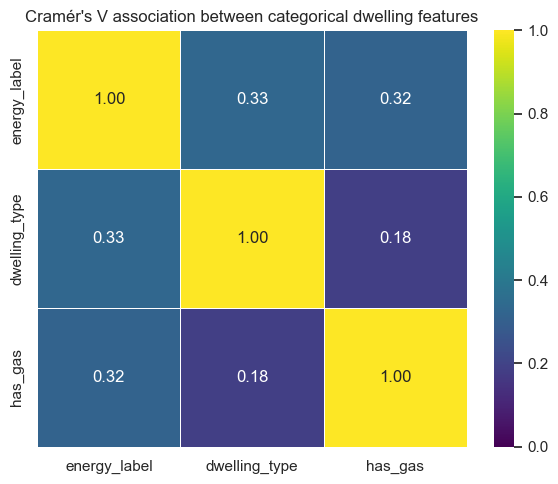

In [26]:
# ----------------------------
# 4.4C Cramér's V association heatmap
# ----------------------------

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Compute Cramér's V statistic for categorical-categorical association.
    """
    contingency_table = pd.crosstab(x, y)

    if contingency_table.size == 0:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    denom = min(r - 1, k - 1)

    if denom <= 0 or n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / denom)


cat_for_v = ["energy_label", "dwelling_type", "has_gas"]

V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)

for i in cat_for_v:
    for j in cat_for_v:
        if i == j:
            V.loc[i, j] = 1.0
        else:
            V.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

plt.figure(figsize=(6, 5))
sns.heatmap(
    V,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Cramér's V association between categorical dwelling features")
plt.tight_layout()
plt.show()

#### 4.4D Categorical-numeric associations: correlation ratio η

Relationships between categorical and numeric variables are evaluated using the **correlation ratio (η)**.

The correlation ratio measures how strongly a numeric variable differs across categories of a categorical variable.

In practical terms, it evaluates whether the **average value of a numeric variable changes systematically across groups**.

For example, it assesses whether different dwelling types have systematically different average floor areas.

The measure compares:

- variation **between category means**  
- relative to the **total variation in the data**

It is defined as:

$$
\eta = \sqrt{\frac{\sum_k n_k(\bar{y}_k - \bar{y})^2}{\sum_i (y_i - \bar{y})^2}}
$$

where:

- $k$ indexes the categories  
- $n_k$ is the number of observations in category $k$  
- $\bar{y}_k$ is the mean within category $k$  
- $\bar{y}$ is the overall mean  
- $y_i$ are individual observations  

Interpretation:

- **0** → category does not explain variation in the numeric variable  
- **1** → category perfectly determines the numeric variable  

In this analysis, it is used to evaluate how:

- `dwelling_type`  
- `energy_label`  
- `has_gas`  

relate to:

- `floor_area`  
- `building_year`  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

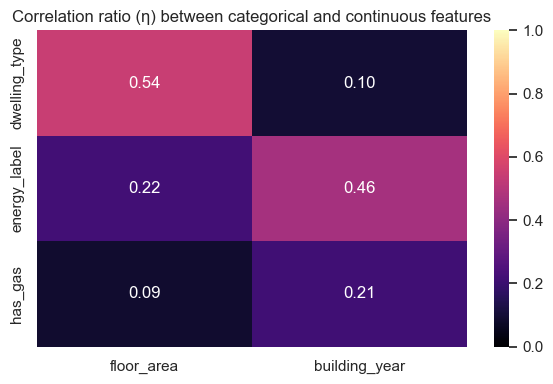

In [27]:
# ----------------------------
# 4.4D Correlation ratio (η) heatmap
# ----------------------------

def correlation_ratio(categories, measurements):
    """
    Compute correlation ratio (η) for categorical-continuous association.
    """
    valid = pd.notna(categories) & pd.notna(measurements)
    categories = pd.Series(categories)[valid]
    measurements = pd.Series(measurements)[valid].astype(float)

    if len(measurements) == 0:
        return np.nan

    codes, uniques = pd.factorize(categories)
    cat_num = len(uniques)

    if cat_num <= 1:
        return np.nan

    y_avg = np.zeros(cat_num)
    n = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[codes == i]
        n[i] = len(cat_measures)
        if len(cat_measures) > 0:
            y_avg[i] = np.mean(cat_measures)

    y_total = np.sum(y_avg * n) / np.sum(n)

    numerator = np.sum(n * (y_avg - y_total) ** 2)
    denominator = np.sum((measurements - y_total) ** 2)

    if denominator == 0:
        return np.nan

    return np.sqrt(numerator / denominator)


cont_vars = ["floor_area", "building_year"]
cat_vars = ["dwelling_type", "energy_label", "has_gas"]

eta_matrix = pd.DataFrame(index=cat_vars, columns=cont_vars)

for cat in cat_vars:
    for cont in cont_vars:
        eta_matrix.loc[cat, cont] = correlation_ratio(
            df_dwelling[cat],
            df_dwelling[cont]
        )

eta_matrix = eta_matrix.astype(float)

plt.figure(figsize=(6, 4))
sns.heatmap(
    eta_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    vmin=0,
    vmax=1
)
plt.title("Correlation ratio (η) between categorical and continuous features")
plt.tight_layout()
plt.show()

#### 4.4E Mixed association matrix

To provide a consolidated overview of dependencies between all dwelling characteristics, a mixed-type association matrix is constructed.

Different association measures are applied depending on the variable pair:

- **Spearman correlation** for numeric–numeric relationships  
- **Cramér’s V** for categorical–categorical relationships  
- **Correlation ratio (η)** for categorical–numeric relationships  

Because different statistics are used for different variable combinations, the resulting matrix does **not represent a single unified correlation coefficient**, but rather a collection of appropriate association measures.

The matrix therefore serves as an **exploratory diagnostic tool** to identify potentially strong dependencies between structural dwelling variables.

To avoid redundancy, detailed numerical outputs are not shown separately in previous sections, as all associations are consolidated in the matrix below.

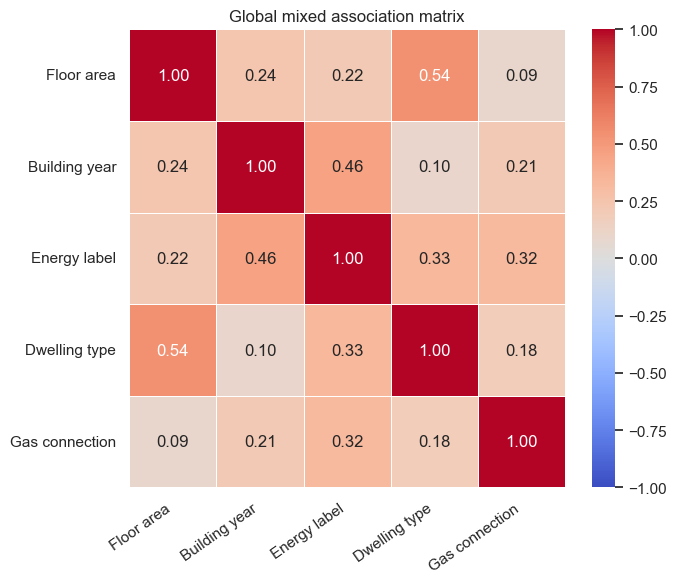

In [28]:
# ----------------------------
# 4.4E Mixed association matrix
# ----------------------------

num_vars = ["floor_area", "building_year"]
cat_vars = ["energy_label", "dwelling_type", "has_gas"]

all_vars = num_vars + cat_vars

mixed_matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for i in all_vars:
    for j in all_vars:

        if i == j:
            mixed_matrix.loc[i, j] = 1.0

        elif i in num_vars and j in num_vars:
            mixed_matrix.loc[i, j] = df_dwelling[[i, j]].corr(method="spearman").iloc[0, 1]

        elif i in cat_vars and j in cat_vars:
            mixed_matrix.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

        else:
            cat_var = i if i in cat_vars else j
            cont_var = j if i in cat_vars else i
            mixed_matrix.loc[i, j] = correlation_ratio(
                df_dwelling[cat_var],
                df_dwelling[cont_var]
            )

label_map = {
    "floor_area": "Floor area",
    "building_year": "Building year",
    "energy_label": "Energy label",
    "dwelling_type": "Dwelling type",
    "has_gas": "Gas connection"
}

mixed_matrix_plot = mixed_matrix.rename(index=label_map, columns=label_map)

plt.figure(figsize=(7, 6))
sns.heatmap(
    mixed_matrix_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Global mixed association matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation of structural associations

The mixed association matrix summarizes the strength of relationships between structural dwelling characteristics using appropriate measures for each variable type.

The strongest association is observed between **floor area and dwelling type (0.54)**, indicating that housing typology is the primary determinant of dwelling size. This reflects clear structural differences between dwelling categories, such as apartments and detached houses.

A second strong relationship is found between **building year and energy label (0.46)**, suggesting that energy performance is closely linked to the age of the building stock. Newer buildings tend to exhibit higher energy efficiency, while older buildings are more likely to have lower energy labels.

Moderate associations are observed between **energy label and dwelling type (0.33)** and between **energy label and gas connection (0.32)**. These relationships indicate that energy performance is influenced both by building characteristics and by infrastructure availability.

The association between **building year and gas connection (0.21)** suggests a gradual structural transition in heating systems over time, while the relationship between **dwelling type and gas connection (0.18)** remains relatively weak.

Finally, the association between **floor area and gas connection (0.09)** is very low, indicating that gas availability is largely independent of dwelling size.

Overall, the results show that while meaningful relationships exist between structural variables, no pair exhibits extremely high association. This indicates that the variables capture **complementary dimensions** of the housing stock rather than redundant information.

Because the matrix combines different association measures (Spearman correlation, Cramér’s V, and correlation ratio η), the values should be interpreted as **relative indicators of association strength** rather than directly comparable coefficients within a single statistical scale.

## 5️⃣ PC6-level structural composition and energy analysis

The previous chapter examined structural dwelling characteristics at dwelling level and evaluated the internal relationships between these variables.

The next step is to move from the **dwelling level** to the **PC6 level**, since the final modelling stage is based on postcode areas rather than individual dwellings.

This requires constructing a new dataset with **one row per PC6**, where:

- dwelling-level structural information is aggregated into postcode-level composition variables
- CBS energy variables are represented consistently at PC6 level
- socioeconomic and housing-context variables are merged with the structural composition data

The workflow proceeds in structured steps:

1. Examine within-PC6 structural dispersion  
2. Construct a clean PC6 base dataset  
3. Examine PC6 energy scaling as a diagnostic  
4. Compute PC6 structural composition variables  
5. Construct average per-dwelling PC6 energy indicators  
6. Analyse associations between PC6 composition and energy intensity

### 5.1 Within-PC6 structural dispersion

Before aggregating dwelling-level variables to postcode level, it is useful to examine how heterogeneous dwellings are within each PC6 area. If dwellings inside a postcode area are structurally homogeneous, postcode-level averages provide a reliable representation of the housing stock. If large internal variation exists, aggregation may hide important structural differences.

To evaluate this, we measure the **coefficient of variation (CV)** of key dwelling characteristics within each PC6. The coefficient of variation is defined as:

$$
CV = \frac{\sigma}{\mu}
$$

where:

- $\sigma$ is the standard deviation within a PC6  
- $\mu$ is the mean value within the PC6  

The CV measures **relative dispersion**, meaning the amount of variation compared to the typical level of the variable. For example:

- CV = 0.10 means variation equals about 10% of the mean  
- CV = 0.25 means variation equals about 25% of the mean  

This metric is useful because it allows dispersion to be compared across variables with different units and scales.

The analysis focuses on two structural dwelling characteristics:

- `floor_area` — dwelling floor area  
- `building_year` — construction year  

For each PC6 area, the coefficient of variation is computed and the distribution of these values is examined across postcode areas.

Number of PC6 areas: 234882

Summary statistics of within-PC6 dispersion (Coefficient of Variation):


,cv_floor_area,cv_building_year
count,234880.000000,234880.000000
mean,0.170170,0.002270
std,0.138666,0.005814
min,0.000000,0.000000
1%,0.000000,0.000000
5%,0.000000,0.000000
25%,0.073119,0.000000
50%,0.141118,0.000000
75%,0.234315,0.001143
95%,0.423324,0.013845


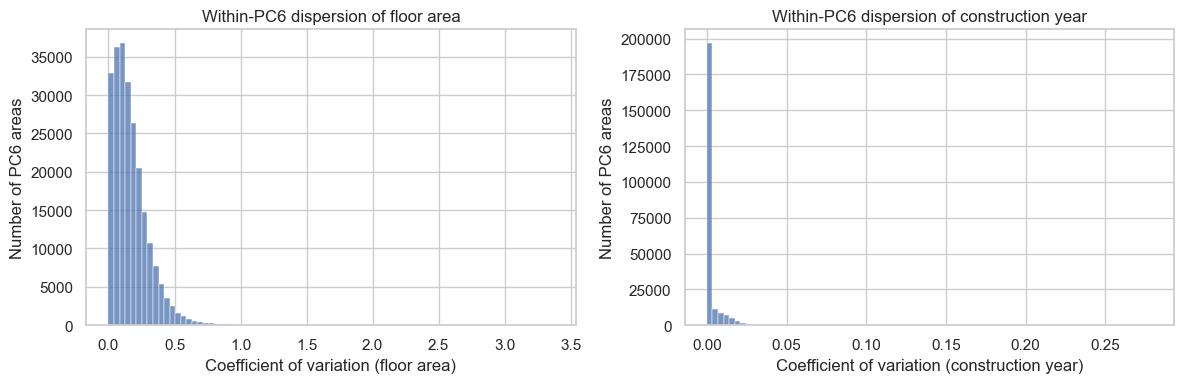

In [29]:
# ----------------------------
# 5.1 Within-PC6 structural dispersion (Coefficient of Variation)
# ----------------------------

# variables of interest
dispersion_vars = ["floor_area", "building_year"]

# compute mean and standard deviation within each PC6
pc6_mean = df_dwelling.groupby("postcode")[dispersion_vars].mean()
pc6_std = df_dwelling.groupby("postcode")[dispersion_vars].std()

# compute coefficient of variation
pc6_cv = pd.DataFrame({
    "cv_floor_area": pc6_std["floor_area"] / pc6_mean["floor_area"],
    "cv_building_year": pc6_std["building_year"] / pc6_mean["building_year"]
})

print("Number of PC6 areas:", len(pc6_cv))

print("\nSummary statistics of within-PC6 dispersion (Coefficient of Variation):")
display(
    pc6_cv.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

# ----------------------------
# visualization
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(pc6_cv["cv_floor_area"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("Within-PC6 dispersion of floor area")
axes[0].set_xlabel("Coefficient of variation (floor area)")
axes[0].set_ylabel("Number of PC6 areas")

sns.histplot(pc6_cv["cv_building_year"].dropna(), bins=80, ax=axes[1])
axes[1].set_title("Within-PC6 dispersion of construction year")
axes[1].set_xlabel("Coefficient of variation (construction year)")
axes[1].set_ylabel("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Interpretation

The coefficient of variation indicates that postcode areas exhibit **moderate internal variation in dwelling size but extremely low variation in construction year**.

For floor area, the median coefficient of variation is approximately **0.14**, meaning that the standard deviation of dwelling size within a typical PC6 area is about **14% of the mean dwelling size**. The interquartile range (0.07–0.23) confirms that most postcode areas contain dwellings of broadly similar size. However, the right tail of the distribution extends beyond **0.4**, indicating that a small number of PC6 areas contain a more heterogeneous mix of dwelling sizes.

In contrast, construction year shows **negligible dispersion within PC6 areas**. The median coefficient of variation is **0**, and even at the 75th percentile the value remains extremely small (≈0.001). This indicates that most postcode areas consist of dwellings built within the same development period. Only a very small fraction of PC6 areas exhibit noticeable variation in construction year.

Overall, these results suggest that:

- PC6 areas are **structurally homogeneous in terms of construction period**
- PC6 areas are **moderately homogeneous in terms of dwelling size**

This supports the use of postcode-level averages such as:

- `mean_oppervlakte`
- `mean_bouwjaar`

as representative indicators of the housing stock in each PC6 area, since aggregation does not obscure substantial internal variation.

### 5.2 Construct PC6 base dataset

We construct a dataset with **one observation per PC6 area**, which will serve as the basis for all subsequent PC6-level analysis.

The dwelling-level dataset contains multiple rows per postcode, since each row corresponds to an individual dwelling. In contrast, the CBS dataset is already defined at PC6 level and contains one row per postcode.

To combine these sources consistently, the dwelling-level dataset is aggregated to postcode level and then merged with CBS variables using postcode as the common key.

For each PC6 area, the base dataset includes:

- `n_dwellings` — number of dwellings in the PC6  
- `kwh_avg_per_dwelling_pc6` — average electricity consumption per dwelling  
- `gas_avg_per_dwelling_pc6` — average gas consumption per dwelling  
- `pv_avg_per_dwelling_pc6` — average electricity production per dwelling  
- `kwh_total_pc6` — total electricity consumption in the PC6  
- `gas_total_pc6` — total gas consumption in the PC6  
- `pv_total_pc6` — total electricity production in the PC6  

CBS socioeconomic and housing-context variables:

- `population_total`
- `private_households_total`
- `avg_household_size`
- `unoccupied_dwellings`
- `avg_woz_value`
- `population_on_benefits`

Electricity and gas consumption are obtained from CBS as **average values per dwelling at PC6 level**. Total electricity and gas consumption are reconstructed by multiplying these average values by the number of dwellings in each PC6.

PV production is obtained from the structural dataset as a PC6-level total. For consistency, an average-per-dwelling PV production variable is also computed.

In [30]:
# ----------------------------
# 5.2 Construct PC6 base dataset
# ----------------------------

# 1. Aggregate dwelling-level structural data to one row per PC6
pc6_base = (
    df_dwelling
    .groupby("postcode")
    .agg(
        municipality_code=("municipality_code", "first"),
        n_dwellings=("postcode", "size"),
        pv_total_pc6=("pc6_electricity_production_2023", "sum")
    )
    .reset_index()
)

# 2. Keep relevant CBS PC6 variables
cbs_cols_for_base = [
    "postcode",
    "number_of_inhabitants",
    "number_of_private_households",
    "average_household_size",
    "number_of_unoccupied_dwellings",
    "average_woz_value_home",
    "average_gas_consumption_home",
    "average_electricity_consumption_dwelling",
    "number_of_people_receiving_benefits_below_pension_age"
]

df_cbs_pc6_model = df_cbs_pc6.loc[
    df_cbs_pc6["postcode"].isin(pc6_base["postcode"]),
    cbs_cols_for_base
].copy()

# 3. Merge CBS PC6-level variables into PC6 base dataset
pc6_base = pc6_base.merge(
    df_cbs_pc6_model,
    on="postcode",
    how="left",
    validate="one_to_one"
)

# 4. Rename variables clearly and consistently
pc6_base = pc6_base.rename(columns={
    "number_of_inhabitants": "population_total",
    "number_of_private_households": "private_households_total",
    "average_household_size": "avg_household_size",
    "number_of_unoccupied_dwellings": "unoccupied_dwellings",
    "average_woz_value_home": "avg_woz_value",
    "average_gas_consumption_home": "gas_avg_per_dwelling_pc6",
    "average_electricity_consumption_dwelling": "kwh_avg_per_dwelling_pc6",
    "number_of_people_receiving_benefits_below_pension_age": "population_on_benefits"
})

# 5. Reconstruct total PC6 energy consumption from CBS average-per-dwelling values
pc6_base["kwh_total_pc6"] = (
    pc6_base["kwh_avg_per_dwelling_pc6"] * pc6_base["n_dwellings"]
)

pc6_base["gas_total_pc6"] = (
    pc6_base["gas_avg_per_dwelling_pc6"] * pc6_base["n_dwellings"]
)

# 6. Construct average PV production per dwelling from PC6 total PV production
pc6_base["pv_avg_per_dwelling_pc6"] = (
    pc6_base["pv_total_pc6"] / pc6_base["n_dwellings"]
)

# 7. Keep columns in a clear order
pc6_base = pc6_base[
    [
        "postcode",
        "municipality_code",
        "n_dwellings",
        "kwh_avg_per_dwelling_pc6",
        "gas_avg_per_dwelling_pc6",
        "pv_avg_per_dwelling_pc6",
        "kwh_total_pc6",
        "gas_total_pc6",
        "pv_total_pc6",
        "population_total",
        "private_households_total",
        "avg_household_size",
        "unoccupied_dwellings",
        "avg_woz_value",
        "population_on_benefits"
    ]
].copy()

# ----------------------------
# Diagnostics
# ----------------------------

print("PC6 base dataset")
print("rows:", len(pc6_base))
print("unique PC6:", pc6_base["postcode"].nunique())

print("\nMissing values in key variables:")
display(
    pc6_base[
        [
            "population_total",
            "private_households_total",
            "avg_household_size",
            "unoccupied_dwellings",
            "avg_woz_value",
            "kwh_avg_per_dwelling_pc6",
            "gas_avg_per_dwelling_pc6",
            "pv_avg_per_dwelling_pc6",
            "population_on_benefits"
        ]
    ].isna().sum()
)

pc6_base.head()

PC6 base dataset
rows: 234882
unique PC6: 234882

Missing values in key variables:


population_total              1118
private_households_total      2433
avg_household_size            2433
unoccupied_dwellings        232875
avg_woz_value                  151
kwh_avg_per_dwelling_pc6         0
gas_avg_per_dwelling_pc6         0
pv_avg_per_dwelling_pc6          0
population_on_benefits      176377
dtype: int64

,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,private_households_total,avg_household_size,unoccupied_dwellings,avg_woz_value,population_on_benefits
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,25.0,1.6,NaN,622.0,NaN
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,15.0,2.1,5.0,870.0,NaN
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,10.0,1.4,NaN,559.0,NaN
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,15.0,1.3,NaN,647.0,NaN
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,15.0,1.8,NaN,623.0,NaN


### Methodological Note

The PC6 base dataset contains one row per postcode area and combines structural dwelling information with CBS socioeconomic and energy variables.

Electricity and gas consumption are complete for all retained PC6 areas and are represented as average-per-dwelling variables:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`

The corresponding total energy variables are reconstructed as:

$$
E_{total,pc6} = E_{avg,pc6} \cdot N_{pc6}
$$

where:

- $E_{total,pc6}$ is total energy consumption in the PC6  
- $E_{avg,pc6}$ is average consumption per dwelling in the PC6  
- $N_{pc6}$ is the number of dwellings in the PC6  

PV production is available from the structural dataset as a PC6-level total (`pv_total_pc6`). The corresponding average-per-dwelling variable (`pv_avg_per_dwelling_pc6`) is computed by dividing total PV production by the number of dwellings.

Some CBS socioeconomic and housing-context variables still contain missing values. These missing values are not filtered out at this stage, because they reflect CBS confidentiality and suppression rules. They are handled explicitly later through variable-specific missingness diagnostics.

### 5.3 Compute PC6 composition variables

We now compute composition indicators describing the housing stock within each postcode area.

These variables summarize the dwelling-level structural dataset at PC6 level and are combined with selected contextual variables from the CBS dataset.

Two types of indicators are constructed.

**Average variables**

- mean floor area (`mean_floor_area`)
- mean construction year (`mean_building_year`)
- average household size (`avg_household_size`)
- average WOZ value (`avg_woz_value`)

**Composition shares**

- share of dwellings with gas connection (`share_has_gas`)
- share of each dwelling type (`dwelling_type`)
- share of each energy label (`energy_label`)
- share of unoccupied dwellings (`share_unoccupied`)
- share of population receiving benefits (`share_population_on_benefits`)

These variables describe the structural and socioeconomic composition of the housing stock within each postcode and will later be used to examine how postcode composition relates to average per-dwelling energy consumption.

In [31]:
# ----------------------------
# 5.3 Compute PC6 composition variables
# ----------------------------

df_dwelling["floor_area"] = pd.to_numeric(df_dwelling["floor_area"], errors="coerce")
df_dwelling["building_year"] = pd.to_numeric(df_dwelling["building_year"], errors="coerce")
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

# 1. Basic structural averages / shares
pc6_structure_basic = (
    df_dwelling
    .groupby("postcode")
    .agg(
        mean_floor_area=("floor_area", "mean"),
        mean_building_year=("building_year", "mean"),
        share_has_gas=("has_gas", "mean")
    )
    .reset_index()
)

# 2. Dwelling type shares
pc6_dwelling_type = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["dwelling_type"],
    normalize="index"
)

pc6_dwelling_type.columns = [
    f"share_dwelling_type_{c}" for c in pc6_dwelling_type.columns
]
pc6_dwelling_type = pc6_dwelling_type.reset_index()

# 3. Energy label shares
pc6_energy_label = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["energy_label"],
    normalize="index"
)

present_labels = [c for c in label_order if c in pc6_energy_label.columns]
pc6_energy_label = pc6_energy_label.reindex(columns=present_labels)

pc6_energy_label.columns = [
    f"share_energy_label_{c}" for c in pc6_energy_label.columns
]
pc6_energy_label = pc6_energy_label.reset_index()

# 4. Merge into temporary PC6 dataset
pc6_temp = (
    pc6_base
    .merge(pc6_structure_basic, on="postcode", how="left")
    .merge(pc6_dwelling_type, on="postcode", how="left")
    .merge(pc6_energy_label, on="postcode", how="left")
)

# 5. Construct CBS-based share variables
pc6_temp["share_unoccupied"] = (
    pc6_temp["unoccupied_dwellings"] / pc6_temp["n_dwellings"]
)

pc6_temp["share_population_on_benefits"] = (
    pc6_temp["population_on_benefits"] / pc6_temp["population_total"]
)

# avoid division issues
pc6_temp.loc[pc6_temp["n_dwellings"] == 0, "share_unoccupied"] = np.nan
pc6_temp.loc[pc6_temp["population_total"] == 0, "share_population_on_benefits"] = np.nan

# fill only structural composition shares
share_cols_structural = (
    ["share_has_gas"] +
    [c for c in pc6_temp.columns if c.startswith("share_dwelling_type_")] +
    [c for c in pc6_temp.columns if c.startswith("share_energy_label_")]
)

pc6_temp[share_cols_structural] = pc6_temp[share_cols_structural].fillna(0)

# 6. Keep only variables needed later
composition_cols = [
    "postcode",
    "municipality_code",
    "n_dwellings",
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6",
    "population_total",
    "private_households_total",
    "avg_household_size",
    "avg_woz_value",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "share_unoccupied",
    "share_population_on_benefits",
]

composition_cols += [c for c in pc6_temp.columns if c.startswith("share_dwelling_type_")]
composition_cols += [c for c in pc6_temp.columns if c.startswith("share_energy_label_")]

pc6_dataset = pc6_temp[composition_cols].copy()

print("PC6 composition dataset")
print("rows:", len(pc6_dataset))
print("columns:", len(pc6_dataset.columns))

print("\nMissing values in CBS-derived variables:")
display(
    pc6_dataset[
        [
            "avg_household_size",
            "avg_woz_value",
            "share_unoccupied",
            "share_population_on_benefits"
        ]
    ].isna().sum()
)

pc6_dataset.head()

PC6 composition dataset
rows: 234882
columns: 41

Missing values in CBS-derived variables:


avg_household_size                2433
avg_woz_value                      151
share_unoccupied                232875
share_population_on_benefits    176377
dtype: int64

,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,...,share_energy_label_A++,share_energy_label_A+,share_energy_label_A,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_G,share_energy_label_no_label
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,...,0.0,0.0,0.346154,0.038462,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,...,0.0,0.0,0.444444,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,...,0.0,0.0,0.000000,0.000000,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,...,0.0,0.0,0.000000,0.000000,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538


### Methodological Note

For certain CBS count variables, the code **-99997** indicates values between 0 and 4 or suppressed observations due to confidentiality constraints.

These values are therefore not interpreted as true zeros and are not imputed when constructing share variables. Instead, they are treated as missing values and carried forward in the dataset.

As a result, some CBS-derived variables (such as `share_unoccupied` and `share_population_on_benefits`) contain a substantial fraction of missing observations. These missing values are not handled at this stage, but are explicitly examined in a later diagnostic step to determine appropriate treatment in correlation analysis and regression modelling.

### 5.4 Association between PC6 composition and average energy

We now investigate how **structural and socioeconomic composition** relates to energy consumption per dwelling across postcode areas.

Because energy variables are expressed as **average consumption per dwelling**, the mechanical influence of postcode size is already removed. The analysis therefore directly focuses on how differences in housing composition and socioeconomic context explain variation in **energy intensity** across PC6 areas.

Before computing the correlation heatmaps, we first evaluate how missing CBS-derived variables should be handled. In particular, we test whether missingness itself carries predictive information and whether some variables should be supplemented with a **binary missing indicator**.

The analysis proceeds in two steps:

1. **Diagnostic 5.4A**: determine how CBS variables with missing values should be treated  
2. **Correlation analysis 5.4B**: evaluate the relationship between PC6 composition and average energy consumption  

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`  
- `gas_avg_per_dwelling_pc6`  
- `pv_avg_per_dwelling_pc6`

### 5.4A Diagnostic: Checking which CBS variables need a missingness indicator

Some CBS variables contain missing or suppressed values (`NaN`). Before running correlation analysis or regression models, it is important to determine whether the missingness itself carries predictive information.

For each candidate variable $X$:

1. **Filled variable** (replace missing values with 0):  
$$
X_{\text{filled}} =
\begin{cases}
X & \text{if observed} \\
0 & \text{if missing}
\end{cases}
$$

2. **Binary missing indicator**:  
$$
\text{missing} =
\begin{cases}
1 & \text{if } X \text{ is missing} \\
0 & \text{otherwise}
\end{cases}
$$

We regress the average energy variables on both `filled` and `missing`:

$$
Y_{\text{avg}} = \alpha + \beta X_{\text{filled}} + \gamma \,\text{missing} + \varepsilon
$$

The diagnostic compares three approaches:

1. **Dropna**: use only PC6 areas with observed values  
2. **Filled**: replace missing values with 0  
3. **Filled + missing indicator**: replace missing values with 0 and include a binary indicator  

The table also reports the missing fraction of each variable, together with the corresponding correlations and regression results under the three specifications (dropna, filled, and filled with a missingness indicator). Specifically, it includes:

- Spearman correlations between each variable and the energy indicators under each specification  
- The correlation between the missingness indicator and energy  
- The number of observations used in each case  
- Adjusted $R^2$ values from regression models  
- Estimated coefficients and significance levels for both the filled variable and the missingness indicator  

These results are used to determine which CBS-derived variables should be excluded, which should be kept as filled variables only, and which should be kept together with a binary missing indicator.

In [32]:
# ----------------------------
# 5.4A Diagnostic: Missing indicator check
# ----------------------------

import statsmodels.api as sm

# average energy variables
energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]

# CBS-derived variables to test
cbs_vars = [
    "avg_woz_value",
    "avg_household_size",
    "share_unoccupied",
    "share_population_on_benefits"
]

results = []

for var in cbs_vars:

    tmp = pc6_dataset.copy()

    # missing fraction
    missing_frac = tmp[var].isna().mean()

    # create filled + missing indicator
    tmp["filled"] = tmp[var].fillna(0)
    tmp["missing"] = tmp[var].isna().astype(int)

    for energy in energy_vars:

        # ----------------------------
        # Dropna correlation
        # ----------------------------
        tmp_drop = tmp[[var, energy]].dropna()
        corr_drop = (
            tmp_drop.corr(method="spearman").iloc[0, 1]
            if len(tmp_drop) > 1 else np.nan
        )

        # ----------------------------
        # Filled correlation
        # ----------------------------
        corr_filled = tmp[["filled", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # Missing indicator correlation
        # ----------------------------
        corr_missing = tmp[["missing", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # Regression models
        # ----------------------------

        # Model 1: dropna
        if len(tmp_drop) > 10:
            X1 = sm.add_constant(tmp_drop[[var]])
            y1 = tmp_drop[energy]
            m1 = sm.OLS(y1, X1).fit()
            r2_drop = m1.rsquared_adj
            n_drop = int(m1.nobs)
        else:
            r2_drop = np.nan
            n_drop = 0

        # Model 2: filled only
        X2 = sm.add_constant(tmp[["filled"]])
        y2 = tmp[energy]
        m2 = sm.OLS(y2, X2).fit()

        # Model 3: filled + missing
        X3 = sm.add_constant(tmp[["filled", "missing"]])
        y3 = tmp[energy]
        m3 = sm.OLS(y3, X3).fit()

        results.append({
            "variable": var,
            "energy": energy,
            "missing_fraction": missing_frac,
            "corr_dropna": corr_drop,
            "corr_filled": corr_filled,
            "corr_missing": corr_missing,
            "N_dropna": n_drop,
            "N_full": len(tmp),
            "R2_dropna": r2_drop,
            "R2_filled": m2.rsquared_adj,
            "R2_filled+ind": m3.rsquared_adj,
            "coef_filled": m2.params["filled"],
            "p_filled": m2.pvalues["filled"],
            "coef_missing": m3.params["missing"],
            "p_missing": m3.pvalues["missing"]
        })

results_df = pd.DataFrame(results).round(4)
display(results_df)

,variable,energy,missing_fraction,corr_dropna,corr_filled,corr_missing,N_dropna,N_full,R2_dropna,R2_filled,R2_filled+ind,coef_filled,p_filled,coef_missing,p_missing
0,avg_woz_value,kwh_avg_per_dwelling_pc6,0.0006,0.5752,0.5746,-0.0080,234731,234882,0.3732,0.3718,0.3725,2.5393,0.0,862.2823,0.0000
1,avg_woz_value,gas_avg_per_dwelling_pc6,0.0006,0.3405,0.3406,-0.0132,234731,234882,0.1851,0.1849,0.1850,0.8176,0.0,120.1109,0.0000
2,avg_woz_value,pv_avg_per_dwelling_pc6,0.0006,0.2109,0.2109,-0.0063,234731,234882,0.0316,0.0316,0.0316,0.4995,0.0,120.8869,0.0054
3,avg_household_size,kwh_avg_per_dwelling_pc6,0.0104,0.6653,0.6525,-0.0134,232449,234882,0.3913,0.3347,0.3837,737.1549,0.0,1879.8428,0.0000
4,avg_household_size,gas_avg_per_dwelling_pc6,0.0104,0.3150,0.3080,-0.0001,232449,234882,0.0506,0.0422,0.0498,119.4313,0.0,339.3511,0.0000
5,avg_household_size,pv_avg_per_dwelling_pc6,0.0104,0.1769,0.1732,-0.0001,232449,234882,0.0427,0.0359,0.0421,162.9021,0.0,454.2899,0.0000
6,share_unoccupied,kwh_avg_per_dwelling_pc6,0.9915,0.0492,-0.0560,0.0561,2007,234882,-0.0002,0.0004,0.0024,-240.8314,0.0,434.1395,0.0000
7,share_unoccupied,gas_avg_per_dwelling_pc6,0.9915,0.2114,-0.0585,0.0586,2007,234882,0.0043,0.0003,0.0033,-103.7805,0.0,241.6359,0.0000
8,share_unoccupied,pv_avg_per_dwelling_pc6,0.9915,-0.0504,-0.0290,0.0290,2007,234882,-0.0003,0.0001,0.0006,-80.8413,0.0,147.4227,0.0000
9,share_population_on_benefits,kwh_avg_per_dwelling_pc6,0.7509,-0.4403,-0.3272,0.3008,58505,234882,0.1474,0.0989,0.1002,-2620.2128,0.0,123.5482,0.0000


### 5.4A Interpretation and variable decisions

The missingness diagnostic indicates four different cases.

- **`avg_woz_value`** has very limited missingness (**0.06%**). The correlation values are almost identical between the dropna and filled approaches (e.g. electricity: **0.5752 vs 0.5746**), and the addition of a missingness indicator does not materially improve explanatory power ($R^2$: **0.3732 vs 0.3718 vs 0.3725**). It is therefore retained as a **filled variable only**, without a missingness indicator.

- **`avg_household_size`** has low missingness (**1.04%**), but the filled-only approach reduces explanatory power compared with the dropna specification, especially for electricity consumption. For example, the correlation decreases from **0.6653 (dropna)** to **0.6525 (filled)**, while $R^2$ drops from **0.3913 to 0.3347**. Adding a missingness indicator recovers most of this loss ($R^2$ increases to **0.3837**). Similar patterns are observed for gas and PV. It is therefore retained with both:
  - a **filled version**
  - a **binary missing indicator**

- **`share_unoccupied`** has extreme missingness (**99.15%**) and is observed for only **2,007 PC6 areas**. Its explanatory power is negligible across the average energy variables ($R^2 \approx 0.000$–**0.002** across specifications). It is therefore excluded from subsequent correlation analysis and regression modelling.

- **`share_population_on_benefits`** has substantial missingness (**75.09%**) but shows meaningful negative associations with average energy consumption, especially electricity. For example, the correlation changes from **−0.4403 (dropna)** to **−0.3272 (filled)**, while the missingness indicator is positively correlated (**+0.3008**), indicating systematic differences in missing observations. However, the addition of the indicator yields only a small improvement in explanatory power ($R^2$: **0.0989 → 0.1002**). It is therefore retained as a **filled variable only**, without a missingness indicator.

The resulting modelling decisions are summarized below.

| Variable | Missing fraction | Keep in analysis? | Use filled version? | Add missing indicator? |
|----------|------------------|-------------------|---------------------|------------------------|
| `avg_woz_value` | 0.06% | Yes | Yes | No |
| `avg_household_size` | 1.04% | Yes | Yes | Yes |
| `share_unoccupied` | 99.15% | No | No | No |
| `share_population_on_benefits` | 75.09% | Yes | Yes | No |

These decisions are applied below to construct the final PC6 analysis dataset used in the correlation analysis and later regression modelling.

In [33]:
# ----------------------------
# 5.4A Apply variable decisions
# ----------------------------

pc6_analysis = pc6_dataset.copy()

# 1. Remove variable with extreme missingness and negligible explanatory power
pc6_analysis = pc6_analysis.drop(columns=["share_unoccupied"])

# 2. Create filled versions and missing indicators for selected variables

# avg_woz_value → filled only (indicator NOT used later, but safe to create if needed)
pc6_analysis["avg_woz_value_filled"] = pc6_analysis["avg_woz_value"].fillna(0)

# avg_household_size → filled + missing indicator
pc6_analysis["avg_household_size_filled"] = pc6_analysis["avg_household_size"].fillna(0)
pc6_analysis["avg_household_size_missing"] = pc6_analysis["avg_household_size"].isna().astype(int)

# share_population_on_benefits → filled only
pc6_analysis["share_population_on_benefits_filled"] = (
    pc6_analysis["share_population_on_benefits"].fillna(0)
)

# 3. Drop original CBS variables that are replaced
pc6_analysis = pc6_analysis.drop(columns=[
    "avg_woz_value",
    "avg_household_size",
    "share_population_on_benefits"
])

print("PC6 analysis dataset")
print("rows:", len(pc6_analysis))
print("columns:", len(pc6_analysis.columns))

display(pc6_analysis.head())

PC6 analysis dataset
rows: 234882
columns: 41


,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,...,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_G,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,...,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231,622.0,1.6,0,0.0
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,...,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500,870.0,2.1,0,0.0
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,...,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556,559.0,1.4,0,0.0
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,...,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667,647.0,1.3,0,0.0
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,...,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538,623.0,1.8,0,0.0


In [34]:
# ----------------------------
# Sanity checks before 5.4B
# ----------------------------

print("Check key variables exist:")
check_cols = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]
print([c for c in check_cols if c in pc6_analysis.columns])


print("\nCheck no unwanted variables remain:")
print("share_unoccupied in dataset:", "share_unoccupied" in pc6_analysis.columns)


print("\nCheck missingness after filling:")
print(pc6_analysis[[
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "share_population_on_benefits_filled"
]].isna().sum())


print("\nCheck missing indicator distribution:")
print(pc6_analysis["avg_household_size_missing"].value_counts(normalize=True))


print("\nCheck energy variables basic stats:")
display(pc6_analysis[[
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]].describe())

Check key variables exist:
['kwh_avg_per_dwelling_pc6', 'gas_avg_per_dwelling_pc6', 'pv_avg_per_dwelling_pc6', 'avg_woz_value_filled', 'avg_household_size_filled', 'avg_household_size_missing', 'share_population_on_benefits_filled']

Check no unwanted variables remain:
share_unoccupied in dataset: False

Check missingness after filling:
avg_woz_value_filled                   0
avg_household_size_filled              0
share_population_on_benefits_filled    0
dtype: int64

Check missing indicator distribution:
avg_household_size_missing
0    0.989642
1    0.010358
Name: proportion, dtype: float64

Check energy variables basic stats:


,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6
count,234882.000000,234882.000000,234882.000000
mean,2521.628520,855.864860,268.952460
std,802.443824,366.322565,541.717694
min,530.000000,0.000000,0.000000
25%,1970.000000,690.000000,0.000000
50%,2450.000000,850.000000,0.000000
75%,2930.000000,1030.000000,306.000000
max,8640.000000,4690.000000,17977.000000


### Example: interpretation of missing-indicator specification

To illustrate how missing indicators work, consider the specification used for variables where missingness is informative, such as `avg_household_size`.

The model for PC6 average electricity consumption is:

$\text{kwh\_avg\_per\_dwelling\_pc6} = \beta_0 + \beta_{\text{filled}} \cdot \text{HH\_size\_filled} + \beta_{\text{missing}} \cdot \text{missing\_indicator} + \varepsilon$

Where:

- `HH_size_filled` = actual household size if available, else 0  
- `missing_indicator` = 1 if household size is missing, 0 otherwise  

---

#### Example PC6s

| PC6  | Household size | HH_size_filled | missing_indicator | Predicted contribution |
|------|----------------|----------------|------------------|------------------------|
| A    | 2.0            | 2.0            | 0                | $\beta_{\text{filled}} \cdot 2.0$ |
| B    | NaN            | 0              | 1                | $\beta_{\text{missing}}$ |

---

#### Interpretation

1. **Without a missing indicator**: PC6 B would be treated as having household size = 0, which is not meaningful and leads to biased predictions. In this case, the model cannot distinguish between:
   - a genuinely small household size  
   - a missing value that was artificially set to 0  

2. **With a missing indicator**: the model separates:
   - the effect of household size (when observed), captured by $\beta_{\text{filled}}$  
   - the effect of missingness itself, captured by $\beta_{\text{missing}}$  

   This works because the two variables enter the regression independently:
   - For observed values:  
     - `missing_indicator = 0`, so the prediction depends only on $\beta_{\text{filled}} \cdot \text{HH\_size\_filled}$  
   - For missing values:  
     - `HH_size_filled = 0`, so the prediction depends only on $\beta_{\text{missing}}$  

   As a result, the model effectively assigns:
   - one relationship for PC6s with valid data  
   - a separate adjustment for PC6s with missing data  

3. This allows the model to correct for the artificial zero introduced by filling and prevents systematic under- or overestimation, because missing observations are no longer forced to behave like real low values.

In contrast, for variables such as `avg_woz_value`, where missingness is extremely limited, the missing indicator does not improve explanatory power and is therefore not included.

### 5.4B Association between PC6 composition and average energy

After applying the variable decisions from Diagnostic 5.4A, we compute the association between PC6 composition variables and average energy consumption per dwelling.

The composition variables include:

- postcode size:
  - `n_dwellings`

- structural averages:
  - `mean_floor_area`
  - `mean_building_year`

- structural shares:
  - `share_has_gas`
  - dwelling type shares
  - energy label shares

- CBS-derived variables:
  - `avg_woz_value_filled`
  - `avg_household_size_filled`
  - `avg_household_size_missing`
  - `share_population_on_benefits_filled`

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear. Including `n_dwellings` allows us to check whether average per-dwelling energy indicators remain associated with postcode size.

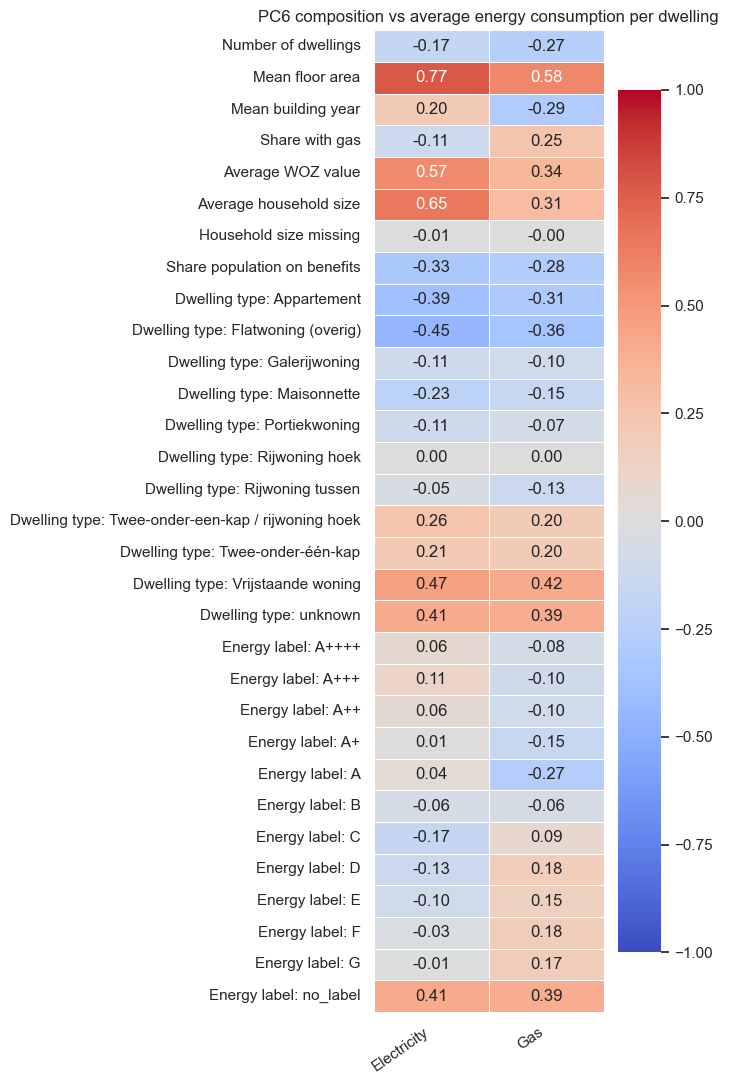

In [35]:
# ----------------------------
# 5.4B PC6 composition vs average energy
# ----------------------------

# Remove PV from energy outcomes
energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# Add dwelling-type shares
composition_vars += [
    c for c in pc6_analysis.columns
    if c.startswith("share_dwelling_type_")
]

# Add energy-label shares
composition_vars += [
    c for c in pc6_analysis.columns
    if c.startswith("share_energy_label_")
]

# Compute correlation block
corr_block = (
    pc6_analysis[
        composition_vars + energy_vars
    ]
    .corr(method="spearman")
    .loc[composition_vars, energy_vars]
)

# Readable labels
row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_block_plot = corr_block.rename(
    index=row_label_map
)

corr_block_plot.index = (
    corr_block_plot.index
    .str.replace(
        "share_dwelling_type_",
        "Dwelling type: ",
        regex=False
    )
    .str.replace(
        "share_energy_label_",
        "Energy label: ",
        regex=False
    )
)

# Rename x-axis labels
corr_block_plot = corr_block_plot.rename(
    columns={
        "kwh_avg_per_dwelling_pc6": "Electricity",
        "gas_avg_per_dwelling_pc6": "Gas"
    }
)

# Plot
plt.figure(figsize=(7, 11))

ax = sns.heatmap(
    corr_block_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.title(
    "PC6 composition vs average energy consumption per dwelling"
)

plt.tight_layout()
plt.show()

### Interpretation of Association between PC6 composition and average energy

The correlation matrix highlights how PC6 composition relates to average energy consumption per dwelling.

**Postcode size**

- `n_dwellings` shows weak correlations (electricity: -0.17, gas: -0.27), indicating that average energy largely removes the mechanical size effect.
- Larger postcode areas tend to have slightly lower consumption per dwelling, consistent with denser urban areas.

**Structural characteristics**

- `mean_floor_area` is the strongest driver (electricity: 0.77, gas: 0.58), indicating that larger dwellings consume more energy per unit.
- `mean_building_year` is negatively related to gas (-0.29), suggesting newer buildings rely less on gas.
- `share_has_gas` is positively related to gas consumption (0.25), reflecting heating system dependence.

**Socioeconomic characteristics**

- `avg_woz_value` (0.57 electricity, 0.34 gas) and `avg_household_size` (0.65 electricity, 0.31 gas) show strong positive associations with energy use.
- `share_population_on_benefits` is negatively related to energy (-0.33 electricity, -0.28 gas), indicating lower consumption in lower-income areas.
- The missing indicator has near-zero correlations, confirming its purely technical role.

**Dwelling type composition**

- High-density housing (e.g. apartments: -0.39 electricity, -0.31 gas) is associated with lower energy use.
- Low-density housing (e.g. detached: 0.47 electricity, 0.42 gas) is associated with higher energy use.
- This confirms that housing typology is a key determinant of energy intensity.

**Energy labels**

- Energy label shares show relatively weak and mixed relationships.


**Conclusion**

Average energy consumption per dwelling is primarily driven by dwelling size, housing type, and household composition. Socioeconomic factors contribute, but less strongly. The weak correlation with postcode size confirms that average energy successfully captures structural variation rather than scale effects.

### 5.4C Association between PC6 composition and total energy

As a comparison to the average per-dwelling energy analysis, we also examine how PC6 composition relates to **total energy demand** at postcode level.

The total energy indicators are:

- `kwh_total_pc6`
- `gas_total_pc6`
- `pv_total_pc6`

Unlike average energy per dwelling, total energy is expected to be strongly influenced by postcode size. Therefore, `n_dwellings` is included in the correlation matrix to make the role of PC6 scale explicit.

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear.

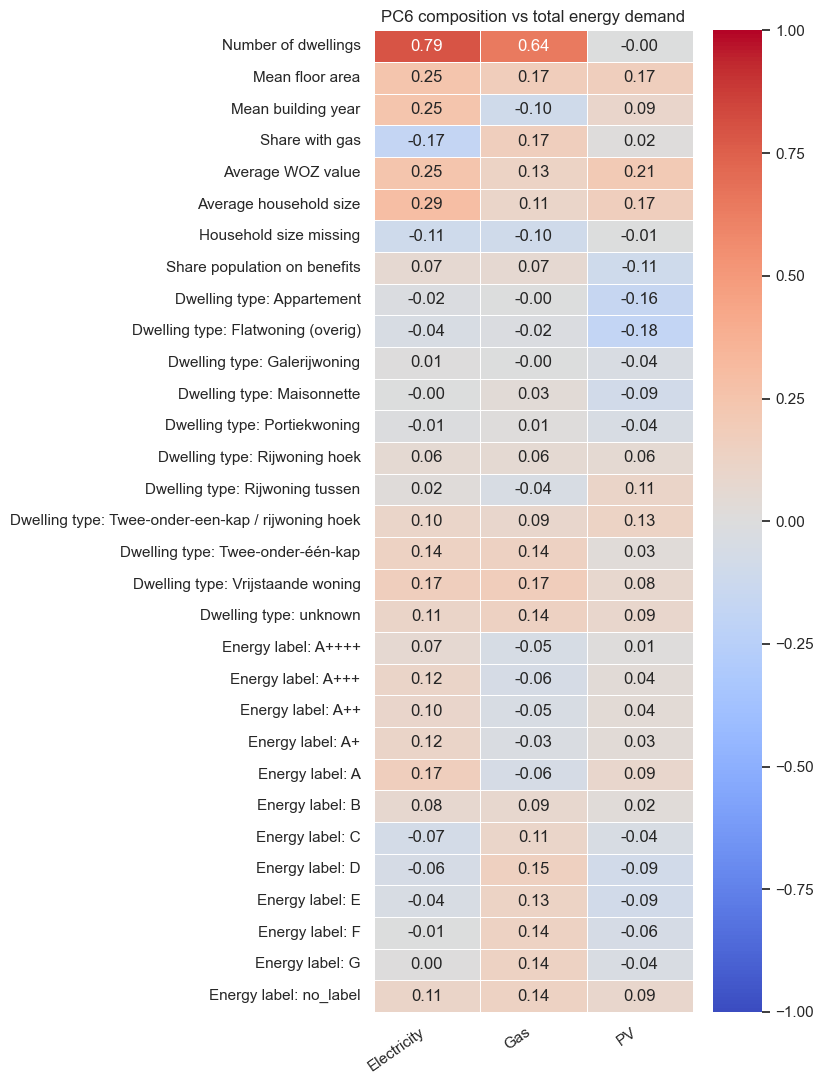

In [36]:
# ----------------------------
# 5.4C PC6 composition vs total energy
# ----------------------------

energy_total_vars = [
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_dwelling_type_")
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_energy_label_")
]

corr_total_block = (
    pc6_analysis[composition_vars + energy_total_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_total_vars]
)

row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_total_plot = corr_total_block.rename(index=row_label_map)

corr_total_plot.index = (
    corr_total_plot.index
    .str.replace("share_dwelling_type_", "Dwelling type: ", regex=False)
    .str.replace("share_energy_label_", "Energy label: ", regex=False)
)

corr_total_plot = corr_total_plot.rename(columns={
    "kwh_total_pc6": "Electricity",
    "gas_total_pc6": "Gas",
    "pv_total_pc6": "PV"
})

plt.figure(figsize=(8, 11))

ax = sns.heatmap(
    corr_total_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("PC6 composition vs total energy demand")
plt.tight_layout()
plt.show()

### Interpretation: PC6 composition vs total energy demand

The correlation patterns for total energy demand differ substantially from those observed for average energy per dwelling, primarily due to the dominant role of postcode size.

- **Postcode size dominates total energy**
  - Number of dwellings shows a very strong positive correlation with:
    - Electricity: **0.79**
    - Gas: **0.64**
  - This confirms that total energy consumption is largely driven by how many dwellings are present in a PC6 area.

- **Structural variables appear weaker**
  - Mean floor area:
    - Electricity: **0.25** (vs ~0.77 in average energy)
  - Average household size:
    - Electricity: **0.29** (vs ~0.65)
  - Average WOZ value:
    - Electricity: **0.25** (vs ~0.57)
  - These relationships are substantially attenuated, indicating that their strong effects in the previous analysis were mainly related to **energy intensity per dwelling**, not total consumption.

- **Housing typology effects are largely muted**
  - Apartment share:
    - Electricity: **−0.02**
  - Detached housing:
    - Electricity: **0.17**
  - Compared to the average-energy analysis (e.g. −0.39 for apartments, +0.47 for detached), these effects are much smaller, showing that typology mainly affects **how much each dwelling consumes**, rather than total demand at PC6 level.

- **Socioeconomic variables lose explanatory power**
  - Share population on benefits:
    - Electricity: **0.07** (previously −0.33)
  - The relationship becomes weak and even changes sign, indicating that socioeconomic effects are largely obscured when using total energy.

- **Gas infrastructure behaves differently**
  - Share with gas:
    - Gas: **0.17**
  - This remains moderately correlated, reflecting a direct link between gas connection and gas consumption, independent of postcode size.

- **PV production remains weakly related**
  - Most variables show small correlations with PV (generally |ρ| < 0.2)
  - PV appears less structurally tied to composition variables at PC6 level.

### Overall interpretation

Total energy demand primarily reflects **postcode size**, with structural and socioeconomic variables playing a secondary role. 

In contrast to average energy per dwelling:
- Relationships that previously appeared strong are largely diluted  
- Differences between housing types and socioeconomic groups become much less visible  

This confirms that total energy combines:
- a **mechanical size effect** (number of dwellings)  
- and a **structural intensity effect** (energy use per dwelling)  

As a result, total energy is less suitable for identifying underlying drivers of energy demand, while average energy per dwelling provides a clearer representation of structural and behavioral differences across PC6 areas.

## 6️⃣ PC6-level regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to electricity demand. These analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint association of multiple housing characteristics with electricity demand.

The purpose of this chapter is to estimate statistical models that relate postcode-level electricity demand to the structural and socioeconomic composition of the housing stock. Two objectives are pursued.

First, regression models are used to quantify how average dwelling size, construction year, gas availability, dwelling type composition, energy label composition, and selected CBS socioeconomic variables are associated with electricity consumption across postcode areas.

Second, the predictive performance of the preferred regression specification is evaluated out of sample and compared with a nonlinear machine-learning benchmark. This makes it possible to assess both the interpretability of the regression framework and the potential predictive gains from a more flexible nonlinear method.

The unit of analysis is the PC6 postcode area. Each observation represents one postcode area and combines information on electricity consumption, housing structure, and socioeconomic characteristics.

The dependent variable is defined as:

- `kwh_avg_per_dwelling_pc6` — average annual electricity consumption per dwelling within each PC6 area

This variable is used instead of total electricity consumption because total consumption is strongly influenced by the number of dwellings in a postcode area. By focusing on average consumption per dwelling, the analysis isolates differences in electricity intensity across postcode areas, rather than differences in postcode size.

The explanatory variables are grouped into three categories.

**Structural variables**
- average dwelling floor area  
- average construction year  
- share of dwellings connected to gas  

**Compositional variables**
- dwelling type shares at postcode level  
- energy label shares at postcode level  

**Socioeconomic variables (CBS)**
- average WOZ value  
- average household size (with missingness indicator where relevant)  
- share of population receiving social benefits  

To avoid perfect multicollinearity, one category is omitted from each set of compositional shares and serves as a reference group in the regression models.

The analysis proceeds in five steps:

1. construct the regression dataset and define the predictor matrix  
2. assess multicollinearity among explanatory variables  
3. estimate alternative regression specifications  
4. select a preferred model based on fit and residual diagnostics  
5. evaluate predictive performance and compare with a nonlinear benchmark  

This structure ensures analytical coherence. Model specification and selection are addressed first, followed by inference diagnostics for the preferred model. Finally, predictive performance is evaluated out of sample.

The results are interpreted as conditional statistical associations. They do not imply causal effects, as housing characteristics and socioeconomic variables may be jointly determined and may also reflect unobserved behavioural, technical, or local factors.

### 6.1 Regression dataset construction

In this section, the regression dataset is constructed at the PC6 level. The dataset includes postcode areas with valid electricity consumption values and all explanatory variables defined in the previous section.

The dependent variable is:

- `kwh_avg_per_dwelling_pc6` — average annual electricity consumption per dwelling

The explanatory variables include:

- structural variables (`mean_floor_area`, `mean_building_year`, `share_has_gas`)
- dwelling type shares (`share_dwelling_type_*`)
- energy label shares (`share_energy_label_*`)
- CBS socioeconomic variables (`avg_woz_value_filled`, `avg_household_size_filled`, `avg_household_size_missing`, `share_population_on_benefits_filled`)

To avoid perfect multicollinearity, one category is omitted from each set of compositional share variables and used as the reference group.

This is necessary because the dwelling type shares and energy label shares are **compositional variables**. Within each PC6, the shares across all dwelling types sum to one:

$$
\sum_j share\_dwelling\_type_{j,pc6} = 1
$$

Similarly, the energy label shares also sum to one:

$$
\sum_k share\_energy\_label_{k,pc6} = 1
$$

If all categories are included in the regression together with an intercept, one category can be perfectly predicted from the others. For example, if the shares of all dwelling types except apartments are known, then the apartment share is automatically determined as the remaining share. This creates perfect multicollinearity, also known as the dummy variable trap.

To prevent this, one category is removed from each compositional group. The omitted category becomes the **reference category**. Coefficients for the included categories are then interpreted relative to this omitted group.

For dwelling type, the omitted reference category is:

- `share_dwelling_type_Appartement`

This means that dwelling type coefficients describe how electricity consumption changes as the share of a given dwelling type increases relative to apartments.

For energy label, the omitted reference category is:

- `share_energy_label_G`

This means that energy label coefficients describe how electricity consumption changes as the share of a given energy label increases relative to label G, the lowest efficiency class.

These reference categories are chosen for interpretational convenience, but it is important to note that the specific choice of reference does not affect the overall fit or predictive performance of the regression model. Any category could be omitted without changing the model’s explanatory power, as the information contained in the full set of shares remains the same.

The choice of reference only affects how coefficients are interpreted. Each estimated coefficient describes the conditional association between a higher share of that category and electricity consumption, relative to the omitted category.

In this analysis, the reference categories are selected to provide a meaningful and intuitive baseline for comparison. For dwelling types, `share_woning_type_Appartement` is used as the reference, representing a common and well-defined housing type. For energy labels, `share_energieklasse_G` is used as the reference, representing the least energy-efficient category.

As a result, the coefficients of the included categories can be interpreted as conditional differences in electricity consumption associated with a higher share of the given category relative to the reference category, while respecting the compositional structure of the model.

The regression matrix is constructed below.

In [37]:
# ----------------------------
# 6.1 Construct regression dataset
# ----------------------------
import statsmodels.api as sm

# Keep only valid electricity observations
reg_data = pc6_analysis[
    pc6_analysis["kwh_avg_per_dwelling_pc6"] > 0
].copy()

# ----------------------------
# Dependent variable
# ----------------------------
y = reg_data["kwh_avg_per_dwelling_pc6"]

# ----------------------------
# Identify compositional variables
# ----------------------------
dwelling_cols_full = [
    c for c in reg_data.columns if c.startswith("share_dwelling_type_")
]

label_cols_full = [
    c for c in reg_data.columns if c.startswith("share_energy_label_")
]

# ----------------------------
# Reference categories
# ----------------------------
ref_dwelling = "share_dwelling_type_Appartement"
ref_label = "share_energy_label_G"

dwelling_cols = [c for c in dwelling_cols_full if c != ref_dwelling]
label_cols = [c for c in label_cols_full if c != ref_label]

# ----------------------------
# CBS variables
# ----------------------------
cbs_vars = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# Structural variables
# ----------------------------
structural_vars = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

# ----------------------------
# Construct X matrix
# ----------------------------
X = reg_data[
    structural_vars
    + dwelling_cols
    + label_cols
    + cbs_vars
].copy()

# Add intercept
X = sm.add_constant(X)

# ----------------------------
# Diagnostics
# ----------------------------
print("Regression dataset:")
print("Observations:", X.shape[0])
print("Predictors:", X.shape[1])

display(X.head())

Regression dataset:
Observations: 234882
Predictors: 29


,const,mean_floor_area,mean_building_year,share_has_gas,share_dwelling_type_Flatwoning (overig),share_dwelling_type_Galerijwoning,share_dwelling_type_Maisonnette,share_dwelling_type_Portiekwoning,share_dwelling_type_Rijwoning hoek,share_dwelling_type_Rijwoning tussen,...,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1.0,75.615385,1789.923077,0.730769,0.307692,0.0,0.038462,0.0,0.0,0.0000,...,0.038462,0.076923,0.076923,0.153846,0.0000,0.269231,622.0,1.6,0,0.0
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.0,0.000000,0.0,0.0,0.0625,...,0.000000,0.000000,0.000000,0.000000,0.0625,0.937500,870.0,2.1,0,0.0
2,1.0,58.111111,1975.555556,0.666667,0.222222,0.0,0.111111,0.0,0.0,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.555556,559.0,1.4,0,0.0
3,1.0,85.333333,1818.750000,0.750000,0.000000,0.0,0.000000,0.0,0.0,0.0000,...,0.000000,0.166667,0.000000,0.166667,0.0000,0.666667,647.0,1.3,0,0.0
4,1.0,83.384615,1673.769231,1.000000,0.384615,0.0,0.076923,0.0,0.0,0.0000,...,0.000000,0.076923,0.000000,0.461538,0.0000,0.461538,623.0,1.8,0,0.0


### 6.2 Regression specifications

Before comparing alternative functional forms, it is useful to justify the selection of explanatory variables included in the regression framework.

The regression models combine two complementary sources of information:

1. CBS socioeconomic variables, describing demographic and socioeconomic characteristics at postcode level  
2. DEGO/VNG housing-stock variables, describing the physical composition and structural characteristics of the dwelling stock  

To assess whether the inclusion of these variable groups is empirically justified, three alternative linear specifications are estimated:

1. a model using only CBS socioeconomic variables  
2. a model using only DEGO/VNG housing-stock variables  
3. a combined model using both domains simultaneously  

The objective of this exercise is not to identify a causal hierarchy between variable groups, but rather to evaluate whether the inclusion of additional explanatory variables is supported by improvements in model performance.

The comparison is based on:

- adjusted $R^2$  
- Akaike Information Criterion (AIC)  
- Bayesian Information Criterion (BIC)  

Adjusted $R^2$ evaluates explanatory performance while accounting for model complexity. AIC and BIC additionally evaluate whether improvements in fit justify the inclusion of additional predictors.

This comparison provides a justification for the explanatory-variable framework used in the subsequent regression specifications.

In [38]:
# ----------------------------
# 6.2.1 Explanatory-variable comparison
# Contribution of CBS and DEGO/VNG variable domains
# Linear electricity models
# ----------------------------

# ----------------------------
# 1. Define variable groups
# ----------------------------

# CBS socioeconomic variables
cbs_only_vars = cbs_vars

# DEGO/VNG housing-stock variables
vng_only_vars = (
    [
        "mean_floor_area",
        "mean_building_year",
        "share_has_gas"
    ]
    + dwelling_cols
    + label_cols
)

# Combined model
combined_vars = (
    cbs_only_vars
    + vng_only_vars
)

# ----------------------------
# 2. Define dependent variable
# ----------------------------

y_domain = reg_data["kwh_avg_per_dwelling_pc6"].copy()

# ----------------------------
# 3. Construct predictor matrices
# ----------------------------

X_cbs = sm.add_constant(
    reg_data[cbs_only_vars],
    has_constant="add"
)

X_vng = sm.add_constant(
    reg_data[vng_only_vars],
    has_constant="add"
)

X_combined = sm.add_constant(
    reg_data[combined_vars],
    has_constant="add"
)

# ----------------------------
# 4. Estimate models
# ----------------------------

model_cbs = sm.OLS(y_domain, X_cbs).fit()
model_vng = sm.OLS(y_domain, X_vng).fit()
model_combined = sm.OLS(y_domain, X_combined).fit()

# ----------------------------
# 5. Build comparison table
# ----------------------------

domain_models = [
    {
        "Model": "M1",
        "Description": "CBS socioeconomic variables only",
        "Model_object": model_cbs,
        "X": X_cbs
    },
    {
        "Model": "M2",
        "Description": "DEGO/VNG housing-stock variables only",
        "Model_object": model_vng,
        "X": X_vng
    },
    {
        "Model": "M3",
        "Description": "Combined CBS and DEGO/VNG variables",
        "Model_object": model_combined,
        "X": X_combined
    }
]

domain_comparison = pd.DataFrame({
    "Model": [item["Model"] for item in domain_models],
    "Description": [item["Description"] for item in domain_models],
    "Observations": [int(item["Model_object"].nobs) for item in domain_models],
    "Predictors_including_intercept": [item["X"].shape[1] for item in domain_models],
    "Predictors_excluding_intercept": [item["X"].shape[1] - 1 for item in domain_models],
    "Adj_R2": [item["Model_object"].rsquared_adj for item in domain_models],
    "AIC": [item["Model_object"].aic for item in domain_models],
    "BIC": [item["Model_object"].bic for item in domain_models]
})

domain_comparison = domain_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Contribution of CBS and DEGO/VNG variable domains:")
display(domain_comparison)

Contribution of CBS and DEGO/VNG variable domains:


,Model,Description,Observations,Predictors_including_intercept,Predictors_excluding_intercept,Adj_R2,AIC,BIC
0,M1,CBS socioeconomic variables only,234882,5,4,0.5464,3622500.3,3622552.2
1,M2,DEGO/VNG housing-stock variables only,234882,25,24,0.6583,3556026.9,3556286.1
2,M3,Combined CBS and DEGO/VNG variables,234882,29,28,0.7177,3511173.4,3511474.0


### Interpretation of explanatory-variable comparison

The comparison indicates that both explanatory-variable domains are associated with postcode-level differences in electricity consumption.

The model using only CBS socioeconomic variables achieves an adjusted $R^2$ of approximately 0.55, suggesting that socioeconomic differences between postcode areas are related to variation in electricity consumption.

The model using only DEGO/VNG housing-stock variables performs better, achieving an adjusted $R^2$ of approximately 0.66. This suggests that housing-stock composition and structural dwelling characteristics are strongly associated with electricity demand patterns at postcode level.

The combined specification performs best across all evaluation metrics, achieving:

- an adjusted $R^2$ of approximately 0.72  
- the lowest AIC value  
- the lowest BIC value  

The improvement in adjusted $R^2$, together with the lower AIC and BIC values, indicates that the additional variables improve model fit sufficiently to justify the increase in model complexity.

These results suggest that the two variable domains contain complementary information:

- CBS variables describe socioeconomic and demographic characteristics  
- DEGO/VNG variables describe structural and housing-stock characteristics  

The combined specification is therefore retained as the explanatory-variable framework for the subsequent regression specifications.

### 6.2.2 Alternative functional-form specifications

Having established the explanatory-variable framework, the next step is to determine the most appropriate functional form for modelling postcode-level electricity demand.

The relationship between electricity consumption and the explanatory variables is not necessarily linear in absolute terms. In particular, postcode-level electricity consumption exhibits right-skewness, with a relatively small number of postcode areas displaying substantially higher consumption levels than the majority of observations.

To assess whether functional-form transformations improve model behaviour, three alternative Ordinary Least Squares (OLS) specifications are estimated:

1. a linear model estimated in levels  
2. a log-level model with a logarithmic dependent variable  
3. a log-log model with both the dependent variable and average floor area expressed in logarithmic form  

The three specifications are estimated using the same explanatory-variable framework and the same set of postcode areas, ensuring direct comparability between models.

The specifications differ in how they represent the relationship between electricity consumption and the explanatory variables:

- The **linear model** estimates relationships in absolute units and provides a directly interpretable baseline specification.  
- The **log-level model** transforms the dependent variable to reduce skewness and place greater emphasis on proportional rather than absolute differences.  
- The **log-log model** additionally transforms average floor area, allowing the relationship between dwelling size and electricity consumption to be interpreted in elasticity terms.  

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
\begin{equation*}
\begin{split}
kwh_{avg,pc6} &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6} \\
&\quad + \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1$–$\beta_3$ are coefficients on structural and infrastructure variables  
- $\beta_{4j}$ and $\beta_{5k}$ are coefficients on dwelling-type and energy-label shares  
- $\beta_6$–$\beta_9$ are coefficients on CBS socioeconomic variables  
- $\varepsilon_{pc6}$ is the error term  



Estimation in levels provides a straightforward, interpretable baseline. Right-skewed dependent variables may require transformations, motivating the alternative specifications.

In [39]:
# ----------------------------
# 6.2.2 Linear OLS specification
# ----------------------------

y_linear = y.copy()
X_linear = X.copy()

model_linear = sm.OLS(y_linear, X_linear).fit()

print("Linear model (levels) results:")
print(model_linear.summary())

Linear model (levels) results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.718
Model:                                  OLS   Adj. R-squared:                  0.718
Method:                       Least Squares   F-statistic:                 2.132e+04
Date:                      Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                              03:42:49   Log-Likelihood:            -1.7556e+06
No. Observations:                    234882   AIC:                         3.511e+06
Df Residuals:                        234853   BIC:                         3.511e+06
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.

#### 6.2.3 Log-level OLS specification

The dependent variable `kwh_avg_per_dwelling_pc6` is right-skewed, meaning that some postcode areas have substantially higher average electricity consumption than the majority. Estimating in levels may overweight these observations.

The second model transforms the dependent variable using the natural logarithm:

$$
\begin{equation*}
\begin{split}
\log(kwh\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

The dependent variable is logarithmically transformed in order to improve the symmetry of the electricity-consumption distribution and, more importantly, the symmetry of the regression residuals.

In [40]:
# ----------------------------
# 6.2.3 Log-level OLS specification
# ----------------------------

y_log = np.log(y)
X_log = X.copy()

model_log = sm.OLS(y_log, X_log).fit()

print("Log-level model results:")
print(model_log.summary())

Log-level model results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.712
Model:                                  OLS   Adj. R-squared:                  0.712
Method:                       Least Squares   F-statistic:                 2.074e+04
Date:                      Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                              03:42:50   Log-Likelihood:                 85858.
No. Observations:                    234882   AIC:                        -1.717e+05
Df Residuals:                        234853   BIC:                        -1.714e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
-

Inspection of the residual behaviour of the log-level specification is also useful for guiding further model development. If systematic structure remains after log-transforming the dependent variable, this may indicate that one or more explanatory variables still enter the model in an empirically restrictive functional form.

#### 6.2.4 Log-log OLS specification with logarithmic floor area


The third model logs both average electricity consumption per dwelling and average floor area:

$$
\begin{equation*}
\begin{split}
\log(kwh\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 \log(mean\_floor\_area_{pc6})
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

In this specification, average floor area is additionally logarithmically transformed in order to allow for non-linear scaling relationships between dwelling size and residential electricity consumption. This transformation reflects the expectation that increases in dwelling floor area may not correspond to constant absolute increases in electricity demand across the full range of dwelling sizes. Instead, the relationship may scale proportionally, particularly between smaller and larger residential dwellings.

In [41]:
# ----------------------------
# 6.2.4 Log-log OLS specification
# ----------------------------

y_loglog = np.log(y)

X_loglog = X.copy()
X_loglog["log_mean_floor_area"] = np.log(X_loglog["mean_floor_area"])
X_loglog = X_loglog.drop(columns=["mean_floor_area"])

model_loglog = sm.OLS(y_loglog, X_loglog).fit()

print("Log-log model results:")
print(model_loglog.summary())

Log-log model results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.720
Model:                                  OLS   Adj. R-squared:                  0.720
Method:                       Least Squares   F-statistic:                 2.159e+04
Date:                      Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                              03:42:50   Log-Likelihood:                 89214.
No. Observations:                    234882   AIC:                        -1.784e+05
Df Residuals:                        234853   BIC:                        -1.781e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---

### 6.3 Comparison and selection of the preferred regression specification

The three candidate specifications estimated in Section 6.2 are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand.

The comparison is based on four complementary diagnostic dimensions.

**1. Model fit**

Model fit is assessed using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ evaluates explanatory power while accounting for model complexity. AIC and BIC assess the trade-off between model fit and parsimony, with lower values indicating a more favourable balance.

It is important to note that AIC and BIC depend on the scale of the dependent variable. Since the linear model is estimated in levels and the alternative specifications are estimated in logarithmic form, these criteria are not directly comparable across all models. They are reported for completeness, but are primarily used to compare the log-based specifications.

**2. Residual distribution**

Residual histograms are used to assess whether the specification reduces skewness and the influence of extreme observations. Both the full residual range and the central 98\% of the residual distribution are examined to distinguish overall tail behaviour from the dominant error structure.

**3. Residual patterns**

Residuals are plotted against fitted values to examine whether the variance of the residuals remains approximately stable across the prediction range and whether systematic misspecification remains visible.

Because the dataset contains a very large number of postcode observations, standard scatter plots may become visually dense and suffer from overplotting. Therefore, hexbin residual-density plots are additionally used. These plots aggregate observations into hexagonal bins and visualize the local density of residuals across the fitted-value range, allowing systematic patterns and heteroskedasticity to be identified more clearly.

To ensure comparability between specifications estimated on the same scale, residual-versus-fitted plots and hexbin density plots are displayed using consistent axis limits.

**4. Observed versus fitted values**

Observed-versus-fitted plots are additionally used to evaluate how closely predicted electricity consumption aligns with observed postcode-level electricity demand.

Both scatter plots and hexbin density plots are presented. The 45-degree reference line represents perfect prediction. Deviations from this line indicate prediction error. As with the residual diagnostics, hexbin plots provide a clearer visualization of model behaviour in dense regions of the data.

Taken together, these diagnostics are used to guide the selection of a preferred regression specification.

Model comparison:


,Model,Observations,Adj_R2,AIC,BIC
0,Linear,234882,0.7177,3511173.4,3511474.0
1,Log-level,234882,0.7120,-171657.3,-171356.6
2,Log-log,234882,0.7202,-178370.8,-178070.2


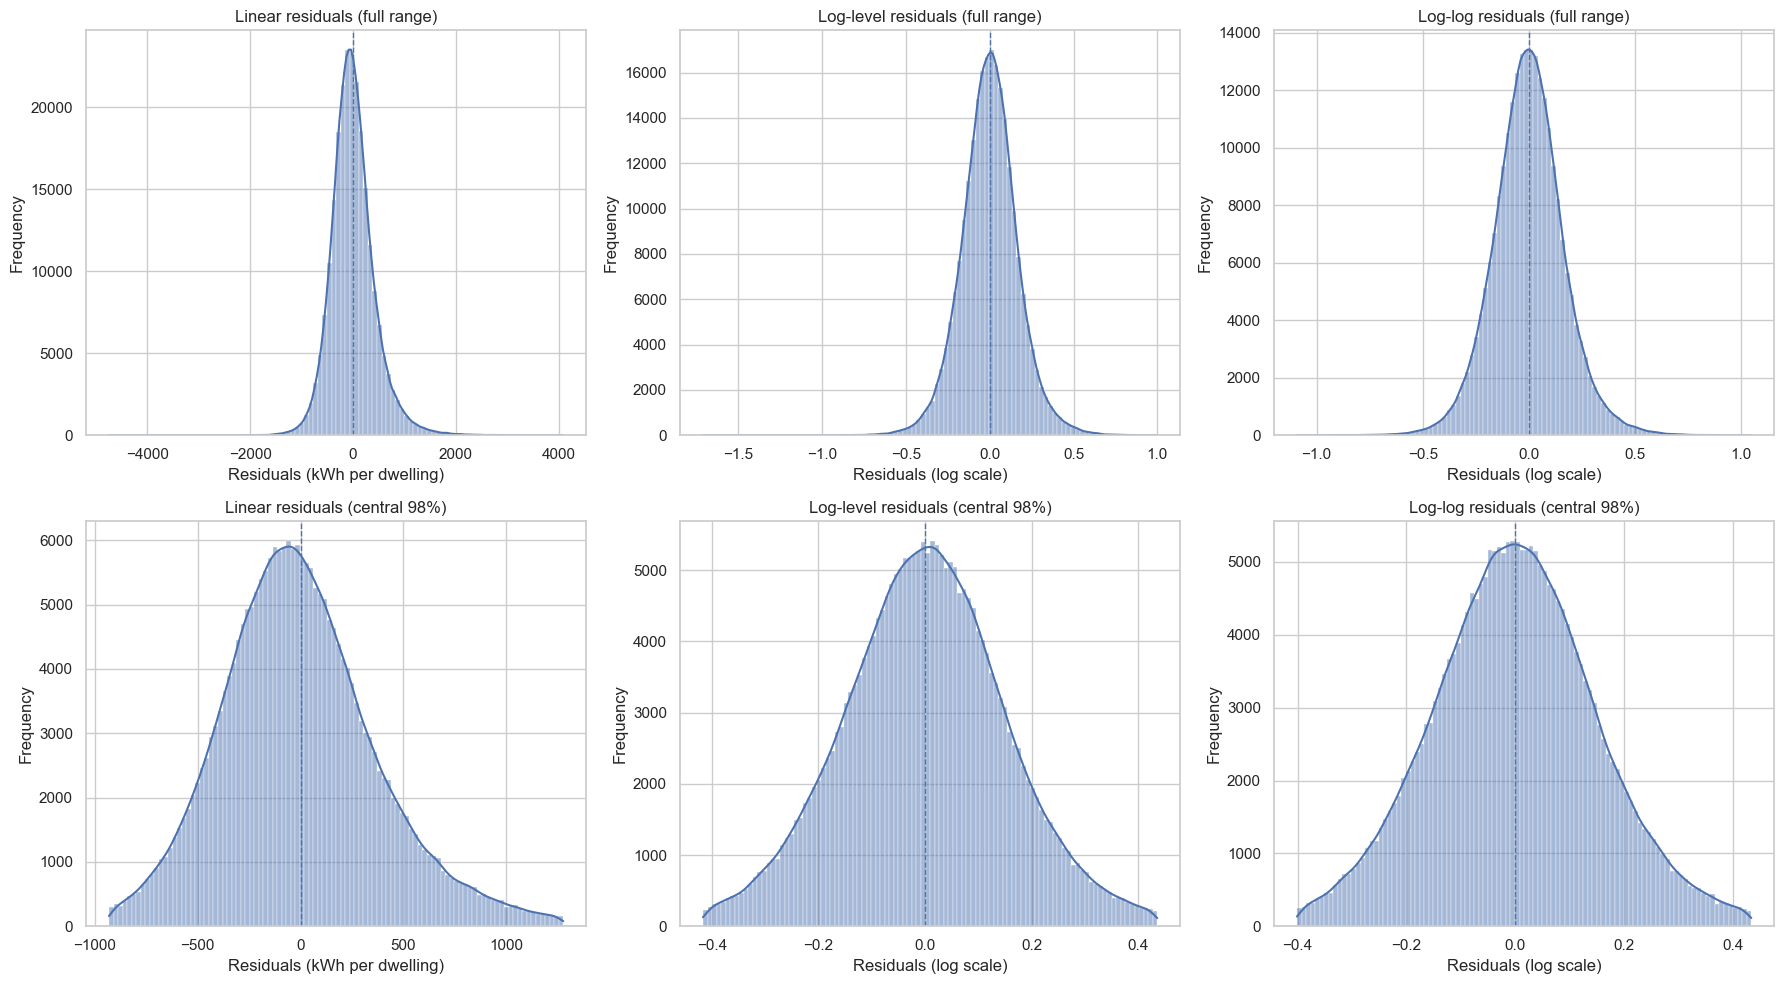

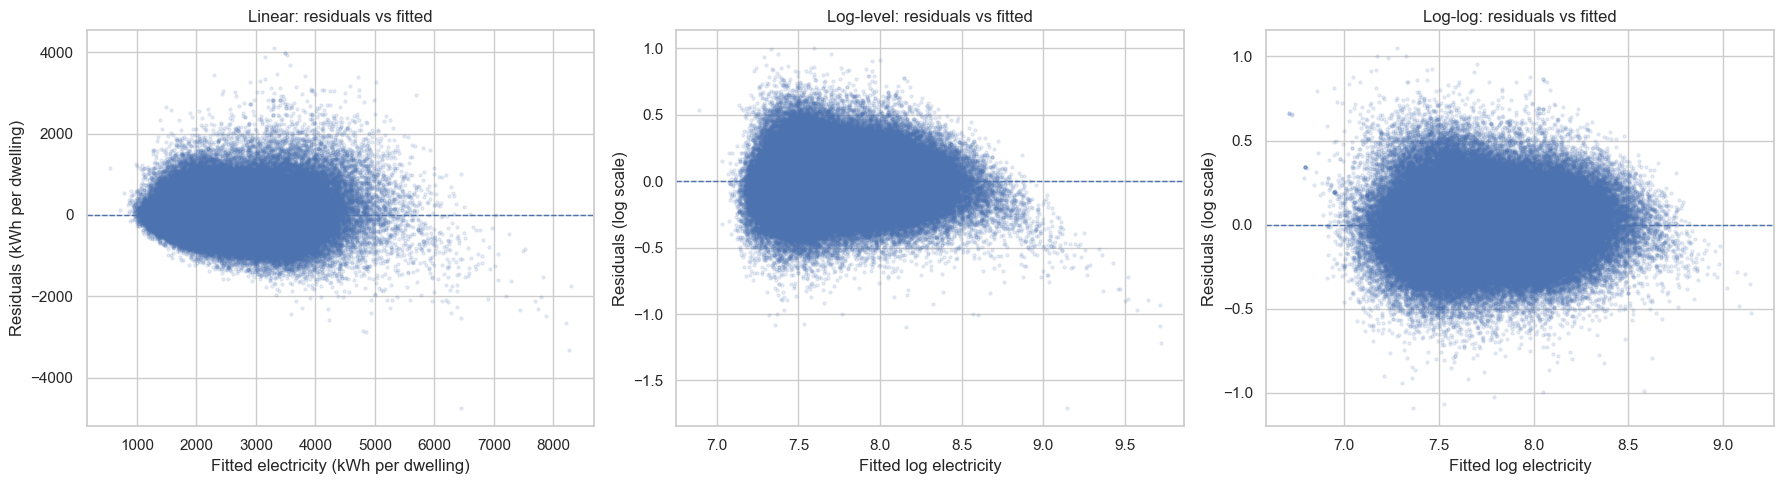

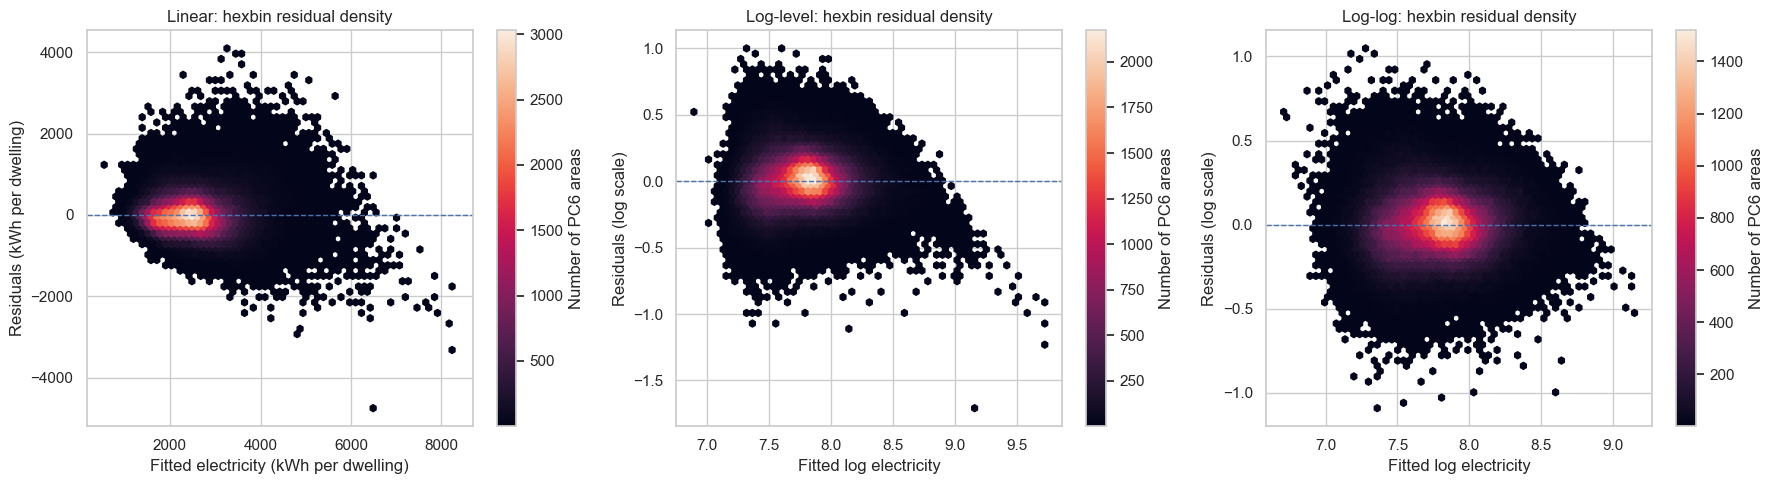

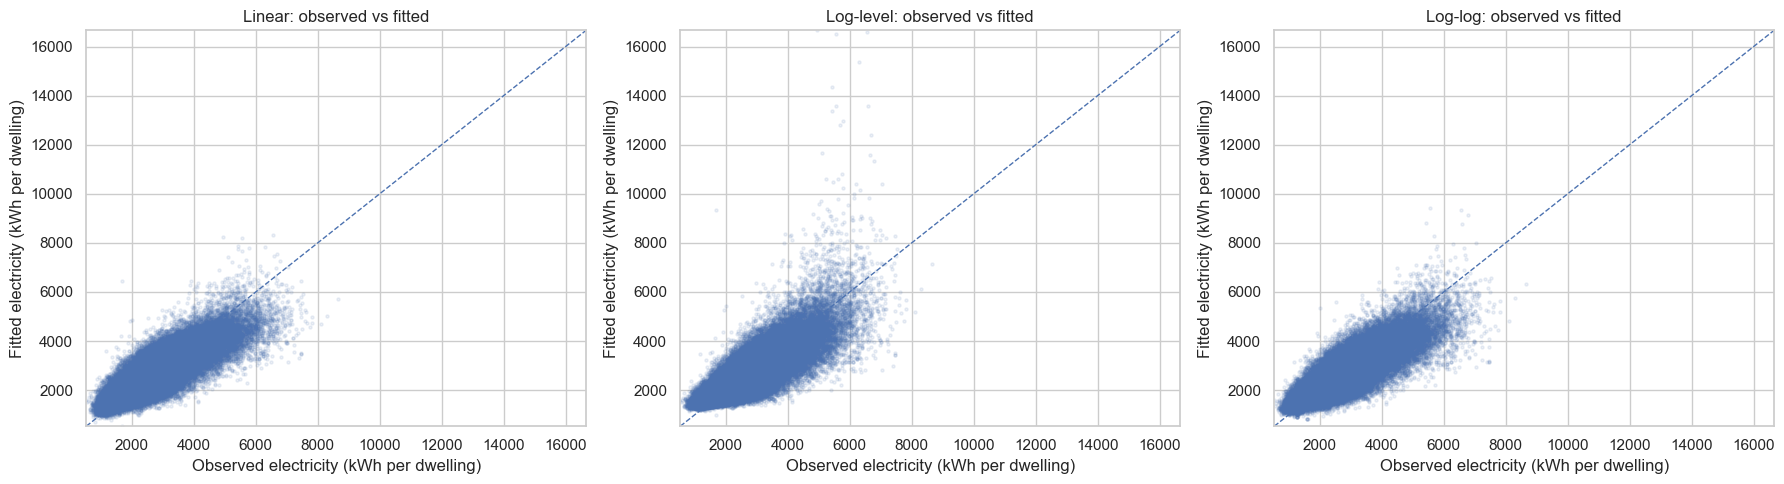

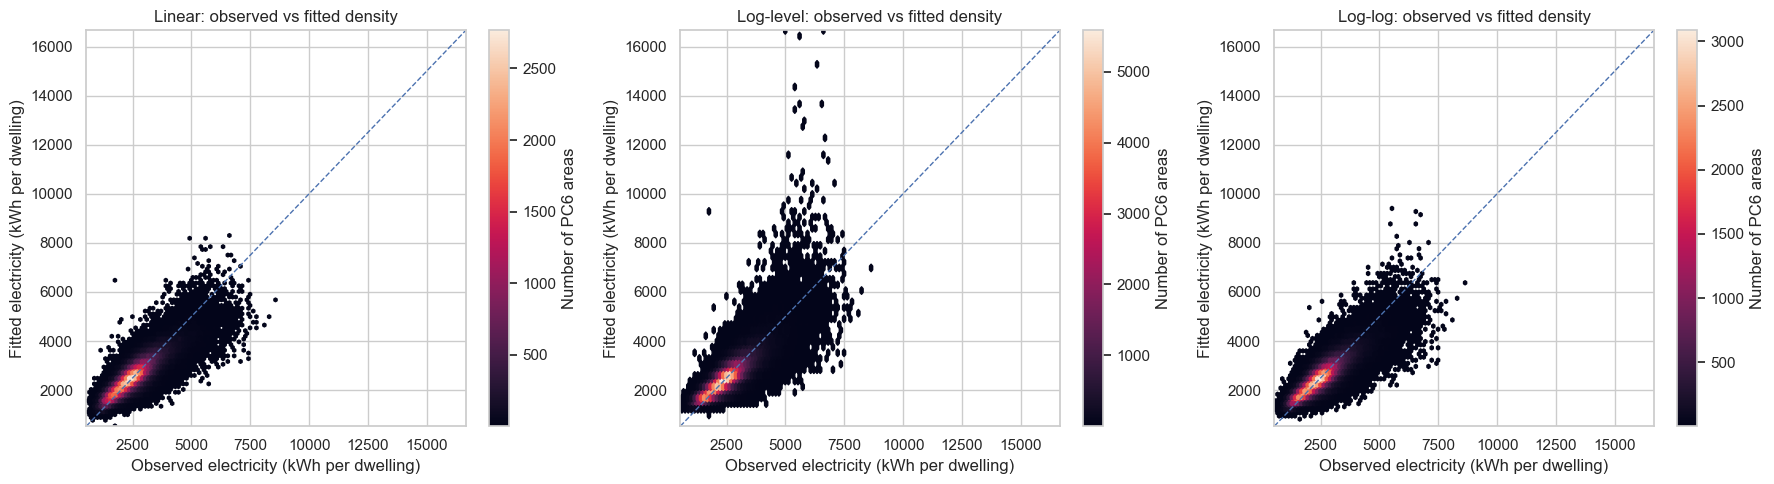

In [42]:
# ----------------------------
# 6.3 Model comparison and residual diagnostics
# ----------------------------

# ----------------------------
# 1. Model comparison table
# ----------------------------

comparison_stats = pd.DataFrame({
    "Model": ["Linear", "Log-level", "Log-log"],
    "Observations": [
        int(model_linear.nobs),
        int(model_log.nobs),
        int(model_loglog.nobs)
    ],
    "Adj_R2": [
        model_linear.rsquared_adj,
        model_log.rsquared_adj,
        model_loglog.rsquared_adj
    ],
    "AIC": [
        model_linear.aic,
        model_log.aic,
        model_loglog.aic
    ],
    "BIC": [
        model_linear.bic,
        model_log.bic,
        model_loglog.bic
    ]
})

comparison_stats = comparison_stats.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Model comparison:")
display(comparison_stats)

# ----------------------------
# 2. Store model metadata
# ----------------------------

models = [
    {
        "name": "Linear",
        "model": model_linear,
        "scale": "levels",
        "resid_label": "Residuals (kWh per dwelling)",
        "fitted_label": "Fitted electricity (kWh per dwelling)"
    },
    {
        "name": "Log-level",
        "model": model_log,
        "scale": "log",
        "resid_label": "Residuals (log scale)",
        "fitted_label": "Fitted log electricity"
    },
    {
        "name": "Log-log",
        "model": model_loglog,
        "scale": "log",
        "resid_label": "Residuals (log scale)",
        "fitted_label": "Fitted log electricity"
    }
]

# ----------------------------
# 3. Residual histograms: full range and central 98%
# ----------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, item in enumerate(models):

    residuals = item["model"].resid

    # Full range
    sns.histplot(
        residuals,
        bins=100,
        kde=True,
        ax=axes[0, i]
    )

    axes[0, i].axvline(0, linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{item['name']} residuals (full range)")
    axes[0, i].set_xlabel(item["resid_label"])
    axes[0, i].set_ylabel("Frequency")

    # Central 98%
    r_min = residuals.quantile(0.01)
    r_max = residuals.quantile(0.99)

    sns.histplot(
        residuals[
            (residuals >= r_min)
            & (residuals <= r_max)
        ],
        bins=100,
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].axvline(0, linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{item['name']} residuals (central 98%)")
    axes[1, i].set_xlabel(item["resid_label"])
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# ----------------------------
# 4. Residuals vs fitted values
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, models):

    fitted = item["model"].fittedvalues
    residuals = item["model"].resid

    ax.scatter(
        fitted,
        residuals,
        s=5,
        alpha=0.12
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: residuals vs fitted")
    ax.set_xlabel(item["fitted_label"])
    ax.set_ylabel(item["resid_label"])

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Hexbin residual density plots
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, models):

    fitted = item["model"].fittedvalues
    residuals = item["model"].resid

    hb = ax.hexbin(
        fitted,
        residuals,
        gridsize=60,
        mincnt=1
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: hexbin residual density")
    ax.set_xlabel(item["fitted_label"])
    ax.set_ylabel(item["resid_label"])

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Observed vs fitted values
# Original electricity models
# ----------------------------

observed_fitted_models = [
    {
        "name": "Linear",
        "y_true": y_linear,
        "y_pred": model_linear.fittedvalues
    },
    {
        "name": "Log-level",
        "y_true": y_linear,
        "y_pred": np.exp(model_log.fittedvalues)
    },
    {
        "name": "Log-log",
        "y_true": y_linear,
        "y_pred": np.exp(model_loglog.fittedvalues)
    }
]

# Common axis limits
all_true = np.concatenate([
    np.asarray(m["y_true"])
    for m in observed_fitted_models
])

all_pred = np.concatenate([
    np.asarray(m["y_pred"])
    for m in observed_fitted_models
])

axis_min = min(all_true.min(), all_pred.min())
axis_max = max(all_true.max(), all_pred.max())

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, observed_fitted_models):

    ax.scatter(
        item["y_true"],
        item["y_pred"],
        s=5,
        alpha=0.10
    )

    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

    ax.set_title(f"{item['name']}: observed vs fitted")
    ax.set_xlabel("Observed electricity (kWh per dwelling)")
    ax.set_ylabel("Fitted electricity (kWh per dwelling)")

plt.tight_layout()
plt.show()

# Hexbin observed vs fitted plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, observed_fitted_models):

    hb = ax.hexbin(
        item["y_true"],
        item["y_pred"],
        gridsize=60,
        mincnt=1
    )

    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

    ax.set_title(f"{item['name']}: observed vs fitted density")
    ax.set_xlabel("Observed electricity (kWh per dwelling)")
    ax.set_ylabel("Fitted electricity (kWh per dwelling)")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Model Comparison Interpretation

The three regression specifications are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand. The comparison is based on four complementary dimensions:

1. model fit metrics  
2. residual distributions  
3. residual patterns  
4. observed-versus-fitted behaviour  

#### 6.3.1 Model fit: Adjusted $R^2$, AIC and BIC

| Model | Adj $R^2$ | AIC | BIC |
|-------|----------|-----|-----|
| Linear | 0.7177 | 3.511e+06 | 3.511e+06 |
| Log-level | 0.7120 | -1.717e+05 | -1.714e+05 |
| Log-log | 0.7202 | -1.784e+05 | -1.781e+05 |

The three metrics capture different aspects of model performance.

- **Adjusted $R^2$** measures the proportion of variation in electricity consumption explained by the model, while accounting for the number of predictors. Higher values indicate better explanatory power.  
- **AIC (Akaike Information Criterion)** evaluates the trade-off between model fit and complexity. Lower values indicate a more efficient model.  
- **BIC (Bayesian Information Criterion)** is similar to AIC but penalizes model complexity more strongly.  

The results show that all three models achieve similar explanatory power, with adjusted $R^2$ values around 0.71–0.72. The log-log model performs slightly better in terms of adjusted $R^2$.

AIC and BIC are substantially lower for the log-based models compared to the linear model. However, these values are not directly comparable across different dependent-variable transformations. Therefore, AIC and BIC comparisons are primarily meaningful between the log-level and log-log specifications. Within this group, the log-log model provides the best fit.

Overall, based on model fit alone, differences between the specifications are relatively modest, and additional diagnostics are required.

#### 6.3.2 Residual distributions

Residuals represent the difference between observed and predicted electricity consumption:

$$
\varepsilon = y_{\text{observed}} - y_{\text{predicted}}
$$

They provide insight into how the model makes errors.

- A **positive residual** indicates that the model underestimates consumption  
- A **negative residual** indicates that the model overestimates consumption  

The distribution of residuals reveals whether errors are balanced and whether extreme observations dominate the model.

The **linear model** exhibits a relatively wide and skewed residual distribution. Even when focusing on the central range, the distribution shows a longer right tail, indicating that the model frequently underestimates high-consumption postcode areas.

The **log-level model** substantially improves the residual distribution. Residuals become more concentrated around zero and more symmetric, indicating that the logarithmic transformation reduces the influence of extreme observations.

The **log-log model** provides the most symmetric and tightly concentrated residual distribution. The shape is closer to a bell curve, indicating smaller and more balanced prediction errors.

This improvement occurs because logarithmic transformations shift the model from absolute errors toward proportional errors, treating low- and high-consumption postcode areas more consistently.

#### 6.3.3 Residual patterns

Residuals are also examined against fitted values to assess whether model errors depend systematically on the level of predicted consumption.

Two types of visualizations are considered:

- **Scatter plots**, where each point represents a postcode area  
- **Hexbin (density) plots**, where observations are aggregated into hexagonal bins and color indicates local density  

With approximately 235,000 observations, scatter plots suffer from substantial overplotting. Many points overlap, especially in dense regions, making it difficult to distinguish whether a region contains hundreds or tens of thousands of observations. As a result, important patterns such as heteroskedasticity or clustering can become visually obscured.

Hexbin plots address this limitation by aggregating observations and revealing data density explicitly. Darker regions correspond to areas with a high concentration of postcode areas, allowing the main residual structure to become more visible.

The **linear model** shows a clear increase in residual spread as fitted values increase. In the scatter plot, this appears as a diffuse cloud, while the hexbin plot reveals a widening fan shape. This indicates heteroskedasticity, meaning that prediction errors increase for higher electricity-consumption levels.

The **log-level model** reduces this effect. The residual spread becomes more stable across the fitted range, indicating improved model behaviour relative to the linear specification.

The **log-log model** shows the most stable residual structure. In the hexbin plot, residuals form a tighter and more symmetric pattern around zero, with a more constant spread across fitted values. This suggests that the log-log specification captures proportional relationships more effectively and reduces systematic error patterns.

#### 6.3.4 Observed-versus-fitted behaviour

Observed-versus-fitted plots provide an additional diagnostic by directly comparing predicted electricity consumption with observed electricity consumption.

A perfectly calibrated model would place all observations on the 45-degree line:

$$
y_{\text{predicted}} = y_{\text{observed}}
$$

The **linear model** follows the overall structure of the data reasonably well, but prediction dispersion increases at higher electricity-consumption levels.

The **log-level model** produces several extreme fitted values substantially above the observed range. Inspection of these observations shows that they are associated with postcode areas exhibiting extremely large average dwelling floor areas.

Because the log-level specification includes floor area in levels rather than logarithmic form, unusually large floor-area values can generate disproportionately large fitted values after exponentiation back to the original electricity-consumption scale.

The **log-log model** substantially mitigates this issue. By modelling floor area logarithmically, the influence of extreme floor-area observations is compressed, resulting in more stable fitted-value behaviour and fewer unrealistic high-consumption predictions.

The observed-versus-fitted diagnostics therefore provide additional empirical support for selecting the log-log specification as the preferred model.

#### Overall assessment

The comparison leads to several conclusions:

1. All models achieve broadly similar explanatory power in terms of adjusted $R^2$  
2. The log-log model performs best among the log-based specifications in terms of AIC and BIC  
3. Residual distributions improve substantially when moving from linear to log-based models  
4. The log-log model produces the most symmetric and concentrated residual distributions  
5. Residual patterns indicate that logarithmic transformations reduce heteroskedasticity and improve model stability  
6. Hexbin plots provide a substantially clearer representation of residual structure than scatter plots in very large datasets  
7. Observed-versus-fitted diagnostics reveal that the log-level specification is sensitive to extreme floor-area observations, while the log-log model remains substantially more stable  

While the linear model is straightforward to interpret in absolute terms, it struggles to capture variation consistently across low- and high-consumption postcode areas. The log-level specification improves residual behaviour but remains sensitive to extreme structural observations.

The log-log model therefore provides the strongest overall balance between explanatory power, residual behaviour, stability, and interpretability. It is consequently selected as the preferred specification for the remainder of the analysis.

### 6.4 Out-of-sample predictive assessment of the electricity regression specifications

The previous sections evaluated model adequacy primarily using in-sample criteria such as adjusted \(R^2\), AIC, BIC, and residual diagnostics. These metrics are useful for comparing candidate specifications, but they do not directly indicate how well the models generalize to unseen data.

To assess out-of-sample predictive performance, the three electricity regression specifications are evaluated using **10-fold cross-validation**:

1. the linear model in levels;
2. the log-level model with a logarithmic dependent variable;
3. the log-log model with both the dependent variable and average floor area expressed logarithmically.

In 10-fold cross-validation, the dataset is partitioned into ten approximately equal folds. For each iteration, the model is trained on nine folds and evaluated on the remaining fold. This process is repeated until each fold has served once as the validation sample.

The evaluation metrics are the **mean squared error (MSE)**, **root mean squared error (RMSE)**, and **mean absolute error (MAE)**.

The mean squared error is defined as:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

The root mean squared error is defined as:

$$
RMSE = \sqrt{MSE}
$$

The mean absolute error is defined as:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

where:

- \(y_i\) is the observed value;
- \(\hat{y}_i\) is the predicted value;
- \(n\) is the number of validation observations.

Because the candidate models are estimated on different dependent-variable scales, prediction errors are reported in two ways.

First, errors are reported in the model-estimation scale:

- for the linear model, this is kWh per dwelling;
- for the log-level and log-log models, this is log electricity consumption.

Second, all predictions are transformed to the original electricity-consumption scale and evaluated in kWh per dwelling. These original-scale metrics are the most useful for comparing predictive accuracy across the linear and log-based specifications, because all models are evaluated in the same physical unit.

For the log-based models, the prediction error is calculated in log space. Define the log prediction error as:

$$
e_i = \log(y_i) - \log(\hat{y}_i)
$$

Using the logarithm rule,

$$
\log(a) - \log(b) = \log\left(\frac{a}{b}\right)
$$

this becomes:

$$
e_i = \log\left(\frac{y_i}{\hat{y}_i}\right)
$$

Exponentiating both sides gives:

$$
\exp(e_i) = \frac{y_i}{\hat{y}_i}
$$

Therefore, a log error corresponds to a multiplicative error on the original scale. If \(e_i = 0\), then:

$$
\exp(0) = 1
$$

and therefore:

$$
\frac{y_i}{\hat{y}_i} = 1
$$

which means that the prediction is exact. If the absolute log error is \(a\), then the corresponding multiplicative deviation from perfect prediction is:

$$
\exp(a) - 1
$$

The subtraction of 1 is needed because \(\exp(a)\) gives a ratio relative to perfect prediction. Perfect prediction corresponds to a ratio of 1, not 0.

For this reason, log-space RMSE and MAE are converted into approximate relative-error measures as:

$$
\text{Approx. RMSE relative error}
=
\exp(RMSE_{\log}) - 1
$$

and

$$
\text{Approx. MAE relative error}
=
\exp(MAE_{\log}) - 1
$$

For example, if:

$$
RMSE_{\log} = 0.165
$$

then:

$$
\exp(0.165) - 1 \approx 0.18
$$

or approximately 18%. This means that an RMSE of 0.165 in log space corresponds to a typical multiplicative prediction error of about 18%.

These transformed values are used only to make log-space errors easier to interpret. The main practical comparison across all model specifications remains the original-scale RMSE and MAE in kWh per dwelling.

A cross-validated mean-predictor baseline is included as a reference point. For the linear model, the baseline predicts the mean electricity consumption in the training folds. For the log-based models, the baseline predicts the mean log electricity consumption in the training folds.

This assessment tests whether the preferred log-log specification selected from the in-sample diagnostics also performs competitively in out-of-sample prediction.

In [174]:
# ----------------------------
# 6.5 Out-of-sample predictive assessment
# Cross-validation for all three electricity specifications
# ----------------------------

# ----------------------------
# 1. Cross-validation setup
# ----------------------------

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ----------------------------
# 2. Define electricity candidate models
# ----------------------------

electricity_cv_models = [
    {
        "Model": "Linear",
        "Scale": "levels",
        "X": X_linear,
        "y_model": y_linear,
        "y_kwh": y_linear
    },
    {
        "Model": "Log-level",
        "Scale": "log",
        "X": X_log,
        "y_model": y_log,
        "y_kwh": y_linear
    },
    {
        "Model": "Log-log",
        "Scale": "log",
        "X": X_loglog,
        "y_model": y_loglog,
        "y_kwh": y_linear
    }
]

# ----------------------------
# 3. Helper functions
# ----------------------------

def prepare_electricity_sklearn_matrix(X_model):
    X_sklearn = X_model.copy()

    if "const" in X_sklearn.columns:
        X_sklearn = X_sklearn.drop(
            columns=["const"]
        )

    X_sklearn = X_sklearn.select_dtypes(
        include=[np.number]
    )

    return X_sklearn


def cross_validated_mean_prediction(y_values, cv):
    y_values_array = np.asarray(y_values)

    y_pred = np.empty_like(
        y_values_array,
        dtype=float
    )

    dummy_X = np.zeros(
        (len(y_values_array), 1)
    )

    for train_idx, test_idx in cv.split(dummy_X):
        train_mean = y_values_array[train_idx].mean()
        y_pred[test_idx] = train_mean

    return y_pred


def convert_electricity_prediction_to_kwh(y_pred_model, scale):
    if scale == "levels":
        return np.asarray(y_pred_model)

    if scale == "log":
        return np.exp(
            np.asarray(y_pred_model)
        )

    raise ValueError(
        "Scale must be either 'levels' or 'log'."
    )


def calculate_electricity_cv_metrics(
    model_name,
    scale,
    y_true_model,
    y_pred_model,
    y_true_kwh,
    y_pred_kwh
):

    y_true_model = np.asarray(y_true_model)
    y_pred_model = np.asarray(y_pred_model)
    y_true_kwh = np.asarray(y_true_kwh)
    y_pred_kwh = np.asarray(y_pred_kwh)

    # Metrics in model-estimation scale
    mse_model_scale = mean_squared_error(
        y_true_model,
        y_pred_model
    )

    rmse_model_scale = np.sqrt(
        mse_model_scale
    )

    mae_model_scale = mean_absolute_error(
        y_true_model,
        y_pred_model
    )

    # Approximate relative interpretation for log models
    if scale == "log":
        approx_rmse_relative = (
            np.exp(rmse_model_scale) - 1
        ) * 100

        approx_mae_relative = (
            np.exp(mae_model_scale) - 1
        ) * 100
    else:
        approx_rmse_relative = np.nan
        approx_mae_relative = np.nan

    # Metrics in original kWh scale
    mse_kwh = mean_squared_error(
        y_true_kwh,
        y_pred_kwh
    )

    rmse_kwh = np.sqrt(
        mse_kwh
    )

    mae_kwh = mean_absolute_error(
        y_true_kwh,
        y_pred_kwh
    )

    mean_signed_error_kwh = np.mean(
        y_true_kwh - y_pred_kwh
    )

    return {
        "Model": model_name,
        "Scale": scale,
        "Observations": len(y_true_kwh),

        "MSE_model_scale": mse_model_scale,
        "RMSE_model_scale": rmse_model_scale,
        "MAE_model_scale": mae_model_scale,

        "Approx_RMSE_relative_%": approx_rmse_relative,
        "Approx_MAE_relative_%": approx_mae_relative,

        "MSE_kWh": mse_kwh,
        "RMSE_kWh": rmse_kwh,
        "MAE_kWh": mae_kwh,
        "Mean_signed_error_kWh": mean_signed_error_kwh
    }

# ----------------------------
# 4. Cross-validated predictions and metrics
# ----------------------------

electricity_cv_rows = []
electricity_cv_predictions = {}
baseline_scales_added = set()

for item in electricity_cv_models:

    model_name = item["Model"]
    scale = item["Scale"]

    X_model_sklearn = prepare_electricity_sklearn_matrix(
        item["X"]
    )

    y_model = item["y_model"].copy()
    y_kwh = item["y_kwh"].copy()

    # ----------------------------
    # Baseline mean predictor
    # Add each baseline scale only once
    # ----------------------------

    if scale not in baseline_scales_added:

        y_pred_baseline_model = cross_validated_mean_prediction(
            y_model,
            kf
        )

        y_pred_baseline_kwh = convert_electricity_prediction_to_kwh(
            y_pred_baseline_model,
            scale
        )

        baseline_name = (
            f"Baseline mean predictor ({scale})"
        )

        electricity_cv_rows.append(
            calculate_electricity_cv_metrics(
                baseline_name,
                scale,
                y_model,
                y_pred_baseline_model,
                y_kwh,
                y_pred_baseline_kwh
            )
        )

        baseline_scales_added.add(scale)

    # ----------------------------
    # OLS model prediction
    # ----------------------------

    ols_cv = LinearRegression()

    y_pred_model = cross_val_predict(
        ols_cv,
        X_model_sklearn,
        y_model,
        cv=kf,
        n_jobs=-1
    )

    y_pred_kwh = convert_electricity_prediction_to_kwh(
        y_pred_model,
        scale
    )

    electricity_cv_rows.append(
        calculate_electricity_cv_metrics(
            model_name,
            scale,
            y_model,
            y_pred_model,
            y_kwh,
            y_pred_kwh
        )
    )

    electricity_cv_predictions[model_name] = {
        "Scale": scale,
        "X": X_model_sklearn,
        "y_true_model": np.asarray(y_model),
        "y_pred_model": np.asarray(y_pred_model),
        "y_true_kwh": np.asarray(y_kwh),
        "y_pred_kwh": np.asarray(y_pred_kwh)
    }

# ----------------------------
# 5. Build comparison table
# ----------------------------

cv_results_raw = pd.DataFrame(
    electricity_cv_rows
)

cv_results = cv_results_raw.round({
    "MSE_model_scale": 6,
    "RMSE_model_scale": 4,
    "MAE_model_scale": 4,

    "Approx_RMSE_relative_%": 2,
    "Approx_MAE_relative_%": 2,

    "MSE_kWh": 2,
    "RMSE_kWh": 2,
    "MAE_kWh": 2,
    "Mean_signed_error_kWh": 2
})

# ----------------------------
# 6. Identify best model on original kWh scale
# ----------------------------

electricity_cv_model_results = cv_results_raw[
    ~cv_results_raw["Model"].str.startswith("Baseline")
].copy()

best_rmse_model = (
    electricity_cv_model_results
    .sort_values("RMSE_kWh")
    .iloc[0]
)

best_mae_model = (
    electricity_cv_model_results
    .sort_values("MAE_kWh")
    .iloc[0]
)

electricity_cv_selection = pd.DataFrame({
    "Criterion": [
        "Lowest RMSE on original kWh scale",
        "Lowest MAE on original kWh scale",
        "Preferred specification after combining CV and residual diagnostics"
    ],
    "Selected_model": [
        best_rmse_model["Model"],
        best_mae_model["Model"],
        "Log-log"
    ],
    "Reason_or_value": [
        f'{best_rmse_model["RMSE_kWh"]:.2f} kWh per dwelling',
        f'{best_mae_model["MAE_kWh"]:.2f} kWh per dwelling',
        (
            "Competitive CV performance, better residual behaviour, "
        )
    ]
})

# ----------------------------
# 7. Store preferred log-log CV outputs for later diagnostics
# ----------------------------

preferred_electricity_cv_model = "Log-log"

if preferred_electricity_cv_model not in electricity_cv_predictions:
    raise RuntimeError(
        f"Preferred electricity CV model not found: {preferred_electricity_cv_model}"
    )

y_true_log_arr = electricity_cv_predictions[
    preferred_electricity_cv_model
]["y_true_model"]

y_pred_log_arr = electricity_cv_predictions[
    preferred_electricity_cv_model
]["y_pred_model"]

y_true_kwh_arr = electricity_cv_predictions[
    preferred_electricity_cv_model
]["y_true_kwh"]

y_pred_kwh_arr = electricity_cv_predictions[
    preferred_electricity_cv_model
]["y_pred_kwh"]

X_cv_sklearn = electricity_cv_predictions[
    preferred_electricity_cv_model
]["X"]

X_cv = X_loglog.copy()
y_cv_log = y_loglog.copy()

# Cross-validated baseline for preferred log-log model
baseline_pred_log_arr = cross_validated_mean_prediction(
    y_cv_log,
    kf
)

baseline_pred_kwh_arr = np.exp(
    baseline_pred_log_arr
)

# ----------------------------
# 8. Single output box
# ----------------------------

cv_results_display = cv_results.fillna("N/A")

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Electricity cross-validation:</strong>
        10-fold CV across all three regression specifications
    </p>

    <p>
        <strong>Preferred electricity model stored for later diagnostics:</strong>
        {preferred_electricity_cv_model}
    </p>

    <h4 style="margin-bottom: 6px;">Cross-validation metrics</h4>
    {cv_results_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Model-selection summary</h4>
    {electricity_cv_selection.to_html(index=False)}
</div>
"""

display(HTML(html_output))

### Interpretation of cross-validation results

The 10-fold cross-validation compares the three electricity regression specifications on the same PC6 sample. Because the models are estimated on different dependent-variable scales, the original-scale metrics in kWh per dwelling are the most useful for comparing predictive accuracy across specifications.

All three regression models substantially improve over the corresponding mean-predictor baselines. The level-scale baseline has an RMSE of approximately **802 kWh per dwelling** and an MAE of approximately **607 kWh per dwelling**. The log-scale baseline has a similar original-scale RMSE of approximately **811 kWh per dwelling** and an MAE of approximately **604 kWh per dwelling**.

The three regression specifications achieve much lower prediction errors. On the original electricity-consumption scale:

| Model | RMSE kWh per dwelling | MAE kWh per dwelling |
|---|---:|---:|
| Linear | 426.45 | 316.84 |
| Log-level | 443.70 | 319.77 |
| Log-log | 428.00 | 314.91 |

The linear model achieves the lowest RMSE, although the difference relative to the log-log model is very small. The log-log model achieves the lowest MAE, indicating slightly better average absolute prediction accuracy across PC6 areas.

The log-level model performs worse than both the linear and log-log specifications on the original kWh scale. This is consistent with the earlier residual diagnostics, where the log-level model was more sensitive to extreme floor-area observations than the log-log model.

Overall, the cross-validation results show that the linear and log-log specifications have very similar out-of-sample predictive performance. The predictive metrics alone do not indicate a large difference between them. However, the log-log model remains the preferred analytical specification because it combines competitive out-of-sample prediction with improved residual behaviour, better handling of proportional relationships, and a more stable treatment of average floor area.

The positive mean signed error for the log-based models indicates a small average tendency toward underprediction after transforming predictions back to the original kWh scale. This is limited relative to the overall prediction error and is examined further in the predictive error diagnostics.

For the remainder of the chapter, predictive error diagnostics are therefore based on the cross-validated predictions from the preferred log-log model.

### 6.5 Multicollinearity assessment

Multicollinearity arises when explanatory variables are strongly correlated with each other. In such cases, it becomes difficult to isolate the individual effect of each variable, and the variance of the estimated coefficients may increase.

Importantly, multicollinearity does **not bias** the estimated coefficients or affect the overall fit of the model. However, it can lead to:

- inflated standard errors  
- unstable coefficient estimates  
- sensitivity to small changes in the data  

This issue is particularly relevant in the present analysis due to the inclusion of **compositional variables**, such as dwelling-type shares and energy-label shares. By construction, these variables are interdependent, as their sum within each postcode area is equal to one.

To quantify the severity of multicollinearity, **Variance Inflation Factors (VIF)** are computed for the explanatory variables.

The VIF for a predictor $x_j$ is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is obtained by regressing $x_j$ on all other predictors.

The VIF measures how much the variance of a coefficient is inflated due to correlation with other variables. Common thresholds are:

- VIF < 5 → limited multicollinearity  
- 5 ≤ VIF < 10 → moderate multicollinearity  
- VIF ≥ 10 → strong multicollinearity  

In the following, VIF values are computed for the explanatory variables of the preferred log-log model.

---

The VIF diagnostic is computed using the explanatory-variable matrix of the preferred log-log model, `X_loglog`.

This matrix already contains the final regression variables exactly as used in the preferred model. Therefore, the VIF analysis is applied to the same predictors used in estimation.

No additional dummy-variable creation is required at this stage. The categorical dwelling type and energy label variables have already been transformed into postcode-level composition shares:

- `share_dwelling_type_*`
- `share_energy_label_*`

These variables behave like dummy-derived composition variables at PC6 level. For example, instead of a dwelling-level dummy indicating whether one dwelling is detached, the regression uses the share of detached dwellings within the PC6 area.

Because dwelling-type shares sum to one and energy-label shares also sum to one, one category from each group was omitted before regression:

- dwelling type reference: `share_dwelling_type_Appartement`
- energy label reference: `share_energy_label_G`

This avoids perfect multicollinearity, also known as the dummy variable trap. However, remaining share variables may still be correlated with each other, so VIF is still useful for assessing the severity of multicollinearity.

The intercept column `const` is excluded from the VIF table because VIF is interpreted for explanatory variables, not for the constant term.

VIF is deterministic. It does not depend on a random seed, because it is calculated from auxiliary regressions using the fixed predictor matrix. Therefore, the VIF values will be the same every time as long as the input data and selected variables remain unchanged.

In [ ]:
# ----------------------------
# 6.5 VIF diagnostics for preferred log-log model
# ----------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_loglog.copy()
X_vif = X_vif.select_dtypes(include=[np.number])

# Keep/add constant for the auxiliary regressions
X_vif = sm.add_constant(X_vif.drop(columns=["const"], errors="ignore"), has_constant="add")

vif_results = pd.DataFrame({
    "Variable": [c for c in X_vif.columns if c != "const"],
    "VIF": [
        variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(c))
        for c in X_vif.columns
        if c != "const"
    ]
})

# Add variable group for interpretation
def classify_vif_variable(var):
    if var == "log_mean_floor_area":
        return "Structural"
    elif var == "mean_building_year":
        return "Structural"
    elif var == "share_has_gas":
        return "Infrastructure"
    elif var.startswith("share_dwelling_type_"):
        return "Dwelling type share"
    elif var.startswith("share_energy_label_"):
        return "Energy label share"
    elif var in [
        "avg_woz_value_filled",
        "avg_household_size_filled",
        "avg_household_size_missing",
        "share_population_on_benefits_filled"
    ]:
        return "CBS socioeconomic"
    else:
        return "Other"

vif_results["Group"] = vif_results["Variable"].apply(classify_vif_variable)

# Sort by VIF, highest first
vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

# Round for readability
vif_results["VIF"] = vif_results["VIF"].round(2)

display(vif_results)

,Variable,VIF,Group
0,share_energy_label_no_label,335.48,Energy label share
1,share_dwelling_type_unknown,310.15,Dwelling type share
2,share_energy_label_A,27.57,Energy label share
3,share_energy_label_C,16.13,Energy label share
4,share_energy_label_B,10.71,Energy label share
5,share_energy_label_D,6.62,Energy label share
6,share_energy_label_E,4.33,Energy label share
7,log_mean_floor_area,3.67,Structural
8,share_energy_label_F,3.12,Energy label share
9,share_dwelling_type_Flatwoning (overig),2.92,Dwelling type share


### Interpretation of multicollinearity assessment (VIF)

Variance Inflation Factors (VIF) are used to assess the degree of multicollinearity among the explanatory variables in the preferred log-log specification. High VIF values indicate that a predictor can be strongly explained by the remaining predictors, which can inflate standard errors and make individual coefficient estimates less stable.

The results show that multicollinearity is concentrated in a small number of composition-related variables rather than being widespread across the full predictor set.

The highest VIF values are observed for `share_energy_label_no_label` and `share_dwelling_type_unknown`, with VIF values above 300. These variables represent incomplete or unknown classification categories rather than substantive dwelling characteristics. Their high VIF values suggest that they are strongly related to the remaining housing-stock composition variables and should therefore be interpreted with particular caution.

Several energy-label variables also show elevated VIF values. In particular, `share_energy_label_A`, `share_energy_label_C`, and `share_energy_label_B` exceed the conventional threshold of 10, while `share_energy_label_D` falls in the moderate range. This is expected because energy-label shares are compositional: after one reference category is omitted, the remaining shares are still mechanically and empirically related to each other. Therefore, individual energy-label coefficients should not be interpreted as fully independent effects.

In contrast, the structural and socioeconomic variables generally show limited multicollinearity. The VIF values for `log_mean_floor_area`, `mean_building_year`, `share_has_gas`, `avg_woz_value_filled`, `avg_household_size_filled`, and `share_population_on_benefits_filled` remain relatively low. This indicates that the main continuous structural and CBS variables are not severely affected by multicollinearity in the preferred specification.

Overall, the VIF results do not invalidate the regression model. Multicollinearity does not bias the estimated coefficients and does not reduce the model's overall predictive fit. However, it does reduce the reliability of interpreting some individual composition-share coefficients, especially the `no_label`, `unknown`, and selected energy-label share variables. The regression results should therefore be interpreted mainly in terms of broader patterns across groups of housing characteristics, rather than as precise independent estimates for each individual category.

### 6.6 Nonlinear benchmark: Random Forest

The preferred log-log regression model provides an interpretable statistical specification for modelling postcode-level electricity consumption. However, it assumes an additive relationship between the explanatory variables and the logarithm of electricity consumption. This structure may not fully capture nonlinear relationships, threshold effects, or interactions between housing-stock characteristics.

To assess whether such nonlinear patterns provide additional predictive information, a Random Forest regression model is estimated as a nonlinear benchmark.

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions. This allows the model to capture:

- nonlinear relationships between predictors and electricity consumption
- interactions between variables
- threshold effects that are not specified manually

The Random Forest is used strictly as a predictive benchmark. It is not used for coefficient interpretation, because it does not provide directly interpretable regression coefficients.

#### Random Forest specification

The Random Forest benchmark is estimated using fixed hyperparameters rather than a full grid search. This choice is made to avoid optimistic evaluation from selecting hyperparameters on the full dataset before cross-validation.

The selected settings are:

- `n_estimators = 100`
- `max_depth = 15`
- `min_samples_leaf = 5`
- `max_features = "sqrt"`

These settings provide a balance between flexibility, computational feasibility, and overfitting control. The purpose is not to identify the globally optimal Random Forest configuration, but to test whether a flexible nonlinear model provides a substantial predictive improvement over the preferred log-log regression.

#### Evaluation procedure

Both the preferred log-log regression model and the Random Forest benchmark are evaluated using the same 10-fold cross-validation procedure. For each fold, the model is fitted on the training folds and evaluated on the held-out validation fold.

The evaluation metrics are:

- mean squared error (MSE)
- root mean squared error (RMSE)
- mean absolute error (MAE)

The metrics are first evaluated in log space, because both models predict the logarithm of average electricity consumption per dwelling. For interpretability, predictions are also transformed back to the original electricity-consumption scale and evaluated in kWh per dwelling.

Because the dependent variable is logarithmic, RMSE and MAE in log space can also be interpreted approximately in multiplicative terms using:

$$
\exp(RMSE) - 1
$$

and

$$
\exp(MAE) - 1
$$

This provides an approximate relative-error interpretation.

In [ ]:
# ----------------------------
# 6.6 Random Forest benchmark
# Fixed-hyperparameter nonlinear benchmark
# Consistent with Section 6.5
# ----------------------------

from IPython.display import display, HTML

from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# 1. Data and CV setup
# ----------------------------

X_rf = X_loglog.copy()
y_rf_log = y_loglog.copy()

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# sklearn LinearRegression and RandomForestRegressor handle the intercept internally.
# Therefore, the explicit statsmodels constant is removed.
if "const" in X_rf.columns:
    X_rf_sklearn = X_rf.drop(columns=["const"]).copy()
else:
    X_rf_sklearn = X_rf.copy()

# Keep only numeric predictors
X_rf_sklearn = X_rf_sklearn.select_dtypes(include=[np.number])

# Original electricity scale
y_true_kwh = np.exp(y_rf_log.values)

# ----------------------------
# 2. OLS predictions
# ----------------------------

ols_model = LinearRegression()

y_pred_ols_log = cross_val_predict(
    ols_model,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=-1
)

y_pred_ols_kwh = np.exp(y_pred_ols_log)

# ----------------------------
# 3. Random Forest benchmark with fixed hyperparameters
# ----------------------------

fixed_rf_params = {
    "n_estimators": 200,
    "max_depth": 20,
    "min_samples_leaf": 10,
    "max_features": None,
    "random_state": 0,
    "n_jobs": -1
}

rf_model_exp = RandomForestRegressor(
    **fixed_rf_params
)

# Cross-validated RF predictions.
# These are used for predictive-performance evaluation.
# cross_val_predict uses n_jobs=1 to avoid nested parallelism,
# because the Random Forest itself already uses all available cores.
y_pred_rf_log = cross_val_predict(
    rf_model_exp,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=1
)

y_pred_rf_kwh = np.exp(y_pred_rf_log)

# ----------------------------
# 4. Helper function
# ----------------------------

def calculate_rf_metrics(
    model_name,
    y_true_log,
    y_pred_log,
    y_true_kwh,
    y_pred_kwh
):

    # Log-space metrics
    mse_log = mean_squared_error(
        y_true_log,
        y_pred_log
    )

    rmse_log = np.sqrt(mse_log)

    mae_log = mean_absolute_error(
        y_true_log,
        y_pred_log
    )

    # Absolute kWh metrics
    mse_kwh = mean_squared_error(
        y_true_kwh,
        y_pred_kwh
    )

    rmse_kwh = np.sqrt(mse_kwh)

    mae_kwh = mean_absolute_error(
        y_true_kwh,
        y_pred_kwh
    )

    return {
        "Model": model_name,

        "MSE_log_space": mse_log,
        "RMSE_log_space": rmse_log,
        "MAE_log_space": mae_log,

        "MSE_kWh": mse_kwh,
        "RMSE_kWh": rmse_kwh,
        "MAE_kWh": mae_kwh
    }

# ----------------------------
# 5. Final comparison table
# ----------------------------

rf_results_raw = pd.DataFrame([

    calculate_rf_metrics(
        "Preferred log-log regression (OLS)",
        y_rf_log.values,
        y_pred_ols_log,
        y_true_kwh,
        y_pred_ols_kwh
    ),

    calculate_rf_metrics(
        "Random Forest benchmark",
        y_rf_log.values,
        y_pred_rf_log,
        y_true_kwh,
        y_pred_rf_kwh
    )

])

# ----------------------------
# 6. Improvement relative to OLS
# ----------------------------

ols_mse = rf_results_raw.loc[
    rf_results_raw["Model"] == "Preferred log-log regression (OLS)",
    "MSE_log_space"
].iloc[0]

rf_mse = rf_results_raw.loc[
    rf_results_raw["Model"] == "Random Forest benchmark",
    "MSE_log_space"
].iloc[0]

mse_improvement = (ols_mse - rf_mse) / ols_mse

# ----------------------------
# 7. Fit final RF model for feature-importance analysis
# ----------------------------

# Important:
# The prediction errors above are based on cross-validation.
# This fitted full-sample model is used only later for feature importance in Chapter 7.
# It is not used to report predictive performance.

rf_model_exp = RandomForestRegressor(
    **fixed_rf_params
)

rf_model_exp.fit(
    X_rf_sklearn,
    y_rf_log
)

rf_feature_importance_ready = True

# ----------------------------
# 8. Rounded table for display
# ----------------------------

rf_results_exp = rf_results_raw.round({
    "MSE_log_space": 6,
    "RMSE_log_space": 4,
    "MAE_log_space": 4,

    "MSE_kWh": 2,
    "RMSE_kWh": 2,
    "MAE_kWh": 2
})

# ----------------------------
# 9. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Random Forest MSE improvement relative to OLS:</strong>
        {mse_improvement * 100:.2f} %
    </p>

    <p>
        <strong>Fixed Random Forest parameters:</strong>
        n_estimators={fixed_rf_params["n_estimators"]},
        max_depth={fixed_rf_params["max_depth"]},
        min_samples_leaf={fixed_rf_params["min_samples_leaf"]},
        max_features={fixed_rf_params["max_features"]}
    </p>

    <p>
        <strong>Final RF model fitted for Chapter 7 feature-importance analysis:</strong>
        {rf_feature_importance_ready}
    </p>

    {rf_results_exp.to_html(index=False)}
</div>
"""

display(HTML(html_output))

Model,MSE_log_space,RMSE_log_space,MAE_log_space,MSE_kWh,RMSE_kWh,MAE_kWh
Preferred log-log regression (OLS),0.027402,0.1655,0.1271,183187.32,428.0,314.91
Random Forest benchmark,0.023945,0.1547,0.1187,161687.52,402.1,295.18


### Interpretation: Nonlinear benchmark results

The Random Forest benchmark improves predictive performance relative to the preferred log-log regression across all reported error metrics. The comparison is summarized below.

| Metric | Log-log regression | Random Forest benchmark | Absolute reduction | Relative reduction |
|---|---:|---:|---:|---:|
| MSE, log space | 0.0274 | 0.0239 | 0.0035 | 12.61% |
| RMSE, log space | 0.1655 | 0.1547 | 0.0108 | 6.53% |
| MAE, log space | 0.1271 | 0.1187 | 0.0084 | 6.61% |
| MSE, kWh | 183,187 | 161,688 | 21,500 | 11.74% |
| RMSE, kWh | 428.0 | 402.1 | 25.9 | 6.05% |
| MAE, kWh | 314.9 | 295.2 | 19.7 | 6.27% |

In log-space terms, the Random Forest reduces MSE by **12.61%** relative to the preferred regression model. Since MSE penalizes larger errors more strongly, this indicates that the Random Forest is particularly better at reducing larger prediction errors.

However, the improvement is more moderate when expressed in RMSE and MAE. The RMSE decreases from **428.0 kWh** to **402.1 kWh** per dwelling, a reduction of approximately **26 kWh per dwelling**. The MAE decreases from **314.9 kWh** to **295.2 kWh** per dwelling, a reduction of approximately **20 kWh per dwelling**.

This means that the Random Forest captures some additional nonlinear structure or interaction effects that are not fully represented by the additive log-log regression. However, the size of the improvement is not large enough to justify replacing the regression model as the main analytical specification. The log-log regression retains the advantage of interpretability, while already capturing most of the systematic variation in electricity consumption.

Therefore, the Random Forest is retained as a nonlinear predictive benchmark and as a complementary tool for feature-importance analysis, rather than as the primary model.

Overall, the Random Forest benchmark shows that nonlinear modelling can improve predictive accuracy, but the improvement is incremental rather than transformative. This supports the use of the preferred log-log regression as the main model, while using the Random Forest as a complementary benchmark for prediction and feature-importance diagnostics.

### 6.7 Predictive error diagnostics

The previous sections evaluated the preferred log-log regression model using model-fit statistics, residual diagnostics, and out-of-sample prediction metrics. These results show the overall predictive performance of the model, but they do not show where prediction errors are concentrated or whether the model tends to overpredict or underpredict specific types of postcode areas.

This section therefore examines the prediction errors of the preferred log-log model in more detail. The diagnostics are based on the out-of-sample predictions generated during the 10-fold cross-validation procedure in Section 6.5. As a result, the errors analysed here reflect validation-fold prediction errors rather than in-sample fitted residuals.

The objective is to assess:

- whether prediction errors are centered around zero;
- whether the model shows a tendency toward overprediction or underprediction;
- which postcode areas show the largest prediction errors;
- whether errors vary systematically across postcode characteristics.

The analysis proceeds in four steps. First, the overall distribution of percentage prediction errors is examined. Second, the postcode areas with the largest prediction errors are identified. Third, prediction errors are compared across binned postcode characteristics. Finally, the strongest observed pattern, variation in error across electricity-consumption levels, is examined separately.

#### 6.7.1 Error distribution and bias

This subsection examines the overall distribution of prediction errors from the preferred log-log regression model. Because the model is estimated in log space, predictions are first transformed back to the original electricity-consumption scale. Prediction errors are then expressed in percentage terms to improve interpretability.

For each observation, the percentage prediction error is defined as the relative difference between the observed and predicted values, using the observed value as the denominator:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

where:

- $y_i$ is the observed average electricity consumption per dwelling  
- $\hat{y}_i$ is the predicted average electricity consumption per dwelling  

This definition expresses the prediction error relative to the observed electricity consumption. It is therefore directly interpretable as the percentage by which the model underpredicts or overpredicts the observed value.

Since the model is estimated in log space, the observed and predicted values are obtained as:

$$
y_i = \exp(\log(y_i))
$$

$$
\hat{y}_i = \exp(\log(\hat{y}_i))
$$

Substituting these values into the percentage-error definition gives:

$$
PE_i =
\frac{
\exp(\log(y_i)) - \exp(\log(\hat{y}_i))
}{
\exp(\log(y_i))
}
$$

This can also be written as:

$$
PE_i =
1 - \frac{\hat{y}_i}{y_i}
$$

or equivalently:

$$
PE_i =
1 - \exp\left(\log(\hat{y}_i) - \log(y_i)\right)
$$

This measure is interpreted as follows:

- $PE_i = 0$ indicates a perfect prediction  
- $PE_i > 0$ indicates underprediction, meaning the predicted value is lower than the observed value  
- $PE_i < 0$ indicates overprediction, meaning the predicted value is higher than the observed value  

Using this quantity, the analysis evaluates:

- the mean and median percentage prediction error  
- the share of underpredictions and overpredictions  
- the quantiles of the error distribution  
- the histogram of prediction errors  

This allows the analysis to assess whether prediction errors are approximately centered around zero or whether the model tends to predict systematically too high or too low across the sample.

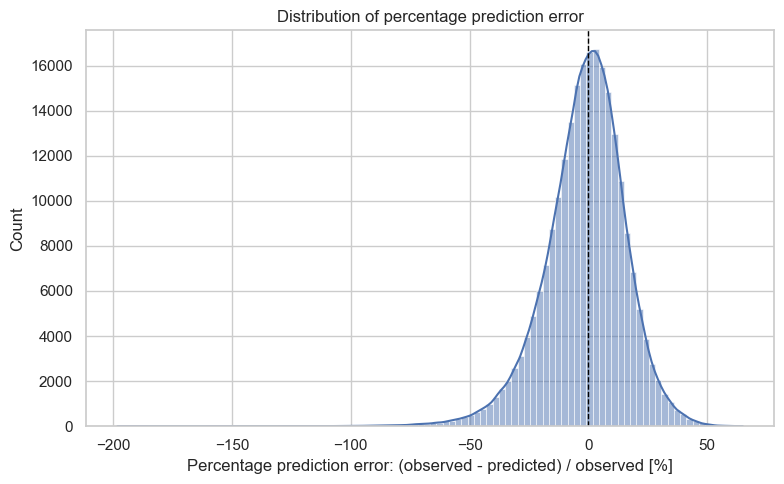

In [139]:
# ----------------------------
# 6.7.1 Error distribution and bias
# ----------------------------

# ----------------------------
# 1. Check required cross-validation outputs
# ----------------------------

required_cv_outputs = [
    "y_true_log_arr",
    "y_pred_log_arr"
]

missing_cv_outputs = [
    var for var in required_cv_outputs
    if var not in globals()
]

if missing_cv_outputs:
    raise RuntimeError(
        "Missing required cross-validation outputs: "
        f"{missing_cv_outputs}. "
        "Run Section 6.5 before running the predictive error diagnostics."
    )

# ----------------------------
# 2. Convert predictions back to original kWh scale
# ----------------------------

y_true_kwh_arr = np.exp(y_true_log_arr)
y_pred_kwh_arr = np.exp(y_pred_log_arr)

# ----------------------------
# 3. Percentage prediction error
# ----------------------------

# PE = (observed - predicted) / observed
# PE > 0  -> underprediction
# PE < 0  -> overprediction

pct_error = (
    y_true_kwh_arr - y_pred_kwh_arr
) / y_true_kwh_arr

pct_error_percent = pct_error * 100

# ----------------------------
# 4. Build prediction-error dataframe for later sections
# ----------------------------

indices_all = reg_data.index.values

error_df = pd.DataFrame({
    "idx": indices_all,
    "y_true_log": np.asarray(y_true_log_arr),
    "y_pred_log": np.asarray(y_pred_log_arr)
})

error_df = error_df.merge(
    reg_data.reset_index().rename(columns={"index": "idx"}),
    on="idx",
    how="left"
)

error_df["pc6"] = error_df["postcode"]

error_df["y_true"] = np.exp(error_df["y_true_log"])
error_df["y_pred"] = np.exp(error_df["y_pred_log"])

error_df["pct_error"] = (
    error_df["y_true"] - error_df["y_pred"]
) / error_df["y_true"]

error_df["pct_error_percent"] = error_df["pct_error"] * 100

error_df["abs_pct_error"] = np.abs(error_df["pct_error"])
error_df["abs_pct_error_percent"] = np.abs(error_df["pct_error_percent"])

# ----------------------------
# 5. Summary statistics
# ----------------------------

error_summary = pd.DataFrame({
    "Metric": [
        "Mean percentage error",
        "Median percentage error",
        "Share of underpredictions",
        "Share of overpredictions",
        "Share of exact predictions, numerically close to zero"
    ],
    "Value": [
        pct_error_percent.mean(),
        np.median(pct_error_percent),
        np.mean(pct_error > 0) * 100,
        np.mean(pct_error < 0) * 100,
        np.mean(np.isclose(pct_error, 0.0)) * 100
    ],
    "Unit": [
        "%",
        "%",
        "%",
        "%",
        "%"
    ]
})

error_summary = error_summary.round({
    "Value": 3
})

# ----------------------------
# 6. Error quantiles
# ----------------------------

error_quantiles = pd.DataFrame({
    "Quantile": [
        "0%",
        "5%",
        "10%",
        "25%",
        "50%",
        "75%",
        "90%",
        "95%",
        "100%"
    ],
    "Percentage_Error": np.percentile(
        pct_error_percent,
        [0, 5, 10, 25, 50, 75, 90, 95, 100]
    )
})

error_quantiles = error_quantiles.round({
    "Percentage_Error": 3
})

# ----------------------------
# 7. Single text-output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Prediction-error definition:</strong>
        PE = (observed - predicted) / observed
    </p>

    <p>
        <strong>Sign convention:</strong>
        positive values indicate underprediction;
        negative values indicate overprediction.
    </p>

    <h4 style="margin-bottom: 6px;">Summary statistics</h4>
    {error_summary.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Prediction-error quantiles</h4>
    {error_quantiles.to_html(index=False)}
</div>
"""

display(HTML(html_output))

# ----------------------------
# 8. Histogram of percentage prediction error
# ----------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    pct_error_percent,
    bins=100,
    kde=True
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Distribution of percentage prediction error")
plt.xlabel("Percentage prediction error: (observed - predicted) / observed [%]")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation of prediction error distribution and bias

**Bias and central tendency**

The mean percentage prediction error is approximately **-1.4%**, while the median percentage error is approximately **-0.1%**.

The negative mean indicates a slight overall tendency toward overprediction. However, the magnitude of this average bias is small. The median is very close to zero, which indicates that the typical prediction is well centered around the observed value.

The shares of underpredictions and overpredictions are also nearly balanced:

- underpredictions: **49.6%**
- overpredictions: **50.4%**

This suggests that the model does not systematically predict too high or too low across the sample as a whole.

**Typical prediction accuracy**

The interquartile range of the percentage prediction error extends from approximately:

- **-10.8%** at the 25th percentile
- to **+9.5%** at the 75th percentile

This means that half of the PC6 areas are predicted within roughly **-11% to +10%** of the observed electricity consumption.

The broader central 80% range extends from approximately:

- **-22.4%** at the 10th percentile
- to **+18.2%** at the 90th percentile

This indicates that most postcode areas have moderate relative prediction errors, while larger deviations are concentrated in the tails of the distribution.

**Tail behaviour and asymmetry**

The prediction-error distribution is asymmetric. The most extreme overprediction error is approximately **-198%**, while the strongest underprediction error is approximately **+65%**.

This asymmetry shows that the largest relative errors occur on the overprediction side. Because the percentage error is defined relative to the observed value, overprediction errors can become very large when observed electricity consumption is low. For example, an absolute error of several hundred kWh produces a much larger percentage error for a low-consumption PC6 than for a high-consumption PC6.

The histogram confirms this pattern. Most observations are concentrated close to zero, but the distribution has a longer left tail associated with overprediction cases.

**Overall assessment**

Overall, the preferred log-log model shows limited average bias and balanced frequencies of underprediction and overprediction. For the majority of PC6 areas, prediction errors remain moderate and centered around zero.

The main limitation is the presence of a small number of large relative overprediction errors. These cases motivate the more detailed investigation of extreme prediction cases and error patterns across postcode characteristics in the following subsections.

#### 6.7.2 Identification of extreme prediction cases

The previous subsection examined the overall distribution of prediction errors. While most observations are concentrated close to zero, the distribution also contains a small number of large relative errors. This subsection identifies these extreme cases more directly.

The analysis focuses on three groups of PC6 areas:

- the largest absolute percentage prediction errors;
- the strongest underprediction cases;
- the strongest overprediction cases.

The same percentage prediction error definition is used as in Section 6.7.1:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

where positive values indicate underprediction and negative values indicate overprediction.

The absolute percentage prediction error is defined as:

$$
|PE_i| = \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

The largest absolute errors show where the model performs least accurately overall. The strongest underprediction cases show PC6 areas where observed electricity consumption is substantially higher than predicted. The strongest overprediction cases show PC6 areas where predicted electricity consumption is substantially higher than observed consumption.

Because the predictions are obtained from cross-validation, these extreme cases are based on out-of-sample prediction errors rather than in-sample fitted residuals.

In [140]:
# ----------------------------
# 6.7.2 Identification of extreme prediction cases
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: error_df. "
        "Run Section 6.7.1 before running the extreme prediction-case diagnostics."
    )

required_error_cols = [
    "pc6",
    "y_true",
    "y_pred",
    "pct_error",
    "pct_error_percent",
    "abs_pct_error",
    "abs_pct_error_percent"
]

missing_error_cols = [
    col for col in required_error_cols
    if col not in error_df.columns
]

if missing_error_cols:
    raise RuntimeError(
        "error_df is missing required columns: "
        f"{missing_error_cols}. "
        "Run Section 6.7.1 again to rebuild error_df."
    )

# ----------------------------
# 2. Identify extreme cases
# ----------------------------

worst_cases = (
    error_df
    .sort_values("abs_pct_error", ascending=False)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

under_cases = (
    error_df
    .sort_values("pct_error", ascending=False)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

over_cases = (
    error_df
    .sort_values("pct_error", ascending=True)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

# ----------------------------
# 3. Select and format display columns
# ----------------------------

cols_display = [
    "pc6",
    "y_true",
    "y_pred",
    "pct_error_percent",
    "abs_pct_error_percent"
]

optional_context_cols = [
    "n_dwellings",
    "log_mean_floor_area",
    "mean_floor_area",
    "avg_household_size_filled",
    "share_has_gas"
]

cols_display = cols_display + [
    col for col in optional_context_cols
    if col in error_df.columns
]

def format_extreme_cases(df):
    out = df[cols_display].copy()

    rename_map = {
        "pc6": "PC6",
        "y_true": "Observed_kWh_per_dwelling",
        "y_pred": "Predicted_kWh_per_dwelling",
        "pct_error_percent": "Prediction_error_%",
        "abs_pct_error_percent": "Absolute_prediction_error_%",
        "n_dwellings": "Number_of_dwellings",
        "log_mean_floor_area": "Log_mean_floor_area",
        "mean_floor_area": "Mean_floor_area",
        "avg_household_size_filled": "Average_household_size",
        "share_has_gas": "Share_has_gas"
    }

    out = out.rename(columns=rename_map)

    round_cols = [
        col for col in out.columns
        if col != "PC6"
    ]

    out[round_cols] = out[round_cols].round(3)

    return out

worst_cases_display = format_extreme_cases(worst_cases)
under_cases_display = format_extreme_cases(under_cases)
over_cases_display = format_extreme_cases(over_cases)

# ----------------------------
# 4. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Extreme prediction-case diagnostics</strong>
    </p>

    <p>
        <strong>Sign convention:</strong>
        positive prediction errors indicate underprediction;
        negative prediction errors indicate overprediction.
    </p>

    <h4 style="margin-bottom: 6px;">Top 10 largest absolute prediction errors</h4>
    {worst_cases_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Top 10 underprediction cases</h4>
    {under_cases_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Top 10 overprediction cases</h4>
    {over_cases_display.to_html(index=False)}
</div>
"""

display(HTML(html_output))

PC6,Observed_kWh_per_dwelling,Predicted_kWh_per_dwelling,Prediction_error_%,Absolute_prediction_error_%,Number_of_dwellings,Mean_floor_area,Average_household_size,Share_has_gas
1022BB,530.0,1580.235,-198.158,198.158,16,73.250,1.9,0.938
9001AD,640.0,1854.891,-189.827,189.827,6,81.333,0.0,1.000
3563HE,870.0,2429.220,-179.221,179.221,23,130.435,1.1,0.130
7411BK,1160.0,3140.391,-170.723,170.723,1,283.000,1.0,0.000
3317DE,1990.0,5386.986,-170.703,170.703,8,186.250,3.2,0.000
1061BW,580.0,1493.212,-157.450,157.450,20,57.350,1.4,0.000
8442DM,840.0,2106.027,-150.717,150.717,11,104.182,1.3,0.545
1061CX,630.0,1570.813,-149.335,149.335,16,57.375,0.0,0.000
9722XB,550.0,1352.112,-145.839,145.839,5,43.200,0.0,0.000
2162BC,950.0,2287.195,-140.757,140.757,12,87.000,2.0,0.000


### Interpretation of extreme prediction cases

The extreme prediction cases provide additional insight into the behaviour of the preferred log-log regression model at the tails of the prediction-error distribution.

**General pattern**

The largest absolute prediction errors are dominated by overprediction cases. These are PC6 areas where the predicted electricity consumption is substantially higher than the observed value.

The strongest underprediction cases show the opposite pattern: observed electricity consumption is much higher than predicted. These cases generally correspond to PC6 areas with relatively high observed electricity consumption compared with what would be expected from their included structural and socioeconomic characteristics.

Overall, the table shows that the model performs less accurately for a small number of atypical postcode areas, especially where observed consumption is either unusually low or unusually high relative to the predictor values.

**Overprediction cases**

The strongest overprediction cases involve observed electricity consumption levels between approximately:

- **530 and 1,990 kWh per dwelling**

while predicted values range approximately between:

- **1,350 and 5,390 kWh per dwelling**

In these cases, the predicted electricity consumption is often more than twice the observed value. Because the percentage error is defined relative to observed consumption, these cases produce very large negative percentage errors, ranging from approximately:

- **-141% to -198%**

Several of these PC6 areas also have relatively small numbers of dwellings, and some have missing or zero household-size values. This suggests that the largest relative overprediction errors may partly reflect atypical postcode-level observations, small-area data sensitivity, or unobserved characteristics that are not captured by the model.

**Underprediction cases**

The strongest underprediction cases correspond to PC6 areas with observed electricity consumption levels between approximately:

- **3,150 and 5,730 kWh per dwelling**

while predicted values remain lower, typically between approximately:

- **1,260 and 2,200 kWh per dwelling**

The corresponding percentage prediction errors range from approximately:

- **+60% to +65%**

These postcode areas consume substantially more electricity than predicted by the model. Many of the strongest underprediction cases also have low gas-connection shares, often equal to zero. This suggests that some high-consumption PC6 areas may contain energy-use patterns or dwelling characteristics that are not fully captured by the included explanatory variables.

**Asymmetry of extreme errors**

The extreme prediction errors are asymmetric. The largest overprediction errors are larger in relative magnitude than the largest underprediction errors. This is consistent with the longer left tail observed in the prediction-error distribution in Section 6.7.1.

This asymmetry partly follows from the percentage-error definition. When observed consumption is low, even moderate absolute overprediction can become very large in percentage terms.

**Overall assessment**

Although extreme prediction errors exist, they are concentrated in a small subset of PC6 areas. For the majority of observations, prediction errors remain much closer to zero.

The extreme cases indicate that the model is less reliable at the tails of the electricity-consumption distribution and for some atypical postcode areas. These results motivate the broader investigation of systematic error patterns across postcode characteristics in the following subsection.

#### 6.7.3 Error patterns across postcode characteristics

The previous subsections examined the overall prediction-error distribution and the most extreme individual cases. This subsection investigates whether prediction errors vary systematically across postcode characteristics.

The analysis uses a binned diagnostic approach. Numeric variables are divided into quantile-based bins, and the mean and median percentage prediction error are computed within each bin. This makes it possible to assess whether prediction errors remain centered around zero across different segments of the data or whether some types of PC6 areas are more frequently overpredicted or underpredicted.

The diagnostic scan includes both explanatory variables and selected descriptive characteristics, such as the number of dwellings and the observed electricity-consumption level. The observed electricity-consumption level is included only as a diagnostic variable, not as an explanatory variable in the model. It is used to assess whether prediction errors are larger at the lower or upper end of the demand distribution.

For each variable, the range of mean and median prediction errors across bins is calculated. Larger ranges indicate stronger variation in prediction error across that variable. These diagnostics are descriptive and should not be interpreted causally. They are used to identify where the preferred log-log model performs more or less accurately.

In [141]:
# ----------------------------
# 6.7.3 Error patterns across postcode characteristics
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: error_df. "
        "Run Section 6.7.1 before running the error-pattern diagnostics."
    )

required_error_cols = [
    "pct_error_percent",
    "y_true"
]

missing_error_cols = [
    col for col in required_error_cols
    if col not in error_df.columns
]

if missing_error_cols:
    raise RuntimeError(
        "error_df is missing required columns: "
        f"{missing_error_cols}. "
        "Run Section 6.7.1 again to rebuild error_df."
    )

# ----------------------------
# 2. Define variables for binned diagnostics
# ----------------------------

exclude_cols = [
    "idx",
    "postcode",
    "pc6",
    "y_true_log",
    "y_pred_log",
    "y_pred",
    "pct_error",
    "pct_error_percent",
    "abs_pct_error",
    "abs_pct_error_percent",
    "kwh_avg_per_dwelling_pc6"
]

# Exclude other energy outcomes if present.
# y_true is kept deliberately as a diagnostic variable for observed electricity level.
energy_outcome_cols = [
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6",
    "kwh_gross_proxy_pc6"
]

exclude_cols = exclude_cols + [
    c for c in energy_outcome_cols
    if c in error_df.columns
]

analysis_vars = [
    c for c in error_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(error_df[c])
]

# Put the most useful diagnostic variables first if they exist
priority_vars = [
    "y_true",
    "n_dwellings",
    "mean_floor_area",
    "log_mean_floor_area",
    "share_has_gas",
    "avg_household_size_filled",
    "avg_woz_value_filled",
    "mean_building_year"
]

analysis_vars = (
    [v for v in priority_vars if v in analysis_vars]
    + [v for v in analysis_vars if v not in priority_vars]
)

# ----------------------------
# 3. Helper functions
# ----------------------------

def readable_var_name(var):
    rename_map = {
        "y_true": "Observed electricity consumption",
        "n_dwellings": "Number of dwellings",
        "mean_floor_area": "Mean floor area",
        "log_mean_floor_area": "Log mean floor area",
        "share_has_gas": "Share with gas connection",
        "avg_household_size_filled": "Average household size",
        "avg_woz_value_filled": "Average WOZ value",
        "mean_building_year": "Mean building year"
    }

    return rename_map.get(var, var)


def binned_error_table(df, var, n_bins=10):
    temp = df[[var, "pct_error_percent"]].dropna().copy()

    if temp[var].nunique() < 2:
        return None

    temp["bin"] = pd.qcut(
        temp[var],
        q=n_bins,
        duplicates="drop"
    )

    out = (
        temp
        .groupby("bin", observed=False)["pct_error_percent"]
        .agg(
            Mean_error_percent="mean",
            Median_error_percent="median",
            Count="count"
        )
        .reset_index()
    )

    out.insert(
        0,
        "Variable",
        readable_var_name(var)
    )

    out = out.rename(
        columns={
            "bin": "Bin"
        }
    )

    return out


def summarize_binned_error(df, var, n_bins=10):
    table = binned_error_table(
        df,
        var,
        n_bins=n_bins
    )

    if table is None or table.shape[0] < 2:
        return None

    mean_range = (
        table["Mean_error_percent"].max()
        - table["Mean_error_percent"].min()
    )

    median_range = (
        table["Median_error_percent"].max()
        - table["Median_error_percent"].min()
    )

    max_abs_mean = table["Mean_error_percent"].abs().max()
    max_abs_median = table["Median_error_percent"].abs().max()

    return {
        "Variable": readable_var_name(var),
        "Original_variable": var,
        "Number_of_bins": table.shape[0],
        "Mean_error_range_percentage_points": mean_range,
        "Median_error_range_percentage_points": median_range,
        "Max_abs_mean_error_percent": max_abs_mean,
        "Max_abs_median_error_percent": max_abs_median,
        "Total_observations": int(table["Count"].sum())
    }

# ----------------------------
# 4. Compute binned diagnostics
# ----------------------------

binned_results = {}
pattern_summary_records = []

for var in analysis_vars:
    table = binned_error_table(
        error_df,
        var,
        n_bins=10
    )

    summary = summarize_binned_error(
        error_df,
        var,
        n_bins=10
    )

    if table is not None and summary is not None:
        binned_results[var] = table
        pattern_summary_records.append(summary)

pattern_summary = pd.DataFrame(pattern_summary_records)

if pattern_summary.empty:
    raise RuntimeError(
        "No valid numeric variables were available for binned error diagnostics."
    )

pattern_summary = (
    pattern_summary
    .sort_values(
        "Median_error_range_percentage_points",
        ascending=False
    )
    .reset_index(drop=True)
)

pattern_summary_display = pattern_summary.round({
    "Mean_error_range_percentage_points": 3,
    "Median_error_range_percentage_points": 3,
    "Max_abs_mean_error_percent": 3,
    "Max_abs_median_error_percent": 3
})

# ----------------------------
# 5. Select detailed binned tables for display
# ----------------------------

# Show the strongest patterns, but avoid flooding the notebook.
top_detail_vars = (
    pattern_summary["Original_variable"]
    .head(5)
    .tolist()
)

# Ensure key diagnostics are included if available
for key_var in [
    "y_true",
    "n_dwellings",
    "mean_floor_area",
    "share_has_gas"
]:
    if key_var in binned_results and key_var not in top_detail_vars:
        top_detail_vars.append(key_var)

# Limit detailed tables to keep output manageable
top_detail_vars = top_detail_vars[:8]

detailed_tables_html = ""

for var in top_detail_vars:
    table_display = binned_results[var].copy()

    table_display["Bin"] = table_display["Bin"].astype(str)

    table_display = table_display.round({
        "Mean_error_percent": 3,
        "Median_error_percent": 3
    })

    detailed_tables_html += f"""
    <h4 style="margin-bottom: 6px; margin-top: 16px;">
        Error by {readable_var_name(var)}
    </h4>
    {table_display.to_html(index=False)}
    """

# ----------------------------
# 6. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Binned prediction-error diagnostics</strong>
    </p>

    <p>
        Variables are grouped into quantile-based bins. 
        Mean and median prediction errors are reported in percentage points.
    </p>

    <h4 style="margin-bottom: 6px;">Variables with strongest binned error variation</h4>
    {pattern_summary_display.head(15).to_html(index=False)}

    {detailed_tables_html}
</div>
"""

display(HTML(html_output))

Variable,Original_variable,Number_of_bins,Mean_error_range_percentage_points,Median_error_range_percentage_points,Max_abs_mean_error_percent,Max_abs_median_error_percent,Total_observations
Observed electricity consumption,y_true,10,32.554,30.331,20.701,18.362,234882
Share with gas connection,share_has_gas,3,5.050,5.780,2.564,3.565,234882
Average household size,avg_household_size_filled,10,4.893,5.268,4.837,4.077,234882
population_total,population_total,9,4.366,3.476,4.098,2.339,233764
Mean floor area,mean_floor_area,10,2.457,3.172,2.716,1.974,234882
private_households_total,private_households_total,6,3.948,2.633,3.017,1.350,232449
Mean building year,mean_building_year,10,2.538,2.493,3.024,1.784,234882
share_dwelling_type_unknown,share_dwelling_type_unknown,9,2.483,2.378,2.903,1.708,234882
share_energy_label_no_label,share_energy_label_no_label,9,2.480,2.374,2.904,1.708,234882
Average WOZ value,avg_woz_value_filled,10,2.105,2.316,2.371,1.204,234882


### Interpretation of error patterns across postcode characteristics

The binned diagnostic scan shows that prediction errors vary most strongly across the level of observed electricity consumption. This is the clearest pattern in the results. The range of median prediction errors across observed-consumption bins is approximately **30 percentage points**, which is much larger than for the other postcode characteristics.

For observed electricity consumption, the mean prediction error moves from approximately **-20.7%** in the lowest consumption bin to approximately **+11.9%** in the highest consumption bin. The median error follows the same pattern, increasing from approximately **-18.4%** to **+12.0%**. This indicates that the model tends to overpredict low-consumption PC6 areas and underpredict high-consumption PC6 areas.

Compared with this demand-level pattern, the variation across most structural and socioeconomic characteristics is much smaller. The median error range is approximately:

- **5.8 percentage points** for gas-connection share
- **5.3 percentage points** for average household size
- **3.5 percentage points** for total population
- **3.2 percentage points** for mean floor area
- **2.5 percentage points** for mean building year

This suggests that the remaining prediction error is more strongly related to the position of a PC6 area within the electricity-consumption distribution than to any single housing or socioeconomic characteristic examined in the binned scan.

Some weaker patterns are still visible. PC6 areas with intermediate gas-connection shares show more positive median errors, while the lowest and highest gas-share bins show negative or near-zero median errors. Average household size also shows some variation, with more negative errors at the lowest and highest household-size bins and errors closer to zero in the middle of the distribution. However, these patterns are modest compared with the error variation across observed electricity-consumption levels.

The number of dwellings does not show a strong monotonic pattern. Mean errors are slightly negative across all dwelling-count bins, while median errors remain close to zero. This suggests that postcode size may contribute to some residual variation, but it is not the dominant source of systematic prediction error.

Overall, the preferred log-log model performs best in the central part of the electricity-consumption distribution and less accurately at the lower and upper tails. The main remaining limitation is therefore scale-dependent prediction error: low-consumption PC6 areas tend to be overpredicted, while high-consumption PC6 areas tend to be underpredicted.

#### 6.7.4 Prediction error across electricity-consumption levels

The binned diagnostic scan in Section 6.7.3 shows that prediction errors vary most strongly across observed electricity-consumption levels. This subsection therefore visualizes this pattern directly.

PC6 areas are grouped into deciles based on observed average electricity consumption per dwelling. For each decile, the mean and median percentage prediction error are calculated. This allows the direction and magnitude of prediction error to be compared across the electricity-consumption distribution.

,Bin_label,Mean_error_percent,Median_error_percent,Count
0,"(529.999, 1580.0]",-20.701,-18.362,23874
1,"(1580.0, 1850.0]",-9.072,-7.710,23162
2,"(1850.0, 2080.0]",-5.615,-4.613,24218
3,"(2080.0, 2270.0]",-3.514,-2.959,23427
4,"(2270.0, 2450.0]",-1.488,-1.171,24049
5,"(2450.0, 2620.0]",0.533,0.948,22714
6,"(2620.0, 2810.0]",2.711,3.256,22992
7,"(2810.0, 3060.0]",4.863,5.391,23496
8,"(3060.0, 3510.0]",7.237,7.496,23736
9,"(3510.0, 8640.0]",11.854,11.969,23214


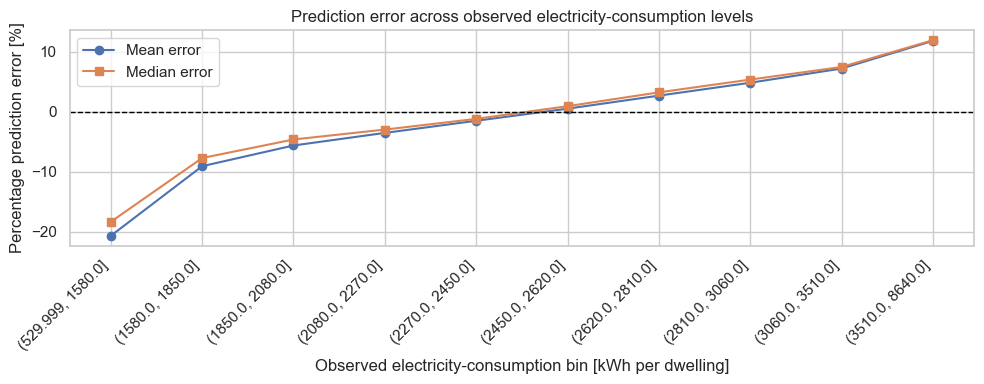

In [142]:
# ----------------------------
# 6.7.4 Prediction error across electricity-consumption levels
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: error_df. "
        "Run Section 6.7.1 before running this diagnostic."
    )

required_cols = [
    "y_true",
    "pct_error_percent"
]

missing_cols = [
    col for col in required_cols
    if col not in error_df.columns
]

if missing_cols:
    raise RuntimeError(
        "error_df is missing required columns: "
        f"{missing_cols}. "
        "Run Section 6.7.1 again to rebuild error_df."
    )

# ----------------------------
# 2. Create consumption deciles
# ----------------------------

consumption_error_df = error_df[
    [
        "y_true",
        "pct_error_percent"
    ]
].dropna().copy()

consumption_error_df["consumption_bin"] = pd.qcut(
    consumption_error_df["y_true"],
    q=10,
    duplicates="drop"
)

# ----------------------------
# 3. Compute mean and median error by bin
# ----------------------------

consumption_error_bins = (
    consumption_error_df
    .groupby("consumption_bin", observed=False)["pct_error_percent"]
    .agg(
        Mean_error_percent="mean",
        Median_error_percent="median",
        Count="count"
    )
    .reset_index()
)

consumption_error_bins["Bin_label"] = (
    consumption_error_bins["consumption_bin"]
    .astype(str)
)

consumption_error_bins_display = consumption_error_bins.copy()

consumption_error_bins_display = consumption_error_bins_display.round({
    "Mean_error_percent": 3,
    "Median_error_percent": 3
})

# ----------------------------
# 4. Display table
# ----------------------------

display(
    consumption_error_bins_display[
        [
            "Bin_label",
            "Mean_error_percent",
            "Median_error_percent",
            "Count"
        ]
    ]
)

# ----------------------------
# 5. Plot prediction error across consumption bins
# ----------------------------

plt.figure(figsize=(10, 4))

x = np.arange(len(consumption_error_bins))

plt.plot(
    x,
    consumption_error_bins["Mean_error_percent"],
    marker="o",
    label="Mean error"
)

plt.plot(
    x,
    consumption_error_bins["Median_error_percent"],
    marker="s",
    label="Median error"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    consumption_error_bins["Bin_label"],
    rotation=45,
    ha="right"
)

plt.ylabel("Percentage prediction error [%]")
plt.xlabel("Observed electricity-consumption bin [kWh per dwelling]")

plt.title(
    "Prediction error across observed electricity-consumption levels"
)

plt.legend()

plt.tight_layout()
plt.show()

### 6.8 Robustness extension: gross electricity consumption proxy

The main electricity models use the CBS electricity-consumption variable as the dependent variable. This variable represents average electricity consumption per dwelling as observed from grid connection data. However, CBS states that this consumption excludes electricity generated within private homes, such as electricity generated by rooftop solar panels.

As a result, the dependent variable should be interpreted as net grid electricity consumption rather than total gross household electricity demand.

To assess whether this affects the modelling results, this section constructs an approximate gross electricity-consumption proxy. The proxy adds an estimate of behind-the-meter PV self-consumption back to the observed CBS electricity-consumption variable.

The available PV variable represents exported PV electricity rather than total household PV production. Therefore, the self-consumed component cannot be added directly as a fixed percentage of exported electricity.

Instead, household PV production is reconstructed assuming that households directly self-consume 30\% of total PV generation and export the remaining 70\%.

The relationship is defined as:

$$
pv_{export,pc6}
=
0.70
\cdot
pv_{total,pc6}
$$

which implies:

$$
pv_{total,pc6}
=
\frac{
pv_{export,pc6}
}{
0.70
}
$$

The self-consumed component is then calculated as:

$$
pv_{self,pc6}
=
0.30
\cdot
pv_{total,pc6}
=
\frac{
0.30
}{
0.70
}
\cdot
pv_{export,pc6}
$$

The gross electricity proxy is finally defined as:

$$
kwh_{gross\_proxy,pc6}
=
kwh_{avg\_per\_dwelling,pc6}
+
pv_{self,pc6}
$$

where:

- $kwh_{avg\_per\_dwelling,pc6}$ denotes observed average annual net electricity consumption per dwelling  
- $pv_{export,pc6}$ denotes average annual exported PV electricity per dwelling  
- $pv_{total,pc6}$ denotes reconstructed total PV production per dwelling  
- $pv_{self,pc6}$ denotes estimated self-consumed PV electricity per dwelling  

This reconstructed variable should not be interpreted as measured gross household electricity demand. It is a robustness proxy based on an explicit behavioural assumption regarding household PV self-consumption. The objective is to evaluate whether the main regression results are sensitive to the fact that the original CBS electricity-consumption variable reflects net grid demand rather than gross residential electricity demand.

In [167]:
# ----------------------------
# 6.8.1 Gross electricity consumption proxy models
# 30% self-consumption of total PV production
# ----------------------------

# ----------------------------
# 1. Assumptions
# ----------------------------

self_consumption_share = 0.30
export_share = 1 - self_consumption_share

# ----------------------------
# 2. Required columns
# ----------------------------

required_cols_gross = [
    "kwh_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]

missing_cols_gross = [
    col for col in required_cols_gross
    if col not in pc6_analysis.columns
]

if missing_cols_gross:
    raise KeyError(
        f"Missing required columns for gross proxy construction: {missing_cols_gross}"
    )

# ----------------------------
# 3. Construct PV components
# ----------------------------

pc6_analysis["pv_export_avg_per_dwelling_pc6"] = (
    pc6_analysis["pv_avg_per_dwelling_pc6"]
)

pc6_analysis["pv_total_proxy_avg_per_dwelling_pc6"] = (
    pc6_analysis["pv_export_avg_per_dwelling_pc6"]
    /
    export_share
)

pc6_analysis["pv_self_consumed_proxy_avg_per_dwelling_pc6"] = (
    self_consumption_share
    *
    pc6_analysis["pv_total_proxy_avg_per_dwelling_pc6"]
)

# Equivalent check:
# pv_self = (0.30 / 0.70) * pv_export

# ----------------------------
# 4. Construct gross electricity proxy
# ----------------------------

pc6_analysis["kwh_gross_proxy_pc6"] = (
    pc6_analysis["kwh_avg_per_dwelling_pc6"]
    +
    pc6_analysis["pv_self_consumed_proxy_avg_per_dwelling_pc6"]
)

# ----------------------------
# 5. Align gross proxy with original regression sample
# ----------------------------

y_gross_linear = pc6_analysis.loc[
    X.index,
    "kwh_gross_proxy_pc6"
].copy()

if y_gross_linear.isna().any():
    raise ValueError(
        "The gross electricity proxy contains missing values in the regression sample. "
        "Check kwh_avg_per_dwelling_pc6 and pv_avg_per_dwelling_pc6."
    )

if (y_gross_linear <= 0).any():
    raise ValueError(
        "The gross electricity proxy contains zero or negative values. "
        "Log models require strictly positive dependent-variable values."
    )

y_gross_log = np.log(
    y_gross_linear
)

# ----------------------------
# 6. Estimate gross proxy models
# ----------------------------

# Linear gross proxy model
X_gross_linear = X.copy()

model_linear_gross = sm.OLS(
    y_gross_linear,
    X_gross_linear
).fit()

# Log-level gross proxy model
X_gross_log = X.copy()

model_log_gross = sm.OLS(
    y_gross_log,
    X_gross_log
).fit()

# Log-log gross proxy model
X_gross_loglog = X.copy()

X_gross_loglog["log_mean_floor_area"] = np.log(
    X_gross_loglog["mean_floor_area"]
)

X_gross_loglog = X_gross_loglog.drop(
    columns=["mean_floor_area"]
)

model_loglog_gross = sm.OLS(
    y_gross_log,
    X_gross_loglog
).fit()

# ----------------------------
# 7. Sanity checks
# ----------------------------

gross_proxy_summary = pc6_analysis.loc[
    X.index,
    [
        "kwh_avg_per_dwelling_pc6",
        "pv_export_avg_per_dwelling_pc6",
        "pv_total_proxy_avg_per_dwelling_pc6",
        "pv_self_consumed_proxy_avg_per_dwelling_pc6",
        "kwh_gross_proxy_pc6"
    ]
].describe()

mean_added_self_consumption = (
    pc6_analysis.loc[
        X.index,
        "pv_self_consumed_proxy_avg_per_dwelling_pc6"
    ]
    .mean()
)

mean_net = (
    pc6_analysis.loc[
        X.index,
        "kwh_avg_per_dwelling_pc6"
    ]
    .mean()
)

mean_gross = (
    y_gross_linear
    .mean()
)

print("Gross electricity proxy models re-estimated.")
print("Self-consumption share of total PV production:", self_consumption_share)
print("Export share of total PV production:", export_share)
print(
    "Self-consumed PV is calculated as "
    "(self_consumption_share / export_share) * PV export."
)

print("\nMean net electricity:")
print(round(mean_net, 2))

print("\nMean added self-consumed PV:")
print(round(mean_added_self_consumption, 2))

print("\nMean gross electricity proxy:")
print(round(mean_gross, 2))

print("\nMean difference between gross proxy and net electricity:")
print(round(mean_gross - mean_net, 2))

display(
    gross_proxy_summary
)

Gross electricity proxy models re-estimated.
Self-consumption share of total PV production: 0.3
Export share of total PV production: 0.7
Self-consumed PV is calculated as (self_consumption_share / export_share) * PV export.

Mean net electricity:
2521.63

Mean added self-consumed PV:
115.27

Mean gross electricity proxy:
2636.89

Mean difference between gross proxy and net electricity:
115.27


,kwh_avg_per_dwelling_pc6,pv_export_avg_per_dwelling_pc6,pv_total_proxy_avg_per_dwelling_pc6,pv_self_consumed_proxy_avg_per_dwelling_pc6,kwh_gross_proxy_pc6
count,234882.000000,234882.000000,234882.000000,234882.000000,234882.000000
mean,2521.628520,268.952460,384.217800,115.265340,2636.893860
std,802.443824,541.717694,773.882420,232.164726,880.489726
min,530.000000,0.000000,0.000000,0.000000,530.000000
25%,1970.000000,0.000000,0.000000,0.000000,2030.000000
50%,2450.000000,0.000000,0.000000,0.000000,2540.000000
75%,2930.000000,306.000000,437.142857,131.142857,3076.714286
max,8640.000000,17977.000000,25681.428571,7704.428571,11544.428571


#### 6.8.2 Comparison and residual diagnostics for the gross electricity proxy

The gross electricity proxy models are compared with the original electricity models using the same model-fit criteria applied earlier in Chapter 6.

The comparison includes:

- adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ is used to compare explanatory power while accounting for model complexity. AIC and BIC are reported as model-selection criteria, but they should be interpreted mainly within models estimated on the same dependent-variable scale.

Residual diagnostics are also examined to assess whether the gross proxy changes the residual structure of the electricity models. The diagnostics include:

- residual histograms for the full distribution and central 98% of residuals  
- residuals versus fitted-value plots  
- hexbin residual-density plots  

The hexbin plots are included because the dataset contains a very large number of PC6 observations. They make it easier to identify dense residual patterns and heteroskedasticity compared with standard scatter plots.

The aim of this section is not to replace the original CBS net electricity-consumption model, but to evaluate whether the main results are robust to an approximate correction for behind-the-meter PV self-consumption.

In [168]:
# ----------------------------
# 6.8.2 Comparison and residual diagnostics
# for gross electricity proxy models
# ----------------------------

gross_comparison_raw = pd.DataFrame({
    "Model": [
        "Linear original",
        "Linear gross proxy",
        "Log-level original",
        "Log-level gross proxy",
        "Log-log original",
        "Log-log gross proxy"
    ],
    "Dependent_variable": [
        "CBS net electricity",
        "Gross proxy",
        "log(CBS net electricity)",
        "log(Gross proxy)",
        "log(CBS net electricity)",
        "log(Gross proxy)"
    ],
    "Observations": [
        int(model_linear.nobs),
        int(model_linear_gross.nobs),
        int(model_log.nobs),
        int(model_log_gross.nobs),
        int(model_loglog.nobs),
        int(model_loglog_gross.nobs)
    ],
    "Adj_R2": [
        model_linear.rsquared_adj,
        model_linear_gross.rsquared_adj,
        model_log.rsquared_adj,
        model_log_gross.rsquared_adj,
        model_loglog.rsquared_adj,
        model_loglog_gross.rsquared_adj
    ],
    "AIC": [
        model_linear.aic,
        model_linear_gross.aic,
        model_log.aic,
        model_log_gross.aic,
        model_loglog.aic,
        model_loglog_gross.aic
    ],
    "BIC": [
        model_linear.bic,
        model_linear_gross.bic,
        model_log.bic,
        model_log_gross.bic,
        model_loglog.bic,
        model_loglog_gross.bic
    ]
})

# Add within-family adjusted R² changes
original_adj_r2 = {
    "Linear gross proxy": model_linear.rsquared_adj,
    "Log-level gross proxy": model_log.rsquared_adj,
    "Log-log gross proxy": model_loglog.rsquared_adj
}

gross_comparison_raw["Adj_R2_change_vs_original"] = np.nan

for gross_model, original_value in original_adj_r2.items():
    gross_comparison_raw.loc[
        gross_comparison_raw["Model"] == gross_model,
        "Adj_R2_change_vs_original"
    ] = (
        gross_comparison_raw.loc[
            gross_comparison_raw["Model"] == gross_model,
            "Adj_R2"
        ].iloc[0]
        -
        original_value
    )

gross_comparison = gross_comparison_raw.round({
    "Adj_R2": 4,
    "Adj_R2_change_vs_original": 4,
    "AIC": 1,
    "BIC": 1
})

display(gross_comparison)

,Model,Dependent_variable,Observations,Adj_R2,AIC,BIC,Adj_R2_change_vs_original
0,Linear original,CBS net electricity,234882,0.7177,3511173.4,3511474.0,NaN
1,Linear gross proxy,Gross proxy,234882,0.7083,3562447.7,3562748.3,-0.0094
2,Log-level original,log(CBS net electricity),234882,0.7120,-171657.3,-171356.6,NaN
3,Log-level gross proxy,log(Gross proxy),234882,0.7148,-153284.6,-152984.0,0.0028
4,Log-log original,log(CBS net electricity),234882,0.7202,-178370.8,-178070.2,NaN
5,Log-log gross proxy,log(Gross proxy),234882,0.7238,-160826.5,-160525.9,0.0037


### Interpretation of the gross electricity proxy results

The gross electricity proxy is used as a robustness check for the fact that the CBS electricity-consumption variable represents net grid electricity consumption and excludes electricity generated and directly consumed within private homes. The proxy approximates gross residential electricity demand by adding an estimated self-consumed PV component derived from exported PV generation under a 30\% self-consumption assumption.

The comparison shows that the gross proxy specifications produce results that remain broadly consistent with the original CBS net-consumption models. Model performance changes only modestly after introducing the PV self-consumption correction.

| Model family | Original adjusted \(R^2\) | Gross proxy adjusted \(R^2\) | Change |
|---|---:|---:|---:|
| Linear | 0.7177 | 0.7083 | -0.0094 |
| Log-level | 0.7120 | 0.7148 | +0.0028 |
| Log-log | 0.7202 | 0.7238 | +0.0037 |

The linear specification exhibits a small reduction in explanatory power after introducing the gross-consumption proxy, while both logarithmic specifications show only marginal improvements. The largest change occurs for the log-log specification, where adjusted \(R^2\) increases from 0.7202 to 0.7238. However, the magnitude of this increase is small relative to the overall model performance.

These results suggest that correcting for behind-the-meter PV self-consumption does not substantially alter the spatial relationships captured by the regression models. Structural housing characteristics and socioeconomic variables appear to explain postcode-level variation similarly whether residential electricity demand is represented as observed net grid consumption or as an approximate gross-demand measure.

The AIC and BIC values should be interpreted cautiously. Because the gross proxy changes the dependent variable, direct comparison of absolute AIC and BIC values between the original and gross-proxy models is not appropriate. These criteria remain most informative for comparing alternative functional forms within the same dependent-variable family.

Within the gross-proxy model family, the log-log specification remains the strongest-performing model, achieving the highest adjusted \(R^2\). This is consistent with the model-selection outcome obtained for the original CBS electricity-consumption variable.

Overall, the robustness exercise supports the main modelling framework rather than motivating a change in the dependent variable. Introducing an approximate correction for household PV self-consumption produces only limited changes in model performance and does not affect the preferred functional form. Therefore, the original CBS net electricity-consumption variable is retained as the primary dependent variable because it represents an official measured quantity and avoids introducing additional behavioural assumptions regarding household self-consumption.

### 6.9 Random Forest feature-importance analysis

Chapter 6 showed that the preferred log-log regression model provides an interpretable and empirically adequate specification for modelling postcode-level electricity consumption. The Random Forest benchmark achieved somewhat lower prediction error, indicating that nonlinear relationships and interactions may contain additional predictive information.

The purpose of this chapter is not to replace the regression model, but to use the fitted Random Forest benchmark as a complementary diagnostic tool. Because Random Forest does not provide directly interpretable coefficients, predictor relevance is assessed using feature-importance measures.

Two measures are used:

1. impurity-based importance, also known as mean decrease in impurity;
2. permutation importance.

Both measures should be interpreted as indicators of predictive relevance within the fitted Random Forest model. They do not represent causal effects. This distinction is important because the analysis is based on observational PC6-level data and because several predictors, especially dwelling-type shares and energy-label shares, are correlated or compositional.

In [ ]:
# ----------------------------
# 6.9 Random Forest feature importance
# Reuse final fitted Random Forest from Section 6.6
# ----------------------------

from sklearn.inspection import permutation_importance
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

# ----------------------------
# 1. Sanity check: ensure RF model is fitted
# ----------------------------

try:
    check_is_fitted(rf_model_exp)
except NotFittedError:
    raise RuntimeError(
        "rf_model_exp is not fitted. "
        "Run Section 6.6 first, including the final line: "
        "rf_model_exp.fit(X_rf_sklearn, y_rf_log)."
    )

print("Number of predictors in X_rf_sklearn:", X_rf_sklearn.shape[1])
print("Number of RF importances:", len(rf_model_exp.feature_importances_))

if X_rf_sklearn.shape[1] != len(rf_model_exp.feature_importances_):
    raise ValueError(
        "Mismatch between number of predictors and RF feature importances. "
        "Check that X_rf_sklearn is the same predictor matrix used to fit rf_model_exp."
    )

# ----------------------------
# 2. Impurity-based importance
# ----------------------------

rf_gini_importance = pd.DataFrame({
    "Variable": X_rf_sklearn.columns,
    "Impurity_Importance": rf_model_exp.feature_importances_
})

rf_gini_importance = (
    rf_gini_importance
    .sort_values("Impurity_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_gini_importance)

# ----------------------------
# 3. Permutation importance
# ----------------------------

perm_result = permutation_importance(
    rf_model_exp,
    X_rf_sklearn,
    y_rf_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

rf_perm_importance = pd.DataFrame({
    "Variable": X_rf_sklearn.columns,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_SD": perm_result.importances_std
})

rf_perm_importance = (
    rf_perm_importance
    .sort_values("Permutation_Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

display(rf_perm_importance)

Number of predictors in X_rf_sklearn: 28
Number of RF importances: 28


,Variable,Impurity_Importance
0,log_mean_floor_area,0.692207
1,avg_household_size_filled,0.138877
2,share_has_gas,0.028026
3,avg_woz_value_filled,0.027466
4,mean_building_year,0.021017
5,share_energy_label_no_label,0.012094
6,share_dwelling_type_Rijwoning tussen,0.011546
7,share_energy_label_A,0.008644
8,share_dwelling_type_unknown,0.007589
9,share_energy_label_C,0.007412


,Variable,Permutation_Importance_Mean,Permutation_Importance_SD
0,log_mean_floor_area,0.062340,2.842988e-04
1,avg_household_size_filled,0.026037,7.659623e-05
2,share_has_gas,0.008331,3.394392e-05
3,avg_woz_value_filled,0.006862,2.340452e-05
4,mean_building_year,0.003934,1.892661e-05
5,share_dwelling_type_Rijwoning tussen,0.003089,1.385789e-05
6,share_energy_label_no_label,0.002967,8.874769e-06
7,share_energy_label_A,0.002180,7.028265e-06
8,share_dwelling_type_unknown,0.001616,9.333575e-06
9,share_dwelling_type_Twee-onder-een-kap / rijwo...,0.001463,5.776201e-06


### Interpretation of Random Forest feature importance

Permutation importance is treated as the primary feature-importance measure because it evaluates how much prediction error increases when each predictor is randomly shuffled. The values therefore indicate predictive relevance within the fitted Random Forest model.

The ranking shows that `log_mean_floor_area` is the most important predictor. Its permutation importance is clearly higher than that of the other variables, suggesting that average dwelling size is the main variable used by the Random Forest when predicting average electricity consumption per dwelling.

The second-ranked variable is `avg_household_size_filled`, followed by `share_has_gas`, `avg_woz_value_filled`, and `mean_building_year`. These variables also contribute to prediction, but their importance values are noticeably lower than that of floor area.

| Rank | Variable | Permutation importance |
|---:|---|---:|
| 1 | `log_mean_floor_area` | 0.0623 |
| 2 | `avg_household_size_filled` | 0.0260 |
| 3 | `share_has_gas` | 0.0083 |
| 4 | `avg_woz_value_filled` | 0.0069 |
| 5 | `mean_building_year` | 0.0039 |
| 6 | `share_dwelling_type_Rijwoning tussen` | 0.0031 |
| 7 | `share_energy_label_no_label` | 0.0030 |
| 8 | `share_energy_label_A` | 0.0022 |

The ranking suggests that the Random Forest relies mostly on a small set of structural and socioeconomic variables. Dwelling-type and energy-label shares appear lower in the ranking. Some of these variables still contribute to prediction, but their individual importance values are relatively small.

The impurity-based importance results are broadly consistent with the permutation ranking. They also place `log_mean_floor_area` first, followed by `avg_household_size_filled`, `share_has_gas`, `avg_woz_value_filled`, and `mean_building_year`. However, the impurity-based measure assigns a very large share of total importance to `log_mean_floor_area`. This should be interpreted cautiously, because impurity-based importance reflects the internal splitting behaviour of the forest and can be more concentrated than permutation importance.

Overall, both measures indicate that floor area is the dominant predictor in the Random Forest benchmark, followed by household size, gas-connection share, WOZ value, and building year. The composition variables related to dwelling type and energy labels provide additional predictive information, but they are not the main drivers of the Random Forest predictions.

These results should be interpreted only as measures of predictive contribution within the fitted model. They do not imply causal effects. In addition, correlated or compositional variables may share importance, so the ranking should not be read as a precise independent contribution of each individual predictor.

### 6.10 Concluding remarks for Chapter 6

This chapter examined how postcode-level housing-stock characteristics and socioeconomic variables are associated with average electricity consumption per dwelling. The analysis developed, compared, and validated alternative regression specifications at the PC6 level.

Three OLS specifications were estimated: a linear model in levels, a log-level model with a logarithmic dependent variable, and a log-log model with both the dependent variable and average floor area expressed logarithmically. The comparison showed that the log-based specifications improved residual behaviour relative to the linear model. Among these, the log-log specification provided the strongest overall balance between explanatory performance, residual stability, and interpretability.

The preferred log-log model indicates that electricity consumption per dwelling is systematically associated with several housing-stock and socioeconomic characteristics. Larger average floor area is associated with higher electricity consumption, while gas-connection share, building age, dwelling-type composition, energy-label composition, household size, and WOZ value also contribute to the model. However, these relationships should not be interpreted as causal effects. They describe conditional statistical associations across PC6 areas after accounting for the other included variables.

The multicollinearity assessment showed that most structural and socioeconomic variables have acceptable VIF values, while some composition-related variables, especially `share_energy_label_no_label`, `share_dwelling_type_unknown`, and selected energy-label shares, show elevated VIF values. This does not invalidate the model, but it means that individual coefficients for highly collinear composition variables should be interpreted cautiously. The results are therefore most useful for understanding broader patterns across housing-stock characteristics rather than assigning precise independent importance to every individual category.

The predictive assessment showed that the preferred log-log regression generalizes meaningfully beyond the estimation sample. In 10-fold cross-validation, it performs substantially better than a naive baseline that predicts only the mean of the dependent variable. This indicates that the included structural, compositional, and socioeconomic variables contain meaningful predictive information for average electricity consumption per dwelling at PC6 level.

The predictive error diagnostics showed that the model is well centered overall, with nearly balanced underprediction and overprediction frequencies. However, errors are not distributed entirely uniformly. The clearest remaining pattern is scale-dependent: low-consumption PC6 areas tend to be overpredicted, while high-consumption PC6 areas tend to be underpredicted. This indicates that the log-log specification improves model behaviour but does not fully remove systematic error at the tails of the electricity-consumption distribution.

The Random Forest benchmark achieved lower prediction error than the preferred regression model, suggesting that nonlinear relationships and interactions contain some additional predictive information. However, the improvement was incremental rather than transformative. The Random Forest also lacks the coefficient-level interpretability of the regression model. For this reason, it is retained as a nonlinear predictive benchmark and as a complementary tool for feature-importance diagnostics, not as the main analytical model.

The Random Forest feature-importance analysis further showed that prediction in the nonlinear benchmark relies most strongly on average floor area, followed by household size, gas-connection share, WOZ value, and building year. Dwelling-type and energy-label shares provide additional predictive information, but their individual importance values are generally smaller. These rankings should be interpreted only as model-based indicators of predictive relevance, not as causal effects or independent contributions.

The gross electricity proxy robustness check showed that adding an assumed self-consumed share of PV production does not materially change the main modelling conclusion. The log-log specification remains the preferred functional form. The original CBS electricity-consumption variable is therefore retained as the main dependent variable because it is an official measured variable, while the gross proxy depends on an additional self-consumption assumption.

Overall, Chapter 6 shows that postcode-level structural and socioeconomic variables contain substantial predictive and explanatory information for average electricity consumption per dwelling. The preferred log-log regression provides a defensible main specification because it combines strong predictive performance, improved residual behaviour, and clear interpretability. At the same time, the validation results show that the model should be interpreted as a statistical prediction framework rather than as a causal explanation of household electricity demand.

## 7️⃣ PC6-level gas regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to gas demand. These analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint association of multiple housing-stock and socioeconomic characteristics with gas consumption.

The purpose of this chapter is to estimate statistical models that relate postcode-level gas demand to the structural and socioeconomic composition of the housing stock. The structure mirrors the electricity regression analysis in Chapter 6 as closely as possible, while accounting for gas-specific modelling issues.

Two objectives are pursued.

First, regression models are used to assess how average dwelling size, construction year, gas availability, dwelling-type composition, energy-label composition, and selected CBS socioeconomic variables are associated with average gas consumption across PC6 areas.

Second, the preferred gas regression specification is selected and validated using the same general framework applied to electricity demand: model-fit metrics, residual diagnostics, out-of-sample predictive assessment, predictive error diagnostics, multicollinearity assessment, and comparison with a nonlinear Random Forest benchmark.

The unit of analysis is the PC6 postcode area. Each observation represents one postcode area and combines information on gas consumption, housing structure, and socioeconomic characteristics.

The dependent variable is defined as:

- `gas_avg_per_dwelling_pc6` — average annual gas consumption per dwelling within each PC6 area

This variable is used instead of total gas consumption because total gas consumption is strongly influenced by the number of dwellings in a postcode area. By focusing on average consumption per dwelling, the analysis examines differences in gas intensity across postcode areas rather than differences in postcode size.

A gas-specific complication is that gas consumption can be zero or very low in some postcode areas. Zero values may correspond to areas without residential gas use and cannot be included in logarithmic specifications. Very low positive values may also represent atypical gas use, such as cooking or partial gas use, rather than gas use as the main heating source. Therefore, the base regression dataset is first restricted to PC6 areas with strictly positive gas consumption, while a separate robustness check evaluates the effect of excluding very low positive gas-consumption observations.

The explanatory variables are grouped into three categories.

**Structural variables**

- average dwelling floor area
- average construction year
- share of dwellings connected to gas

**Compositional variables**

- dwelling-type shares at postcode level
- energy-label shares at postcode level

**Socioeconomic variables from CBS**

- average WOZ value
- average household size, with a missingness indicator where relevant
- share of population receiving social benefits

To avoid perfect multicollinearity, one category is omitted from each set of compositional shares and used as a reference group in the regression models.

The analysis proceeds in six steps:

1. construct the gas regression dataset and define the predictor matrix;
2. estimate alternative gas regression specifications;
3. assess the sensitivity of the results to excluding very low positive gas-consumption observations;
4. select the preferred gas model using model-fit and residual diagnostics;
5. evaluate out-of-sample predictive performance and predictive error patterns;
6. compare the preferred regression model with a nonlinear Random Forest benchmark and examine feature-importance diagnostics.

The results are interpreted as conditional statistical associations. They do not imply causal effects, because housing characteristics, gas-connection availability, energy performance, and socioeconomic variables may be jointly determined and may also reflect unobserved behavioural, technical, or local factors.

### 7.1 Regression dataset construction

In this section, the gas regression dataset is constructed at the PC6 level. The dataset includes postcode areas with strictly positive average gas consumption and all explanatory variables required for the regression specifications.

The dependent variable is:

- `gas_avg_per_dwelling_pc6` — average annual gas consumption per dwelling

Only PC6 areas with positive values of `gas_avg_per_dwelling_pc6` are included in the base regression dataset. This restriction is necessary because the log-level and log-log specifications require a strictly positive dependent variable. PC6 areas with zero average gas consumption are therefore excluded from the regression analysis rather than treated as low continuous gas-demand observations.

This restriction should be interpreted carefully. The analysis models variation in gas consumption among postcode areas with observed residential gas use. It does not model the separate decision or infrastructure condition of whether a postcode area uses gas at all. The share of dwellings with a gas connection, `share_has_gas`, remains included as an explanatory variable because gas-connection availability is expected to be strongly associated with gas consumption intensity among gas-consuming areas.

The explanatory variables include:

- structural variables: `mean_floor_area`, `mean_building_year`, `share_has_gas`
- dwelling-type shares: `share_dwelling_type_*`
- energy-label shares: `share_energy_label_*`
- CBS socioeconomic variables: `avg_woz_value_filled`, `avg_household_size_filled`, `avg_household_size_missing`, `share_population_on_benefits_filled`

As in the electricity regression analysis, one category is omitted from each set of compositional share variables and used as the reference group.

This is necessary because dwelling-type shares and energy-label shares are compositional variables. Within each PC6 area, the shares across all dwelling types sum to one:

$$
\sum_j share\_dwelling\_type_{j,pc6} = 1
$$

Similarly, the energy-label shares also sum to one:

$$
\sum_k share\_energy\_label_{k,pc6} = 1
$$

If all categories are included in the regression together with an intercept, one category can be perfectly predicted from the others. For example, if the shares of all dwelling types except apartments are known, then the apartment share is automatically determined as the remaining share. This creates perfect multicollinearity, also known as the dummy-variable trap.

To prevent this, one category is removed from each compositional group. The omitted category becomes the reference category. Coefficients for the included categories are then interpreted relative to this omitted group.

For dwelling type, the omitted reference category is:

- `share_dwelling_type_Appartement`

For energy label, the omitted reference category is:

- `share_energy_label_G`

The reference categories are chosen for interpretational convenience. The specific choice of reference category does not affect the overall model fit or predictive performance, because the same compositional information is retained in the remaining shares.

The choice of reference category only affects coefficient interpretation. Each estimated coefficient describes the conditional association between a higher share of that category and average gas consumption, relative to the omitted category, after accounting for the other included variables in the model.

As a result, coefficients for dwelling-type and energy-label shares should be interpreted as conditional differences relative to the reference categories, while respecting the compositional structure of the model. They should not be interpreted as independent causal effects of replacing one dwelling type or energy label with another.

The regression matrix is constructed below.

In [149]:
# ----------------------------
# 7.1 Construct gas regression dataset
# ----------------------------

# ----------------------------
# 1. Keep only valid positive gas observations
# ----------------------------

reg_data_gas = pc6_analysis[
    pc6_analysis["gas_avg_per_dwelling_pc6"] > 0
].copy()

# ----------------------------
# 2. Dependent variable
# ----------------------------

y_gas = reg_data_gas["gas_avg_per_dwelling_pc6"].copy()

# ----------------------------
# 3. Identify compositional variables
# ----------------------------

dwelling_cols_full_gas = [
    c for c in reg_data_gas.columns
    if c.startswith("share_dwelling_type_")
]

label_cols_full_gas = [
    c for c in reg_data_gas.columns
    if c.startswith("share_energy_label_")
]

# ----------------------------
# 4. Reference categories
# ----------------------------

ref_dwelling_gas = "share_dwelling_type_Appartement"
ref_label_gas = "share_energy_label_G"

dwelling_cols_gas = [
    c for c in dwelling_cols_full_gas
    if c != ref_dwelling_gas
]

label_cols_gas = [
    c for c in label_cols_full_gas
    if c != ref_label_gas
]

# ----------------------------
# 5. CBS socioeconomic variables
# ----------------------------

cbs_vars_gas = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# 6. Structural variables
# ----------------------------

structural_vars_gas = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

# ----------------------------
# 7. Construct predictor matrix
# ----------------------------

X_gas = reg_data_gas[
    structural_vars_gas
    + dwelling_cols_gas
    + label_cols_gas
    + cbs_vars_gas
].copy()

# Add intercept
X_gas = sm.add_constant(
    X_gas,
    has_constant="add"
)

# ----------------------------
# 8. Diagnostics
# ----------------------------

gas_dataset_summary = pd.DataFrame({
    "Metric": [
        "Positive-gas PC6 observations",
        "Predictors including intercept",
        "Predictors excluding intercept",
        "Dwelling-type reference category",
        "Energy-label reference category",
        "Minimum gas consumption",
        "Median gas consumption",
        "Mean gas consumption",
        "Maximum gas consumption"
    ],
    "Value": [
        X_gas.shape[0],
        X_gas.shape[1],
        X_gas.shape[1] - 1,
        ref_dwelling_gas,
        ref_label_gas,
        y_gas.min(),
        y_gas.median(),
        y_gas.mean(),
        y_gas.max()
    ]
})

display(gas_dataset_summary)
display(X_gas.head())

,Metric,Value
0,Positive-gas PC6 observations,222089
1,Predictors including intercept,29
2,Predictors excluding intercept,28
3,Dwelling-type reference category,share_dwelling_type_Appartement
4,Energy-label reference category,share_energy_label_G
5,Minimum gas consumption,10.0
6,Median gas consumption,870.0
7,Mean gas consumption,905.165272
8,Maximum gas consumption,4690.0


,const,mean_floor_area,mean_building_year,share_has_gas,share_dwelling_type_Flatwoning (overig),share_dwelling_type_Galerijwoning,share_dwelling_type_Maisonnette,share_dwelling_type_Portiekwoning,share_dwelling_type_Rijwoning hoek,share_dwelling_type_Rijwoning tussen,...,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1.0,75.615385,1789.923077,0.730769,0.307692,0.0,0.038462,0.0,0.0,0.0000,...,0.038462,0.076923,0.076923,0.153846,0.0000,0.269231,622.0,1.6,0,0.0
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.0,0.000000,0.0,0.0,0.0625,...,0.000000,0.000000,0.000000,0.000000,0.0625,0.937500,870.0,2.1,0,0.0
2,1.0,58.111111,1975.555556,0.666667,0.222222,0.0,0.111111,0.0,0.0,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.555556,559.0,1.4,0,0.0
3,1.0,85.333333,1818.750000,0.750000,0.000000,0.0,0.000000,0.0,0.0,0.0000,...,0.000000,0.166667,0.000000,0.166667,0.0000,0.666667,647.0,1.3,0,0.0
4,1.0,83.384615,1673.769231,1.000000,0.384615,0.0,0.076923,0.0,0.0,0.0000,...,0.000000,0.076923,0.000000,0.461538,0.0000,0.461538,623.0,1.8,0,0.0


### 7.2 Alternative gas regression specifications

The relationship between postcode-level gas consumption and housing characteristics is not assumed to be linear in advance. Gas consumption is strongly related to heating demand and may vary nonlinearly with dwelling size, construction year, gas-connection availability, and housing-stock composition.

To assess whether functional-form transformations improve model behaviour, three Ordinary Least Squares (OLS) specifications are estimated on the positive-gas regression sample constructed in Section 7.1:

1. a linear model estimated in levels;
2. a log-level model with a logarithmic dependent variable;
3. a log-log model with both the dependent variable and average floor area expressed logarithmically.

The three specifications use the same explanatory-variable framework and the same set of PC6 areas. This ensures that differences in model fit and residual behaviour are attributable to the functional form rather than changes in the regression sample.

The linear model provides a baseline specification in absolute units. The log-level model reduces the influence of high-consumption observations and emphasizes proportional differences in gas consumption. The log-log model additionally allows the association between dwelling size and gas consumption to scale proportionally rather than linearly.

These models are not yet treated as final. They provide the base functional-form comparison before the gas-specific robustness check excluding very low positive gas-consumption observations.

#### 7.2.1 Linear OLS specification

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
\begin{equation*}
\begin{split}
gas_{avg,pc6} &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6} \\
&\quad + \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1$–$\beta_3$ are coefficients on structural and infrastructure variables  
- $\beta_{4j}$ and $\beta_{5k}$ are coefficients on dwelling-type and energy-label shares  
- $\beta_6$–$\beta_9$ are coefficients on CBS socioeconomic variables  
- $\varepsilon_{pc6}$ is the error term  

Each coefficient represents the change in average gas consumption per dwelling associated with a one-unit increase in the corresponding explanatory variable, holding the remaining variables constant.

Estimation in levels provides a straightforward, interpretable baseline. Right-skewed dependent variables may require transformations, motivating the alternative specifications.

In [150]:
# ----------------------------
# 7.2.1 Linear OLS specification
# ----------------------------

y_gas_linear = y_gas.copy()
X_gas_linear = X_gas.copy()

model_gas_linear = sm.OLS(
    y_gas_linear,
    X_gas_linear
).fit()

print("Gas linear model (levels) results:")
print(model_gas_linear.summary())

Gas linear model (levels) results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.632
Model:                                  OLS   Adj. R-squared:                  0.631
Method:                       Least Squares   F-statistic:                 1.359e+04
Date:                      Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                              13:41:29   Log-Likelihood:            -1.4797e+06
No. Observations:                    222089   AIC:                         2.959e+06
Df Residuals:                        222060   BIC:                         2.960e+06
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025    

#### 7.2.2 Log-level OLS specification

The dependent variable `gas_avg_per_dwelling_pc6` is right-skewed, meaning that some postcode areas have substantially higher average gas consumption than the majority. Estimating the model in levels may give these high-consumption observations disproportionate influence.

The second model therefore transforms the dependent variable using the natural logarithm:

$$
\begin{equation*}
\begin{split}
\log(gas\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

This specification emphasizes proportional differences in gas consumption rather than absolute differences in m³. Only PC6 areas with positive average gas consumption are included.

In [151]:
# ----------------------------
# 7.2.2 Log-level OLS specification
# ----------------------------

y_gas_log = np.log(y_gas)
X_gas_log = X_gas.copy()

model_gas_log = sm.OLS(
    y_gas_log,
    X_gas_log
).fit()

print("Gas log-level model results:")
print(model_gas_log.summary())

Gas log-level model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.368
Model:                                  OLS   Adj. R-squared:                  0.368
Method:                       Least Squares   F-statistic:                     4617.
Date:                      Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                              13:41:43   Log-Likelihood:                -96671.
No. Observations:                    222089   AIC:                         1.934e+05
Df Residuals:                        222060   BIC:                         1.937e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.97

#### 7.2.3 Log-log OLS specification with logarithmic floor area

Average dwelling floor area is a key structural characteristic for gas consumption, because gas demand is closely linked to space heating. A linear floor-area term assumes that a fixed increase in floor area has the same marginal association with gas consumption across the full dwelling-size distribution. This may be restrictive.

The third model logs both average gas consumption per dwelling and average floor area:

$$
\begin{equation*}
\begin{split}
\log(gas\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 \log(mean\_floor\_area_{pc6})
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

In this specification, the coefficient on `log_mean_floor_area` can be interpreted as an elasticity. It describes the approximate percentage difference in average gas consumption associated with a 1% difference in average floor area, after accounting for the other included variables in the model.

In [152]:
# ----------------------------
# 7.2.3 Log-log OLS specification
# ----------------------------

y_gas_loglog = np.log(y_gas)

X_gas_loglog = X_gas.copy()
X_gas_loglog["log_mean_floor_area"] = np.log(
    X_gas_loglog["mean_floor_area"]
)

X_gas_loglog = X_gas_loglog.drop(
    columns=["mean_floor_area"]
)

model_gas_loglog = sm.OLS(
    y_gas_loglog,
    X_gas_loglog
).fit()

print("Gas log-log model results:")
print(model_gas_loglog.summary())

Gas log-log model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.366
Model:                                  OLS   Adj. R-squared:                  0.366
Method:                       Least Squares   F-statistic:                     4587.
Date:                      Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                              13:41:56   Log-Likelihood:                -96937.
No. Observations:                    222089   AIC:                         1.939e+05
Df Residuals:                        222060   BIC:                         1.942e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]

### 7.3 Robustness check: excluding very low gas consumption observations

The base gas regression dataset excludes PC6 areas with zero average gas consumption, because these observations cannot be included in logarithmic specifications and do not represent continuous variation in positive gas demand. However, very low positive gas consumption values may also represent atypical cases.

Very low positive gas consumption may correspond to partial gas use, such as cooking or hot water only, rather than gas use as the main residential heating source. These observations may follow a different consumption pattern from postcode areas where gas is used primarily for space heating.

To assess whether these observations affect the regression results, a robustness check is performed by applying a minimum gas-consumption threshold. The threshold is set to:

- `gas_threshold = 440`

This threshold restricts the sample to PC6 areas with higher positive gas consumption, making the regression sample more representative of postcode areas where gas is likely to be used as a main heating source.

The same three model specifications are then re-estimated on the trimmed sample:

1. a linear model in levels;
2. a log-level model with a logarithmic dependent variable;
3. a log-log model with both the dependent variable and average floor area expressed logarithmically.

The purpose of this step is not to discard the positive-gas sample automatically, but to assess whether the preferred functional form and model conclusions are sensitive to the inclusion of very low positive gas-consumption observations.

Because the original and trimmed models are estimated on different samples, AIC, BIC, and adjusted \(R^2\) should be interpreted cautiously when comparing across samples. They are most useful for comparing functional forms within the same sample.

In [153]:
# ----------------------------
# 7.3 Robustness check: trim very low gas values
# ----------------------------

# ----------------------------
# 1. Define gas-consumption threshold
# ----------------------------

gas_threshold = 440

# ----------------------------
# 2. Construct trimmed gas sample
# ----------------------------

reg_data_gas_trim = reg_data_gas[
    reg_data_gas["gas_avg_per_dwelling_pc6"] > gas_threshold
].copy()

if reg_data_gas_trim.empty:
    raise ValueError(
        "The trimmed gas sample is empty. "
        "Check the selected gas_threshold."
    )

# ----------------------------
# 3. Dependent variables
# ----------------------------

y_gas_trim_linear = reg_data_gas_trim[
    "gas_avg_per_dwelling_pc6"
].copy()

if (y_gas_trim_linear <= 0).any():
    raise ValueError(
        "The trimmed gas sample contains zero or negative gas values. "
        "Log models require strictly positive dependent-variable values."
    )

y_gas_trim_log = np.log(
    y_gas_trim_linear
)

# ----------------------------
# 4. Predictor matrices aligned to trimmed sample
# ----------------------------

X_gas_trim = X_gas.loc[
    reg_data_gas_trim.index
].copy()

X_gas_trim_loglog = X_gas_trim.copy()

X_gas_trim_loglog["log_mean_floor_area"] = np.log(
    X_gas_trim_loglog["mean_floor_area"]
)

X_gas_trim_loglog = X_gas_trim_loglog.drop(
    columns=["mean_floor_area"]
)

# ----------------------------
# 5. Estimate three trimmed-sample models
# ----------------------------

model_gas_trim_linear = sm.OLS(
    y_gas_trim_linear,
    X_gas_trim
).fit()

model_gas_trim_log = sm.OLS(
    y_gas_trim_log,
    X_gas_trim
).fit()

model_gas_trim_loglog = sm.OLS(
    y_gas_trim_log,
    X_gas_trim_loglog
).fit()

# ----------------------------
# 6. Compare original and trimmed models
# ----------------------------

gas_trim_comparison = pd.DataFrame({
    "Model": [
        "Linear original",
        "Log-level original",
        "Log-log original",
        "Linear trimmed",
        "Log-level trimmed",
        "Log-log trimmed"
    ],
    "Sample": [
        "Positive gas",
        "Positive gas",
        "Positive gas",
        f"Gas > {gas_threshold}",
        f"Gas > {gas_threshold}",
        f"Gas > {gas_threshold}"
    ],
    "Observations": [
        int(model_gas_linear.nobs),
        int(model_gas_log.nobs),
        int(model_gas_loglog.nobs),
        int(model_gas_trim_linear.nobs),
        int(model_gas_trim_log.nobs),
        int(model_gas_trim_loglog.nobs)
    ],
    "Adj_R2": [
        model_gas_linear.rsquared_adj,
        model_gas_log.rsquared_adj,
        model_gas_loglog.rsquared_adj,
        model_gas_trim_linear.rsquared_adj,
        model_gas_trim_log.rsquared_adj,
        model_gas_trim_loglog.rsquared_adj
    ],
    "AIC": [
        model_gas_linear.aic,
        model_gas_log.aic,
        model_gas_loglog.aic,
        model_gas_trim_linear.aic,
        model_gas_trim_log.aic,
        model_gas_trim_loglog.aic
    ],
    "BIC": [
        model_gas_linear.bic,
        model_gas_log.bic,
        model_gas_loglog.bic,
        model_gas_trim_linear.bic,
        model_gas_trim_log.bic,
        model_gas_trim_loglog.bic
    ]
})

gas_trim_comparison = gas_trim_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

# ----------------------------
# 7. Dataset summary
# ----------------------------

gas_trim_summary = pd.DataFrame({
    "Metric": [
        "Gas threshold",
        "Original positive-gas observations",
        "Trimmed gas observations",
        "Removed observations",
        "Share of positive-gas observations retained",
        "Minimum gas consumption in trimmed sample",
        "Median gas consumption in trimmed sample",
        "Mean gas consumption in trimmed sample",
        "Maximum gas consumption in trimmed sample"
    ],
    "Value": [
        gas_threshold,
        len(reg_data_gas),
        len(reg_data_gas_trim),
        len(reg_data_gas) - len(reg_data_gas_trim),
        len(reg_data_gas_trim) / len(reg_data_gas),
        y_gas_trim_linear.min(),
        y_gas_trim_linear.median(),
        y_gas_trim_linear.mean(),
        y_gas_trim_linear.max()
    ]
})

gas_trim_summary = gas_trim_summary.round({
    "Value": 4
})

# ----------------------------
# 8. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas robustness check:</strong>
        excluding very low positive gas-consumption observations
    </p>

    <p>
        <strong>Gas threshold:</strong>
        {gas_threshold} m³ per dwelling
    </p>

    <h4 style="margin-bottom: 6px;">Trimmed sample summary</h4>
    {gas_trim_summary.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Original vs trimmed model comparison</h4>
    {gas_trim_comparison.to_html(index=False)}
</div>
"""

display(HTML(html_output))

### 7.4 Comparison and selection of the preferred gas regression specification

The candidate gas regression specifications are compared using both statistical fit measures and predictive diagnostics. The objective is to determine which specification provides the most appropriate balance between explanatory performance, predictive accuracy, and residual behaviour.

The comparison focuses on three models:

1. the baseline linear gas regression  
2. the extended linear gas regression including electricity consumption  
3. the extended log gas regression including electricity consumption  

The extended models are included because the previous section showed that electricity consumption contains additional predictive information related to household energy-use intensity.

The evaluation proceeds along four dimensions.

**1. Model fit**

Model fit is evaluated using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ measures explanatory power while accounting for model complexity. AIC and BIC evaluate the trade-off between model fit and parsimony, with lower values indicating a more favourable balance.

Because the level and log models are estimated on different dependent-variable scales, AIC and BIC are not directly comparable across all specifications. These metrics are therefore interpreted mainly within models estimated on the same scale.

**2. Residual distribution**

Residual histograms are used to assess:

- symmetry of the residual distribution  
- concentration around zero  
- presence of heavy tails and extreme observations  

The log specification is expected to reduce the influence of extreme gas consumption observations because the logarithmic transformation compresses the upper tail of the dependent variable distribution.

**3. Residual patterns**

Residuals are plotted against fitted values to examine:

- heteroskedasticity  
- systematic residual structure  
- changes in residual spread across the prediction range  

Hexbin density plots are additionally used because of the very large number of postcode observations. These plots allow the concentration of residual density to be visualized more clearly than standard scatter plots.

Visual inspection provides useful diagnostic information. However, differences between the residual clouds are relatively subtle and difficult to compare directly because the models are estimated on different scales. For this reason, predictive accuracy is also evaluated numerically on the original gas-consumption scale.

**4. Prediction accuracy on the original gas scale**

To compare predictive performance consistently across specifications, prediction errors are evaluated in m³ gas per dwelling using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

RMSE is used as the primary predictive metric because it is standard in regression and machine-learning evaluation and penalizes large prediction errors more heavily.

MAE is reported as a complementary robustness metric. Unlike RMSE, MAE is less sensitive to extreme observations and therefore provides a more stable measure of the average absolute prediction error.

Using both RMSE and MAE makes it possible to assess:

- overall predictive performance  
- sensitivity to extreme prediction errors  
- whether improvements are broad-based or driven by a relatively small number of postcode areas  

Together, these diagnostics provide a more robust basis for model selection than visual inspection alone.

,Model,Sample,Scale,Observations,Adj_R2,AIC,BIC
0,Linear original,Positive gas,levels,222089,0.6315,2959397.1,2959696.1
1,Log-level original,Positive gas,log,222089,0.3679,193399.3,193698.3
2,Log-log original,Positive gas,log,222089,0.3664,193932.8,194231.8
3,Linear trimmed,Gas > 440,levels,215228,0.6495,2829203.4,2829501.5
4,Log-level trimmed,Gas > 440,log,215228,0.6334,-140426.0,-140127.9
5,Log-log trimmed,Gas > 440,log,215228,0.6407,-144761.1,-144463.0


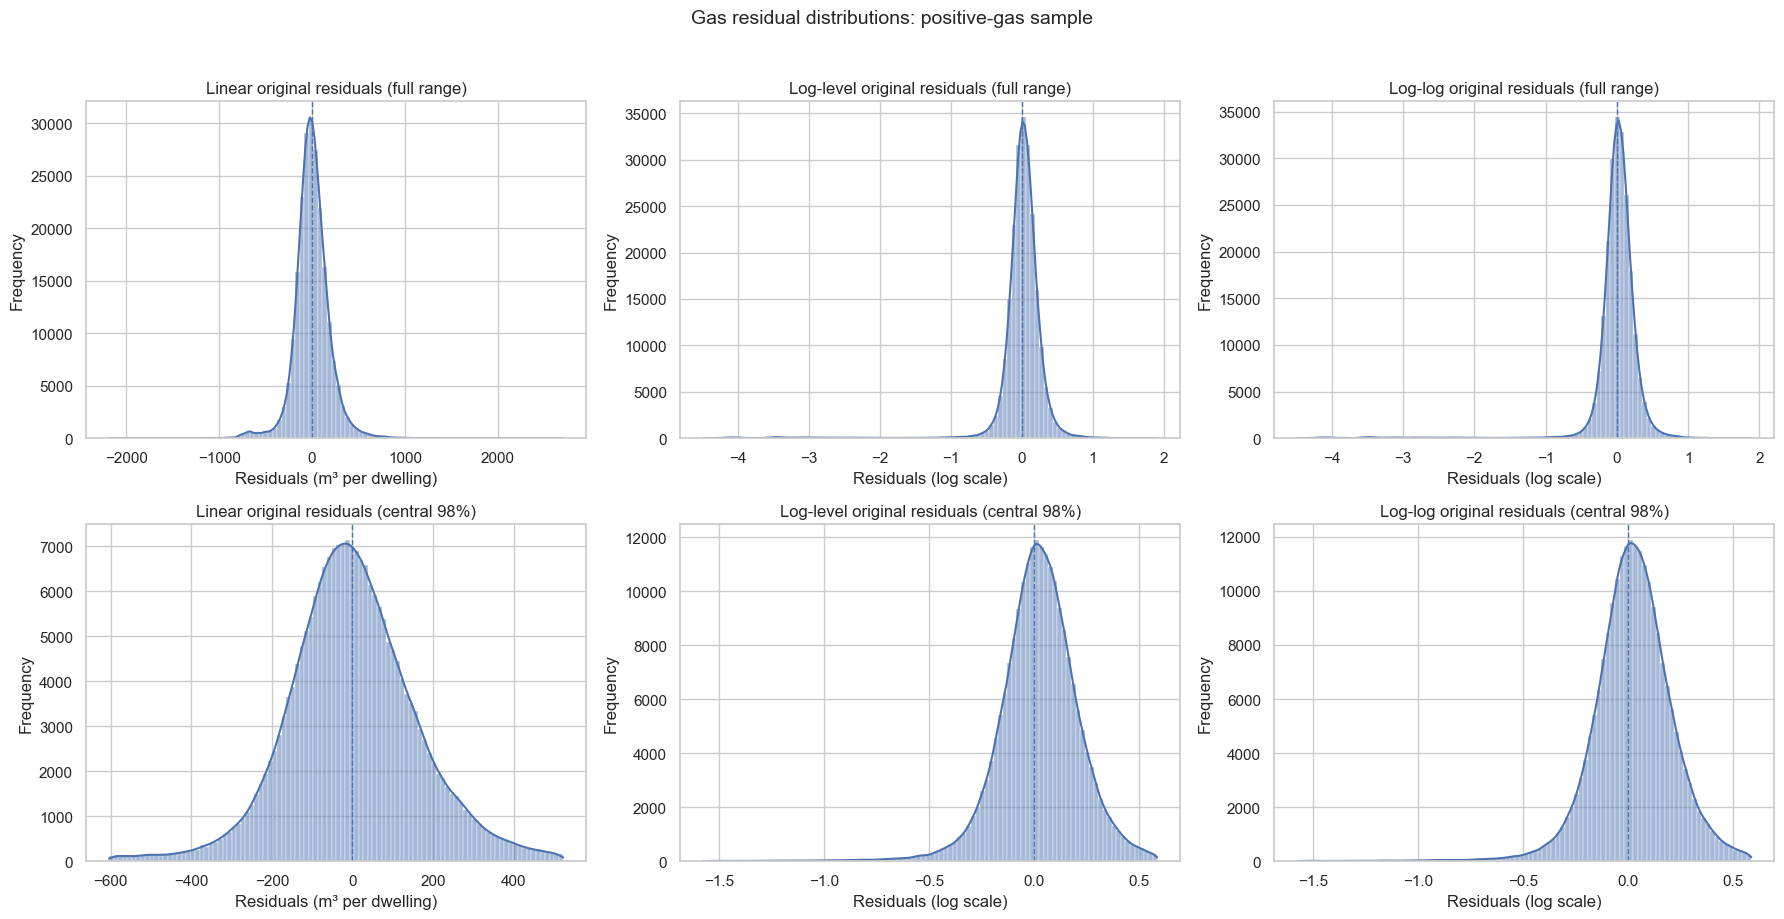

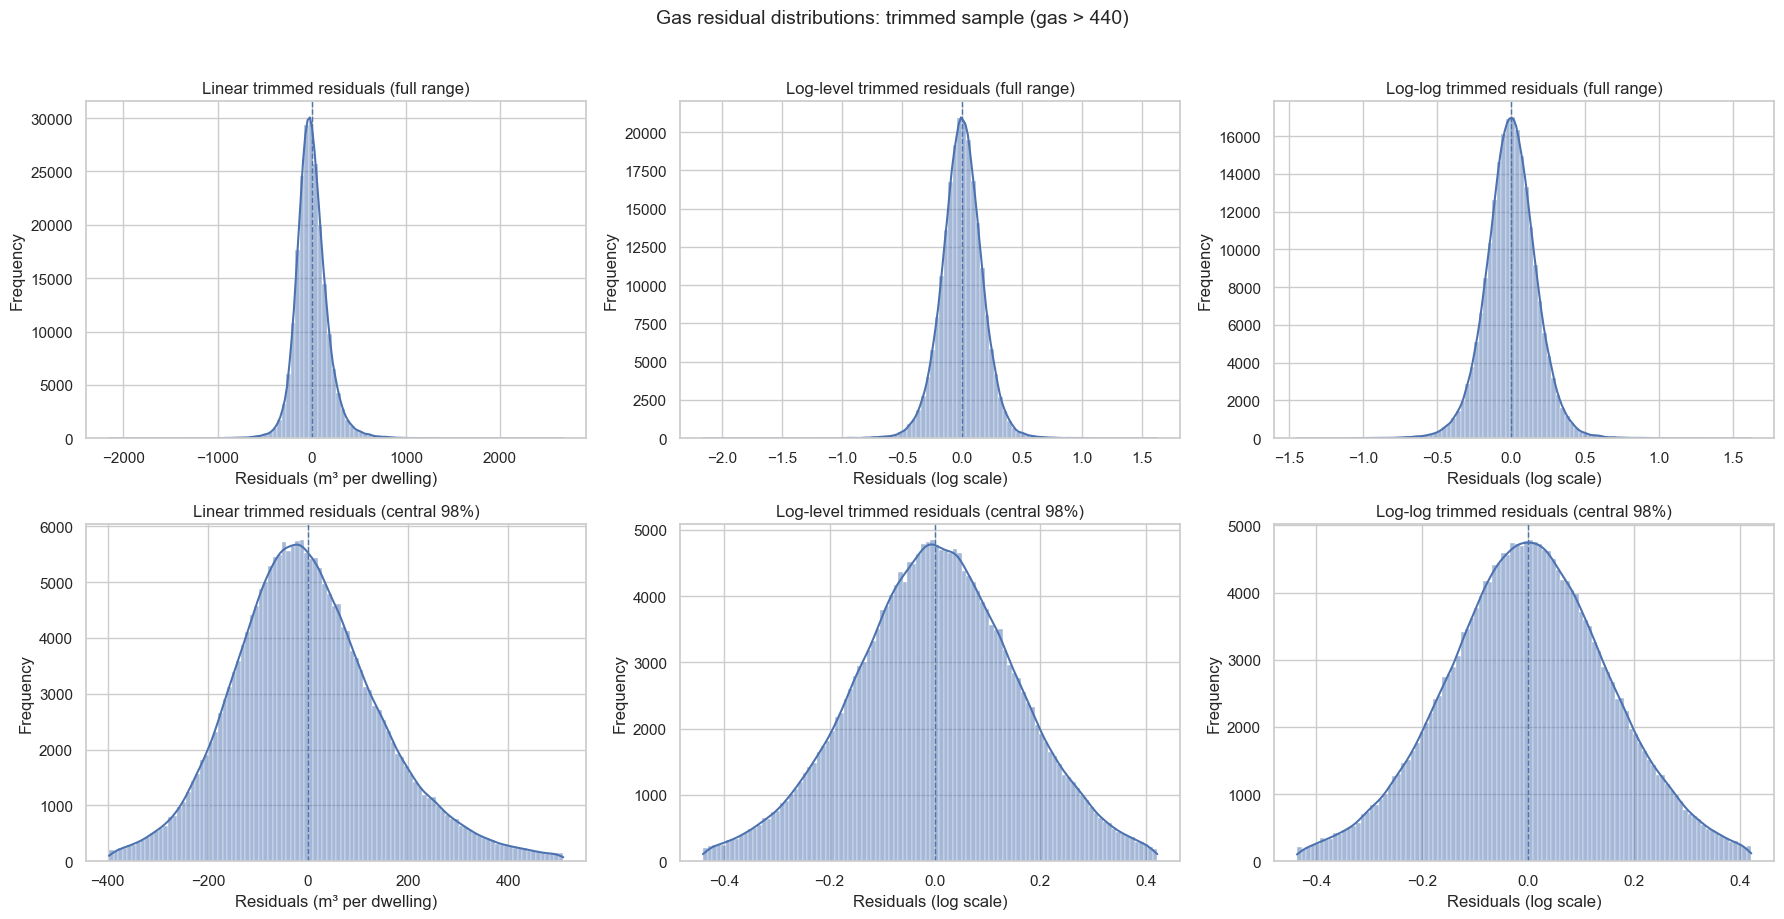

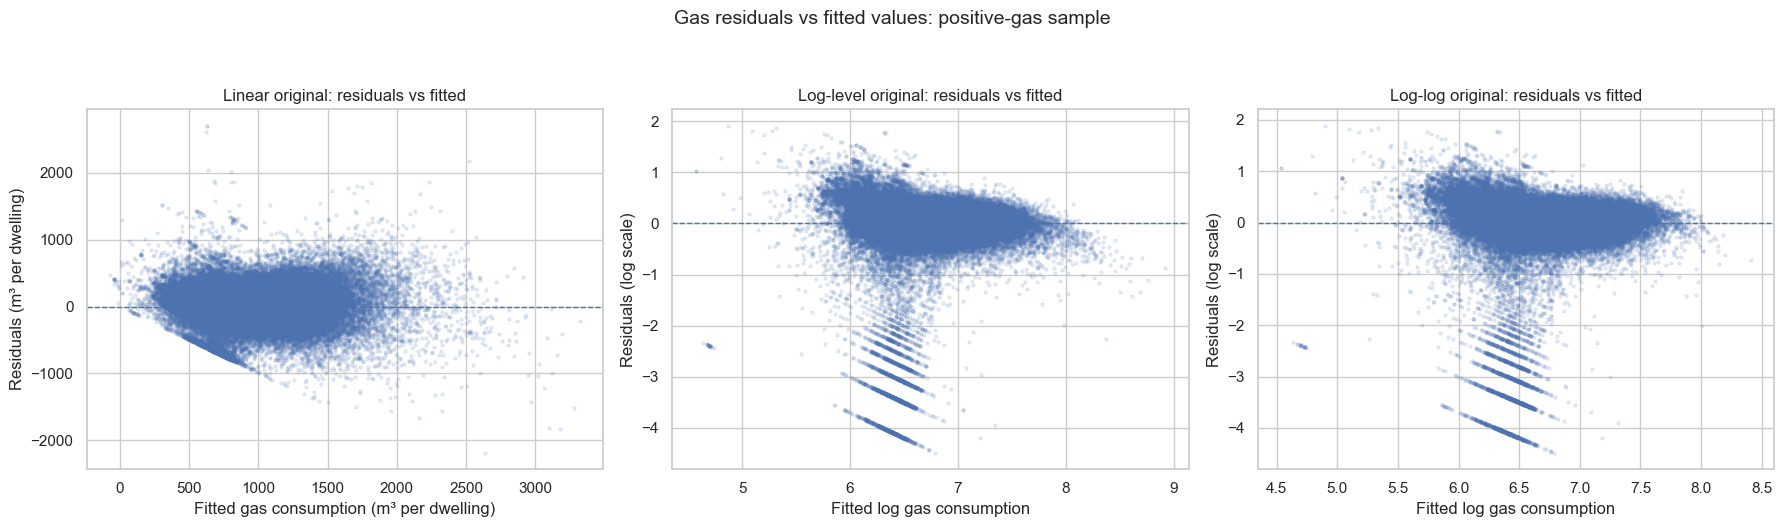

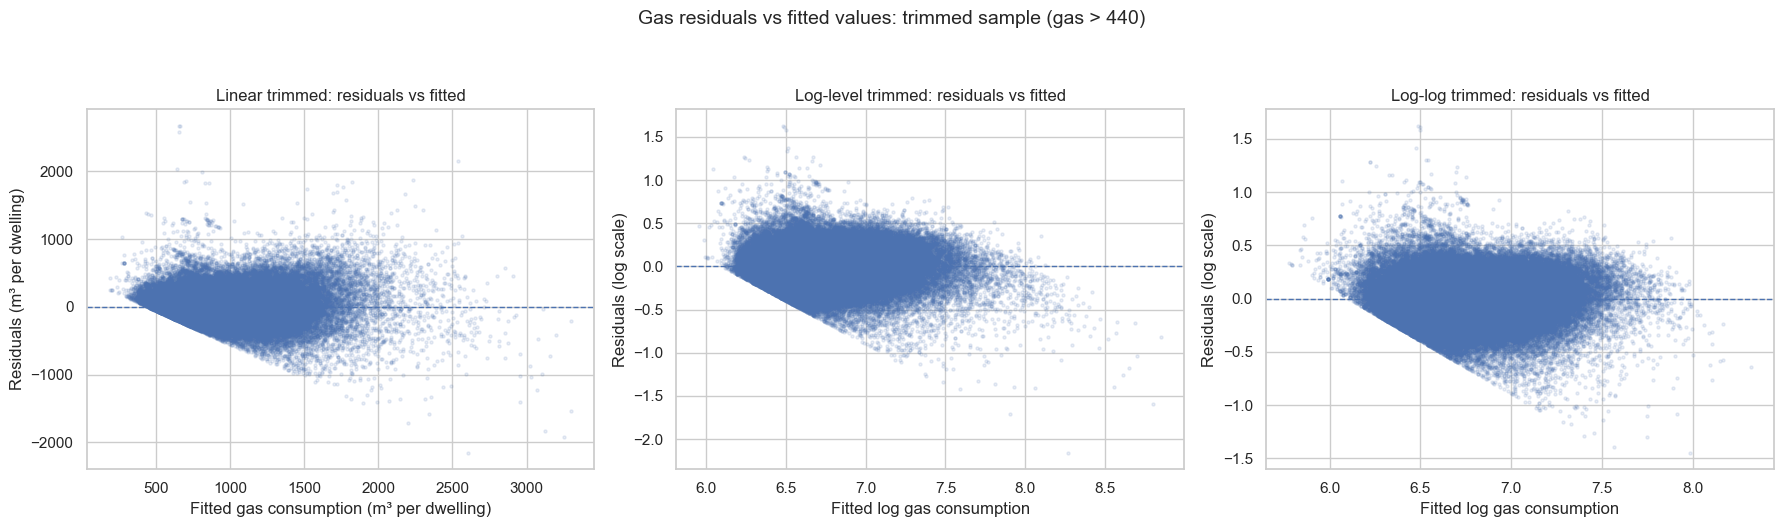

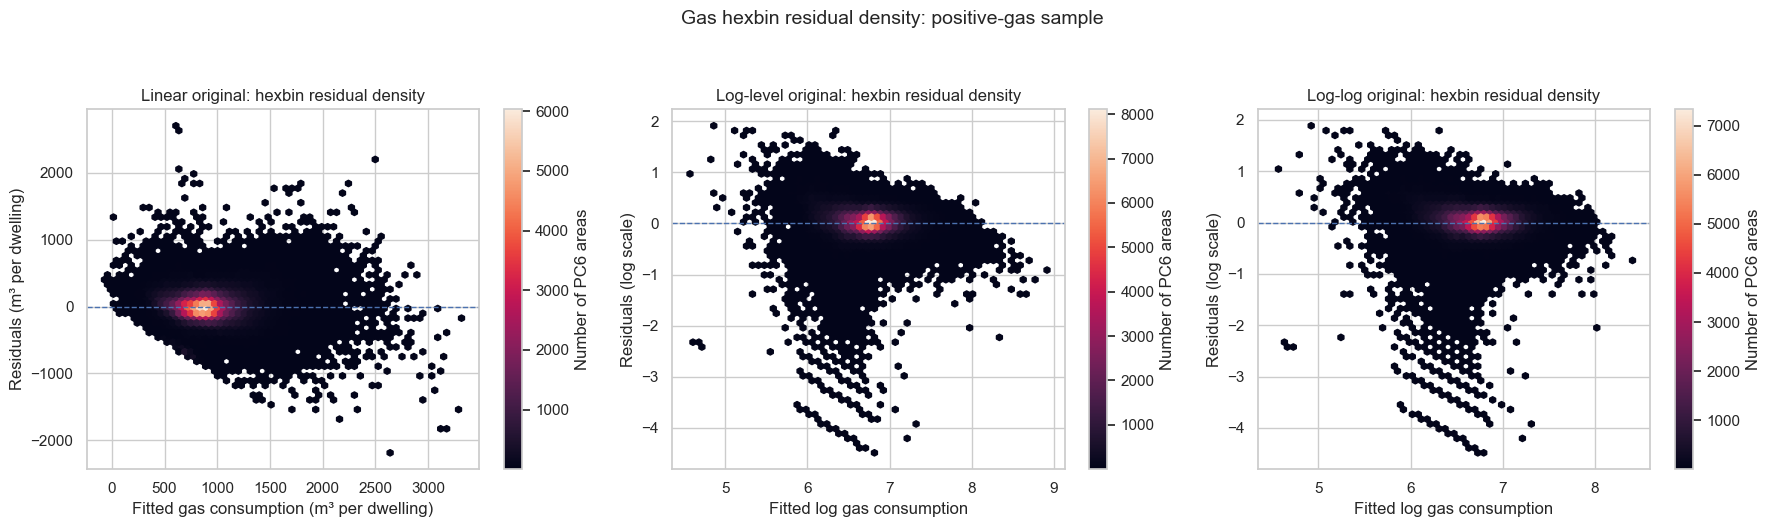

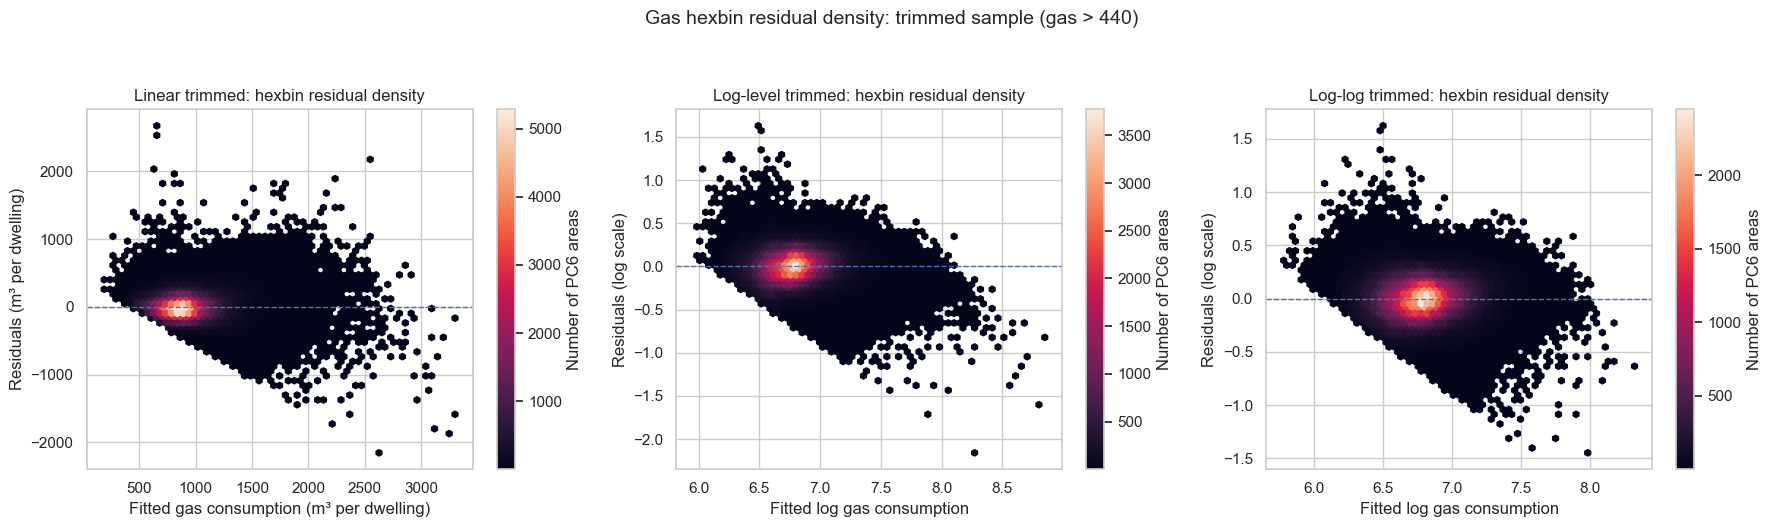

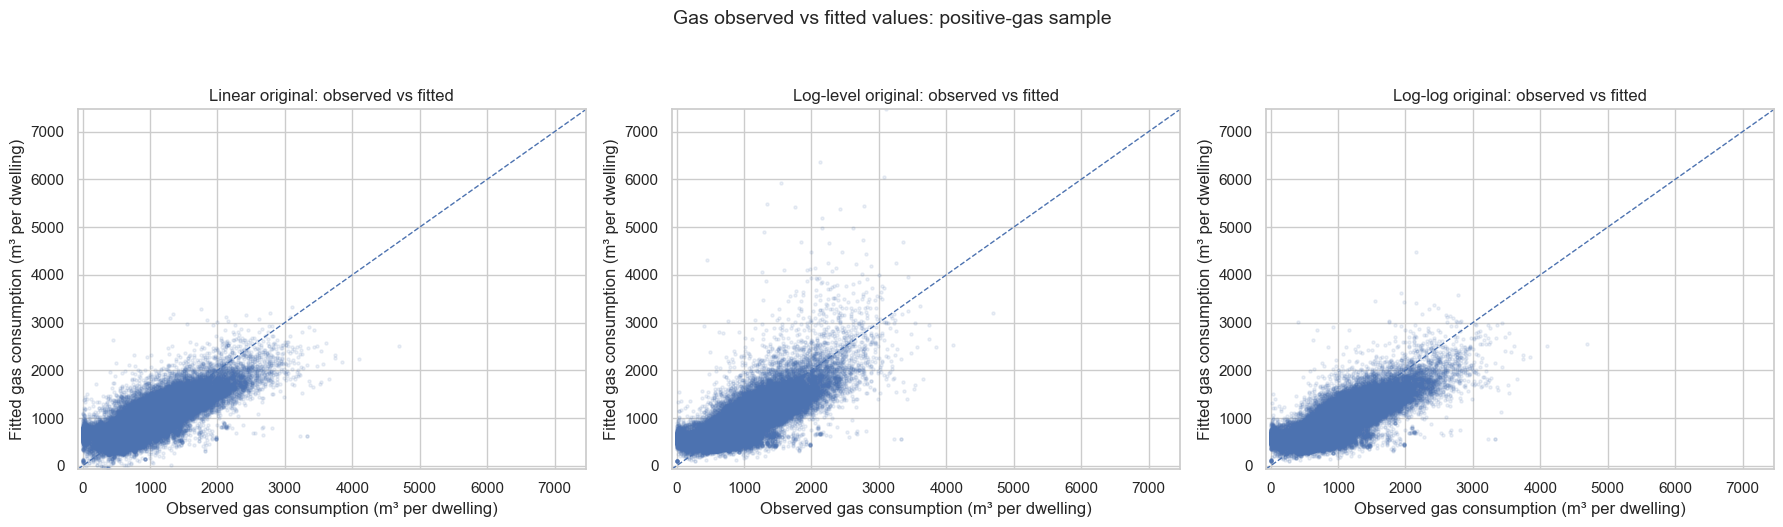

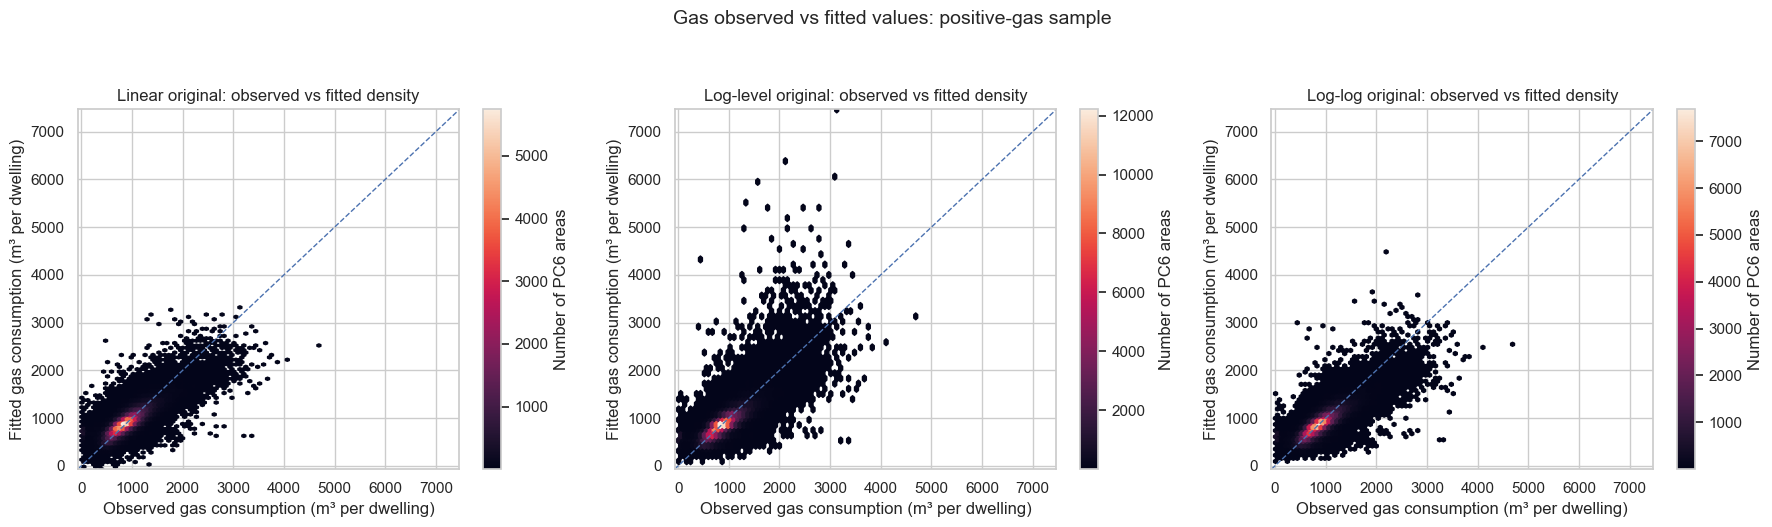

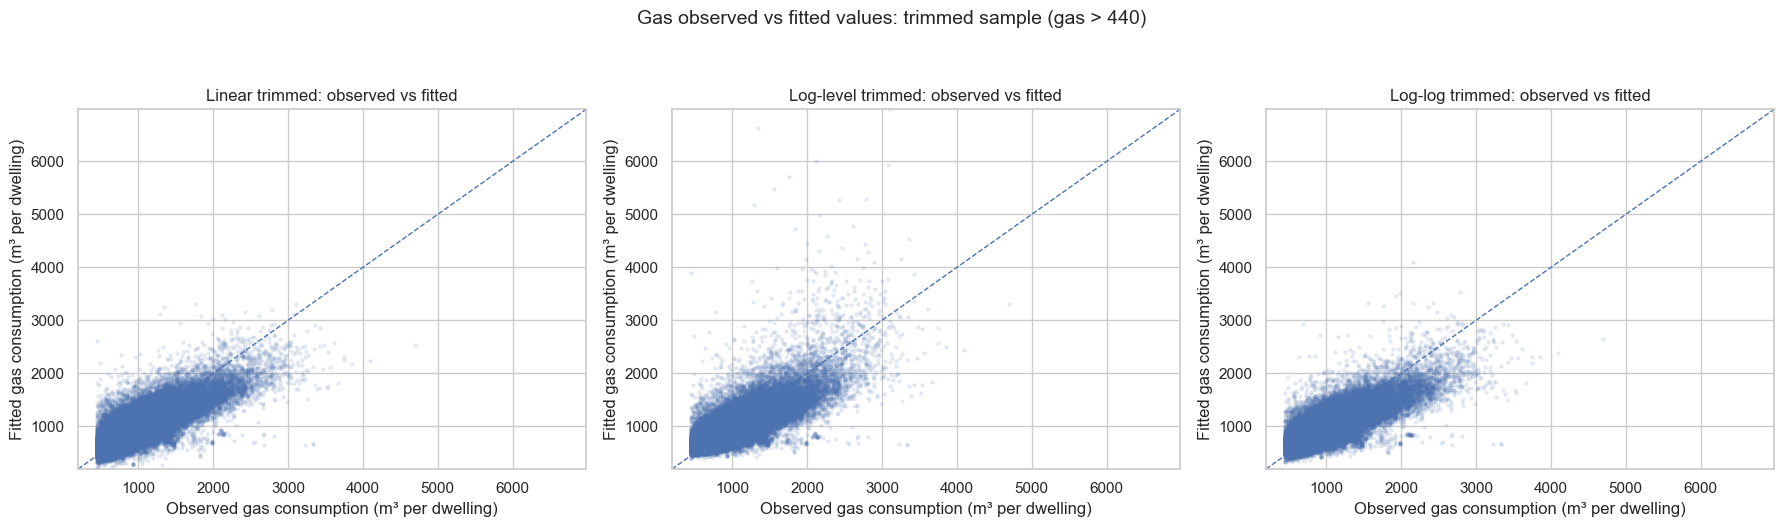

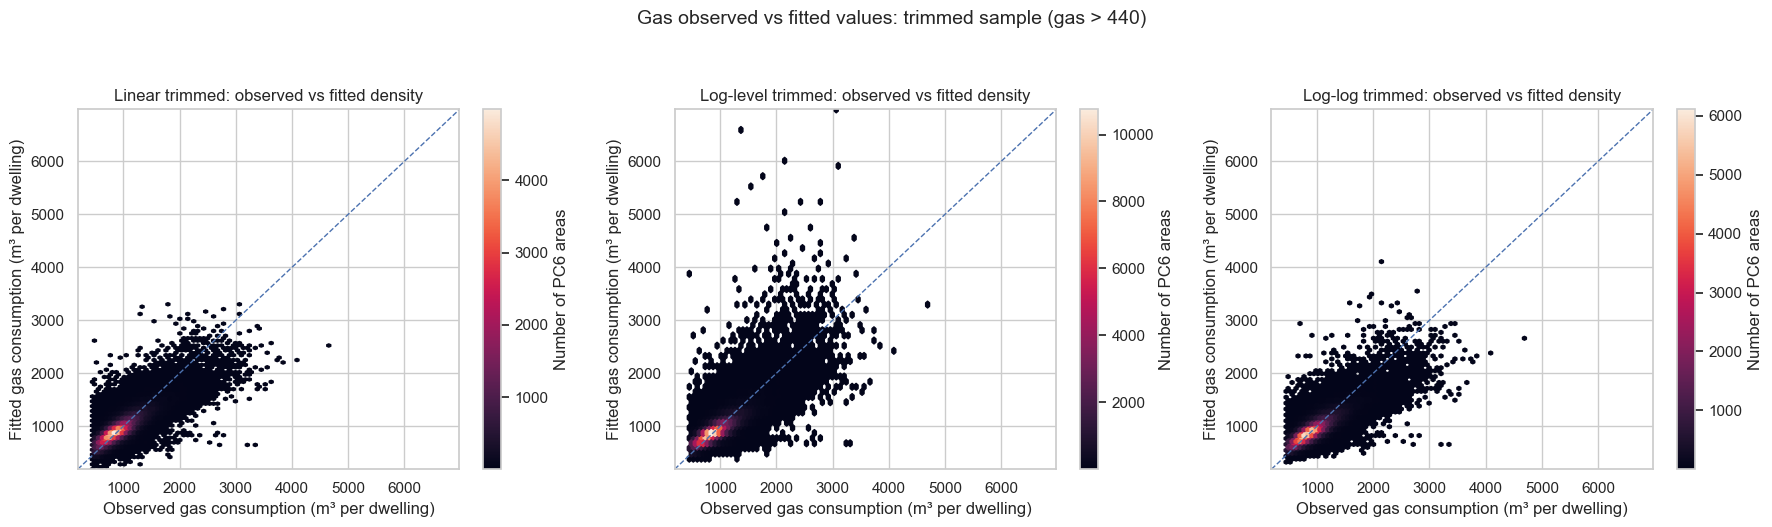

In [169]:
# ----------------------------
# 7.4 Comparison and selection of preferred gas regression specification
# ----------------------------

# ----------------------------
# 1. Define candidate gas models
# ----------------------------

gas_candidate_models = [
    {
        "name": "Linear original",
        "model": model_gas_linear,
        "sample": "Positive gas",
        "scale": "levels",
        "y_true": y_gas_linear,
        "x_label": "Fitted gas consumption (m³ per dwelling)",
        "resid_label": "Residuals (m³ per dwelling)"
    },
    {
        "name": "Log-level original",
        "model": model_gas_log,
        "sample": "Positive gas",
        "scale": "log",
        "y_true": y_gas_linear,
        "x_label": "Fitted log gas consumption",
        "resid_label": "Residuals (log scale)"
    },
    {
        "name": "Log-log original",
        "model": model_gas_loglog,
        "sample": "Positive gas",
        "scale": "log",
        "y_true": y_gas_linear,
        "x_label": "Fitted log gas consumption",
        "resid_label": "Residuals (log scale)"
    },
    {
        "name": "Linear trimmed",
        "model": model_gas_trim_linear,
        "sample": f"Gas > {gas_threshold}",
        "scale": "levels",
        "y_true": y_gas_trim_linear,
        "x_label": "Fitted gas consumption (m³ per dwelling)",
        "resid_label": "Residuals (m³ per dwelling)"
    },
    {
        "name": "Log-level trimmed",
        "model": model_gas_trim_log,
        "sample": f"Gas > {gas_threshold}",
        "scale": "log",
        "y_true": y_gas_trim_linear,
        "x_label": "Fitted log gas consumption",
        "resid_label": "Residuals (log scale)"
    },
    {
        "name": "Log-log trimmed",
        "model": model_gas_trim_loglog,
        "sample": f"Gas > {gas_threshold}",
        "scale": "log",
        "y_true": y_gas_trim_linear,
        "x_label": "Fitted log gas consumption",
        "resid_label": "Residuals (log scale)"
    }
]

# ----------------------------
# 2. Model comparison table
# ----------------------------

comparison_stats_gas = pd.DataFrame({
    "Model": [
        item["name"]
        for item in gas_candidate_models
    ],
    "Sample": [
        item["sample"]
        for item in gas_candidate_models
    ],
    "Scale": [
        item["scale"]
        for item in gas_candidate_models
    ],
    "Observations": [
        int(item["model"].nobs)
        for item in gas_candidate_models
    ],
    "Adj_R2": [
        item["model"].rsquared_adj
        for item in gas_candidate_models
    ],
    "AIC": [
        item["model"].aic
        for item in gas_candidate_models
    ],
    "BIC": [
        item["model"].bic
        for item in gas_candidate_models
    ]
})

comparison_stats_gas = comparison_stats_gas.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

display(comparison_stats_gas)

# ----------------------------
# 3. Helper functions for diagnostics
# ----------------------------

def get_gas_fitted_original_scale(item):
    if item["scale"] == "levels":
        return np.asarray(item["model"].fittedvalues)
    elif item["scale"] == "log":
        return np.exp(np.asarray(item["model"].fittedvalues))
    else:
        raise ValueError("Model scale must be either 'levels' or 'log'.")


def plot_gas_residual_histograms(model_items, title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    for i, item in enumerate(model_items):
        residuals = item["model"].resid

        # Full range
        sns.histplot(
            residuals,
            bins=100,
            kde=True,
            ax=axes[0, i]
        )

        axes[0, i].axvline(0, linestyle="--", linewidth=1)
        axes[0, i].set_title(f"{item['name']} residuals (full range)")
        axes[0, i].set_xlabel(item["resid_label"])
        axes[0, i].set_ylabel("Frequency")

        # Central 98%
        r_min = residuals.quantile(0.01)
        r_max = residuals.quantile(0.99)

        sns.histplot(
            residuals[
                (residuals >= r_min)
                & (residuals <= r_max)
            ],
            bins=100,
            kde=True,
            ax=axes[1, i]
        )

        axes[1, i].axvline(0, linestyle="--", linewidth=1)
        axes[1, i].set_title(f"{item['name']} residuals (central 98%)")
        axes[1, i].set_xlabel(item["resid_label"])
        axes[1, i].set_ylabel("Frequency")

    fig.suptitle(
        title_prefix,
        y=1.02,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


def plot_gas_residuals_vs_fitted(model_items, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, item in zip(axes, model_items):
        model = item["model"]

        ax.scatter(
            model.fittedvalues,
            model.resid,
            s=5,
            alpha=0.12
        )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"{item['name']}: residuals vs fitted")
        ax.set_xlabel(item["x_label"])
        ax.set_ylabel(item["resid_label"])

    fig.suptitle(
        title_prefix,
        y=1.05,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


def plot_gas_hexbin_residuals(model_items, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, item in zip(axes, model_items):
        model = item["model"]

        hb = ax.hexbin(
            model.fittedvalues,
            model.resid,
            gridsize=60,
            mincnt=1
        )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"{item['name']}: hexbin residual density")
        ax.set_xlabel(item["x_label"])
        ax.set_ylabel(item["resid_label"])

        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Number of PC6 areas")

    fig.suptitle(
        title_prefix,
        y=1.05,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


def plot_gas_observed_vs_fitted(model_items, title_prefix):
    observed_fitted = []

    for item in model_items:
        observed_fitted.append({
            "name": item["name"],
            "y_true": np.asarray(item["y_true"]),
            "y_pred": get_gas_fitted_original_scale(item)
        })

    all_true = np.concatenate([
        m["y_true"]
        for m in observed_fitted
    ])

    all_pred = np.concatenate([
        m["y_pred"]
        for m in observed_fitted
    ])

    axis_min = min(all_true.min(), all_pred.min())
    axis_max = max(all_true.max(), all_pred.max())

    # Scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, item in zip(axes, observed_fitted):
        ax.scatter(
            item["y_true"],
            item["y_pred"],
            s=5,
            alpha=0.10
        )

        ax.plot(
            [axis_min, axis_max],
            [axis_min, axis_max],
            linestyle="--",
            linewidth=1
        )

        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)

        ax.set_title(f"{item['name']}: observed vs fitted")
        ax.set_xlabel("Observed gas consumption (m³ per dwelling)")
        ax.set_ylabel("Fitted gas consumption (m³ per dwelling)")

    fig.suptitle(
        title_prefix,
        y=1.05,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # Hexbin plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, item in zip(axes, observed_fitted):
        hb = ax.hexbin(
            item["y_true"],
            item["y_pred"],
            gridsize=60,
            mincnt=1
        )

        ax.plot(
            [axis_min, axis_max],
            [axis_min, axis_max],
            linestyle="--",
            linewidth=1
        )

        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)

        ax.set_title(f"{item['name']}: observed vs fitted density")
        ax.set_xlabel("Observed gas consumption (m³ per dwelling)")
        ax.set_ylabel("Fitted gas consumption (m³ per dwelling)")

        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Number of PC6 areas")

    fig.suptitle(
        title_prefix,
        y=1.05,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4. Split models by sample
# ----------------------------

gas_original_models = [
    item for item in gas_candidate_models
    if item["sample"] == "Positive gas"
]

gas_trimmed_models = [
    item for item in gas_candidate_models
    if item["sample"] == f"Gas > {gas_threshold}"
]

# ----------------------------
# 5. Residual histograms
# ----------------------------

plot_gas_residual_histograms(
    gas_original_models,
    "Gas residual distributions: positive-gas sample"
)

plot_gas_residual_histograms(
    gas_trimmed_models,
    f"Gas residual distributions: trimmed sample (gas > {gas_threshold})"
)

# ----------------------------
# 6. Residuals vs fitted values
# ----------------------------

plot_gas_residuals_vs_fitted(
    gas_original_models,
    "Gas residuals vs fitted values: positive-gas sample"
)

plot_gas_residuals_vs_fitted(
    gas_trimmed_models,
    f"Gas residuals vs fitted values: trimmed sample (gas > {gas_threshold})"
)

# ----------------------------
# 7. Hexbin residual density plots
# ----------------------------

plot_gas_hexbin_residuals(
    gas_original_models,
    "Gas hexbin residual density: positive-gas sample"
)

plot_gas_hexbin_residuals(
    gas_trimmed_models,
    f"Gas hexbin residual density: trimmed sample (gas > {gas_threshold})"
)

# ----------------------------
# 8. Observed vs fitted values
# ----------------------------

plot_gas_observed_vs_fitted(
    gas_original_models,
    "Gas observed vs fitted values: positive-gas sample"
)

plot_gas_observed_vs_fitted(
    gas_trimmed_models,
    f"Gas observed vs fitted values: trimmed sample (gas > {gas_threshold})"
)

### Interpretation of gas model comparison and preferred specification

The comparison shows that excluding very low positive gas-consumption observations substantially changes the behaviour of the gas models. In the original positive-gas sample, the log-level and log-log specifications have relatively low adjusted \(R^2\) values of approximately 0.368 and 0.366, respectively. The residual plots also show pronounced structure, including long negative residual patterns associated with very low gas-consumption observations.

After applying the threshold of \(gas > 440\) m³ per dwelling, the log-based models improve substantially. The adjusted \(R^2\) of the log-level trimmed model increases to approximately 0.633, while the log-log trimmed model increases to approximately 0.641. This indicates that very low positive gas-consumption observations behave differently from the rest of the positive-gas sample and can strongly affect the gas regression results.

Within the trimmed sample, the linear model achieves the highest adjusted \(R^2\), approximately 0.650. The log-log trimmed model is close, with an adjusted \(R^2\) of approximately 0.641. Because the linear and log-based models are estimated on different dependent-variable scales, AIC and BIC should not be used to compare them directly. However, within the log-based trimmed models, the log-log specification clearly performs better than the log-level specification, with higher adjusted \(R^2\) and lower AIC and BIC values.

The residual diagnostics show that the trimmed log-log model produces a relatively symmetric and concentrated residual distribution in log space. The linear trimmed model performs well in terms of original-scale observed-versus-fitted behaviour, but its residuals still show heteroskedasticity and wider dispersion in absolute m³ terms. This is expected because gas consumption is right-skewed and high-consumption observations have larger absolute errors.

The observed-versus-fitted plots show that all models capture the main structure of gas consumption reasonably well in the dense part of the distribution. The linear trimmed model appears slightly more direct on the original m³ scale, while the log-log trimmed model provides more stable proportional residual behaviour. The differences are therefore not large enough to claim that one model dominates on all criteria.

For the remainder of the gas analysis, the trimmed log-log model is selected as the preferred specification. This choice is based on its improved residual behaviour, strong performance within the log-model family, robustness after excluding very low gas-consumption observations, and consistency with the electricity modelling framework. At the same time, the trimmed linear model is recognized as a close alternative, especially when evaluating predictions on the original gas-consumption scale.

### 7.5 Out-of-sample predictive assessment of the trimmed gas models

The model comparison in Section 7.4 showed that the trimmed gas specifications perform similarly across several diagnostics. The trimmed linear model has slightly higher adjusted \(R^2\), while the trimmed log-log model shows more stable proportional residual behaviour and performs best within the log-model family.

To assess whether these differences matter for prediction, this section evaluates the three trimmed gas models using 10-fold cross-validation:

1. the trimmed linear model;
2. the trimmed log-level model;
3. the trimmed log-log model.

The evaluation is performed on the same trimmed gas sample defined in Section 7.3, where PC6 areas with very low positive gas consumption are excluded. This ensures that the comparison focuses on postcode areas where gas consumption is more likely to reflect regular residential gas use.

The cross-validation procedure follows the same logic as in the electricity analysis. The dataset is split into ten folds. For each fold, the model is trained on nine folds and evaluated on the remaining fold. This process is repeated until each fold has served once as the validation sample.

The evaluation reports two types of metrics.

First, prediction errors are reported in the model-estimation scale:

- for the linear model, this is m³ gas per dwelling;
- for the log-level and log-log models, this is log gas consumption.

Second, all predictions are transformed to the original gas-consumption scale and evaluated in m³ gas per dwelling. These original-scale metrics are the most useful for comparing predictive accuracy across the linear and log-based models, because all models are evaluated in the same physical unit.

The metrics used are:

- mean squared error (MSE);
- root mean squared error (RMSE);
- mean absolute error (MAE).

A cross-validated mean-predictor baseline is also included. For the linear model, the baseline predicts the mean gas consumption in the training folds. For the log-based models, the baseline predicts the mean log gas consumption in the training folds. This provides a reference point for assessing whether the regression models improve predictive performance beyond a simple average-based prediction.

Because the log-based models are estimated in log space, RMSE and MAE in log space are also converted into approximate relative-error measures using:

$$
\exp(RMSE) - 1
$$

and

$$
\exp(MAE) - 1
$$

These values provide an approximate multiplicative interpretation of prediction errors for the log-based specifications.

In [170]:
# ----------------------------
# 7.5 Out-of-sample predictive assessment of trimmed gas models
# ----------------------------

# ----------------------------
# 1. Cross-validation setup
# ----------------------------

kf_gas_cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ----------------------------
# 2. Define trimmed candidate models
# ----------------------------

gas_cv_models = [
    {
        "Model": "Linear trimmed",
        "Scale": "levels",
        "X": X_gas_trim,
        "y_model": y_gas_trim_linear,
        "y_m3": y_gas_trim_linear
    },
    {
        "Model": "Log-level trimmed",
        "Scale": "log",
        "X": X_gas_trim,
        "y_model": y_gas_trim_log,
        "y_m3": y_gas_trim_linear
    },
    {
        "Model": "Log-log trimmed",
        "Scale": "log",
        "X": X_gas_trim_loglog,
        "y_model": y_gas_trim_log,
        "y_m3": y_gas_trim_linear
    }
]

# ----------------------------
# 3. Helper functions
# ----------------------------

def prepare_sklearn_matrix(X_model):
    X_sklearn = X_model.copy()

    if "const" in X_sklearn.columns:
        X_sklearn = X_sklearn.drop(
            columns=["const"]
        )

    X_sklearn = X_sklearn.select_dtypes(
        include=[np.number]
    )

    return X_sklearn


def cross_validated_mean_prediction(y_values, cv):
    y_values_array = np.asarray(y_values)
    y_pred = np.empty_like(
        y_values_array,
        dtype=float
    )

    dummy_X = np.zeros(
        len(y_values_array)
    )

    for train_idx, test_idx in cv.split(dummy_X):
        train_mean = y_values_array[train_idx].mean()
        y_pred[test_idx] = train_mean

    return y_pred


def convert_gas_prediction_to_m3(y_pred_model, scale):
    if scale == "levels":
        return np.asarray(y_pred_model)

    if scale == "log":
        return np.exp(
            np.asarray(y_pred_model)
        )

    raise ValueError(
        "Scale must be either 'levels' or 'log'."
    )


def calculate_gas_cv_metrics(
    model_name,
    scale,
    y_true_model,
    y_pred_model,
    y_true_m3,
    y_pred_m3
):

    y_true_model = np.asarray(y_true_model)
    y_pred_model = np.asarray(y_pred_model)
    y_true_m3 = np.asarray(y_true_m3)
    y_pred_m3 = np.asarray(y_pred_m3)

    # Metrics in model-estimation scale
    mse_model_scale = mean_squared_error(
        y_true_model,
        y_pred_model
    )

    rmse_model_scale = np.sqrt(
        mse_model_scale
    )

    mae_model_scale = mean_absolute_error(
        y_true_model,
        y_pred_model
    )

    # Approximate relative interpretation for log models
    if scale == "log":
        approx_rmse_relative = (
            np.exp(rmse_model_scale) - 1
        ) * 100

        approx_mae_relative = (
            np.exp(mae_model_scale) - 1
        ) * 100
    else:
        approx_rmse_relative = np.nan
        approx_mae_relative = np.nan

    # Metrics in original m³ scale
    mse_m3 = mean_squared_error(
        y_true_m3,
        y_pred_m3
    )

    rmse_m3 = np.sqrt(
        mse_m3
    )

    mae_m3 = mean_absolute_error(
        y_true_m3,
        y_pred_m3
    )

    mean_signed_error_m3 = np.mean(
        y_true_m3 - y_pred_m3
    )

    return {
        "Model": model_name,
        "Scale": scale,
        "Observations": len(y_true_m3),

        "MSE_model_scale": mse_model_scale,
        "RMSE_model_scale": rmse_model_scale,
        "MAE_model_scale": mae_model_scale,

        "Approx_RMSE_relative_%": approx_rmse_relative,
        "Approx_MAE_relative_%": approx_mae_relative,

        "MSE_m3": mse_m3,
        "RMSE_m3": rmse_m3,
        "MAE_m3": mae_m3,
        "Mean_signed_error_m3": mean_signed_error_m3
    }

# ----------------------------
# 4. Cross-validated predictions and metrics
# ----------------------------

gas_cv_rows = []
gas_cv_predictions = {}

for item in gas_cv_models:

    model_name = item["Model"]
    scale = item["Scale"]

    X_model_sklearn = prepare_sklearn_matrix(
        item["X"]
    )

    y_model = item["y_model"].copy()
    y_m3 = item["y_m3"].copy()

    # ----------------------------
    # Baseline mean predictor
    # ----------------------------

    y_pred_baseline_model = cross_validated_mean_prediction(
        y_model,
        kf_gas_cv
    )

    y_pred_baseline_m3 = convert_gas_prediction_to_m3(
        y_pred_baseline_model,
        scale
    )

    baseline_name = (
        f"Baseline mean predictor ({scale})"
    )

    gas_cv_rows.append(
        calculate_gas_cv_metrics(
            baseline_name,
            scale,
            y_model,
            y_pred_baseline_model,
            y_m3,
            y_pred_baseline_m3
        )
    )

    # ----------------------------
    # OLS model prediction
    # ----------------------------

    ols_gas_cv = LinearRegression()

    y_pred_model = cross_val_predict(
        ols_gas_cv,
        X_model_sklearn,
        y_model,
        cv=kf_gas_cv,
        n_jobs=-1
    )

    y_pred_m3 = convert_gas_prediction_to_m3(
        y_pred_model,
        scale
    )

    gas_cv_rows.append(
        calculate_gas_cv_metrics(
            model_name,
            scale,
            y_model,
            y_pred_model,
            y_m3,
            y_pred_m3
        )
    )

    gas_cv_predictions[model_name] = {
        "Scale": scale,
        "X": X_model_sklearn,
        "y_true_model": np.asarray(y_model),
        "y_pred_model": np.asarray(y_pred_model),
        "y_true_m3": np.asarray(y_m3),
        "y_pred_m3": np.asarray(y_pred_m3)
    }

# ----------------------------
# 5. Build comparison table
# ----------------------------

gas_cv_results_raw = pd.DataFrame(
    gas_cv_rows
)

gas_cv_results = gas_cv_results_raw.round({
    "MSE_model_scale": 6,
    "RMSE_model_scale": 4,
    "MAE_model_scale": 4,

    "Approx_RMSE_relative_%": 2,
    "Approx_MAE_relative_%": 2,

    "MSE_m3": 2,
    "RMSE_m3": 2,
    "MAE_m3": 2,
    "Mean_signed_error_m3": 2
})

# ----------------------------
# 6. Store preferred gas CV outputs for later diagnostics
# ----------------------------

preferred_gas_cv_model = "Log-log trimmed"

if preferred_gas_cv_model not in gas_cv_predictions:
    raise RuntimeError(
        f"Preferred gas CV model not found: {preferred_gas_cv_model}"
    )

gas_y_true_model_arr = gas_cv_predictions[
    preferred_gas_cv_model
]["y_true_model"]

gas_y_pred_model_arr = gas_cv_predictions[
    preferred_gas_cv_model
]["y_pred_model"]

gas_y_true_m3_arr = gas_cv_predictions[
    preferred_gas_cv_model
]["y_true_m3"]

gas_y_pred_m3_arr = gas_cv_predictions[
    preferred_gas_cv_model
]["y_pred_m3"]

gas_model_scale_preferred = gas_cv_predictions[
    preferred_gas_cv_model
]["Scale"]

# Convenience names for log-based preferred model
if gas_model_scale_preferred == "log":
    gas_y_true_log_arr = gas_y_true_model_arr.copy()
    gas_y_pred_log_arr = gas_y_pred_model_arr.copy()
else:
    gas_y_true_log_arr = None
    gas_y_pred_log_arr = None

# ----------------------------
# 7. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas cross-validation:</strong>
        10-fold CV on trimmed gas sample
    </p>

    <p>
        <strong>Trimmed gas threshold:</strong>
        gas &gt; {gas_threshold} m³ per dwelling
    </p>

    <p>
        <strong>Preferred gas model stored for later diagnostics:</strong>
        {preferred_gas_cv_model}
    </p>

    {gas_cv_results.to_html(index=False)}
</div>
"""

display(HTML(html_output))

Model,Scale,Observations,MSE_model_scale,RMSE_model_scale,MAE_model_scale,Approx_RMSE_relative_%,Approx_MAE_relative_%,MSE_m3,RMSE_m3,MAE_m3,Mean_signed_error_m3
Baseline mean predictor (levels),levels,215228,85428.465050,292.2815,212.2686,NaN,NaN,85428.47,292.28,212.27,0.00
Linear trimmed,levels,215228,29956.951179,173.0808,125.5681,NaN,NaN,29956.95,173.08,125.57,0.00
Baseline mean predictor (log),log,215228,0.083165,0.2884,0.2247,33.43,25.19,86965.08,294.90,208.82,39.20
Log-level trimmed,log,215228,0.030499,0.1746,0.1330,19.08,14.22,31561.49,177.66,123.96,13.84
Baseline mean predictor (log),log,215228,0.083165,0.2884,0.2247,33.43,25.19,86965.08,294.90,208.82,39.20
Log-log trimmed,log,215228,0.029889,0.1729,0.1320,18.87,14.11,29270.37,171.09,122.30,14.44


### Interpretation of cross-validation results

The 10-fold cross-validation compares the three trimmed gas regression specifications on the same trimmed sample, using both model-scale metrics and original-scale prediction errors in m³ gas per dwelling.

The level-scale baseline has an RMSE of approximately **292 m³ per dwelling** and an MAE of approximately **212 m³ per dwelling**. The trimmed linear regression reduces these errors to approximately **173 m³** and **126 m³**, respectively.

For the log-based models, the baseline mean predictor has an RMSE of approximately **0.288** in log space and an MAE of approximately **0.225**. These correspond to approximate relative errors of **33.4%** and **25.2%**, respectively. Both log-based regression models improve substantially on this baseline.

The trimmed log-level model achieves an original-scale RMSE of approximately **178 m³ per dwelling** and an MAE of approximately **124 m³ per dwelling**. The trimmed log-log model performs slightly better, with an RMSE of approximately **171 m³ per dwelling** and an MAE of approximately **122 m³ per dwelling**.

| Model | RMSE m³ per dwelling | MAE m³ per dwelling |
|---|---:|---:|
| Linear trimmed | 173.08 | 125.57 |
| Log-level trimmed | 177.66 | 123.96 |
| Log-log trimmed | 171.09 | 122.30 |

The differences between the trimmed linear and trimmed log-log models are modest. However, the log-log specification achieves the lowest RMSE and the lowest MAE on the original gas-consumption scale. This indicates that it provides the strongest out-of-sample predictive performance among the three trimmed models.

The log-log model also has the best performance within the log-model family and is consistent with the preferred modelling structure used for electricity. Together with the residual diagnostics from Section 7.4, the cross-validation results support selecting the **trimmed log-log model** as the preferred gas regression specification.

The positive mean signed error of the log-log model indicates a small tendency toward underprediction after transforming predictions back to the original m³ scale. This bias is limited relative to the overall prediction error and is examined further in the predictive error diagnostics.

### 7.6 Multicollinearity assessment

Multicollinearity arises when explanatory variables are strongly correlated with each other. In that case, it becomes more difficult to separate the conditional association of each individual predictor from the associations of related predictors, and the variance of the estimated coefficients may increase.

Multicollinearity does not bias the fitted values or reduce the overall predictive fit of the model. However, it can lead to:

- inflated standard errors;
- unstable coefficient estimates;
- sensitivity of individual coefficients to small changes in the data or model specification.

This issue is particularly relevant in the gas regression analysis because the model includes compositional variables, such as dwelling-type shares and energy-label shares. By construction, these variables are interdependent, since the shares within each group sum to one within each PC6 area.

To quantify the severity of multicollinearity, Variance Inflation Factors (VIF) are computed for the explanatory variables of the preferred gas model.

The VIF for a predictor \(x_j\) is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where \(R_j^2\) is obtained by regressing \(x_j\) on all other predictors.

The VIF measures how much the variance of a coefficient is inflated because of correlation with other explanatory variables. Common reference values are:

- VIF < 5: limited multicollinearity;
- 5 ≤ VIF < 10: moderate multicollinearity;
- VIF ≥ 10: strong multicollinearity.

In the following, VIF values are computed using the explanatory-variable matrix of the preferred trimmed log-log gas model, `X_gas_trim_loglog`.

This matrix already contains the final gas regression variables exactly as used in the preferred model. No additional dummy-variable creation is required because dwelling type and energy label variables have already been transformed into PC6-level composition shares.

As in the electricity model, one category from each compositional group is omitted before estimation:

- dwelling-type reference: `share_dwelling_type_Appartement`;
- energy-label reference: `share_energy_label_G`.

This avoids perfect multicollinearity. However, the remaining share variables may still be correlated with each other, so VIF remains useful for assessing the stability of individual coefficient interpretation.

The intercept column `const` is included in the auxiliary regressions but excluded from the displayed VIF table, because VIF is interpreted for explanatory variables rather than for the constant term.

The VIF diagnostic is deterministic. It does not depend on a random seed, because it is calculated from auxiliary regressions using the fixed predictor matrix. Therefore, the VIF values will be the same every time as long as the input data and selected variables remain unchanged.

In [175]:
# ----------------------------
# 7.6 VIF diagnostics for preferred trimmed log-log gas model
# ----------------------------

# ----------------------------
# 1. Check preferred gas predictor matrix
# ----------------------------

if "X_gas_trim_loglog" not in globals():
    raise RuntimeError(
        "Missing required predictor matrix: X_gas_trim_loglog. "
        "Run Sections 7.3 and 7.4 before computing VIF diagnostics."
    )

# ----------------------------
# 2. Prepare VIF matrix
# ----------------------------

X_gas_vif = X_gas_trim_loglog.copy()
X_gas_vif = X_gas_vif.select_dtypes(include=[np.number])

# Keep/add constant for the auxiliary regressions
X_gas_vif = sm.add_constant(
    X_gas_vif.drop(columns=["const"], errors="ignore"),
    has_constant="add"
)

# ----------------------------
# 3. Compute VIF values
# ----------------------------

vif_results_gas = pd.DataFrame({
    "Variable": [
        c for c in X_gas_vif.columns
        if c != "const"
    ],
    "VIF": [
        variance_inflation_factor(
            X_gas_vif.values,
            X_gas_vif.columns.get_loc(c)
        )
        for c in X_gas_vif.columns
        if c != "const"
    ]
})

# ----------------------------
# 4. Add variable group for interpretation
# ----------------------------

def classify_gas_vif_variable(var):
    if var == "log_mean_floor_area":
        return "Structural"
    elif var == "mean_building_year":
        return "Structural"
    elif var == "share_has_gas":
        return "Infrastructure"
    elif var.startswith("share_dwelling_type_"):
        return "Dwelling type share"
    elif var.startswith("share_energy_label_"):
        return "Energy label share"
    elif var in [
        "avg_woz_value_filled",
        "avg_household_size_filled",
        "avg_household_size_missing",
        "share_population_on_benefits_filled"
    ]:
        return "CBS socioeconomic"
    else:
        return "Other"

vif_results_gas["Group"] = (
    vif_results_gas["Variable"]
    .apply(classify_gas_vif_variable)
)

# ----------------------------
# 5. Sort and display
# ----------------------------

vif_results_gas = (
    vif_results_gas
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results_gas["VIF"] = (
    vif_results_gas["VIF"]
    .round(2)
)

display(vif_results_gas)

,Variable,VIF,Group
0,share_energy_label_no_label,658.53,Energy label share
1,share_dwelling_type_unknown,635.60,Dwelling type share
2,share_energy_label_A,23.18,Energy label share
3,share_energy_label_C,15.53,Energy label share
4,share_energy_label_B,10.33,Energy label share
5,share_energy_label_D,6.51,Energy label share
6,share_energy_label_E,4.33,Energy label share
7,log_mean_floor_area,3.66,Structural
8,share_energy_label_F,3.13,Energy label share
9,share_dwelling_type_Rijwoning tussen,3.04,Dwelling type share


### Interpretation of multicollinearity assessment for the preferred gas model

Variance Inflation Factors are computed for the preferred trimmed log-log gas specification. The results show that multicollinearity is concentrated mainly in the compositional variables, especially the unknown and no-label categories.

The highest VIF values are observed for `share_energy_label_no_label` and `share_dwelling_type_unknown`, with VIF values above 600. These variables represent incomplete or unknown classification categories rather than clearly defined physical dwelling characteristics. Their very high VIF values indicate that they are strongly related to the remaining composition variables. As a result, their individual coefficients should be interpreted with particular caution.

Several energy-label shares also show elevated VIF values. In particular, `share_energy_label_A`, `share_energy_label_C`, and `share_energy_label_B` exceed the conventional threshold of 10, while `share_energy_label_D` falls in the moderate range. This is expected because energy-label shares are compositional: even after omitting `share_energy_label_G` as the reference category, the remaining label shares are still mechanically and empirically related to each other.

In contrast, the main continuous structural and socioeconomic variables show relatively low VIF values. The VIF values for `log_mean_floor_area`, `mean_building_year`, `share_has_gas`, `avg_household_size_filled`, `avg_woz_value_filled`, and `share_population_on_benefits_filled` remain below conventional concern thresholds. This suggests that the main continuous predictors are not severely affected by multicollinearity in the preferred gas specification.

Overall, the VIF results do not invalidate the preferred gas model. Multicollinearity does not reduce the model's overall predictive fit or bias the fitted values. However, it does limit the reliability of interpreting some individual composition-share coefficients, especially the `no_label`, `unknown`, and selected energy-label variables. The gas regression results should therefore be interpreted mainly in terms of broader structural and compositional patterns, rather than as precise independent estimates for every individual share variable.

### 7.7 Nonlinear benchmark: Random Forest

The preferred trimmed log-log gas regression model provides an interpretable statistical specification for modelling postcode-level gas consumption. However, it assumes an additive relationship between the explanatory variables and the logarithm of gas consumption. This structure may not fully capture nonlinear relationships, threshold effects, or interactions between housing-stock characteristics.

To assess whether such nonlinear patterns provide additional predictive information, a Random Forest regression model is estimated as a nonlinear benchmark.

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions. This allows the model to capture:

- nonlinear relationships between predictors and gas consumption;
- interactions between variables;
- threshold effects that are not specified manually.

The Random Forest is used strictly as a predictive benchmark. It is not used for coefficient interpretation, because it does not provide directly interpretable regression coefficients.

#### Random Forest specification

The Random Forest benchmark is estimated using fixed hyperparameters rather than a full grid search. This choice avoids selecting hyperparameters on the full dataset before cross-validation, which could make the cross-validated performance estimate optimistic.

The selected settings are:

- `n_estimators = 200`
- `max_depth = 20`
- `min_samples_leaf = 10`
- `max_features = None`

These settings provide a balance between flexibility, computational feasibility, and overfitting control. The purpose is not to identify the globally optimal Random Forest configuration, but to assess whether a flexible nonlinear model provides a meaningful predictive improvement over the preferred trimmed log-log regression.

#### Evaluation procedure

Both the preferred trimmed log-log regression model and the Random Forest benchmark are evaluated using the same 10-fold cross-validation procedure and the same trimmed gas sample.

The dependent variable is:

- `log(gas_avg_per_dwelling_pc6)`

Predictions are evaluated first in log space. For interpretability, they are also transformed back to the original gas-consumption scale and evaluated in m³ gas per dwelling.

The evaluation metrics are:

- mean squared error (MSE);
- root mean squared error (RMSE);
- mean absolute error (MAE).

Because the dependent variable is logarithmic, RMSE and MAE in log space are also converted into approximate relative-error measures using:

$$
\exp(RMSE) - 1
$$

and

$$
\exp(MAE) - 1
$$

The Random Forest results are interpreted only as predictive evidence. Any improvement over the regression model indicates that nonlinearities or interactions may contain additional predictive information, but it does not imply causal effects.

In [176]:
# ----------------------------
# 7.7 Random Forest benchmark for gas
# Fixed-hyperparameter nonlinear benchmark
# Consistent with preferred trimmed log-log model
# ----------------------------

# ----------------------------
# 1. Data and CV setup
# ----------------------------

X_gas_rf = X_gas_trim_loglog.copy()
y_gas_rf_log = y_gas_trim_log.copy()

kf_gas_rf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# sklearn LinearRegression and RandomForestRegressor handle the intercept internally.
# Therefore, the explicit statsmodels constant is removed.
if "const" in X_gas_rf.columns:
    X_gas_rf_sklearn = X_gas_rf.drop(columns=["const"]).copy()
else:
    X_gas_rf_sklearn = X_gas_rf.copy()

# Keep only numeric predictors
X_gas_rf_sklearn = X_gas_rf_sklearn.select_dtypes(include=[np.number])

# Original gas scale
y_gas_true_m3 = y_gas_trim_linear.values

# ----------------------------
# 2. Preferred trimmed log-log OLS predictions
# ----------------------------

ols_gas_model = LinearRegression()

y_pred_gas_ols_log = cross_val_predict(
    ols_gas_model,
    X_gas_rf_sklearn,
    y_gas_rf_log,
    cv=kf_gas_rf,
    n_jobs=-1
)

y_pred_gas_ols_m3 = np.exp(
    y_pred_gas_ols_log
)

# ----------------------------
# 3. Random Forest benchmark with fixed hyperparameters
# ----------------------------

fixed_gas_rf_params = {
    "n_estimators": 200,
    "max_depth": 20,
    "min_samples_leaf": 10,
    "max_features": None,
    "random_state": 0,
    "n_jobs": -1
}

rf_gas_model_exp = RandomForestRegressor(
    **fixed_gas_rf_params
)

# Cross-validated RF predictions.
# These are used for predictive-performance evaluation.
# cross_val_predict uses n_jobs=1 to avoid nested parallelism,
# because the Random Forest itself already uses all available cores.
y_pred_gas_rf_log = cross_val_predict(
    rf_gas_model_exp,
    X_gas_rf_sklearn,
    y_gas_rf_log,
    cv=kf_gas_rf,
    n_jobs=1
)

y_pred_gas_rf_m3 = np.exp(
    y_pred_gas_rf_log
)

# ----------------------------
# 4. Helper function
# ----------------------------

def calculate_gas_rf_metrics(
    model_name,
    y_true_log,
    y_pred_log,
    y_true_m3,
    y_pred_m3
):

    # Log-space metrics
    mse_log = mean_squared_error(
        y_true_log,
        y_pred_log
    )

    rmse_log = np.sqrt(
        mse_log
    )

    mae_log = mean_absolute_error(
        y_true_log,
        y_pred_log
    )

    # Approximate multiplicative interpretation of log errors
    approx_rmse_relative = (
        np.exp(rmse_log) - 1
    ) * 100

    approx_mae_relative = (
        np.exp(mae_log) - 1
    ) * 100

    # Original-scale metrics
    mse_m3 = mean_squared_error(
        y_true_m3,
        y_pred_m3
    )

    rmse_m3 = np.sqrt(
        mse_m3
    )

    mae_m3 = mean_absolute_error(
        y_true_m3,
        y_pred_m3
    )

    mean_signed_error_m3 = np.mean(
        y_true_m3 - y_pred_m3
    )

    return {
        "Model": model_name,

        "MSE_log_space": mse_log,
        "RMSE_log_space": rmse_log,
        "MAE_log_space": mae_log,

        "Approx_RMSE_relative_%": approx_rmse_relative,
        "Approx_MAE_relative_%": approx_mae_relative,

        "MSE_m3": mse_m3,
        "RMSE_m3": rmse_m3,
        "MAE_m3": mae_m3,
        "Mean_signed_error_m3": mean_signed_error_m3
    }

# ----------------------------
# 5. Final comparison table
# ----------------------------

rf_results_gas_raw = pd.DataFrame([

    calculate_gas_rf_metrics(
        "Preferred trimmed log-log regression (OLS)",
        y_gas_rf_log.values,
        y_pred_gas_ols_log,
        y_gas_true_m3,
        y_pred_gas_ols_m3
    ),

    calculate_gas_rf_metrics(
        "Random Forest benchmark",
        y_gas_rf_log.values,
        y_pred_gas_rf_log,
        y_gas_true_m3,
        y_pred_gas_rf_m3
    )

])

# ----------------------------
# 6. Improvement relative to OLS
# ----------------------------

gas_ols_mse = rf_results_gas_raw.loc[
    rf_results_gas_raw["Model"] == "Preferred trimmed log-log regression (OLS)",
    "MSE_log_space"
].iloc[0]

gas_rf_mse = rf_results_gas_raw.loc[
    rf_results_gas_raw["Model"] == "Random Forest benchmark",
    "MSE_log_space"
].iloc[0]

gas_mse_improvement = (
    gas_ols_mse - gas_rf_mse
) / gas_ols_mse

# ----------------------------
# 7. Fit final RF model for feature-importance analysis
# ----------------------------

# Important:
# The prediction errors above are based on cross-validation.
# This fitted full-sample RF model is used only later for feature-importance
# diagnostics. It is not used to report predictive performance.

rf_gas_model_exp = RandomForestRegressor(
    **fixed_gas_rf_params
)

rf_gas_model_exp.fit(
    X_gas_rf_sklearn,
    y_gas_rf_log
)

rf_gas_feature_importance_ready = True

# ----------------------------
# 8. Rounded table for display
# ----------------------------

rf_results_gas = rf_results_gas_raw.round({
    "MSE_log_space": 6,
    "RMSE_log_space": 4,
    "MAE_log_space": 4,

    "Approx_RMSE_relative_%": 2,
    "Approx_MAE_relative_%": 2,

    "MSE_m3": 2,
    "RMSE_m3": 2,
    "MAE_m3": 2,
    "Mean_signed_error_m3": 2
})

# ----------------------------
# 9. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Random Forest MSE improvement relative to OLS:</strong>
        {gas_mse_improvement * 100:.2f} %
    </p>

    <p>
        <strong>Fixed Random Forest parameters:</strong>
        n_estimators={fixed_gas_rf_params["n_estimators"]},
        max_depth={fixed_gas_rf_params["max_depth"]},
        min_samples_leaf={fixed_gas_rf_params["min_samples_leaf"]},
        max_features={fixed_gas_rf_params["max_features"]}
    </p>

    <p>
        <strong>Final gas RF model fitted for feature-importance analysis:</strong>
        {rf_gas_feature_importance_ready}
    </p>

    {rf_results_gas.to_html(index=False)}
</div>
"""

display(HTML(html_output))

Model,MSE_log_space,RMSE_log_space,MAE_log_space,Approx_RMSE_relative_%,Approx_MAE_relative_%,MSE_m3,RMSE_m3,MAE_m3,Mean_signed_error_m3
Preferred trimmed log-log regression (OLS),0.029889,0.1729,0.1320,18.87,14.11,29270.37,171.09,122.30,14.44
Random Forest benchmark,0.022576,0.1503,0.1149,16.21,12.17,21993.49,148.30,106.56,11.10


### Interpretation: Nonlinear benchmark results for gas demand

The Random Forest benchmark improves predictive performance relative to the preferred trimmed log-log gas regression across all reported error metrics. The comparison is summarized below.

| Metric | Trimmed log-log regression | Random Forest benchmark | Absolute reduction | Relative reduction |
|---|---:|---:|---:|---:|
| MSE, log space | 0.0299 | 0.0226 | 0.0073 | 24.47% |
| RMSE, log space | 0.1729 | 0.1503 | 0.0226 | 13.07% |
| MAE, log space | 0.1320 | 0.1149 | 0.0171 | 12.95% |
| Approx. RMSE relative error | 18.87% | 16.21% | 2.66 percentage points | 14.10% |
| Approx. MAE relative error | 14.11% | 12.17% | 1.94 percentage points | 13.75% |
| MSE, m³ | 29,270 | 21,993 | 7,277 | 24.86% |
| RMSE, m³ | 171.1 | 148.3 | 22.8 | 13.32% |
| MAE, m³ | 122.3 | 106.6 | 15.7 | 12.87% |

In log-space terms, the Random Forest reduces MSE by **24.47%** relative to the preferred trimmed log-log regression model. Since MSE penalizes larger errors more strongly, this suggests that the Random Forest is particularly better at reducing larger prediction errors.

The improvement is also visible in RMSE and MAE. The RMSE decreases from **171.1 m³** to **148.3 m³** per dwelling, a reduction of approximately **23 m³ per dwelling**. The MAE decreases from **122.3 m³** to **106.6 m³** per dwelling, a reduction of approximately **16 m³ per dwelling**.

The approximate relative-error measures show the same pattern. The approximate RMSE relative error decreases from **18.87%** to **16.21%**, while the approximate MAE relative error decreases from **14.11%** to **12.17%**. These values should be interpreted only as a multiplicative interpretation of log-space errors, while the original-scale RMSE and MAE remain the main practical metrics.

Compared with the electricity model, the Random Forest provides a larger relative improvement for gas. This suggests that nonlinear relationships and interaction effects may play a more important predictive role in gas demand. This is plausible because residential gas consumption is closely linked to heating demand, which may depend on combinations of dwelling size, building age, insulation quality, gas-connection availability, dwelling type, and household characteristics.

However, the Random Forest is not used to replace the regression model as the main analytical specification. Although it improves predictive accuracy, it does not provide directly interpretable coefficients. The trimmed log-log regression remains preferable for interpretation because it offers a clearer statistical structure and allows the direction and magnitude of associations to be examined explicitly.

Therefore, the Random Forest is retained as a nonlinear predictive benchmark and as a complementary tool for feature-importance analysis, rather than as the primary model.

Overall, the Random Forest benchmark shows that nonlinear modelling provides a meaningful improvement in gas-demand prediction. The improvement is stronger than in the electricity case, but the regression model remains the main analytical specification because it combines reasonable predictive performance with interpretability.

### 7.8 Predictive error diagnostics

The previous sections evaluated the preferred trimmed log-log gas model using model-fit diagnostics, multicollinearity assessment, cross-validation, and comparison with a nonlinear Random Forest benchmark. This section examines the prediction errors of the preferred gas regression model in more detail.

The diagnostics are based on the cross-validated predictions from Section 7.5. This means that each prediction is generated from a model that was not trained on the corresponding observation. The resulting errors are therefore out-of-sample prediction errors rather than in-sample residuals.

The preferred gas model is estimated in log space, but prediction errors are evaluated after transforming predictions back to the original gas-consumption scale in m³ per dwelling. This makes the diagnostics easier to interpret and allows the magnitude of prediction errors to be assessed in physical units.

The predictive error diagnostics examine:

1. the overall distribution and bias of percentage prediction errors;
2. the most extreme overprediction and underprediction cases;
3. systematic error patterns across postcode characteristics;
4. prediction error across observed gas-consumption levels.

These diagnostics are descriptive. They are used to assess where the preferred gas model performs well or poorly, not to identify causal mechanisms.

#### 7.8.1 Error distribution and bias

This subsection examines the overall distribution of prediction errors from the preferred trimmed log-log gas regression model. Because the model is estimated in log space, predictions are first transformed back to the original gas-consumption scale. Prediction errors are then expressed in percentage terms to improve interpretability.

For each observation, the percentage prediction error is defined as the relative difference between the observed and predicted values, using the observed value as the denominator:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

where:

- \(y_i\) is the observed average gas consumption per dwelling;
- \(\hat{y}_i\) is the predicted average gas consumption per dwelling.

This definition expresses the prediction error relative to the actual observed gas consumption. It is interpreted as follows:

- \(PE_i = 0\) indicates a perfect prediction;
- \(PE_i > 0\) indicates underprediction, meaning the predicted value is lower than the observed value;
- \(PE_i < 0\) indicates overprediction, meaning the predicted value is higher than the observed value.

Since the preferred model is estimated in log space, the observed and predicted values on the original gas scale are obtained as:

$$
y_i = \exp(\log(y_i))
$$

and

$$
\hat{y}_i = \exp(\log(\hat{y}_i))
$$

Substituting these values into the percentage-error definition gives:

$$
PE_i =
\frac{
\exp(\log(y_i)) - \exp(\log(\hat{y}_i))
}{
\exp(\log(y_i))
}
$$

This can also be written as:

$$
PE_i =
1 - \frac{\hat{y}_i}{y_i}
$$

or equivalently:

$$
PE_i =
1 - \exp\left(\log(\hat{y}_i) - \log(y_i)\right)
$$

Using this quantity, the analysis evaluates:

- the mean and median percentage prediction error;
- the share of overpredictions and underpredictions;
- the quantiles of the error distribution;
- the overall histogram of prediction errors.

This allows us to assess whether prediction errors are approximately centered around zero or whether the model exhibits systematic bias.

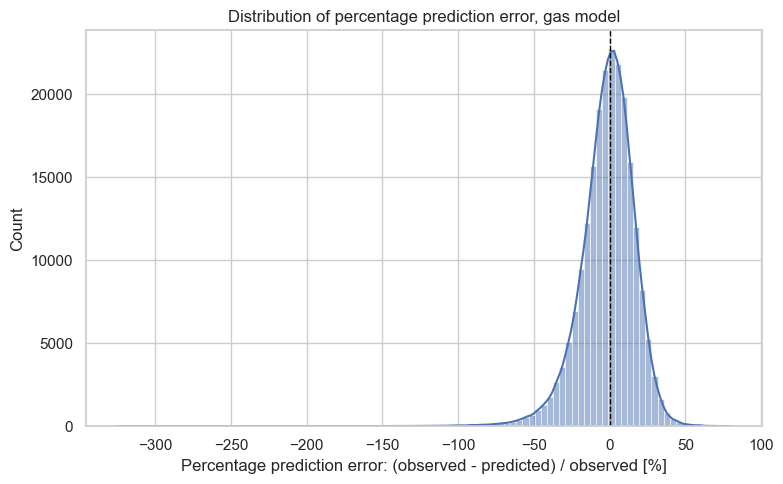

In [177]:
# ----------------------------
# 7.8.1 Error distribution and bias for preferred gas model
# ----------------------------

# ----------------------------
# 1. Check required cross-validation outputs
# ----------------------------

required_gas_cv_outputs = [
    "gas_y_true_model_arr",
    "gas_y_pred_model_arr",
    "gas_y_true_m3_arr",
    "gas_y_pred_m3_arr",
    "gas_model_scale_preferred"
]

missing_gas_cv_outputs = [
    var for var in required_gas_cv_outputs
    if var not in globals()
]

if missing_gas_cv_outputs:
    raise RuntimeError(
        "Missing required gas cross-validation outputs: "
        f"{missing_gas_cv_outputs}. "
        "Run Section 7.5 before running the predictive error diagnostics."
    )

if gas_model_scale_preferred != "log":
    raise RuntimeError(
        "The current preferred gas model is not log-based. "
        "This diagnostic was written for the preferred trimmed log-log gas model."
    )

# ----------------------------
# 2. Convert arrays and check alignment
# ----------------------------

gas_y_true_m3_arr = np.asarray(
    gas_y_true_m3_arr
)

gas_y_pred_m3_arr = np.asarray(
    gas_y_pred_m3_arr
)

gas_y_true_log_arr = np.asarray(
    gas_y_true_model_arr
)

gas_y_pred_log_arr = np.asarray(
    gas_y_pred_model_arr
)

if len(gas_y_true_m3_arr) != len(reg_data_gas_trim):
    raise RuntimeError(
        "The gas prediction arrays do not match the trimmed gas sample length. "
        "Check that Section 7.5 used the trimmed gas sample."
    )

# ----------------------------
# 3. Percentage prediction error
# ----------------------------

# PE = (observed - predicted) / observed
# PE > 0  -> underprediction
# PE < 0  -> overprediction

gas_pct_error = (
    gas_y_true_m3_arr - gas_y_pred_m3_arr
) / gas_y_true_m3_arr

gas_pct_error_percent = (
    gas_pct_error * 100
)

# ----------------------------
# 4. Build gas prediction-error dataframe for later sections
# ----------------------------

gas_error_df = pd.DataFrame({
    "idx": reg_data_gas_trim.index.values,
    "y_true_log": gas_y_true_log_arr,
    "y_pred_log": gas_y_pred_log_arr,
    "y_true": gas_y_true_m3_arr,
    "y_pred": gas_y_pred_m3_arr
})

gas_error_df = gas_error_df.merge(
    reg_data_gas_trim.reset_index().rename(
        columns={"index": "idx"}
    ),
    on="idx",
    how="left"
)

if "postcode" in gas_error_df.columns:
    gas_error_df["pc6"] = gas_error_df["postcode"]
elif "pc6" not in gas_error_df.columns:
    gas_error_df["pc6"] = gas_error_df["idx"]

gas_error_df["pct_error"] = (
    gas_error_df["y_true"] - gas_error_df["y_pred"]
) / gas_error_df["y_true"]

gas_error_df["pct_error_percent"] = (
    gas_error_df["pct_error"] * 100
)

gas_error_df["abs_pct_error"] = np.abs(
    gas_error_df["pct_error"]
)

gas_error_df["abs_pct_error_percent"] = np.abs(
    gas_error_df["pct_error_percent"]
)

# ----------------------------
# 5. Summary statistics
# ----------------------------

gas_error_summary = pd.DataFrame({
    "Metric": [
        "Mean percentage error",
        "Median percentage error",
        "Share of underpredictions",
        "Share of overpredictions",
        "Share of exact predictions, numerically close to zero"
    ],
    "Value": [
        gas_pct_error_percent.mean(),
        np.median(gas_pct_error_percent),
        np.mean(gas_pct_error > 0) * 100,
        np.mean(gas_pct_error < 0) * 100,
        np.mean(np.isclose(gas_pct_error, 0.0)) * 100
    ],
    "Unit": [
        "%",
        "%",
        "%",
        "%",
        "%"
    ]
})

gas_error_summary = gas_error_summary.round({
    "Value": 3
})

# ----------------------------
# 6. Error quantiles
# ----------------------------

gas_error_quantiles = pd.DataFrame({
    "Quantile": [
        "0%",
        "5%",
        "10%",
        "25%",
        "50%",
        "75%",
        "90%",
        "95%",
        "100%"
    ],
    "Percentage_Error": np.percentile(
        gas_pct_error_percent,
        [0, 5, 10, 25, 50, 75, 90, 95, 100]
    )
})

gas_error_quantiles = gas_error_quantiles.round({
    "Percentage_Error": 3
})

# ----------------------------
# 7. Single text-output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas prediction-error definition:</strong>
        PE = (observed - predicted) / observed
    </p>

    <p>
        <strong>Sign convention:</strong>
        positive values indicate underprediction;
        negative values indicate overprediction.
    </p>

    <p>
        <strong>Preferred model:</strong>
        trimmed log-log gas regression
    </p>

    <h4 style="margin-bottom: 6px;">Summary statistics</h4>
    {gas_error_summary.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Prediction-error quantiles</h4>
    {gas_error_quantiles.to_html(index=False)}
</div>
"""

display(HTML(html_output))

# ----------------------------
# 8. Histogram of percentage prediction error
# ----------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    gas_pct_error_percent,
    bins=100,
    kde=True
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Distribution of percentage prediction error, gas model"
)

plt.xlabel(
    "Percentage prediction error: (observed - predicted) / observed [%]"
)

plt.ylabel(
    "Count"
)

plt.tight_layout()
plt.show()

### Interpretation of gas prediction error distribution and bias

**Bias and central tendency**

The mean percentage prediction error is approximately **-1.5%**, while the median percentage error is approximately **0.0%**.

The negative mean indicates a slight overall tendency toward overprediction. However, the magnitude of this average bias is small. The median is essentially zero, which indicates that the typical prediction is well centered around the observed gas consumption.

The shares of underpredictions and overpredictions are nearly perfectly balanced:

- underpredictions: **50.1%**
- overpredictions: **49.9%**

This suggests that the preferred trimmed log-log gas model does not systematically predict too high or too low across the sample as a whole.

**Typical prediction accuracy**

The middle 50% of PC6 areas have percentage prediction errors between approximately:

- **-11.1%** at the 25th percentile
- and **+10.1%** at the 75th percentile

This means that half of the PC6 areas are predicted within roughly **-11% to +10%** of the observed gas consumption.

The broader central 80% range extends from approximately:

- **-23.1%** at the 10th percentile
- to **+18.8%** at the 90th percentile

This indicates that most PC6 areas have moderate relative prediction errors, while larger deviations are concentrated in the tails of the distribution.

**Tail behaviour and asymmetry**

The prediction-error distribution is asymmetric. The most extreme overprediction error is approximately **-325%**, while the strongest underprediction error is approximately **+80%**.

This asymmetry shows that the largest relative errors occur on the overprediction side. Because the percentage error is defined relative to the observed value, overprediction errors can become very large when observed gas consumption is relatively low. Even though the sample excludes very low gas-consumption observations below 440 m³, some lower-consumption PC6 areas can still produce large relative errors if predicted values are substantially higher than observed values.

The histogram confirms this pattern. Most observations are concentrated close to zero, but the distribution has a longer left tail associated with extreme overprediction cases.

**Overall assessment**

Overall, the preferred trimmed log-log gas model shows limited average bias and almost perfectly balanced frequencies of underprediction and overprediction. For the majority of PC6 areas, prediction errors remain moderate and centered around zero.

The main limitation is the presence of a small number of large relative overprediction errors. These cases motivate the more detailed investigation of extreme prediction cases and error patterns across postcode characteristics in the following subsections.

#### 7.8.2 Identification of extreme prediction cases

The previous subsection examined the overall distribution of percentage prediction errors for the preferred trimmed log-log gas model. While most observations are concentrated around zero, the distribution also contains a small number of large relative errors. This subsection identifies these extreme cases more directly.

The analysis focuses on three groups of PC6 areas:

1. the largest absolute percentage prediction errors;
2. the strongest underprediction cases;
3. the strongest overprediction cases.

The same percentage prediction error definition is used as in Section 7.8.1:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

where positive values indicate underprediction and negative values indicate overprediction.

The absolute percentage prediction error is defined as:

$$
|PE_i| = \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

The largest absolute errors show where the model performs least accurately overall. The strongest underprediction cases show PC6 areas where observed gas consumption is substantially higher than predicted. The strongest overprediction cases show PC6 areas where predicted gas consumption is substantially higher than observed consumption.

Because the predictions are obtained from cross-validation, these extreme cases are based on out-of-sample prediction errors rather than in-sample fitted residuals.

In [179]:
# ----------------------------
# 7.8.2 Identification of extreme gas prediction cases
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "gas_error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: gas_error_df. "
        "Run Section 7.8.1 before running the extreme prediction-case diagnostics."
    )

required_gas_error_cols = [
    "pc6",
    "y_true",
    "y_pred",
    "pct_error",
    "pct_error_percent",
    "abs_pct_error",
    "abs_pct_error_percent"
]

missing_gas_error_cols = [
    col for col in required_gas_error_cols
    if col not in gas_error_df.columns
]

if missing_gas_error_cols:
    raise RuntimeError(
        "gas_error_df is missing required columns: "
        f"{missing_gas_error_cols}. "
        "Run Section 7.8.1 again to rebuild gas_error_df."
    )

# ----------------------------
# 2. Identify extreme cases
# ----------------------------

gas_worst_cases = (
    gas_error_df
    .sort_values("abs_pct_error", ascending=False)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

gas_under_cases = (
    gas_error_df
    .sort_values("pct_error", ascending=False)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

gas_over_cases = (
    gas_error_df
    .sort_values("pct_error", ascending=True)
    .head(10)
    .copy()
    .reset_index(drop=True)
)

# ----------------------------
# 3. Select and format display columns
# ----------------------------

gas_cols_display = [
    "pc6",
    "y_true",
    "y_pred",
    "pct_error_percent",
    "abs_pct_error_percent"
]

optional_gas_context_cols = [
    "n_dwellings",
    "mean_floor_area",
    "log_mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_household_size_filled",
    "avg_woz_value_filled"
]

gas_cols_display = gas_cols_display + [
    col for col in optional_gas_context_cols
    if col in gas_error_df.columns
]

def format_gas_extreme_cases(df):
    out = df[gas_cols_display].copy()

    rename_map = {
        "pc6": "PC6",
        "y_true": "Observed_m3_per_dwelling",
        "y_pred": "Predicted_m3_per_dwelling",
        "pct_error_percent": "Prediction_error_%",
        "abs_pct_error_percent": "Absolute_prediction_error_%",
        "n_dwellings": "Number_of_dwellings",
        "mean_floor_area": "Mean_floor_area",
        "log_mean_floor_area": "Log_mean_floor_area",
        "mean_building_year": "Mean_building_year",
        "share_has_gas": "Share_has_gas",
        "avg_household_size_filled": "Average_household_size",
        "avg_woz_value_filled": "Average_WOZ_value"
    }

    out = out.rename(
        columns=rename_map
    )

    round_cols = [
        col for col in out.columns
        if col != "PC6"
    ]

    out[round_cols] = out[round_cols].round(3)

    return out

gas_worst_cases_display = format_gas_extreme_cases(
    gas_worst_cases
)

gas_under_cases_display = format_gas_extreme_cases(
    gas_under_cases
)

gas_over_cases_display = format_gas_extreme_cases(
    gas_over_cases
)

# ----------------------------
# 4. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Extreme gas prediction-case diagnostics</strong>
    </p>

    <p>
        <strong>Preferred model:</strong>
        trimmed log-log gas regression
    </p>

    <p>
        <strong>Sign convention:</strong>
        positive prediction errors indicate underprediction;
        negative prediction errors indicate overprediction.
    </p>

    <h4 style="margin-bottom: 6px;">Top 10 largest absolute prediction errors</h4>
    {gas_worst_cases_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Top 10 underprediction cases</h4>
    {gas_under_cases_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Top 10 overprediction cases</h4>
    {gas_over_cases_display.to_html(index=False)}
</div>
"""

display(HTML(html_output))

PC6,Observed_m3_per_dwelling,Predicted_m3_per_dwelling,Prediction_error_%,Absolute_prediction_error_%,Number_of_dwellings,Mean_floor_area,Mean_building_year,Share_has_gas,Average_household_size,Average_WOZ_value
5211XM,690.0,2933.560,-325.154,325.154,16,67.938,1350.000,1.000,1.7,335.0
3581KD,480.0,1941.483,-304.476,304.476,6,253.833,1906.667,0.833,3.2,1584.0
3512PP,630.0,2315.080,-267.473,267.473,12,50.000,1450.000,1.000,1.0,494.0
1096DR,450.0,1638.132,-264.029,264.029,16,261.500,2018.812,0.438,3.0,2382.0
4873NP,490.0,1724.826,-252.005,252.005,7,437.571,2015.143,0.571,3.1,1193.0
2342CA,470.0,1522.747,-223.989,223.989,17,316.412,2019.412,0.588,3.8,1467.0
8071SW,460.0,1463.383,-218.127,218.127,6,259.333,1959.500,0.667,3.0,817.0
1601JZ,580.0,1819.676,-213.737,213.737,6,65.667,1579.000,1.000,2.0,205.0
3512KZ,550.0,1660.667,-201.939,201.939,17,71.294,1647.765,0.882,1.3,489.0
8538XN,770.0,2321.608,-201.508,201.508,6,398.500,1922.167,0.500,2.2,889.0


### Interpretation of extreme gas prediction cases

The extreme prediction cases show that the largest absolute errors are dominated by overprediction cases. In these PC6 areas, predicted gas consumption is substantially higher than observed gas consumption.

**Overprediction cases**

The strongest overprediction cases have observed gas consumption values between approximately **450 and 770 m³ per dwelling**, while predicted values range from approximately **1,460 to 2,930 m³ per dwelling**. This leads to very large negative percentage errors, ranging from approximately **-202% to -325%**.

These cases are close to the lower end of the trimmed gas sample. Because the percentage error is defined relative to observed gas consumption, large relative errors can occur when observed consumption is relatively low but the model predicts a much higher value.

Several of these PC6 areas also have small numbers of dwellings, and some show unusual structural characteristics, such as very old average construction years or very large average floor areas. This suggests that the most severe overprediction cases may reflect atypical postcode-level observations, small-area sensitivity, or structural combinations that are not well represented by the preferred model.

**Underprediction cases**

The strongest underprediction cases have observed gas consumption values between approximately **1,820 and 3,330 m³ per dwelling**, while predicted values remain much lower, mostly between approximately **500 and 815 m³ per dwelling**. The corresponding percentage errors range from approximately **+71% to +80%**.

These cases indicate PC6 areas where gas consumption is much higher than expected based on the included housing-stock and socioeconomic variables. Some of these areas have relatively small average floor areas and low WOZ values, yet show high observed gas consumption. This suggests that the model misses some characteristics associated with high gas demand, such as dwelling insulation quality, heating system characteristics, occupancy behaviour, or local measurement and classification effects.

A notable issue is that several of the strongest underprediction cases have `share_has_gas = 0` despite having positive observed gas consumption. This is visible for postcode areas such as `2405AS`, `2405AR`, and `2405AT`. These observations are unusual because the structural gas-connection indicator suggests no dwellings with a gas connection, while the CBS gas-consumption variable reports substantial positive gas consumption.

This does not necessarily invalidate the model, but it shows that the gas-connection indicator and the observed gas-consumption target do not always align perfectly at PC6 level. Possible explanations include differences in data sources, timing, classification, aggregation, or measurement definitions. These cases should therefore be interpreted as evidence of data and measurement complexity, not only as model error.

**Asymmetry of extreme errors**

The extreme errors are asymmetric. The largest overprediction errors are much larger in relative magnitude than the largest underprediction errors. This is consistent with the longer left tail observed in the percentage-error distribution in Section 7.8.1.

This asymmetry partly follows from the percentage-error definition. When observed gas consumption is close to the lower end of the trimmed sample, overprediction can produce very large negative percentage errors.

**Overall assessment**

The extreme-case diagnostics show that the preferred trimmed log-log gas model performs less reliably for atypical PC6 areas at the tails of the gas-consumption distribution. The largest overprediction cases are mainly associated with relatively low observed gas consumption, while the largest underprediction cases correspond to unexpectedly high observed gas consumption.

The `share_has_gas = 0` cases further indicate that some extreme errors may reflect inconsistencies or definitional differences between structural gas-connection information and observed gas-consumption data. For the majority of PC6 areas, prediction errors remain much closer to zero. The extreme cases therefore do not undermine the overall model, but they highlight limitations of both the available predictors and the alignment of gas-related data sources.

#### 7.8.3 Error patterns across postcode characteristics

The previous subsections examined the overall prediction-error distribution and the most extreme individual cases. This subsection investigates whether prediction errors vary systematically across postcode characteristics.

The analysis uses a binned diagnostic approach. Numeric variables are divided into quantile-based bins, and the mean and median percentage prediction error are calculated within each bin. This makes it possible to assess whether prediction errors remain centered around zero across different parts of the data or whether some types of PC6 areas are more frequently overpredicted or underpredicted.

The diagnostic scan includes both explanatory variables and selected descriptive characteristics, such as the number of dwellings and the observed gas-consumption level. The observed gas-consumption level is included only as a diagnostic variable, not as an explanatory variable in the model. It is used to assess whether prediction errors are larger at the lower or upper end of the gas-demand distribution.

For each variable, the range of mean and median prediction errors across bins is calculated. Larger ranges indicate stronger variation in prediction error across that variable. These diagnostics are descriptive and should not be interpreted causally. They are used to identify where the preferred trimmed log-log gas model performs more or less accurately.

In [180]:
# ----------------------------
# 7.8.3 Error patterns across postcode characteristics
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "gas_error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: gas_error_df. "
        "Run Section 7.8.1 before running the gas error-pattern diagnostics."
    )

required_gas_error_cols = [
    "pct_error_percent",
    "y_true"
]

missing_gas_error_cols = [
    col for col in required_gas_error_cols
    if col not in gas_error_df.columns
]

if missing_gas_error_cols:
    raise RuntimeError(
        "gas_error_df is missing required columns: "
        f"{missing_gas_error_cols}. "
        "Run Section 7.8.1 again to rebuild gas_error_df."
    )

# ----------------------------
# 2. Define variables for binned diagnostics
# ----------------------------

exclude_gas_cols = [
    "idx",
    "postcode",
    "pc6",
    "y_true_log",
    "y_pred_log",
    "y_pred",
    "pct_error",
    "pct_error_percent",
    "abs_pct_error",
    "abs_pct_error_percent",
    "gas_avg_per_dwelling_pc6"
]

# Exclude other energy outcomes if present.
# y_true is kept deliberately as a diagnostic variable for observed gas level.
gas_energy_outcome_cols = [
    "kwh_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6",
    "kwh_gross_proxy_pc6"
]

exclude_gas_cols = exclude_gas_cols + [
    c for c in gas_energy_outcome_cols
    if c in gas_error_df.columns
]

gas_analysis_vars = [
    c for c in gas_error_df.columns
    if c not in exclude_gas_cols
    and pd.api.types.is_numeric_dtype(gas_error_df[c])
]

# Put the most useful diagnostic variables first if they exist
gas_priority_vars = [
    "y_true",
    "n_dwellings",
    "mean_floor_area",
    "log_mean_floor_area",
    "share_has_gas",
    "avg_household_size_filled",
    "avg_woz_value_filled",
    "mean_building_year"
]

gas_analysis_vars = (
    [v for v in gas_priority_vars if v in gas_analysis_vars]
    + [v for v in gas_analysis_vars if v not in gas_priority_vars]
)

# ----------------------------
# 3. Helper functions
# ----------------------------

def readable_gas_var_name(var):
    rename_map = {
        "y_true": "Observed gas consumption",
        "n_dwellings": "Number of dwellings",
        "mean_floor_area": "Mean floor area",
        "log_mean_floor_area": "Log mean floor area",
        "share_has_gas": "Share with gas connection",
        "avg_household_size_filled": "Average household size",
        "avg_woz_value_filled": "Average WOZ value",
        "mean_building_year": "Mean building year"
    }

    return rename_map.get(var, var)


def binned_gas_error_table(df, var, n_bins=10):
    temp = df[
        [
            var,
            "pct_error_percent"
        ]
    ].dropna().copy()

    if temp[var].nunique() < 2:
        return None

    temp["bin"] = pd.qcut(
        temp[var],
        q=n_bins,
        duplicates="drop"
    )

    out = (
        temp
        .groupby("bin", observed=False)["pct_error_percent"]
        .agg(
            Mean_error_percent="mean",
            Median_error_percent="median",
            Count="count"
        )
        .reset_index()
    )

    out.insert(
        0,
        "Variable",
        readable_gas_var_name(var)
    )

    out = out.rename(
        columns={
            "bin": "Bin"
        }
    )

    return out


def summarize_binned_gas_error(df, var, n_bins=10):
    table = binned_gas_error_table(
        df,
        var,
        n_bins=n_bins
    )

    if table is None or table.shape[0] < 2:
        return None

    mean_range = (
        table["Mean_error_percent"].max()
        - table["Mean_error_percent"].min()
    )

    median_range = (
        table["Median_error_percent"].max()
        - table["Median_error_percent"].min()
    )

    max_abs_mean = table["Mean_error_percent"].abs().max()
    max_abs_median = table["Median_error_percent"].abs().max()

    return {
        "Variable": readable_gas_var_name(var),
        "Original_variable": var,
        "Number_of_bins": table.shape[0],
        "Mean_error_range_percentage_points": mean_range,
        "Median_error_range_percentage_points": median_range,
        "Max_abs_mean_error_percent": max_abs_mean,
        "Max_abs_median_error_percent": max_abs_median,
        "Total_observations": int(table["Count"].sum())
    }

# ----------------------------
# 4. Compute binned diagnostics
# ----------------------------

gas_binned_results = {}
gas_pattern_summary_records = []

for var in gas_analysis_vars:
    table = binned_gas_error_table(
        gas_error_df,
        var,
        n_bins=10
    )

    summary = summarize_binned_gas_error(
        gas_error_df,
        var,
        n_bins=10
    )

    if table is not None and summary is not None:
        gas_binned_results[var] = table
        gas_pattern_summary_records.append(summary)

gas_pattern_summary = pd.DataFrame(
    gas_pattern_summary_records
)

if gas_pattern_summary.empty:
    raise RuntimeError(
        "No valid numeric variables were available for gas binned error diagnostics."
    )

gas_pattern_summary = (
    gas_pattern_summary
    .sort_values(
        "Median_error_range_percentage_points",
        ascending=False
    )
    .reset_index(drop=True)
)

gas_pattern_summary_display = gas_pattern_summary.round({
    "Mean_error_range_percentage_points": 3,
    "Median_error_range_percentage_points": 3,
    "Max_abs_mean_error_percent": 3,
    "Max_abs_median_error_percent": 3
})

# ----------------------------
# 5. Select detailed binned tables for display
# ----------------------------

# Show strongest patterns, but avoid flooding the notebook.
gas_top_detail_vars = (
    gas_pattern_summary["Original_variable"]
    .head(5)
    .tolist()
)

# Ensure key diagnostics are included if available
for key_var in [
    "y_true",
    "n_dwellings",
    "mean_floor_area",
    "share_has_gas"
]:
    if key_var in gas_binned_results and key_var not in gas_top_detail_vars:
        gas_top_detail_vars.append(key_var)

# Limit detailed tables to keep output manageable
gas_top_detail_vars = gas_top_detail_vars[:8]

gas_detailed_tables_html = ""

for var in gas_top_detail_vars:
    table_display = gas_binned_results[var].copy()

    table_display["Bin"] = (
        table_display["Bin"]
        .astype(str)
    )

    table_display = table_display.round({
        "Mean_error_percent": 3,
        "Median_error_percent": 3
    })

    gas_detailed_tables_html += f"""
    <h4 style="margin-bottom: 6px; margin-top: 16px;">
        Error by {readable_gas_var_name(var)}
    </h4>
    {table_display.to_html(index=False)}
    """

# ----------------------------
# 6. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas binned prediction-error diagnostics</strong>
    </p>

    <p>
        Variables are grouped into quantile-based bins.
        Mean and median prediction errors are reported in percentage points.
    </p>

    <p>
        <strong>Preferred model:</strong>
        trimmed log-log gas regression
    </p>

    <h4 style="margin-bottom: 6px;">Variables with strongest binned error variation</h4>
    {gas_pattern_summary_display.head(15).to_html(index=False)}

    {gas_detailed_tables_html}
</div>
"""

display(HTML(html_output))

Variable,Original_variable,Number_of_bins,Mean_error_range_percentage_points,Median_error_range_percentage_points,Max_abs_mean_error_percent,Max_abs_median_error_percent,Total_observations
Observed gas consumption,y_true,10,37.251,35.281,22.218,19.760,215228
Mean building year,mean_building_year,10,13.210,11.023,9.400,6.475,215228
Average WOZ value,avg_woz_value_filled,10,6.458,6.484,3.620,4.300,215228
private_households_total,private_households_total,6,5.174,6.237,5.769,4.648,213058
Number of dwellings,n_dwellings,10,4.662,5.575,5.037,3.914,215228
population_total,population_total,9,3.873,4.384,4.676,3.308,214239
Share with gas connection,share_has_gas,3,6.609,4.275,7.129,3.628,215228
Mean floor area,mean_floor_area,10,1.479,3.747,2.099,2.877,215228
Average household size,avg_household_size_filled,10,3.517,3.501,3.839,2.514,215228
share_dwelling_type_Flatwoning (overig),share_dwelling_type_Flatwoning (overig),3,3.000,3.424,4.138,2.953,215228


### Interpretation of error patterns across postcode characteristics

The binned diagnostic scan shows that prediction errors vary most strongly across the level of observed gas consumption. This is the clearest pattern in the results. The range of median prediction errors across observed-gas-consumption bins is approximately **35 percentage points**, which is much larger than for the other postcode characteristics.

For observed gas consumption, the mean prediction error moves from approximately **-22.2%** in the lowest consumption bin to approximately **+15.0%** in the highest consumption bin. The median error follows the same pattern, increasing from approximately **-19.8%** to **+15.5%**. This indicates that the model tends to overpredict low-consumption PC6 areas and underpredict high-consumption PC6 areas.

This pattern is similar to the electricity model, but it is somewhat stronger for gas. The preferred trimmed log-log gas model performs best in the middle of the gas-consumption distribution and less accurately at the lower and upper tails.

Compared with the observed-consumption pattern, most structural and socioeconomic variables show smaller error variation. However, mean building year shows a noticeable pattern. The median prediction error varies by approximately **11 percentage points** across building-year bins. Older PC6 areas and the newest PC6 areas tend to be overpredicted, while several mid-century construction-year bins show positive errors, indicating underprediction. This suggests that the relationship between building vintage and gas consumption may not be fully captured by the additive log-log specification.

Average WOZ value, number of dwellings, total private households, population total, and gas-connection share also show some variation, but the magnitudes are smaller. For example, the median error range is approximately:

- **6.5 percentage points** for average WOZ value
- **6.2 percentage points** for total private households
- **5.6 percentage points** for number of dwellings
- **4.3 percentage points** for gas-connection share
- **3.7 percentage points** for mean floor area

The pattern for gas-connection share is also informative. PC6 areas with lower gas-connection shares show more negative errors, indicating overprediction, while areas with gas-connection shares close to one have errors closer to zero. This is consistent with the extreme-case diagnostics, where some observations showed imperfect alignment between the gas-connection indicator and observed gas consumption.

Mean floor area shows relatively limited systematic error variation. This suggests that the log transformation of floor area captures much of the relationship between dwelling size and gas consumption, although it does not eliminate all prediction error.

Some variables in the diagnostic scan, such as total population and total private households, are included only as descriptive postcode characteristics. They are used here to examine whether prediction errors vary with postcode size or composition, not to introduce new explanatory variables into the preferred regression model.

Overall, the results suggest that the main remaining prediction-error pattern is scale-dependent: low-gas-consumption PC6 areas tend to be overpredicted, while high-gas-consumption PC6 areas tend to be underpredicted. In addition, building year shows a meaningful residual pattern, indicating that nonlinear vintage effects may remain partly unresolved in the preferred trimmed log-log specification.

#### 7.8.4 Prediction error across gas-consumption levels

The binned diagnostic scan in Section 7.8.3 showed that prediction errors vary most strongly across observed gas-consumption levels. This subsection therefore visualizes this pattern directly.

PC6 areas are grouped into deciles based on observed average gas consumption per dwelling. For each decile, the mean and median percentage prediction error are calculated. This allows the direction and magnitude of prediction error to be compared across the gas-consumption distribution.

The purpose of this diagnostic is not to introduce a new model, but to summarize the main remaining error pattern in the preferred trimmed log-log gas specification.

Bin_label,Mean_error_percent,Median_error_percent,Count
"(449.999, 620.0]",-22.218,-19.760,23161
"(620.0, 700.0]",-11.961,-10.953,21609
"(700.0, 760.0]",-7.860,-7.373,20375
"(760.0, 820.0]",-4.624,-4.538,21964
"(820.0, 880.0]",-1.834,-1.655,22249
"(880.0, 940.0]",1.089,1.422,20994
"(940.0, 1010.0]",3.651,4.364,21157
"(1010.0, 1110.0]",6.396,7.326,22396
"(1110.0, 1270.0]",9.381,10.042,20326
"(1270.0, 4690.0]",15.033,15.520,20997


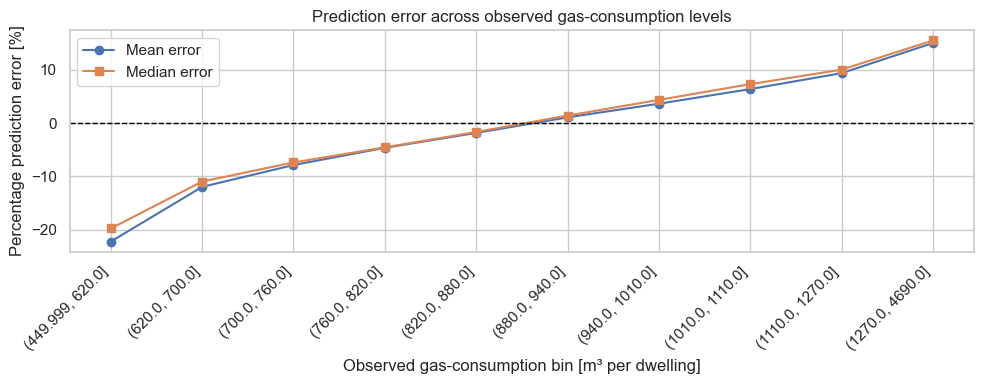

In [181]:
# ----------------------------
# 7.8.4 Prediction error across gas-consumption levels
# ----------------------------

# ----------------------------
# 1. Check required prediction-error dataframe
# ----------------------------

if "gas_error_df" not in globals():
    raise RuntimeError(
        "Missing required dataframe: gas_error_df. "
        "Run Section 7.8.1 before running this diagnostic."
    )

required_cols = [
    "y_true",
    "pct_error_percent"
]

missing_cols = [
    col for col in required_cols
    if col not in gas_error_df.columns
]

if missing_cols:
    raise RuntimeError(
        "gas_error_df is missing required columns: "
        f"{missing_cols}. "
        "Run Section 7.8.1 again to rebuild gas_error_df."
    )

# ----------------------------
# 2. Create gas-consumption deciles
# ----------------------------

gas_consumption_error_df = gas_error_df[
    [
        "y_true",
        "pct_error_percent"
    ]
].dropna().copy()

gas_consumption_error_df["gas_consumption_bin"] = pd.qcut(
    gas_consumption_error_df["y_true"],
    q=10,
    duplicates="drop"
)

# ----------------------------
# 3. Compute mean and median error by bin
# ----------------------------

gas_consumption_error_bins = (
    gas_consumption_error_df
    .groupby("gas_consumption_bin", observed=False)["pct_error_percent"]
    .agg(
        Mean_error_percent="mean",
        Median_error_percent="median",
        Count="count"
    )
    .reset_index()
)

gas_consumption_error_bins["Bin_label"] = (
    gas_consumption_error_bins["gas_consumption_bin"]
    .astype(str)
)

gas_consumption_error_bins_display = gas_consumption_error_bins.copy()

gas_consumption_error_bins_display = gas_consumption_error_bins_display.round({
    "Mean_error_percent": 3,
    "Median_error_percent": 3
})

# ----------------------------
# 4. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas prediction error across observed gas-consumption levels</strong>
    </p>

    <p>
        PC6 areas are grouped into deciles based on observed gas consumption.
        Positive errors indicate underprediction; negative errors indicate overprediction.
    </p>

    {gas_consumption_error_bins_display[
        [
            "Bin_label",
            "Mean_error_percent",
            "Median_error_percent",
            "Count"
        ]
    ].to_html(index=False)}
</div>
"""

display(HTML(html_output))

# ----------------------------
# 5. Plot prediction error across gas-consumption bins
# ----------------------------

plt.figure(figsize=(10, 4))

x = np.arange(
    len(gas_consumption_error_bins)
)

plt.plot(
    x,
    gas_consumption_error_bins["Mean_error_percent"],
    marker="o",
    label="Mean error"
)

plt.plot(
    x,
    gas_consumption_error_bins["Median_error_percent"],
    marker="s",
    label="Median error"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    gas_consumption_error_bins["Bin_label"],
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Percentage prediction error [%]"
)

plt.xlabel(
    "Observed gas-consumption bin [m³ per dwelling]"
)

plt.title(
    "Prediction error across observed gas-consumption levels"
)

plt.legend()

plt.tight_layout()
plt.show()

### Interpretation of prediction error across gas-consumption levels

The decile plot confirms the main error pattern identified in the broader diagnostic scan. Prediction errors vary systematically across observed gas-consumption levels.

In the lowest gas-consumption bin, between approximately **450 and 620 m³ per dwelling**, both the mean and median prediction errors are strongly negative. The mean error is approximately **-22.2%**, and the median error is approximately **-19.8%**. This indicates that the preferred trimmed log-log gas model tends to overpredict gas consumption for low-consumption PC6 areas.

As observed gas consumption increases, the prediction errors move steadily toward zero. Around the middle of the distribution, especially between approximately **820 and 940 m³ per dwelling**, the errors are close to zero. This suggests that the model performs best for PC6 areas with mid-range gas consumption.

For higher gas-consumption bins, the prediction errors become positive. In the highest bin, above approximately **1,270 m³ per dwelling**, the mean error is approximately **+15.0%**, and the median error is approximately **+15.5%**. This indicates that the model tends to underpredict gas consumption for high-consumption PC6 areas.

The pattern is almost monotonic: prediction errors increase from strong overprediction in the lowest consumption bins to clear underprediction in the highest consumption bins. This shows that the preferred gas model does not fully capture the tails of the gas-consumption distribution.

Overall, the model is well centered for the sample as a whole, but its errors are scale-dependent. It tends to overpredict low-gas-consumption PC6 areas and underpredict high-gas-consumption PC6 areas. This limitation is important when interpreting predictions for postcode areas at the lower or upper end of the gas-demand distribution.

### 7.9 Random Forest feature-importance analysis

The Random Forest benchmark estimated in Section 7.7 showed that the nonlinear model improves gas-demand prediction relative to the preferred trimmed log-log regression. This section examines which predictors contribute most strongly to the fitted Random Forest model.

Unlike the OLS regression model, Random Forest does not provide directly interpretable coefficients. Instead, predictor relevance is assessed through feature-importance measures derived from the fitted ensemble.

Two complementary measures are used:

1. **Permutation importance**  
   - This measures the change in predictive performance when the values of one predictor are randomly shuffled, while all other predictors are kept unchanged.  
   - If prediction error increases strongly after shuffling a variable, that variable is considered important for the fitted Random Forest model.  
   - This measure is prioritized in the interpretation because it directly evaluates how much predictive performance depends on each variable.

2. **Impurity-based importance**  
   - This measures how much each predictor contributes to reducing prediction error across the decision trees in the forest.  
   - Variables that are frequently used for informative splits receive larger importance scores.  
   - The scores are normalized to sum to one.

Random Forest feature importance is useful because it captures nonlinear predictive relevance rather than linear marginal associations. It can also reflect interactions and threshold effects that are not explicitly specified in the regression model.

However, feature importance should be interpreted as a measure of predictive contribution within the fitted Random Forest model, not as causal influence. In addition, correlated variables may share importance across one another. This is particularly relevant for compositional variables such as dwelling-type shares and energy-label shares.

To maintain consistency with the nonlinear benchmark in Section 7.7:

- the fitted Random Forest model from Section 7.7 is reused;
- the same predictor set, `X_gas_rf_sklearn`, is used;
- the same dependent variable, `y_gas_rf_log`, is used;
- no new Random Forest model is estimated for predictive-performance reporting.

The full-sample fitted Random Forest is used only for feature-importance diagnostics. The cross-validated prediction errors were already reported in Section 7.7.

In [182]:
# ----------------------------
# 7.9 Random Forest feature-importance analysis for gas
# Reuse fitted Random Forest from Section 7.7
# ----------------------------

# ----------------------------
# 1. Sanity checks
# ----------------------------

required_rf_importance_objects_gas = [
    "rf_gas_model_exp",
    "X_gas_rf_sklearn",
    "y_gas_rf_log"
]

missing_rf_importance_objects_gas = [
    obj for obj in required_rf_importance_objects_gas
    if obj not in globals()
]

if missing_rf_importance_objects_gas:
    raise RuntimeError(
        "Missing required objects for gas RF feature importance: "
        f"{missing_rf_importance_objects_gas}. "
        "Run Section 7.7 before running Section 7.9."
    )

if not hasattr(rf_gas_model_exp, "feature_importances_"):
    raise RuntimeError(
        "rf_gas_model_exp is not fitted. "
        "Run Section 7.7 first, including the final full-sample RF fit."
    )

if len(rf_gas_model_exp.feature_importances_) != X_gas_rf_sklearn.shape[1]:
    raise RuntimeError(
        "The number of Random Forest feature importances does not match "
        "the number of predictors in X_gas_rf_sklearn. "
        "Check that the fitted RF model and predictor matrix come from the same section."
    )

# ----------------------------
# 2. Helper function for variable grouping
# ----------------------------

def classify_gas_rf_variable(var):
    if var == "log_mean_floor_area":
        return "Structural"
    elif var == "mean_building_year":
        return "Structural"
    elif var == "share_has_gas":
        return "Infrastructure"
    elif var.startswith("share_dwelling_type_"):
        return "Dwelling type share"
    elif var.startswith("share_energy_label_"):
        return "Energy label share"
    elif var in [
        "avg_woz_value_filled",
        "avg_household_size_filled",
        "avg_household_size_missing",
        "share_population_on_benefits_filled"
    ]:
        return "CBS socioeconomic"
    else:
        return "Other"

# ----------------------------
# 3. Permutation importance
# ----------------------------

gas_perm_result = permutation_importance(
    rf_gas_model_exp,
    X_gas_rf_sklearn,
    y_gas_rf_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

rf_gas_perm_importance = pd.DataFrame({
    "Variable": X_gas_rf_sklearn.columns,
    "Permutation_Importance_Mean": gas_perm_result.importances_mean,
    "Permutation_Importance_SD": gas_perm_result.importances_std
})

rf_gas_perm_importance["Group"] = (
    rf_gas_perm_importance["Variable"]
    .apply(classify_gas_rf_variable)
)

rf_gas_perm_importance = (
    rf_gas_perm_importance
    .sort_values("Permutation_Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

rf_gas_perm_importance["Permutation_Rank"] = (
    rf_gas_perm_importance.index + 1
)

# ----------------------------
# 4. Impurity-based importance
# ----------------------------

rf_gas_impurity_importance = pd.DataFrame({
    "Variable": X_gas_rf_sklearn.columns,
    "Impurity_Importance": rf_gas_model_exp.feature_importances_
})

rf_gas_impurity_importance["Group"] = (
    rf_gas_impurity_importance["Variable"]
    .apply(classify_gas_rf_variable)
)

rf_gas_impurity_importance = (
    rf_gas_impurity_importance
    .sort_values("Impurity_Importance", ascending=False)
    .reset_index(drop=True)
)

rf_gas_impurity_importance["Impurity_Rank"] = (
    rf_gas_impurity_importance.index + 1
)

# ----------------------------
# 5. Ranking comparison
# ----------------------------

rf_gas_importance_comparison = (
    rf_gas_perm_importance[
        [
            "Variable",
            "Group",
            "Permutation_Rank",
            "Permutation_Importance_Mean"
        ]
    ]
    .merge(
        rf_gas_impurity_importance[
            [
                "Variable",
                "Impurity_Rank",
                "Impurity_Importance"
            ]
        ],
        on="Variable",
        how="left"
    )
)

rf_gas_importance_comparison["Rank_Difference"] = (
    rf_gas_importance_comparison["Impurity_Rank"]
    - rf_gas_importance_comparison["Permutation_Rank"]
)

# ----------------------------
# 6. Rounded display tables
# ----------------------------

rf_gas_perm_importance_display = rf_gas_perm_importance.copy()
rf_gas_impurity_importance_display = rf_gas_impurity_importance.copy()
rf_gas_importance_comparison_display = rf_gas_importance_comparison.copy()

rf_gas_perm_importance_display = rf_gas_perm_importance_display.round({
    "Permutation_Importance_Mean": 6,
    "Permutation_Importance_SD": 6
})

rf_gas_impurity_importance_display = rf_gas_impurity_importance_display.round({
    "Impurity_Importance": 6
})

rf_gas_importance_comparison_display = rf_gas_importance_comparison_display.round({
    "Permutation_Importance_Mean": 6,
    "Impurity_Importance": 6
})

# ----------------------------
# 7. Single output box
# ----------------------------

html_output = f"""
<div style="
    border: 1px solid #cccccc;
    border-radius: 6px;
    padding: 12px;
    margin-top: 8px;
">
    <p style="margin-top: 0;">
        <strong>Gas Random Forest feature-importance diagnostics</strong>
    </p>

    <p>
        <strong>Model:</strong>
        fitted Random Forest benchmark from Section 7.7
    </p>

    <p>
        <strong>Predictor matrix:</strong>
        preferred trimmed log-log gas specification
    </p>

    <p>
        <strong>Interpretation:</strong>
        importance values indicate predictive relevance in the fitted Random Forest,
        not causal effects.
    </p>

    <h4 style="margin-bottom: 6px;">Permutation importance</h4>
    {rf_gas_perm_importance_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Impurity-based importance</h4>
    {rf_gas_impurity_importance_display.to_html(index=False)}

    <h4 style="margin-bottom: 6px; margin-top: 16px;">Comparison of importance rankings</h4>
    {rf_gas_importance_comparison_display.to_html(index=False)}
</div>
"""

display(HTML(html_output))

Variable,Permutation_Importance_Mean,Permutation_Importance_SD,Group,Permutation_Rank
log_mean_floor_area,0.065665,0.000151,Structural,1
mean_building_year,0.026208,0.000056,Structural,2
avg_woz_value_filled,0.009359,0.000029,CBS socioeconomic,3
avg_household_size_filled,0.005438,0.000018,CBS socioeconomic,4
share_energy_label_A,0.004511,0.000024,Energy label share,5
share_has_gas,0.004123,0.000030,Infrastructure,6
share_dwelling_type_Rijwoning tussen,0.003140,0.000015,Dwelling type share,7
share_dwelling_type_Twee-onder-een-kap / rijwoning hoek,0.002536,0.000010,Dwelling type share,8
share_dwelling_type_Vrijstaande woning,0.002045,0.000016,Dwelling type share,9
share_energy_label_B,0.001798,0.000008,Energy label share,10


### Interpretation of Random Forest feature importance

Permutation importance is treated as the primary feature-importance measure because it evaluates how much prediction error increases when each predictor is randomly shuffled. The values therefore indicate predictive relevance within the fitted Random Forest model.

The ranking shows that `log_mean_floor_area` is the most important predictor. Its permutation importance is clearly higher than that of the other variables, suggesting that average dwelling size is the main variable used by the Random Forest when predicting average gas consumption per dwelling.

The second-ranked variable is `mean_building_year`, followed by `avg_woz_value_filled`, `avg_household_size_filled`, `share_energy_label_A`, and `share_has_gas`. These variables also contribute to prediction, but their importance values are noticeably lower than that of floor area.

| Rank | Variable | Permutation importance |
|---:|---|---:|
| 1 | `log_mean_floor_area` | 0.0657 |
| 2 | `mean_building_year` | 0.0262 |
| 3 | `avg_woz_value_filled` | 0.0094 |
| 4 | `avg_household_size_filled` | 0.0054 |
| 5 | `share_energy_label_A` | 0.0045 |
| 6 | `share_has_gas` | 0.0041 |
| 7 | `share_dwelling_type_Rijwoning tussen` | 0.0031 |
| 8 | `share_dwelling_type_Twee-onder-een-kap / rijwoning hoek` | 0.0025 |

The ranking suggests that the Random Forest relies mostly on a small set of structural and socioeconomic variables. Dwelling-type and energy-label shares appear lower in the ranking. Some of these variables still contribute to prediction, but their individual importance values are relatively small.

The impurity-based importance results are broadly consistent with the permutation ranking. They also place `log_mean_floor_area` first, followed by `mean_building_year` and `avg_woz_value_filled`. The next variables are `share_energy_label_A`, `share_has_gas`, and `avg_household_size_filled`, with only small differences in order compared with the permutation ranking.

However, the impurity-based measure assigns a very large share of total importance to `log_mean_floor_area` and `mean_building_year`. This should be interpreted cautiously, because impurity-based importance reflects the internal splitting behaviour of the forest and can be more concentrated than permutation importance.

Overall, both measures indicate that floor area is the dominant predictor in the Random Forest benchmark, followed by building year, WOZ value, household size, gas-connection share, and selected energy-label and dwelling-type shares. The composition variables related to dwelling type and energy labels provide additional predictive information, but they are not the main drivers of the Random Forest predictions.

These results should be interpreted only as measures of predictive contribution within the fitted model. They do not imply causal effects. In addition, correlated or compositional variables may share importance, so the ranking should not be read as a precise independent contribution of each individual predictor.

### 7.10 Concluding remarks for Chapter 7

This chapter examined how postcode-level housing-stock characteristics and socioeconomic variables are associated with average gas consumption per dwelling. The analysis developed, compared, and validated alternative gas regression specifications at the PC6 level, while accounting for gas-specific modelling issues.

Three base OLS specifications were estimated on the positive-gas sample: a linear model in levels, a log-level model with a logarithmic dependent variable, and a log-log model with both the dependent variable and average floor area expressed logarithmically. Because very low positive gas-consumption values may represent atypical partial gas use rather than regular residential heating demand, the same specifications were also estimated on a trimmed sample excluding PC6 areas with gas consumption below 440 m³ per dwelling.

The comparison showed that trimming very low gas-consumption observations substantially improves the behaviour of the gas models, especially the log-based specifications. Within the trimmed sample, the linear and log-log models perform similarly, but the trimmed log-log model provides the strongest overall balance between residual behaviour, out-of-sample predictive performance, and interpretability in proportional terms. It is therefore retained as the preferred gas regression specification.

The preferred trimmed log-log model indicates that gas consumption per dwelling is systematically associated with several housing-stock and socioeconomic characteristics. Average floor area, building year, gas-connection share, dwelling-type composition, energy-label composition, household size, and WOZ value all contribute to the model. However, these relationships should not be interpreted as causal effects. They describe conditional statistical associations across PC6 areas after accounting for the other included variables.

The multicollinearity assessment showed that most continuous structural and socioeconomic variables have acceptable VIF values, while some composition-related variables show very high VIF values. In particular, `share_energy_label_no_label` and `share_dwelling_type_unknown` have extremely elevated VIF values, and selected energy-label shares also show strong multicollinearity. This does not invalidate the model or its predictive use, but it limits the reliability of interpreting individual coefficients for highly collinear composition-share variables. The gas regression results are therefore most useful for understanding broader structural and compositional patterns rather than assigning precise independent importance to every individual category.

The predictive assessment showed that the preferred trimmed log-log regression generalizes meaningfully beyond the estimation sample. In 10-fold cross-validation, it performs better than the trimmed linear and log-level models on the main original-scale error metrics, although the trimmed linear model remains a close benchmark. This supports retaining the trimmed log-log model as the preferred gas specification.

The predictive error diagnostics showed that the model is well centered overall. The mean percentage prediction error is small, the median error is close to zero, and the shares of underpredictions and overpredictions are nearly balanced. However, the errors are not distributed uniformly across the gas-consumption range. The clearest remaining pattern is scale-dependent: low-gas-consumption PC6 areas tend to be overpredicted, while high-gas-consumption PC6 areas tend to be underpredicted.

The extreme-case diagnostics further showed that some large errors are associated with atypical PC6 areas. In particular, several strong underprediction cases have positive observed gas consumption despite `share_has_gas = 0`. These observations suggest that the gas-connection indicator and the CBS gas-consumption target do not always align perfectly at PC6 level. This highlights the importance of interpreting gas model errors not only as model limitations, but also as evidence of data and measurement complexity.

The Random Forest benchmark achieved lower prediction error than the preferred trimmed log-log regression. The improvement was larger than in the electricity case, suggesting that nonlinear relationships and interactions play a more important predictive role in gas demand. This is plausible because residential gas consumption is closely linked to heating demand, which may depend on combinations of dwelling size, building vintage, insulation quality, gas-connection availability, dwelling type, and household characteristics. Nevertheless, the Random Forest is retained as a nonlinear predictive benchmark rather than as the main analytical model, because it does not provide directly interpretable coefficients.

The Random Forest feature-importance analysis showed that gas-demand prediction in the nonlinear benchmark relies most strongly on `log_mean_floor_area`, followed by `mean_building_year` and `avg_woz_value_filled`. Household size, gas-connection share, selected energy-label shares, and selected dwelling-type shares provide additional predictive information. These rankings should be interpreted only as model-based indicators of predictive relevance, not as causal effects or independent contributions.

Overall, Chapter 7 shows that postcode-level structural and socioeconomic variables contain substantial predictive and explanatory information for average gas consumption per dwelling. The preferred trimmed log-log regression provides a defensible main specification because it combines reasonable predictive performance, improved residual behaviour, and interpretable proportional associations. At the same time, the validation results show that gas demand contains stronger nonlinear structure than electricity demand and that some prediction errors reflect limitations in the available predictors and in the alignment of gas-related data sources. The model should therefore be interpreted as a statistical prediction framework, not as a causal explanation of household gas consumption.

# Chapter 8 Regression-informed Standard Load Profile scaling

The previous chapters developed and evaluated regression models for estimating average annual residential electricity consumption at PC6 level. This chapter connects those annual predictions to temporal demand reconstruction using Dutch Standard Load Profiles (SLPs).

The SLP dataset contains quarter-hourly profile fractions. These fractions describe how annual electricity consumption is distributed across the year. By multiplying an annual electricity value by the SLP fraction for each quarter-hour, an annual consumption estimate can be translated into a quarter-hourly load profile.

This chapter compares two profile-generation approaches:

1. Observed SLP scaling, where the SLP is scaled using observed CBS annual electricity consumption.
2. Regression-informed SLP scaling, where the same SLP is scaled using annual electricity consumption predicted by the preferred regression model.

The purpose is not to reproduce the full Dutch settlement methodology or to improve upon observed annual consumption. Instead, the objective is to assess how much the generated load profile changes when observed annual electricity consumption is replaced by regression-predicted annual consumption.

Only the SLP profile fractions are used. Tariff correction, climate correction, and measurement correction factors from the official profiling methodology are not applied, because the comparison focuses only on the effect of replacing the annual scaling value.

## 8.1 Import and preparation of Dutch electricity Standard Load Profiles

This section imports the 2023 Dutch electricity Standard Load Profile dataset and converts it into a structured quarter-hourly time series.

The 2023 SLP file is used because the annual electricity values and regression model in this thesis refer to 2023. This avoids combining 2023 annual consumption values with a profile shape from a different year.

The file contains quarter-hour profile fractions for different electricity profile categories. For this chapter, the `E1A` profile is selected as the representative small-consumer electricity profile.

The purpose of this section is to:

- load the 2023 SLP file
- extract available profile categories
- verify the quarter-hourly timestamp structure
- check the annual sum of the selected SLP profile
- select the profile fraction series used in the following sections

In [ ]:
# ----------------------------
# 8.1 Import and structure Dutch Standard Load Profiles
# 2023 version
# ----------------------------

def read_dutch_slp_2023_csv(csv_path):
    """
    Read Dutch electricity SLP CSV for 2023.
    Automatically detects delimiter.
    """

    with open(csv_path, "r", encoding="utf-8-sig") as f:
        header_line = f.readline().strip()

    possible_separators = [";", "\t", ","]

    sep = None

    for candidate in possible_separators:
        if len(header_line.split(candidate)) > 1:
            sep = candidate
            break

    if sep is None:
        raise ValueError("Could not detect CSV separator.")

    parts = header_line.split(sep)

    raw_names = [
        p for p in parts[3:]
        if p != ""
    ]

    profile_names = [
        n.split("_", 1)[1]
        if "_" in n
        else n
        for n in raw_names
    ]

    df = pd.read_csv(
        csv_path,
        sep=sep,
        encoding="utf-8-sig",
        decimal=".",
        skiprows=6,
        header=None
    )

    df = df.dropna(axis=1, how="all")

    if df.shape[1] != 3 + len(profile_names):
        raise ValueError(
            "Column mismatch after reading SLP file. "
            "Check separator and number of skipped rows."
        )

    df.columns = (
        ["time", "from", "to"]
        + profile_names
    )

    df["time"] = pd.to_datetime(
        df["time"],
        dayfirst=True,
        errors="coerce"
    )

    df = (
        df
        .dropna(subset=["time"])
        .set_index("time")
    )

    df.index.name = "time"

    return df


slp_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\SLP"
) / "profielen elektriciteit 2023 versie 1.02.csv"

slp_df = read_dutch_slp_2023_csv(slp_path)

profile_cols = [
    c for c in slp_df.columns
    if c not in ["from", "to"]
]

profile_sums = (
    slp_df[profile_cols]
    .sum()
    .sort_index()
)

selected_slp = "E1A"

if selected_slp not in profile_cols:
    raise ValueError(
        f"Selected SLP profile '{selected_slp}' not found. "
        f"Available profiles are: {profile_cols}"
    )

slp_fraction = (
    slp_df[selected_slp]
    .copy()
)

# ----------------------------
# Single output report
# ----------------------------

report = []

report.append("ELECTRICITY SLP SUMMARY")
report.append("=" * 80)

report.append(
    f"Selected SLP profile: {selected_slp}"
)

report.append(
    f"Rows: {len(slp_df)}"
)

report.append(
    f"Columns: {slp_df.shape[1]}"
)

report.append(
    f"Available profiles: {profile_cols}"
)

report.append("")

report.append(
    f"Start: {slp_df.index.min()}"
)

report.append(
    f"End: {slp_df.index.max()}"
)

report.append(
    "Time step: "
    +
    str(
        slp_df.index
        .to_series()
        .diff()
        .mode()[0]
    )
)

report.append("")

report.append("Annual profile sums:")

report.append(
    profile_sums
    .round(8)
    .to_string()
)

report.append("")

report.append(
    f"Selected profile annual sum: {slp_fraction.sum():.8f}"
)

report.append("")

report.append("Preview:")

report.append(
    slp_df
    .head()
    .round(8)
    .to_string()
)

print(
    "\n".join(report)
)

ELECTRICITY SLP SUMMARY
Selected SLP profile: E1A
Rows: 35040
Columns: 12
Available profiles: ['E1A', 'E1B', 'E1C', 'E2A', 'E2B', 'E3A', 'E3B', 'E3C', 'E3D', 'E4A']

Start: 2023-01-01 00:15:00
End: 2024-01-01 00:00:00
Time step: 0 days 00:15:00

Annual profile sums:
E1A    1.000000
E1B    1.000001
E1C    1.000000
E2A    1.000000
E2B    1.000000
E3A    1.000000
E3B    1.000000
E3C    1.000000
E3D    1.000000
E4A    0.999993

Selected profile annual sum: 1.00000015

Preview:
                                 from                to       E1A       E1B       E1C       E2A       E2B       E3A       E3B       E3C       E3D      E4A
time                                                                                                                                                      
2023-01-01 00:15:00  01-01-2023 00:00  01-01-2023 00:15  0.000035  0.000043  0.000045  0.000027  0.000030  0.000020  0.000020  0.000020  0.000020  0.00006
2023-01-01 00:30:00  01-01-2023 00:15  01-01-2023 00:30  

### Interpretation of electricity SLP import

Inspection confirms that the 2023 electricity SLP file contains **35,040 quarter-hour observations**, representing a complete non-leap year at 15-minute temporal resolution.

The dataset contains **10 electricity Standard Load Profile categories**, covering different residential and small-consumer demand classes.

For this chapter, the residential small-consumer profile `E1A` is selected.

The annual sum of the selected profile equals approximately **1.000000**, confirming that the profile fractions act as a normalized annual distribution.

Consequently, multiplying the `E1A` quarter-hour fractions by an annual electricity consumption value reconstructs a quarter-hour demand profile whose annual total remains effectively equal to the original annual input.

Inspection confirms that the 2023 SLP file contains 35,040 quarter-hour observations and 10 profile categories. The selected residential small-consumer profile, `E1A`, sums to approximately one (1.00000015), confirming that it can be used as a normalized annual distribution for scaling 2023 annual electricity consumption values.

## 8.2 Selection of a representative postcode area in Alkmaar

This section selects one representative postcode area from Alkmaar for the SLP reconstruction exercise.

The selected postcode area is the PC6 whose observed annual electricity consumption per dwelling is closest to the median observed electricity consumption within Alkmaar.

This provides a representative local case rather than an extreme high- or low-consumption example.

For this PC6, two annual electricity values are retained:

- observed annual electricity consumption from CBS
- predicted annual electricity consumption from the preferred regression model

In [ ]:
# ----------------------------
# 8.2 Select representative Alkmaar PC6
# ----------------------------

alkmaar_df = reg_data.copy()

alkmaar_df["annual_obs_kwh"] = (
    np.exp(y_true_log_arr)
)

alkmaar_df["annual_pred_kwh"] = (
    np.exp(y_pred_log_arr)
)

alkmaar_df = (
    alkmaar_df[
        alkmaar_df["municipality_code"]
        .astype(str)
        .str.contains("0361", na=False)
    ]
    .copy()
)

median_target = (
    alkmaar_df["annual_obs_kwh"]
    .median()
)

selected_idx = (
    (
        alkmaar_df["annual_obs_kwh"]
        -
        median_target
    )
    .abs()
    .idxmin()
)

selected_pc6 = (
    alkmaar_df
    .loc[selected_idx]
)

prediction_error_pct = (
    100
    *
    (
        selected_pc6["annual_pred_kwh"]
        -
        selected_pc6["annual_obs_kwh"]
    )
    /
    selected_pc6["annual_obs_kwh"]
)

# ----------------------------
# Single output report
# ----------------------------

report = []

report.append("REPRESENTATIVE ALKMAAR ELECTRICITY PC6")
report.append("=" * 80)

report.append(
    f"Selected PC6: {selected_pc6['postcode']}"
)

report.append(
    f"Observed annual electricity: {selected_pc6['annual_obs_kwh']:.2f} kWh"
)

report.append(
    f"Predicted annual electricity: {selected_pc6['annual_pred_kwh']:.2f} kWh"
)

report.append(
    f"Prediction error: {prediction_error_pct:.2f}%"
)

report.append("")

report.append(
    f"Median observed Alkmaar electricity: {median_target:.2f} kWh"
)

report.append(
    "Selection rule: PC6 closest to the median observed annual electricity consumption in Alkmaar."
)

print(
    "\n".join(report)
)

REPRESENTATIVE ALKMAAR ELECTRICITY PC6
Selected PC6: 1815LK
Observed annual electricity: 2210.00 kWh
Predicted annual electricity: 2058.16 kWh
Prediction error: -6.87%

Median observed Alkmaar electricity: 2210.00 kWh
Selection rule: PC6 closest to the median observed annual electricity consumption in Alkmaar.


### Interpretation of representative electricity postcode selection

The representative electricity postcode area selected for Alkmaar is **PC6 1815LK**. This postcode has an observed annual electricity consumption of **2210 kWh per dwelling**, which coincides with the median observed electricity consumption within Alkmaar.

The preferred electricity regression model predicts **2058 kWh per dwelling**, corresponding to a prediction error of approximately **−6.9%**.

Compared with the representative gas case examined later, electricity reconstruction exhibits a somewhat larger annual prediction difference. Nevertheless, the selected postcode remains representative of typical residential electricity consumption within Alkmaar and avoids emphasizing extreme prediction cases.

This representative postcode is therefore used to evaluate how annual electricity prediction differences propagate into reconstructed quarter-hour demand profiles.

## 8.3 Reconstruction of observed and regression-informed load profiles

The selected 2023 `E1A` Standard Load Profile is used to reconstruct quarter-hour electricity demand for the representative Alkmaar PC6.

Quarter-hour demand is reconstructed as:

$$
L_t = SLP_t \times E
$$

where:

- $L_t$ is quarter-hour electricity demand
- $SLP_t$ is the 2023 `E1A` profile fraction
- $E$ is annual electricity consumption

Two profiles are reconstructed:

$$
L_t^{obs} = SLP_t \times E^{obs}
$$

$$
L_t^{pred} = SLP_t \times E^{pred}
$$

Because both profiles use the same SLP, differences between them reflect only the difference between observed and predicted annual electricity consumption.

In [ ]:
# ----------------------------
# 8.3 Reconstruct electricity profiles
# ----------------------------

annual_obs = (
    selected_pc6[
        "annual_obs_kwh"
    ]
)

annual_pred = (
    selected_pc6[
        "annual_pred_kwh"
    ]
)

profile_df = pd.DataFrame(
    index=slp_df.index
)

# Observed reconstruction

profile_df["observed_kwh"] = (

    slp_fraction

    *

    annual_obs

)

# Regression-informed reconstruction

profile_df["predicted_kwh"] = (

    slp_fraction

    *

    annual_pred

)

profile_df["difference_kwh"] = (

    profile_df[
        "predicted_kwh"
    ]

    -

    profile_df[
        "observed_kwh"
    ]

)

# ----------------------------
# Annual verification
# ----------------------------

observed_total = (
    profile_df[
        "observed_kwh"
    ]
    .sum()
)

predicted_total = (
    profile_df[
        "predicted_kwh"
    ]
    .sum()
)

# ----------------------------
# Single output report
# ----------------------------

report = []

report.append(
    "ELECTRICITY PROFILE RECONSTRUCTION"
)

report.append(
    "=" * 80
)

report.append(
    f"PC6: {selected_pc6['postcode']}"
)

report.append("")

report.append(
    f"Observed annual input: "
    f"{annual_obs:.2f} kWh"
)

report.append(
    f"Observed reconstruction: "
    f"{observed_total:.2f} kWh"
)

report.append("")

report.append(
    f"Predicted annual input: "
    f"{annual_pred:.2f} kWh"
)

report.append(
    f"Predicted reconstruction: "
    f"{predicted_total:.2f} kWh"
)

report.append("")

report.append(
    f"Observed reconstruction error: "
    f"{observed_total-annual_obs:.4f}"
)

report.append(
    f"Predicted reconstruction error: "
    f"{predicted_total-annual_pred:.4f}"
)

report.append("")

report.append(
    "Preview:"
)

report.append(
    profile_df
    .head()
    .round(6)
    .to_string()
)

print(
    "\n".join(report)
)

ELECTRICITY PROFILE RECONSTRUCTION
PC6: 1815LK

Observed annual input: 2210.00 kWh
Observed reconstruction: 2210.00 kWh

Predicted annual input: 2058.16 kWh
Predicted reconstruction: 2058.16 kWh

Observed reconstruction error: 0.0003
Predicted reconstruction error: 0.0003

Preview:
                     observed_kwh  predicted_kwh  difference_kwh
time                                                            
2023-01-01 00:15:00      0.077483       0.072159       -0.005323
2023-01-01 00:30:00      0.076024       0.070801       -0.005223
2023-01-01 00:45:00      0.074322       0.069216       -0.005106
2023-01-01 01:00:00      0.071692       0.066767       -0.004926
2023-01-01 01:15:00      0.069549       0.064770       -0.004778


### Interpretation of reconstructed electricity profiles

The reconstructed electricity profiles preserve annual electricity consumption almost exactly. The observed annual electricity consumption of **2210 kWh** reconstructs to approximately the same annual total, while the regression-informed prediction of **2058 kWh** also reconstructs without meaningful deviation.

The negligible reconstruction error originates only from numerical precision and confirms that the selected `E1A` Standard Load Profile behaves as a normalized annual distribution.

Because both reconstructed profiles use the same `E1A` quarter-hour profile, the resulting temporal structure remains identical. Differences between the two reconstructed profiles therefore originate only from differences in annual electricity consumption.

## 8.4 Comparison of reconstructed load profiles

This section compares the observed and regression-informed reconstructed load profiles for the representative Alkmaar PC6.

Since both profiles are generated using the same 2023 Standard Load Profile, the temporal shape is identical by construction. The comparison therefore focuses on the magnitude difference caused by replacing observed annual electricity consumption with regression-predicted annual electricity consumption.

The comparison reports the annual difference and visualizes one day of reconstructed quarter-hour demand.

                      Metric   Value
 Observed annual electricity 2210.00
Predicted annual electricity 2058.16
              Difference (%)   -6.87


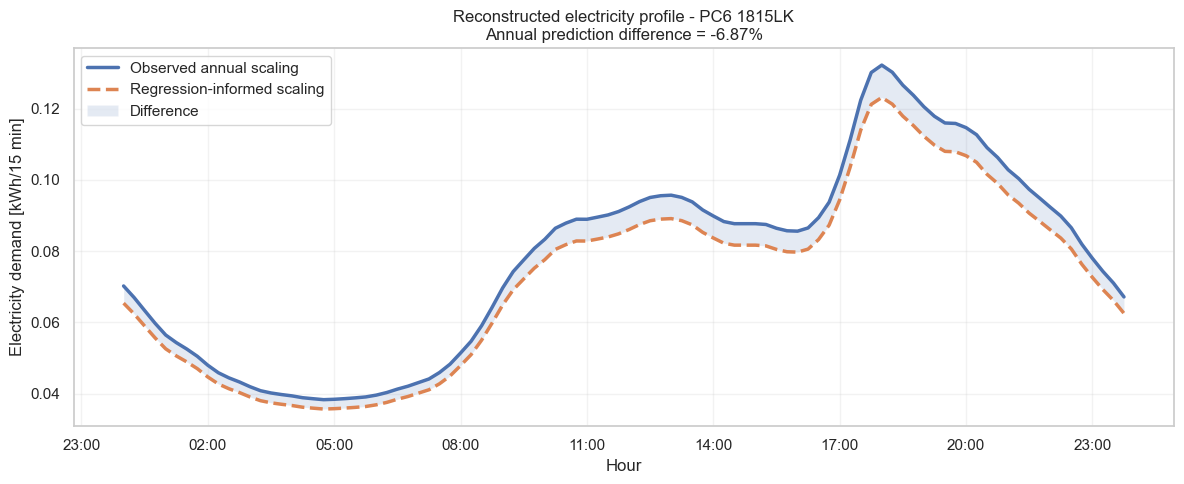

In [ ]:
# ----------------------------
# 8.4 Compare reconstructed electricity profiles
# ----------------------------

observed_total = (
    profile_df[
        "observed_kwh"
    ]
    .sum()
)

predicted_total = (
    profile_df[
        "predicted_kwh"
    ]
    .sum()
)

difference_pct = (
    100
    *
    (
        predicted_total
        -
        observed_total
    )
    /
    observed_total
)

comparison = pd.DataFrame({

    "Metric": [
        "Observed annual electricity",
        "Predicted annual electricity",
        "Difference (%)"
    ],

    "Value": [
        observed_total,
        predicted_total,
        difference_pct
    ]

})

print(
    comparison
    .round(2)
    .to_string(index=False)
)

# ----------------------------
# Daily comparison
# ----------------------------

plot_day = "2023-01-15"

temp = (
    profile_df.loc[
        profile_df.index.date
        ==
        pd.to_datetime(plot_day).date()
    ]
)

plt.figure(figsize=(12, 5))

plt.plot(
    temp.index,
    temp["observed_kwh"],
    linewidth=2.5,
    label="Observed annual scaling"
)

plt.plot(
    temp.index,
    temp["predicted_kwh"],
    linewidth=2.5,
    linestyle="--",
    label="Regression-informed scaling"
)

plt.fill_between(
    temp.index,
    temp["observed_kwh"],
    temp["predicted_kwh"],
    alpha=0.15,
    label="Difference"
)

plt.title(
    f"Reconstructed electricity profile - PC6 {selected_pc6['postcode']}\n"
    f"Annual prediction difference = {difference_pct:.2f}%"
)

plt.ylabel(
    "Electricity demand [kWh/15 min]"
)

plt.xlabel(
    "Hour"
)

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=3)
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of reconstructed electricity profiles

The reconstructed electricity profiles show that the regression-informed profile produces consistently lower electricity demand throughout the day for the selected Alkmaar postcode area.

Observed annual electricity reconstruction resulted in approximately **2210 kWh**, while the regression-informed reconstruction produced approximately **2058 kWh**, corresponding to an annual difference of approximately **−6.9%**.

Because both reconstructions use the same `E1A` quarter-hour Standard Load Profile, their temporal structure remains identical and only the overall profile magnitude changes.

The largest absolute differences occur during periods of elevated electricity demand, particularly during the evening peak. This occurs because annual prediction differences scale proportionally across all quarter-hour intervals.

# Chapter 9 Regression-informed gas profile reconstruction

The previous chapter translated annual electricity consumption estimates into quarter-hourly demand profiles using Dutch electricity Standard Load Profiles. This chapter applies the same idea to gas demand, using the Dutch 2023 gas profile methodology.

Gas profiles differ from electricity profiles because they are temperature-dependent. The published gas profile does not consist of a single profile fraction column. Instead, each hourly profile category is represented by three components:

- `TST`: stooktemperatuur, or heating threshold temperature
- `RER`: regression coefficient for the temperature-dependent component
- `TOP`: temperature-independent profile component

For this chapter, the residential small-consumer profile category `G1A` is used. The hourly gas profile fraction is reconstructed using the standard profile temperature series for 2023.

The chapter then compares two gas profile reconstructions for one representative Alkmaar PC6:

1. observed gas profile scaling, using observed annual CBS gas consumption
2. regression-informed gas profile scaling, using predicted annual gas consumption from the preferred regression model

The objective is not to reproduce the full Dutch gas allocation procedure, including measurement correction factors, but to illustrate how annual gas prediction uncertainty propagates into reconstructed hourly gas demand.

## 9.1 Import and reconstruction of the 2023 G1A gas profile

This section reconstructs the Dutch residential gas Standard Load Profile for 2023.

Unlike electricity, gas demand depends on temperature and is represented using three profile components:

- `TST`: heating threshold temperature
- `RER`: temperature-dependent regression coefficient
- `TOP`: temperature-independent profile component

The profile is reconstructed using the Standard Profile Temperature (`SPT`) series.

The temperature-dependent component is calculated as:

$$
TAP_t=
RER_t
\cdot
\max(TST_t-SPT_t,0)
$$

The resulting hourly gas profile fraction becomes:

$$
PF_t=
TOP_t+TAP_t
$$

The annual sum of the reconstructed profile is evaluated as a consistency check before using it for annual gas scaling.

In [ ]:
# ----------------------------
# 9.1 Reconstruct G1A gas profile
# ----------------------------

gas_profile_path = (
    gas_slp_folder
    /
    "profielen aardgas 2023 versie 1.00.csv"
)

spt_path = (
    gas_slp_folder
    /
    "SPT 2023 versie 1.00.csv"
)


# ----------------------------
# Read gas profile
# ----------------------------

gas = pd.read_csv(
    gas_profile_path,
    sep=",",
    skiprows=6,
    header=None,
    encoding="utf-8-sig"
)

gas.columns = [

    "time",
    "from",
    "to",

    "G1A_TST",
    "G1A_RER",
    "G1A_TOP",

    "G2A_TST",
    "G2A_RER",
    "G2A_TOP",

    "empty1",
    "empty2",
    "empty3",

    "G2C_TST",
    "G2C_RER",
    "G2C_TOP"

]

gas["time"] = pd.to_datetime(
    gas["time"],
    dayfirst=True
)

gas = (
    gas
    .set_index("time")
)

for c in [
    "G1A_TST",
    "G1A_RER",
    "G1A_TOP"
]:

    gas[c] = pd.to_numeric(
        gas[c],
        errors="coerce"
    )


# ----------------------------
# Read SPT
# ----------------------------

spt = pd.read_csv(
    spt_path,
    sep=",",
    skiprows=2,
    encoding="utf-8-sig"
)

spt.columns = [
    "time",
    "from",
    "to",
    "SPT"
]

spt["time"] = pd.to_datetime(
    spt["time"],
    dayfirst=True
)

spt["SPT"] = pd.to_numeric(
    spt["SPT"],
    errors="coerce"
)

spt = (
    spt
    .set_index("time")
)


# ----------------------------
# Merge
# ----------------------------

g1a = (
    gas[
        [
            "G1A_TST",
            "G1A_RER",
            "G1A_TOP"
        ]
    ]
    .join(
        spt[
            ["SPT"]
        ]
    )
)


# ----------------------------
# Reconstruct profile
# ----------------------------

g1a["G1A_TAP"] = (

    g1a["G1A_RER"]

    *

    (
        g1a["G1A_TST"]

        -

        g1a["SPT"]

    ).clip(
        lower=0
    )

)

g1a["gas_profile_fraction"] = (

    g1a["G1A_TOP"]

    +

    g1a["G1A_TAP"]

)


# ----------------------------
# Single output report
# ----------------------------

report = []

report.append(
    "G1A PROFILE SUMMARY"
)

report.append(
    "=" * 80
)

report.append(
    f"Rows: {len(g1a)}"
)

report.append(
    f"Start: {g1a.index.min()}"
)

report.append(
    f"End: {g1a.index.max()}"
)

report.append(
    f"Time step: "
    +
    str(
        g1a.index
        .to_series()
        .diff()
        .mode()[0]
    )
)

report.append("")

report.append(
    "Annual sums"
)

report.append(
    f"TOP: {g1a['G1A_TOP'].sum():.6f}"
)

report.append(
    f"RER only: {g1a['G1A_RER'].sum():.6f}"
)

report.append(
    f"Final reconstructed profile: "
    f"{g1a['gas_profile_fraction'].sum():.6f}"
)

report.append("")

report.append(
    "Preview:"
)

report.append(
    g1a.head().round(6).to_string()
)

print(
    "\n".join(report)
)

G1A PROFILE SUMMARY
Rows: 8760
Start: 2023-01-01 07:00:00
End: 2024-01-01 06:00:00
Time step: 0 days 01:00:00

Annual sums
TOP: 0.296107
RER only: 0.138784
Final reconstructed profile: 0.999980

Preview:
                     G1A_TST   G1A_RER   G1A_TOP    SPT   G1A_TAP  gas_profile_fraction
time                                                                                   
2023-01-01 07:00:00    5.025  0.000020  0.000052 -3.181  0.000162              0.000214
2023-01-01 08:00:00    7.481  0.000023  0.000055 -3.253  0.000244              0.000299
2023-01-01 09:00:00    9.177  0.000023  0.000083 -3.268  0.000290              0.000373
2023-01-01 10:00:00    9.134  0.000027  0.000092 -2.992  0.000325              0.000417
2023-01-01 11:00:00    9.216  0.000027  0.000088 -2.363  0.000307              0.000395


### Interpretation of reconstructed G1A gas profile

The reconstructed `G1A` gas profile contains 8760 hourly observations for 2023. This is consistent with the gas profile documentation, which provides one profile value per hour.

The annual sum of the reconstructed profile fraction is close to one. This confirms that the reconstructed `G1A` profile behaves as an annual distribution of gas consumption.

The small deviation from exactly one is retained rather than corrected, so that the published gas profile components are used directly. The annual reconstruction check in the following sections therefore reports any resulting difference explicitly.

## 9.2 Selection of a representative Alkmaar postcode area for gas

This section selects one representative postcode area from Alkmaar for gas profile reconstruction.

The selected postcode area is the PC6 whose observed annual gas consumption per dwelling is closest to the median observed gas consumption within Alkmaar.

For this PC6, two annual gas values are retained:

- observed annual gas consumption from CBS
- predicted annual gas consumption from the preferred gas regression model

This provides a representative local case for illustrating how annual gas prediction differences propagate into reconstructed hourly gas demand.

In [ ]:
# ----------------------------
# 9.2 Select representative Alkmaar PC6 for gas
# ----------------------------

alkmaar_gas_df = reg_data_gas_extended.copy()

# Observed annual gas
alkmaar_gas_df["annual_obs_gas"] = (
    reg_data_gas_extended["gas_avg_per_dwelling_pc6"]
)

# Predicted annual gas from preferred extended log gas model
alkmaar_gas_df["annual_pred_gas"] = (
    np.exp(
        model_gas_extended.predict(X_gas_extended)
    )
)

# Keep Alkmaar only
alkmaar_gas_df = (
    alkmaar_gas_df[
        alkmaar_gas_df["municipality_code"]
        .astype(str)
        .str.contains("0361", na=False)
    ]
    .copy()
)

# Select PC6 closest to median observed gas in Alkmaar
median_gas_target = (
    alkmaar_gas_df["annual_obs_gas"]
    .median()
)

selected_gas_idx = (
    (
        alkmaar_gas_df["annual_obs_gas"]
        -
        median_gas_target
    )
    .abs()
    .idxmin()
)

selected_gas_pc6 = (
    alkmaar_gas_df
    .loc[selected_gas_idx]
)

gas_prediction_error_pct = (
    100
    *
    (
        selected_gas_pc6["annual_pred_gas"]
        -
        selected_gas_pc6["annual_obs_gas"]
    )
    /
    selected_gas_pc6["annual_obs_gas"]
)

# Single output report
report = []

report.append("REPRESENTATIVE ALKMAAR GAS PC6")
report.append("=" * 80)

report.append(
    f"Selected PC6: {selected_gas_pc6['postcode']}"
)

report.append(
    f"Observed annual gas: {selected_gas_pc6['annual_obs_gas']:.2f} m³"
)

report.append(
    f"Predicted annual gas: {selected_gas_pc6['annual_pred_gas']:.2f} m³"
)

report.append(
    f"Prediction error: {gas_prediction_error_pct:.2f}%"
)

report.append("")

report.append(
    f"Median observed Alkmaar gas: {median_gas_target:.2f} m³"
)

report.append(
    "Selection rule: PC6 closest to the median observed annual gas consumption in Alkmaar."
)

print("\n".join(report))

REPRESENTATIVE ALKMAAR GAS PC6
Selected PC6: 1483TL
Observed annual gas: 840.00 m³
Predicted annual gas: 825.01 m³
Prediction error: -1.78%

Median observed Alkmaar gas: 840.00 m³
Selection rule: PC6 closest to the median observed annual gas consumption in Alkmaar.


### Interpretation of representative gas postcode selection

The representative gas postcode area selected for Alkmaar is **PC6 1483TL**. This postcode has an observed annual gas consumption of **840 m³ per dwelling**, which is equal to the median observed gas consumption within Alkmaar.

The preferred extended gas regression model predicts **825 m³ per dwelling**, corresponding to a prediction error of approximately **−1.8%**.

This indicates that, for the selected median gas-consumption postcode area, the regression-informed annual gas estimate is very close to the observed CBS value. The selected case is therefore suitable for illustrating gas profile reconstruction without being dominated by a large annual prediction error.

## 9.3 Reconstruction of observed and regression-informed gas profiles

Using the representative Alkmaar postcode area selected in the previous section, hourly gas demand profiles are reconstructed using the 2023 `G1A` gas Standard Load Profile.

Hourly gas demand is reconstructed as:

$$
G_t = PF_t \cdot G_{annual}
$$

where:

- $G_t$ is reconstructed hourly gas demand
- $PF_t$ is the reconstructed hourly gas profile fraction
- $G_{annual}$ is annual gas consumption

Two hourly gas profiles are reconstructed:

Observed reconstruction:

$$
G_t^{obs}
=
PF_t
\cdot
G_{annual}^{obs}
$$

Regression-informed reconstruction:

$$
G_t^{pred}
=
PF_t
\cdot
G_{annual}^{pred}
$$

Because both profiles use the same temporal gas distribution, differences between the reconstructed curves reflect only the difference in annual gas consumption.

In [ ]:
# ----------------------------
# 9.3 Reconstruct hourly gas profiles
# ----------------------------

annual_obs = (
    selected_gas_pc6[
        "annual_obs_gas"
    ]
)

annual_pred = (
    selected_gas_pc6[
        "annual_pred_gas"
    ]
)

profile_df_gas = pd.DataFrame(
    index=gas_g1a.index
)

# Observed reconstruction

profile_df_gas["observed_gas"] = (

    gas_g1a[
        "gas_profile_fraction"
    ]

    *

    annual_obs

)

# Regression-informed reconstruction

profile_df_gas["predicted_gas"] = (

    gas_g1a[
        "gas_profile_fraction"
    ]

    *

    annual_pred

)

profile_df_gas["difference_gas"] = (

    profile_df_gas[
        "predicted_gas"
    ]

    -

    profile_df_gas[
        "observed_gas"
    ]

)

# ----------------------------
# Annual verification
# ----------------------------

observed_total = (
    profile_df_gas[
        "observed_gas"
    ]
    .sum()
)

predicted_total = (
    profile_df_gas[
        "predicted_gas"
    ]
    .sum()
)

# ----------------------------
# Single output report
# ----------------------------

report = []

report.append(
    "GAS PROFILE RECONSTRUCTION"
)

report.append(
    "=" * 80
)

report.append(
    f"PC6: {selected_gas_pc6['postcode']}"
)

report.append("")

report.append(
    f"Observed annual input: "
    f"{annual_obs:.2f} m³"
)

report.append(
    f"Observed reconstruction: "
    f"{observed_total:.2f} m³"
)

report.append("")

report.append(
    f"Predicted annual input: "
    f"{annual_pred:.2f} m³"
)

report.append(
    f"Predicted reconstruction: "
    f"{predicted_total:.2f} m³"
)

report.append("")

report.append(
    f"Observed reconstruction error: "
    f"{observed_total-annual_obs:.4f}"
)

report.append(
    f"Predicted reconstruction error: "
    f"{predicted_total-annual_pred:.4f}"
)

report.append("")

report.append(
    "Preview:"
)

report.append(
    profile_df_gas
    .head()
    .round(4)
    .to_string()
)

print(
    "\n".join(report)
)

GAS PROFILE RECONSTRUCTION
PC6: 1483TL

Observed annual input: 840.00 m³
Observed reconstruction: 839.98 m³

Predicted annual input: 825.01 m³
Predicted reconstruction: 824.99 m³

Observed reconstruction error: -0.0168
Predicted reconstruction error: -0.0165

Preview:
                     observed_gas  predicted_gas  difference_gas
time                                                            
2023-01-01 07:00:00        0.1794         0.1762         -0.0032
2023-01-01 08:00:00        0.2510         0.2465         -0.0045
2023-01-01 09:00:00        0.3135         0.3079         -0.0056
2023-01-01 10:00:00        0.3501         0.3439         -0.0062
2023-01-01 11:00:00        0.3318         0.3259         -0.0059


### Interpretation of reconstructed gas profiles

The reconstructed gas profiles preserve annual gas consumption almost exactly. The observed annual gas consumption of **840 m³** is reconstructed into **839.98 m³**, while the regression-informed annual prediction of **825 m³** reconstructs into **824.99 m³**.

The reconstruction difference is negligible and originates from numerical precision rather than from the gas profile formulation.

Because both reconstructed profiles use the same `G1A` hourly gas distribution, the resulting temporal profiles have identical shapes. Differences between the two profiles therefore originate only from differences in annual gas consumption.

Compared to electricity reconstruction, gas demand reconstruction introduces an additional dependency through the standard profile temperature (`SPT`). Consequently, reconstructed gas demand varies not only with time but also with outdoor temperature conditions represented in the Dutch gas profile methodology.

## 9.4 Comparison of reconstructed gas profiles

This section compares the observed and regression-informed reconstructed gas demand profiles for the selected Alkmaar postcode area.

Both reconstructions use the same `G1A` hourly gas profile and therefore share the same temperature-driven temporal structure.

Differences between the profiles originate only from differences in annual gas consumption estimated by the regression model.

The comparison includes:

- annual reconstructed gas consumption
- annual difference
- a representative winter-day visualization of hourly gas demand

              Metric  Value
 Observed annual gas 839.98
Predicted annual gas 824.99
      Difference (%)  -1.78


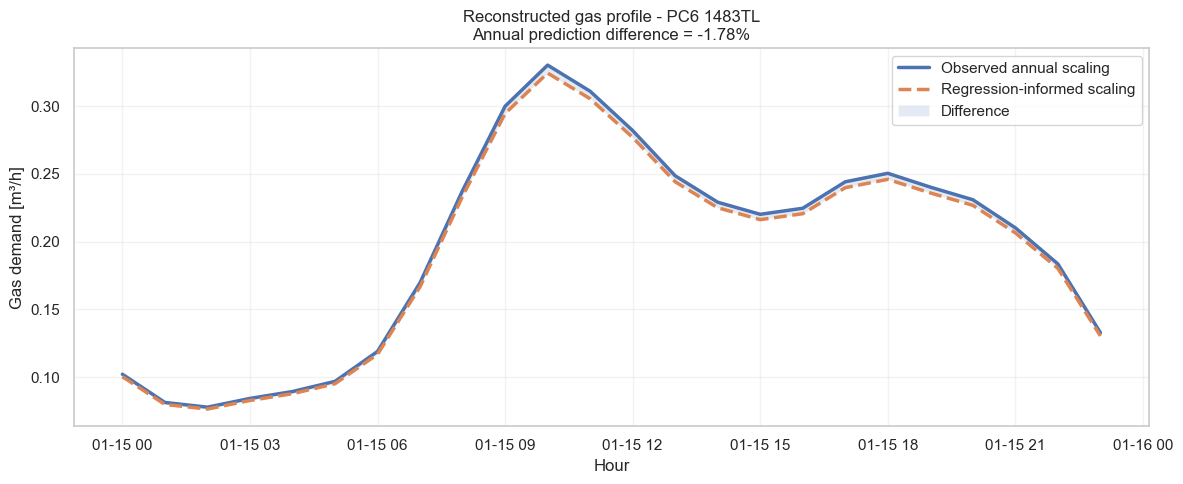

In [ ]:
# ----------------------------
# 9.4 Compare reconstructed gas profiles
# ----------------------------

observed_total = (
    profile_df_gas[
        "observed_gas"
    ]
    .sum()
)

predicted_total = (
    profile_df_gas[
        "predicted_gas"
    ]
    .sum()
)

difference_pct = (

    100

    *

    (

        predicted_total

        -

        observed_total

    )

    /

    observed_total

)

comparison = pd.DataFrame({

    "Metric": [

        "Observed annual gas",

        "Predicted annual gas",

        "Difference (%)"

    ],

    "Value": [

        observed_total,

        predicted_total,

        difference_pct

    ]

})

print(
    comparison
    .round(2)
    .to_string(index=False)
)


# ----------------------------
# Winter day comparison
# ----------------------------

plot_day = "2023-01-15"

temp = (

    profile_df_gas.loc[

        profile_df_gas.index.date

        ==

        pd.to_datetime(
            plot_day
        ).date()

    ]

)

plt.figure(
    figsize=(12,5)
)

plt.plot(

    temp.index,

    temp[
        "observed_gas"
    ],

    linewidth=2.5,

    label="Observed annual scaling"

)

plt.plot(

    temp.index,

    temp[
        "predicted_gas"
    ],

    linewidth=2.5,

    linestyle="--",

    label="Regression-informed scaling"

)

plt.fill_between(

    temp.index,

    temp[
        "observed_gas"
    ],

    temp[
        "predicted_gas"
    ],

    alpha=0.15,

    label="Difference"

)

plt.title(

    f"Reconstructed gas profile - PC6 {selected_gas_pc6['postcode']}\n"
    f"Annual prediction difference = {difference_pct:.2f}%"

)

plt.ylabel(
    "Gas demand [m³/h]"
)

plt.xlabel(
    "Hour"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation of reconstructed gas profile comparison

The reconstructed gas profiles show close agreement between observed and regression-informed gas demand for the selected Alkmaar postcode area.

Observed annual gas reconstruction resulted in approximately **840 m³**, while the regression-informed reconstruction produced approximately **825 m³**, corresponding to an annual difference of approximately **−1.8%**.

Because both reconstructions use the same reconstructed `G1A` gas profile, the temporal behaviour remains identical and only the profile magnitude changes.

In contrast to electricity reconstruction, hourly gas demand is temperature dependent through the standard profile temperature (`SPT`). Consequently, the reconstructed curves exhibit realistic heating-related peaks during colder periods while preserving the annual gas prediction.

The figure illustrates that annual prediction differences translate proportionally into hourly gas demand, while the temporal structure remains governed by the Dutch gas Standard Load Profile methodology.


## 10.1 User input and annual demand prediction

This section demonstrates the application of the trained electricity and gas regression models for a user-selected Dutch postcode area.

The user provides:

- a Dutch postcode area (`PC6`)
- a reconstruction date (`YYYY-MM-DD`)

The selected postcode is validated against the available model dataset.

For the selected postcode area, the trained electricity and gas regression models are used to predict annual residential demand.

The resulting annual electricity and gas estimates are used in Section 11.2 to reconstruct temporal demand profiles.

In [146]:
# ----------------------------
# 10.1 User input and annual demand prediction
# ----------------------------

# User inputs
user_pc6 = "1483TL"
user_date = "2023-01-15"

# ----------------------------
# Standardize inputs
# ----------------------------

user_pc6 = (
    user_pc6
    .upper()
    .replace(" ", "")
)

selected_date = pd.to_datetime(
    user_date
)

# ----------------------------
# Validate date
# ----------------------------

if selected_date < pd.Timestamp("2023-01-01"):
    raise ValueError("Date must be within 2023.")

if selected_date > pd.Timestamp("2023-12-31"):
    raise ValueError("Date must be within 2023.")

# ----------------------------
# Validate postcode
# ----------------------------

candidate_rows = (
    reg_data[
        reg_data["postcode"]
        .astype(str)
        .str.upper()
        ==
        user_pc6
    ]
)

if len(candidate_rows) == 0:
    raise ValueError(
        f"PC6 {user_pc6} was not found in the electricity regression dataset."
    )

selected_row = candidate_rows.iloc[[0]]

# ----------------------------
# Retrieve electricity prediction
# ----------------------------

selected_position_el = (
    reg_data.index
    .get_loc(selected_row.index[0])
)

predicted_electricity = (
    np.exp(
        y_pred_log_arr[selected_position_el]
    )
)

# ----------------------------
# Retrieve gas prediction
# ----------------------------

gas_candidate_rows = (
    reg_data_gas_extended[
        reg_data_gas_extended["postcode"]
        .astype(str)
        .str.upper()
        ==
        user_pc6
    ]
)

if len(gas_candidate_rows) == 0:
    raise ValueError(
        f"PC6 {user_pc6} was not found in the gas regression dataset. "
        "This may happen if the PC6 has zero or very low gas consumption."
    )

selected_gas_row = gas_candidate_rows.iloc[[0]]

gas_prediction_series = np.exp(
    model_gas_extended.predict(X_gas_extended)
)

selected_position_gas = (
    reg_data_gas_extended.index
    .get_loc(selected_gas_row.index[0])
)

predicted_gas = (
    gas_prediction_series.iloc[selected_position_gas]
)

# ----------------------------
# Store inputs for 11.2
# ----------------------------

chapter11 = {}

chapter11["pc6"] = user_pc6
chapter11["date"] = selected_date
chapter11["selected_row"] = selected_row
chapter11["selected_gas_row"] = selected_gas_row
chapter11["predicted_electricity"] = predicted_electricity
chapter11["predicted_gas"] = predicted_gas

# ----------------------------
# Single output report
# ----------------------------

report = []

report.append("USER-SELECTED ANNUAL DEMAND PREDICTION")
report.append("=" * 80)

report.append(
    f"Selected PC6: {user_pc6}"
)

report.append(
    f"Selected date: {selected_date.date()}"
)

report.append("")

report.append(
    f"Predicted annual electricity: {predicted_electricity:.2f} kWh"
)

report.append(
    f"Predicted annual gas: {predicted_gas:.2f} m³"
)

report.append("")

report.append(
    "These annual predictions are used in Section 11.2 for temporal profile reconstruction."
)

print(
    "\n".join(report)
)

USER-SELECTED ANNUAL DEMAND PREDICTION
Selected PC6: 1483TL
Selected date: 2023-01-15

Predicted annual electricity: 2451.34 kWh
Predicted annual gas: 825.01 m³

These annual predictions are used in Section 11.2 for temporal profile reconstruction.


## 10.2 Profile reconstruction and visualization

Using the annual demand estimates from Section 11.1, representative residential electricity and gas demand profiles are reconstructed for the selected postcode area.

The regression models estimate the **average annual residential energy consumption per dwelling** within each postcode area rather than total postcode demand. To obtain temporally resolved demand representations, these annual estimates are combined with standardized Dutch Standard Load Profiles (SLPs), which define the temporal distribution of residential energy use.

Electricity demand is reconstructed using the selected `E1A` quarter-hour Standard Load Profile:

$$
L_t=PF_t^{el}\cdot E_{annual}
$$

where $L_t$ represents the reconstructed electricity demand per dwelling at time step $t$, $PF_t^{el}$ denotes the electricity profile fraction, and $E_{annual}$ is the predicted annual electricity consumption per dwelling in a PC6 area.

Gas demand is reconstructed using the reconstructed `G1A` hourly gas profile:

$$
G_t=PF_t^{gas}\cdot G_{annual}
$$

where $G_t$ represents reconstructed hourly gas demand per dwelling, $PF_t^{gas}$ denotes the gas profile fraction, and $G_{annual}$ is the predicted annual gas consumption per dwelling in a PC6 area.

The selected date is extracted and visualized to illustrate how annual postcode-level predictions can be translated into representative temporal residential demand profiles while preserving the annual energy magnitude.

PROFILE RECONSTRUCTION SUMMARY
PC6: 1483TL
Date: 2023-01-15

Daily electricity total: 8.26 kWh
Electricity peak: 0.147 kWh/15min
Peak time: 2023-01-15 18:00:00

Daily gas total: 4.61 m³
Gas peak: 0.324 m³/h
Peak time: 2023-01-15 10:00:00


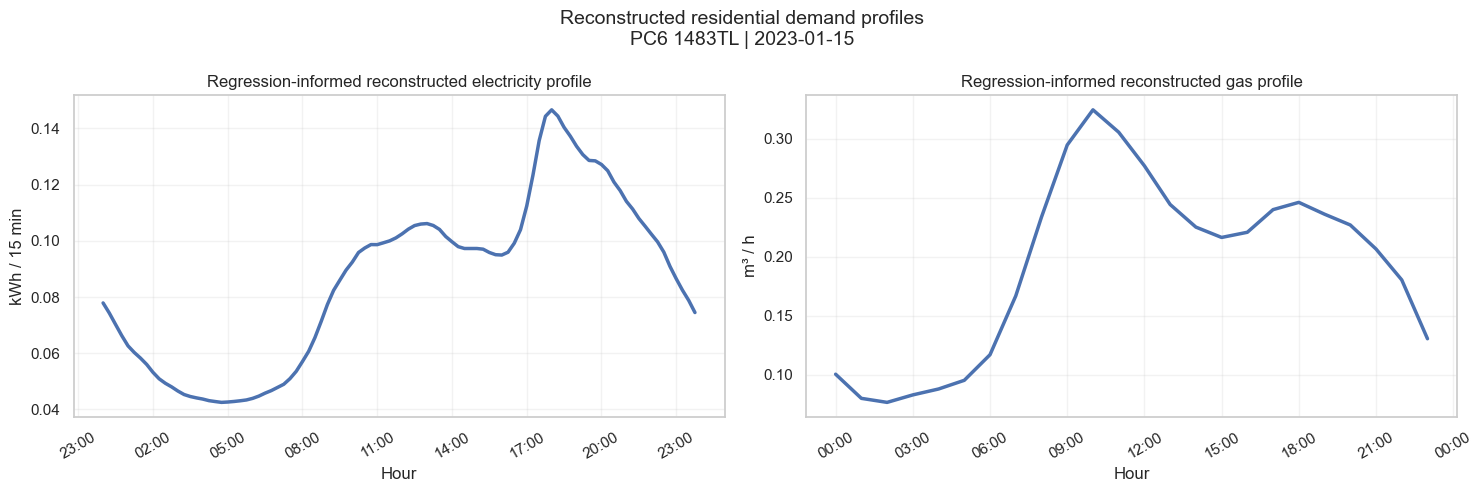

In [ ]:
# ----------------------------
# 10.2 Reconstruct and visualize
# ----------------------------

selected_date = chapter11["date"]
selected_day = selected_date.date()

# Reconstruct profiles
electricity_profile = slp_fraction * chapter11["predicted_electricity"]
gas_profile = gas_g1a["gas_profile_fraction"] * chapter11["predicted_gas"]

# Select requested day
electricity_day = electricity_profile.loc[electricity_profile.index.date == selected_day]
gas_day = gas_profile.loc[gas_profile.index.date == selected_day]

# Daily statistics
electricity_daily_total = electricity_day.sum()
gas_daily_total = gas_day.sum()

electricity_peak = electricity_day.max()
gas_peak = gas_day.max()

electricity_peak_time = electricity_day.idxmax()
gas_peak_time = gas_day.idxmax()

# Report
report = f"""
PROFILE RECONSTRUCTION SUMMARY
{"=" * 80}
PC6: {chapter11["pc6"]}
Date: {selected_day}

Daily electricity total: {electricity_daily_total:.2f} kWh
Electricity peak: {electricity_peak:.3f} kWh/15min
Peak time: {electricity_peak_time}

Daily gas total: {gas_daily_total:.2f} m³
Gas peak: {gas_peak:.3f} m³/h
Peak time: {gas_peak_time}
"""

print(report.strip())

# Side-by-side profile plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(electricity_day.index, electricity_day, linewidth=2.5)
axes[0].set_title("Regression-informed reconstructed electricity profile")
axes[0].set_ylabel("kWh / 15 min")
axes[0].set_xlabel("Hour")
axes[0].grid(alpha=0.25)

axes[1].plot(gas_day.index, gas_day, linewidth=2.5)
axes[1].set_title("Regression-informed reconstructed gas profile")
axes[1].set_ylabel("m³ / h")
axes[1].set_xlabel("Hour")
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle(
    f"Reconstructed residential demand profiles\n"
    f"PC6 {chapter11['pc6']} | {selected_day}",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Interpretation of reconstructed user-selected demand profiles

Figure 11.1 presents the reconstructed residential electricity and gas demand profiles for postcode area **1483TL** on **15 January 2023**, obtained by combining regression-based annual demand estimates with Dutch Standard Load Profiles.

The reconstructed electricity profile follows a typical residential daily pattern. Demand decreases during the night and reaches its minimum in the early morning hours, after which consumption gradually increases during the morning. Electricity demand remains relatively stable throughout the day before reaching a pronounced evening peak around **18:00**, consistent with increased household activity after working hours. The predicted peak reaches **0.147 kWh per 15 minutes** (equivalent to approximately **0.59 kW average power over the interval**).

The reconstructed gas profile exhibits a different temporal behaviour. Gas demand increases strongly during the morning and reaches its maximum around **10:00**, followed by a gradual decline during the afternoon and evening. Unlike electricity demand, the gas profile is primarily shaped by the Dutch gas Standard Load Profile methodology, which incorporates temperature-sensitive heating behaviour through the reconstructed G1A profile. The predicted peak demand reaches **0.324 m³/h**.

Although both profiles are generated for the same postcode area, their temporal distributions differ substantially. Electricity demand is dominated by household activity patterns, while gas demand reflects space-heating requirements and seasonal temperature effects.

This example demonstrates how annual demand predictions from the regression models can be transformed into operational demand curves at high temporal resolution for any selected Dutch postcode area. Such reconstructed profiles can support scenario analysis, local demand visualization, and future energy system studies.

## 10.3 Scenario-based demand profile generation

This section demonstrates how the trained models can be used for a hypothetical residential postcode scenario.

Instead of selecting an observed PC6 from the dataset, a user-defined feature vector is constructed using structural, socioeconomic, dwelling-type, and energy-label characteristics. The trained electricity and gas models then estimate average annual demand per dwelling for this hypothetical area.

The annual estimates are subsequently combined with the electricity and gas Standard Load Profiles to generate representative demand profiles for one winter, spring, summer, and autumn day.

This scenario-based exercise is illustrative. The input values should remain within the range of the training data to avoid unrealistic extrapolation.

SCENARIO-BASED ANNUAL DEMAND PREDICTION
Predicted annual electricity: 2404.50 kWh per dwelling
Predicted annual gas: 730.18 m³ per dwelling

Scenario characteristics:
Mean floor area: 120 m²
Mean building year: 2005
Share with gas connection: 0.80
Average household size: 2.30
Average WOZ value: 420

Dwelling-type shares:
Rijwoning tussen: 0.40
Rijwoning hoek: 0.20
Vrijstaande woning: 0.10

Energy-label shares:
A: 0.50
B: 0.30
C: 0.20

SEASONAL DAILY PROFILE SUMMARY
Season       Date  Electricity daily total [kWh]  Electricity peak [kWh/15min] Electricity peak time  Gas daily total [m³]  Gas peak [m³/h]       Gas peak time
Winter 2023-01-15                           8.10                         0.144   2023-01-15 18:00:00                  4.08            0.287 2023-01-15 10:00:00
Spring 2023-04-15                           6.77                         0.105   2023-04-15 17:15:00                  1.89            0.156 2023-04-15 08:00:00
Summer 2023-07-15                           5.75  

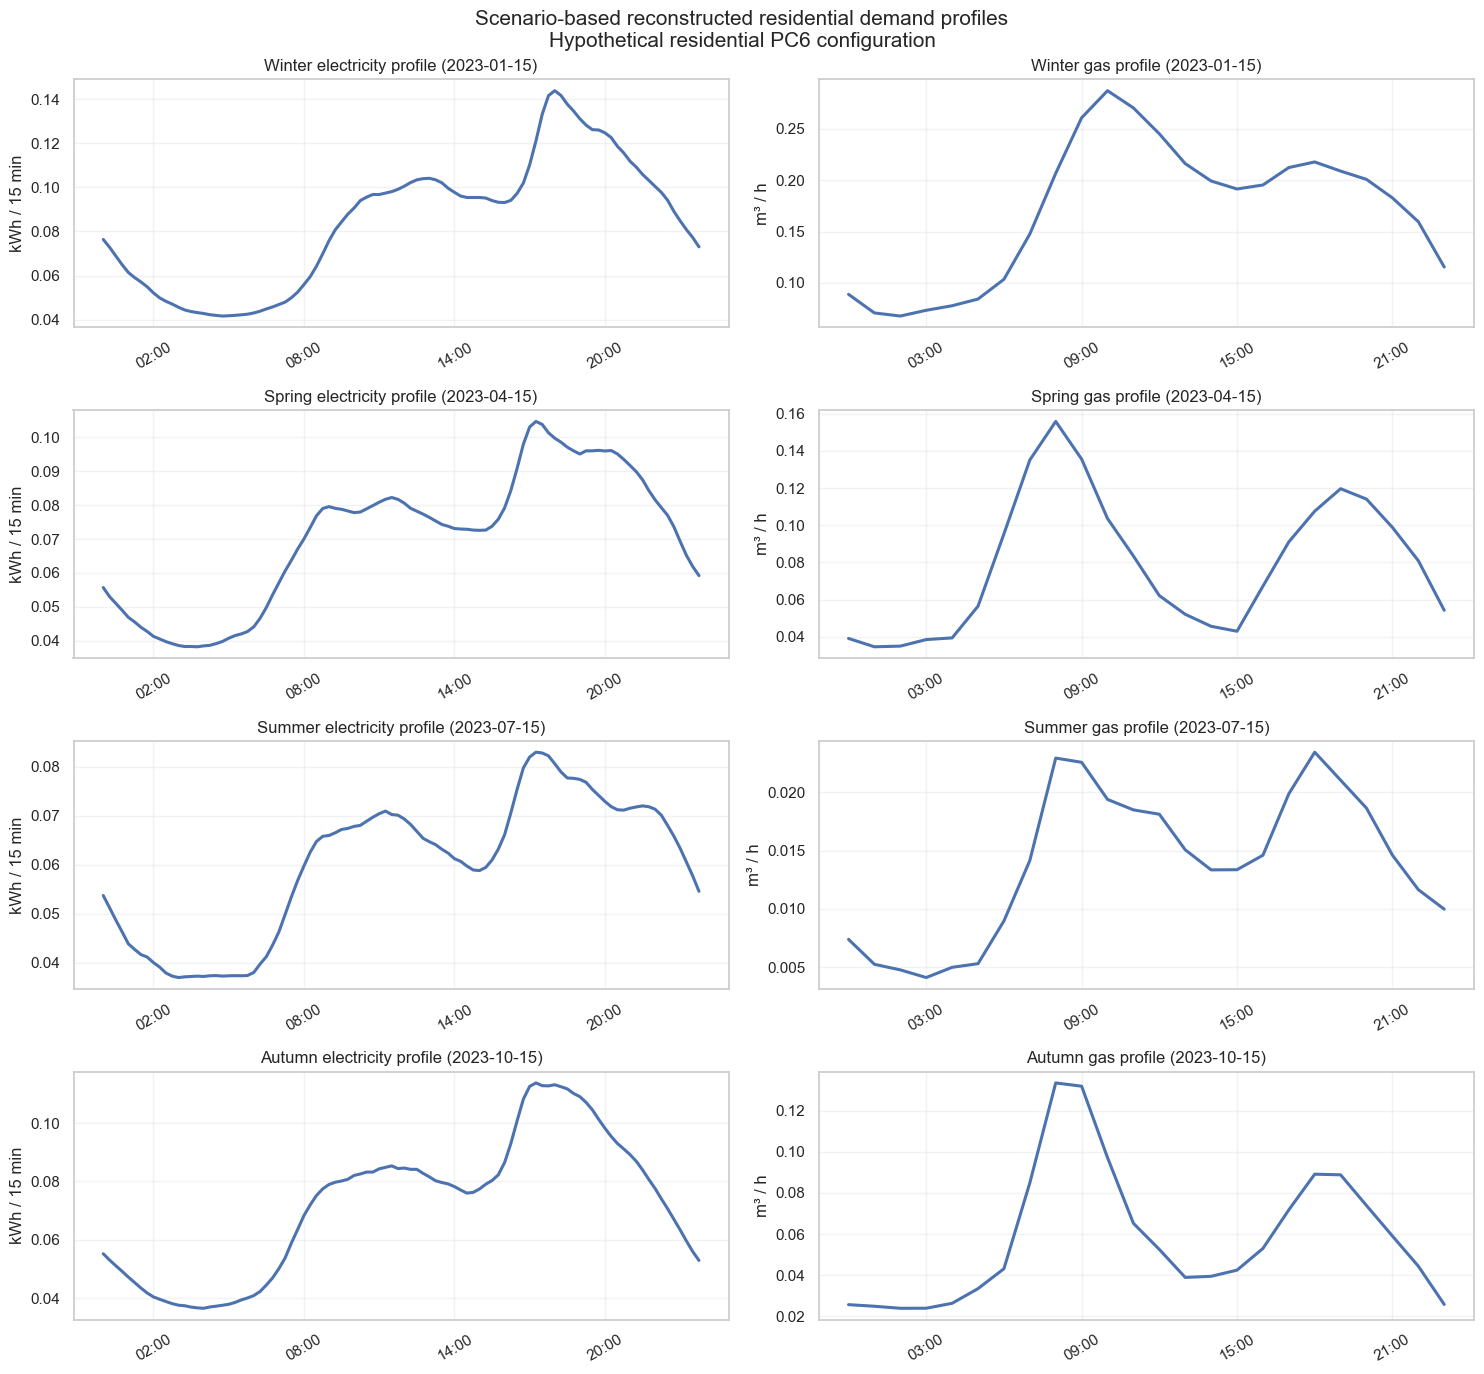

In [ ]:
# ----------------------------
# 10.3 Scenario-based demand profile generation
# ----------------------------

scenario = {
    "mean_floor_area": 120,
    "mean_building_year": 2005,
    "share_has_gas": 0.80,

    "avg_woz_value_filled": 420, #thousand euros
    "avg_household_size_filled": 2.3,
    "avg_household_size_missing": 0,
    "share_population_on_benefits_filled": 0.10,

    "share_dwelling_type_Rijwoning tussen": 0.40,
    "share_dwelling_type_Rijwoning hoek": 0.20,
    "share_dwelling_type_Vrijstaande woning": 0.10,

    "share_energy_label_A": 0.50,
    "share_energy_label_B": 0.30,
    "share_energy_label_C": 0.20
}

season_days = {
    "Winter": "2023-01-15",
    "Spring": "2023-04-15",
    "Summer": "2023-07-15",
    "Autumn": "2023-10-15"
}

# ----------------------------
# Electricity scenario row
# model: model_loglog
# matrix: X_loglog
# ----------------------------

X_star_el = pd.DataFrame(
    0.0,
    index=[0],
    columns=X_loglog.columns
)

for col, value in scenario.items():
    if col in X_star_el.columns:
        X_star_el.loc[0, col] = value

if "const" in X_star_el.columns:
    X_star_el.loc[0, "const"] = 1.0

if "log_mean_floor_area" in X_star_el.columns:
    X_star_el.loc[0, "log_mean_floor_area"] = np.log(
        scenario["mean_floor_area"]
    )

predicted_electricity = np.exp(
    model_loglog.predict(X_star_el)
).iloc[0]

# ----------------------------
# Gas scenario row
# model: model_gas_extended
# matrix: X_gas_extended
# ----------------------------

X_star_gas = pd.DataFrame(
    0.0,
    index=[0],
    columns=X_gas_extended.columns
)

for col, value in scenario.items():
    if col in X_star_gas.columns:
        X_star_gas.loc[0, col] = value

if "const" in X_star_gas.columns:
    X_star_gas.loc[0, "const"] = 1.0

if "log_mean_floor_area" in X_star_gas.columns:
    X_star_gas.loc[0, "log_mean_floor_area"] = np.log(
        scenario["mean_floor_area"]
    )

if "building_year_c" in X_star_gas.columns:
    X_star_gas.loc[0, "building_year_c"] = (
        scenario["mean_building_year"]
        -
        reg_data_gas_extended["mean_building_year"].mean()
    )

if "building_year_c_sq" in X_star_gas.columns:
    X_star_gas.loc[0, "building_year_c_sq"] = (
        X_star_gas.loc[0, "building_year_c"] ** 2
    )

if "gas_x_log_floor_area" in X_star_gas.columns:
    X_star_gas.loc[0, "gas_x_log_floor_area"] = (
        scenario["share_has_gas"]
        *
        np.log(scenario["mean_floor_area"])
    )

predicted_gas = np.exp(
    model_gas_extended.predict(X_star_gas)
).iloc[0]

# ----------------------------
# Reconstruct full-year profiles
# ----------------------------

scenario_electricity_profile = (
    slp_fraction
    *
    predicted_electricity
)

scenario_gas_profile = (
    gas_g1a["gas_profile_fraction"]
    *
    predicted_gas
)

# ----------------------------
# Report annual predictions
# ----------------------------

report = f"""
SCENARIO-BASED ANNUAL DEMAND PREDICTION
{"=" * 80}
Predicted annual electricity: {predicted_electricity:.2f} kWh per dwelling
Predicted annual gas: {predicted_gas:.2f} m³ per dwelling

Scenario characteristics:
Mean floor area: {scenario["mean_floor_area"]} m²
Mean building year: {scenario["mean_building_year"]}
Share with gas connection: {scenario["share_has_gas"]:.2f}
Average household size: {scenario["avg_household_size_filled"]:.2f}
Average WOZ value: {scenario["avg_woz_value_filled"]:.0f}

Dwelling-type shares:
Rijwoning tussen: {scenario["share_dwelling_type_Rijwoning tussen"]:.2f}
Rijwoning hoek: {scenario["share_dwelling_type_Rijwoning hoek"]:.2f}
Vrijstaande woning: {scenario["share_dwelling_type_Vrijstaande woning"]:.2f}

Energy-label shares:
A: {scenario["share_energy_label_A"]:.2f}
B: {scenario["share_energy_label_B"]:.2f}
C: {scenario["share_energy_label_C"]:.2f}
"""

print(report.strip())

# ----------------------------
# Seasonal daily summaries
# ----------------------------

summary_rows = []

for season, day in season_days.items():
    day_date = pd.to_datetime(day).date()

    el_day = scenario_electricity_profile.loc[
        scenario_electricity_profile.index.date == day_date
    ]

    gas_day = scenario_gas_profile.loc[
        scenario_gas_profile.index.date == day_date
    ]

    summary_rows.append({
        "Season": season,
        "Date": day,
        "Electricity daily total [kWh]": el_day.sum(),
        "Electricity peak [kWh/15min]": el_day.max(),
        "Electricity peak time": el_day.idxmax(),
        "Gas daily total [m³]": gas_day.sum(),
        "Gas peak [m³/h]": gas_day.max(),
        "Gas peak time": gas_day.idxmax()
    })

season_summary = pd.DataFrame(summary_rows)

print("\nSEASONAL DAILY PROFILE SUMMARY")
print("=" * 80)
print(
    season_summary
    .round({
        "Electricity daily total [kWh]": 2,
        "Electricity peak [kWh/15min]": 3,
        "Gas daily total [m³]": 2,
        "Gas peak [m³/h]": 3
    })
    .to_string(index=False)
)

# ----------------------------
# Plot seasonal profiles
# ----------------------------

fig, axes = plt.subplots(4, 2, figsize=(15, 14))

for i, (season, day) in enumerate(season_days.items()):
    day_date = pd.to_datetime(day).date()

    el_day = scenario_electricity_profile.loc[
        scenario_electricity_profile.index.date == day_date
    ]

    gas_day = scenario_gas_profile.loc[
        scenario_gas_profile.index.date == day_date
    ]

    axes[i, 0].plot(el_day.index, el_day, linewidth=2.2)
    axes[i, 0].set_title(f"{season} electricity profile ({day})")
    axes[i, 0].set_ylabel("kWh / 15 min")
    axes[i, 0].grid(alpha=0.25)

    axes[i, 1].plot(gas_day.index, gas_day, linewidth=2.2)
    axes[i, 1].set_title(f"{season} gas profile ({day})")
    axes[i, 1].set_ylabel("m³ / h")
    axes[i, 1].grid(alpha=0.25)

    for ax in axes[i, :]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        ax.tick_params(axis="x", rotation=30)

fig.suptitle(
    "Scenario-based reconstructed residential demand profiles\n"
    "Hypothetical residential PC6 configuration",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Interpretation of scenario-based reconstructed demand profiles

The figures present reconstructed residential electricity and gas demand profiles for a hypothetical Dutch residential postcode configuration generated using the regression models and Standard Load Profile methodology.

The annual predictions correspond to an average residential electricity demand of **2405 kWh per dwelling** and annual gas demand of **730 m³ per dwelling**. These values are representative of a relatively modern and moderately efficient residential area characterized by medium-to-large dwellings (120 m² average floor area), a predominantly gas-connected housing stock, and a favorable energy label distribution concentrated in classes A to C.

The reconstructed electricity profiles show relatively stable temporal behaviour across seasons. Electricity demand remains present throughout the day and follows a characteristic residential pattern with lower nighttime consumption, increased daytime activity, and a clear evening peak occurring between **17:00 and 18:00**. Peak electricity demand varies seasonally from approximately **0.083 kWh per 15 minutes in summer** to **0.144 kWh per 15 minutes in winter**, while total daily electricity demand ranges from **5.75 to 8.10 kWh per dwelling**. This indicates that electricity demand is influenced by seasonal effects but remains largely governed by household occupancy and behavioural routines.

Gas demand exhibits substantially stronger seasonal variation. Winter profiles show the highest daily gas consumption (**4.08 m³/day**) and peak hourly demand (**0.287 m³/h**), while summer demand decreases to only **0.33 m³/day** with a peak of **0.023 m³/h**. Across all seasons, gas demand displays a pronounced morning peak followed by a smaller evening increase, reflecting the temperature-sensitive structure embedded in the Dutch G1A Standard Load Profile and typical residential space-heating behaviour.

The comparison highlights the complementary role of the two modeling stages. The regression framework determines the annual demand magnitude based on residential and socioeconomic characteristics, while the Standard Load Profiles determine how this annual demand is distributed over time. As a result, the framework enables translation of static postcode-level annual estimates into representative operational demand curves at high temporal resolution.

Although the scenario represents a hypothetical postcode configuration rather than an observed area, the exercise illustrates how the proposed methodology can support exploratory residential energy analysis, scenario evaluation, and future local energy system studies.

## TO DO
1. Quantiles on model error and vizualisation.
2. Add gas into the analysis.
3. a Inspect why we have this error. Is it always overshooting or undershooting or is it random?
4. b Error distribution, location of the error, worst values, best values. 
5. c When is our prediction very accurate? 
6. 2 Branches one for socioeconomic and one for +gas.
7. Create a flowchart overview of the pipeline.
8. a !!!!!!!!! Change the normalization step!!!!!!!
8. b In chapter 5 remove share unoccupied by regressing on average energy consumption -> THEN do the normalization with the full set of variables. 

# ----------------------------NOT IN USE----------------------------

### 6.6 Nonlinear benchmark: Random Forest

While the preferred regression model captures systematic relationships between dwelling characteristics and electricity consumption, it assumes an additive and relatively structured functional form. To assess whether additional nonlinear patterns improve predictive performance, a **Random Forest regression model** is estimated as a benchmark.

Random Forest is an ensemble method that builds multiple decision trees on bootstrap samples of the data and averages their predictions. This allows it to capture:

* Nonlinear relationships between predictors and electricity consumption
* Interactions between variables automatically
* Threshold effects or complex patterns without manual specification

**Why use a nonlinear benchmark:**

* The OLS log-log model assumes linearity on the log-log scale, which may miss higher-order interactions or nonlinearities in dwelling composition.
* Random Forests provide a flexible, non-parametric alternative to assess whether additional predictive power is available.
* This benchmark is purely predictive and does not produce interpretable coefficients.

**Hyperparameter tuning:**

To avoid sensitivity to arbitrary parameter choices, a structured grid search is performed:

* `n_estimators = [20, 50, 100, 200]`
* `max_depth = [5, 10, 15, None]`

These values provide a balance between flexibility and computational efficiency without overcomplicating the tuning process.

**Evaluation procedure:**

* Both the preferred log-log regression model and the Random Forest benchmark are evaluated using **10-fold cross-validation**.
* The evaluation metrics are:
  - mean squared error (MSE)
  - root mean squared error (RMSE)
  - mean absolute error (MAE)

The metrics are first evaluated in log-space:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |\log(y_i) - \log(\hat{y}_i)|
$$

For interpretability, prediction errors are also transformed back to the original electricity-consumption scale and reported in:

- kWh per dwelling
- percentage terms

This allows predictive performance to be compared both in relative and absolute terms.

**Interpretation of the metrics:**

* MSE penalizes large prediction errors more strongly because errors are squared before averaging.
* RMSE represents the typical magnitude of prediction errors and is expressed in the same units as the dependent variable.
* MAE measures the average absolute prediction error and is less sensitive to extreme observations.
* RMSE and MAE therefore capture different aspects of predictive performance.
* Comparing RMSE and MAE helps determine whether improvements are broad-based or driven mainly by a small number of large errors.
* Since the models are estimated in log-space, prediction errors can additionally be interpreted approximately in proportional terms.

**Limitations:**

* Random Forests do not provide interpretable coefficients, limiting their usefulness for structural analysis or policy interpretation.
* The method is computationally heavier than OLS.
* Although cross-validation mitigates overfitting, results may still depend on hyperparameter choices.

**Practical usage:**

* Compare MSE, RMSE, and MAE between models.
* Use RMSE for interpreting typical prediction error.
* Use MAE to assess average prediction accuracy.
* Use the benchmark strictly for predictive validation, not interpretation.
* This complements earlier diagnostics (HC3, VIF) by testing whether the functional form of the regression model is sufficient.

In [ ]:
# ----------------------------
# 6.6 Random Forest benchmark
# Consistent with Section 6.5
# ----------------------------

from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_predict
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ----------------------------
# 1. Data and CV setup
# ----------------------------

X_rf = X_loglog.copy()
y_rf_log = y_loglog.copy()

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# sklearn LinearRegression adds intercept
if "const" in X_rf.columns:
    X_rf_sklearn = X_rf.drop(columns=["const"]).copy()
else:
    X_rf_sklearn = X_rf.copy()

# Original electricity scale
y_true_kwh = np.exp(y_rf_log.values)

# ----------------------------
# 2. OLS predictions
# ----------------------------

ols_model = LinearRegression()

y_pred_ols_log = cross_val_predict(
    ols_model,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=-1
)

y_pred_ols_kwh = np.exp(y_pred_ols_log)

# ----------------------------
# 3. Random Forest tuning
# ----------------------------

param_grid_expanded = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [5, 10, 15, None]
}

rf = RandomForestRegressor(
    random_state=0
)

grid_exp = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_expanded,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_exp.fit(
    X_rf_sklearn,
    y_rf_log
)

rf_model_exp = grid_exp.best_estimator_

print(
    "Best RF parameters:",
    grid_exp.best_params_
)

# ----------------------------
# 4. RF predictions
# ----------------------------

y_pred_rf_log = cross_val_predict(
    rf_model_exp,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=-1
)

y_pred_rf_kwh = np.exp(y_pred_rf_log)

# ----------------------------
# 5. Helper function
# ----------------------------

def calculate_rf_metrics(
    model_name,
    y_true_log,
    y_pred_log,
    y_true_kwh,
    y_pred_kwh
):

    # Log-space metrics
    mse_log = mean_squared_error(
        y_true_log,
        y_pred_log
    )

    rmse_log = np.sqrt(mse_log)

    mae_log = mean_absolute_error(
        y_true_log,
        y_pred_log
    )

    # Absolute kWh metrics
    mse_kwh = mean_squared_error(
        y_true_kwh,
        y_pred_kwh
    )

    rmse_kwh = np.sqrt(mse_kwh)

    mae_kwh = mean_absolute_error(
        y_true_kwh,
        y_pred_kwh
    )

    return {
        "Model": model_name,

        "MSE_log_space": mse_log,
        "RMSE_log_space": rmse_log,
        "MAE_log_space": mae_log,

        "MSE_kWh": mse_kwh,
        "RMSE_kWh": rmse_kwh,
        "MAE_kWh": mae_kwh
    }

# ----------------------------
# 6. Final comparison table
# ----------------------------

rf_results_exp = pd.DataFrame([

    calculate_rf_metrics(
        "Preferred log-log regression (OLS)",
        y_rf_log.values,
        y_pred_ols_log,
        y_true_kwh,
        y_pred_ols_kwh
    ),

    calculate_rf_metrics(
        "Random Forest (Optimized)",
        y_rf_log.values,
        y_pred_rf_log,
        y_true_kwh,
        y_pred_rf_kwh
    )

])

rf_results_exp = rf_results_exp.round({
    "MSE_log_space": 6,
    "RMSE_log_space": 4,
    "MAE_log_space": 4,

    "MSE_kWh": 2,
    "RMSE_kWh": 2,
    "MAE_kWh": 2
})

display(rf_results_exp)

Best RF parameters: {'max_depth': 15, 'n_estimators': 200}


,Model,MSE_log_space,RMSE_log_space,MAE_log_space,MSE_kWh,RMSE_kWh,MAE_kWh
0,Preferred log-log regression (OLS),0.027402,0.1655,0.1271,183187.32,428.00,314.91
1,Random Forest (Optimized),0.023900,0.1546,0.1187,161181.55,401.47,295.03


### Interpretation: Nonlinear benchmark results

The Random Forest benchmark is evaluated against the preferred log-log regression model using 10-fold cross-validation. The results are assessed using both **mean squared error (MSE)** and **root mean squared error (RMSE)** in log-space.

* **Preferred log-log regression:**
  * MSE ≈ 0.0280  
  * RMSE ≈ 0.167 → approximately **16.7% typical relative prediction error**

* **Random Forest (optimized):**
  * MSE ≈ 0.0261  
  * RMSE ≈ 0.161 → approximately **16.1% typical relative prediction error**

MSE represents the average squared prediction error, while RMSE provides a more interpretable measure of prediction accuracy. Because the model is estimated in log-space, RMSE can be interpreted approximately as the **typical proportional deviation between predicted and observed electricity demand**.

The Random Forest reduces prediction error slightly, corresponding to:

$$
0.0280 - 0.0261 = 0.0019 \quad (\approx 6.6\%)
$$

In RMSE terms, this corresponds to a small reduction in typical prediction error, from approximately **16.7%** to **16.1%**.

**Key findings:**

1. **Presence of nonlinear structure**

   The Random Forest achieves a lower prediction error than the regression model, indicating that nonlinear relationships and interactions contain additional predictive information not fully captured by the additive log-log specification.

2. **Magnitude of improvement is limited**

   The improvement remains modest (≈ 6–7% in MSE and small in RMSE), suggesting that the regression model already captures most of the systematic variation in electricity consumption.

3. **Stability of predictive performance**

   The cross-validation variability is similar across models, indicating that both approaches produce stable predictions across folds.

4. **Role of model flexibility**

   The Random Forest captures nonlinearities and interactions automatically. However, the modest improvement indicates that these effects are not dominant, and the main relationships are already well approximated by the log-log regression model.

**Overall interpretation:**

The Random Forest benchmark confirms the presence of nonlinearities and interaction effects, but their contribution is limited. The preferred log-log regression already provides a strong representation of the underlying structure, achieving a typical prediction error of approximately **16–17%**.

This supports the use of the regression framework as the primary model in this thesis: it combines strong predictive performance with interpretability, while the nonlinear benchmark shows that any additional predictive gains are small.

### 5.4B Association between PC6 composition and average energy

After applying the variable decisions from Diagnostic 5.4A, we compute the association between PC6 composition variables and average energy consumption per dwelling.

The composition variables include:

- postcode size:
  - `n_dwellings`

- structural averages:
  - `mean_floor_area`
  - `mean_building_year`

- structural shares:
  - `share_has_gas`
  - dwelling type shares
  - energy label shares

- CBS-derived variables:
  - `avg_woz_value_filled`
  - `avg_household_size_filled`
  - `avg_household_size_missing`
  - `share_population_on_benefits_filled`

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`
- `pv_avg_per_dwelling_pc6`

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear. Including `n_dwellings` allows us to check whether average per-dwelling energy indicators remain associated with postcode size.

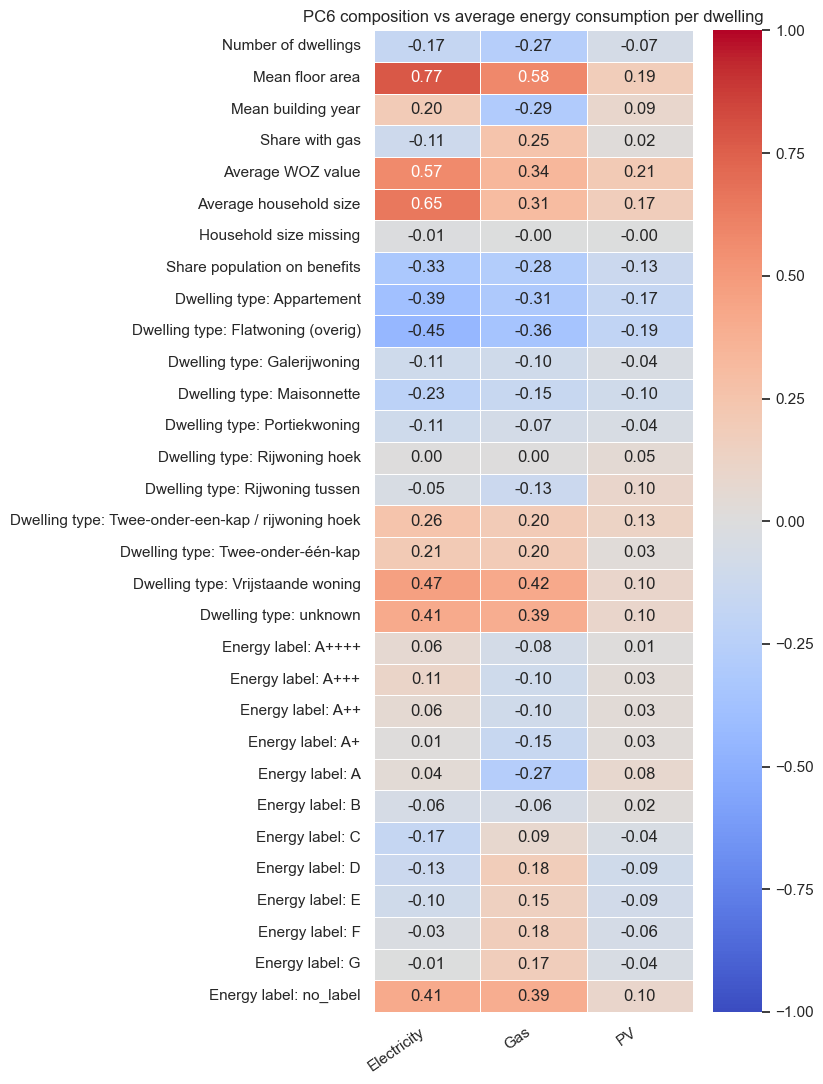

In [71]:
# ----------------------------
# 5.4B PC6 composition vs average energy
# ----------------------------

energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# add dwelling type shares
composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_dwelling_type_")
]

# add energy label shares
composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_energy_label_")
]

# compute correlation block
corr_block = (
    pc6_analysis[composition_vars + energy_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_vars]
)

# readable labels
row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_block_plot = corr_block.rename(index=row_label_map)

corr_block_plot.index = (
    corr_block_plot.index
    .str.replace("share_dwelling_type_", "Dwelling type: ", regex=False)
    .str.replace("share_energy_label_", "Energy label: ", regex=False)
)

corr_block_plot = corr_block_plot.rename(columns={
    "kwh_avg_per_dwelling_pc6": "Electricity",
    "gas_avg_per_dwelling_pc6": "Gas",
    "pv_avg_per_dwelling_pc6": "PV"
})

plt.figure(figsize=(8, 11))

ax = sns.heatmap(
    corr_block_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("PC6 composition vs average energy consumption per dwelling")
plt.tight_layout()
plt.show()

### Interpretation of Association between PC6 composition and average energy

The correlation matrix highlights how PC6 composition relates to average energy consumption per dwelling.

**Postcode size**

- `n_dwellings` shows weak correlations (electricity: -0.17, gas: -0.27), indicating that average energy largely removes the mechanical size effect.
- Larger postcode areas tend to have slightly lower consumption per dwelling, consistent with denser urban areas.

**Structural characteristics**

- `mean_floor_area` is the strongest driver (electricity: 0.77, gas: 0.58), indicating that larger dwellings consume more energy per unit.
- `mean_building_year` is negatively related to gas (-0.29), suggesting newer buildings rely less on gas.
- `share_has_gas` is positively related to gas consumption (0.25), reflecting heating system dependence.

**Socioeconomic characteristics**

- `avg_woz_value` (0.57 electricity, 0.34 gas) and `avg_household_size` (0.65 electricity, 0.31 gas) show strong positive associations with energy use.
- `share_population_on_benefits` is negatively related to energy (-0.33 electricity, -0.28 gas), indicating lower consumption in lower-income areas.
- The missing indicator has near-zero correlations, confirming its purely technical role.

**Dwelling type composition**

- High-density housing (e.g. apartments: -0.39 electricity, -0.31 gas) is associated with lower energy use.
- Low-density housing (e.g. detached: 0.47 electricity, 0.42 gas) is associated with higher energy use.
- This confirms that housing typology is a key determinant of energy intensity.

**Energy labels and PV**

- Energy label shares show relatively weak and mixed relationships.
- PV correlations are generally small, indicating weaker structural dependence.

**Conclusion**

Average energy consumption per dwelling is primarily driven by dwelling size, housing type, and household composition. Socioeconomic factors contribute, but less strongly. The weak correlation with postcode size confirms that average energy successfully captures structural variation rather than scale effects.

### 6.4.2 Breusch-Pagan (BP) test

The **Breusch-Pagan test** is used to detect whether the variance of regression residuals depends on the explanatory variables. It tests the key OLS assumption of **homoskedasticity**:

$$
Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
$$

where $X_1, X_2, \dots, X_k$ are all predictor variables in the model. If this assumption fails, standard errors computed by conventional OLS may be biased, which affects t-values, p-values, and confidence intervals.

The test is applied to the **preferred log-log specification**, estimated on the full dataset using the correctly specified set of explanatory variables (including logarithmic floor area and excluding redundant compositional categories).

#### Hypotheses

- **Null hypothesis ($H_0$):** Residual variance is constant across observations  
  $$
  H_0: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
  $$

- **Alternative hypothesis ($H_1$):** Residual variance depends on one or more predictors  
  $$
  H_1: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = f(X_1, X_2, \dots, X_k)
  $$

#### Breusch-Pagan statistics

1. **Lagrange Multiplier (LM) statistic:**  
   - Measures the overall deviation from constant variance by regressing squared residuals on all predictors.  
   - Large LM values indicate stronger evidence against $H_0$.

2. **LM p-value:**  
   - Probability of observing an LM statistic as extreme as the one calculated, **assuming $H_0$ is true**.  
   - A small LM p-value (e.g., < 0.05) indicates that residual variance likely depends on the predictors.

3. **F-value:**  
   - Obtained by running an auxiliary F-test using the same regression of squared residuals on predictors.  
   - Conceptually, it is another way to measure how strongly residual variance is explained by the predictors.  
   - Larger F-values signal stronger evidence of heteroskedasticity.

4. **F p-value:**  
   - Probability of observing the F-value under $H_0$.  
   - A small F p-value also indicates heteroskedasticity.

#### How to interpret

1. If **LM p-value or F p-value is very small**, we reject the null of homoskedasticity.  
2. This suggests that conventional OLS standard errors may be **underestimated or overestimated**, meaning t-values and confidence intervals could be misleading.  
3. In such a situation, heteroskedasticity-robust standard errors (HC3) are recommended to obtain **reliable inference** in the preferred regression model.

In [72]:
# ----------------------------
# 6.4.2 Breusch-Pagan test
# ----------------------------

from statsmodels.stats.diagnostic import het_breuschpagan

# Use residuals and predictors from preferred log-log model
residuals_pref = model_loglog.resid
exog_pref = model_loglog.model.exog

# Run Breusch-Pagan test
bp_test = het_breuschpagan(residuals_pref, exog_pref)

# Create a tidy DataFrame with LM and F statistics
bp_results = pd.DataFrame({
    "Statistic": [
        "Lagrange multiplier",
        "LM p-value",
        "F-value",
        "F p-value"
    ],
    "Value": bp_test
})

# Round for readability
bp_results["Value"] = bp_results["Value"].round(6)

# Display results
display(bp_results)

,Statistic,Value
0,Lagrange multiplier,16202.980532
1,LM p-value,0.000000
2,F-value,621.478163
3,F p-value,0.000000


### 6.4.2 Breusch-Pagan (BP) Test Interpretation

The Breusch-Pagan test evaluates whether the variance of residuals in the preferred log-log model depends on the explanatory variables. This directly tests the OLS assumption of homoskedasticity.

**BP test results:**

| Statistic               | Value      |
|------------------------|-----------|
| Lagrange multiplier    | 16202.98  |
| LM p-value             | 0.0000    |
| F-value                | 621.48    |
| F p-value              | 0.0000    |

#### Interpretation

1. **Strong rejection of homoskedasticity**

- The **LM p-value = 0.0000** and **F p-value = 0.0000** provide overwhelming evidence against the null hypothesis of constant residual variance.  
- This indicates that the variance of the residuals is systematically related to one or more explanatory variables in the model.

2. **Presence of heteroskedasticity**

- The very large values of the LM statistic and F-value indicate that heteroskedasticity is not a marginal issue, but a strong and systematic feature of the data.  
- This is consistent with earlier residual diagnostics, where variation in residual spread was observed across different levels of fitted electricity consumption.

3. **Implications for inference**

- Under heteroskedasticity, conventional OLS standard errors are no longer reliable.  
- As a result, t-statistics, p-values, and confidence intervals based on standard OLS assumptions may be misleading.  
- In particular, statistical significance may be overstated if standard errors are underestimated.

4. **Recommended correction**

- To obtain valid statistical inference, **heteroskedasticity-robust standard errors (HC3)** should be used.  
- These adjust the estimated standard errors without changing the coefficient estimates themselves, ensuring that inference remains reliable even when residual variance is not constant.

#### Conclusion

The Breusch-Pagan test confirms that heteroskedasticity is present in the preferred regression model. While this does not affect the consistency of coefficient estimates, it necessitates the use of robust standard errors for correct statistical inference. Consequently, all subsequent interpretation of coefficient significance is based on HC3-adjusted results.

### 6.4.3 HC3 Robust Standard Errors

HC3 robust standard errors are used to provide valid inference when residual variance is not constant (heteroskedasticity). They allow us to identify which predictors remain statistically reliable even when conventional OLS assumptions are violated.

Key points:

- Coefficients remain **unchanged**; only standard errors (SE), z-values, p-values, and confidence intervals are adjusted.  
- **z-values** replace OLS t-values under HC3:

$$
z_j = \frac{\hat{\beta}_j}{SE_j^{HC3}}
$$

- **SE increase:** If residual variance is not constant, HC3 SE will typically be larger than conventional OLS SE.  
- **Adjusted p-values:** Larger SEs yield more conservative p-values, ensuring reliable inference.

#### HC3 statistics explanation

1. **coef:** Estimated coefficient from the OLS regression (unchanged under HC3).  
2. **SE (OLS):** Standard error assuming homoskedasticity.  
3. **t-value (OLS):** OLS t-value (coef divided by SE).  
4. **SE (HC3):** Heteroskedasticity-robust standard error.  
5. **z-value (HC3):** Robust z-value (coef divided by SE_HC3), used to assess significance under heteroskedasticity.  
6. **p-values:** Probability of observing a coefficient as extreme as the one estimated under the null hypothesis. HC3 adjusts them to account for heteroskedasticity.

#### Why use HC3?

- Conventional OLS assumes constant residual variance. If this assumption is violated, standard errors may be underestimated, making coefficients appear more statistically significant than they really are.  
- HC3 adjusts the standard errors to provide **reliable inference** without changing the coefficient estimates themselves.  
- Particularly relevant after detecting heteroskedasticity with the Breusch-Pagan test (Section 6.4.2).

#### HC3 example:

| Variable | coef | SE (OLS) | z/t (OLS) | SE (HC3) | z (HC3) |
|----------|------|-----------|-----------|----------|---------|
| share_energy_label_B | -0.3233 | 0.0105 | -30.73 | 0.0158 | -20.51 |

In [73]:
# ----------------------------
# 6.4.3 HC3 robust standard errors
# ----------------------------

# Re-estimate the preferred log-log model with HC3 robust SE
model_loglog_robust = sm.OLS(y_loglog, X_loglog).fit(cov_type="HC3")

# Show full summary (optional)
print(model_loglog_robust.summary())

# Compare OLS vs HC3 SE and p-values
coef_comparison_hc3 = pd.DataFrame({
    "coef_OLS": model_loglog.params,
    "se_OLS": model_loglog.bse,
    "pval_OLS": model_loglog.pvalues,
    "coef_HC3": model_loglog_robust.params,
    "se_HC3": model_loglog_robust.bse,
    "pval_HC3": model_loglog_robust.pvalues
})

# Round numbers for readability
coef_comparison_hc3 = coef_comparison_hc3.round({
    "coef_OLS": 4,
    "se_OLS": 4,
    "coef_HC3": 4,
    "se_HC3": 4,
    "pval_OLS": 6,
    "pval_HC3": 6
})

# Optional: sort by HC3 SE descending
coef_comparison_hc3 = coef_comparison_hc3.sort_values("se_HC3", ascending=False)

display(coef_comparison_hc3)

                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.720
Model:                                  OLS   Adj. R-squared:                  0.720
Method:                       Least Squares   F-statistic:                 1.880e+04
Date:                      Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                              04:20:32   Log-Likelihood:                 89214.
No. Observations:                    234882   AIC:                        -1.784e+05
Df Residuals:                        234853   BIC:                        -1.781e+05
Df Model:                                28                                         
Covariance Type:                        HC3                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

,coef_OLS,se_OLS,pval_OLS,coef_HC3,se_HC3,pval_HC3
share_energy_label_no_label,-0.0068,0.0242,0.777375,-0.0068,0.0427,0.872546
share_dwelling_type_unknown,-0.0194,0.0233,0.404848,-0.0194,0.0418,0.642800
const,4.3554,0.0336,0.000000,4.3554,0.0406,0.000000
share_energy_label_A++++,-0.0955,0.0129,0.000000,-0.0955,0.0194,0.000001
share_energy_label_A++,-0.1164,0.0117,0.000000,-0.1164,0.0185,0.000000
share_energy_label_A+++,0.0149,0.0097,0.122858,0.0149,0.0133,0.263124
share_energy_label_F,-0.0225,0.0099,0.023403,-0.0225,0.0128,0.079491
share_dwelling_type_Portiekwoning,-0.0509,0.0113,0.000007,-0.0509,0.0126,0.000054
share_energy_label_A+,-0.2975,0.0090,0.000000,-0.2975,0.0114,0.000000
share_energy_label_E,-0.0360,0.0079,0.000005,-0.0360,0.0104,0.000514


### 6.4.3 Interpretation of HC3 Robust Estimation Results

This section compares the results of the **preferred log-log model** using standard OLS versus **HC3 robust standard errors**. The HC3 adjustment ensures that inference remains valid in the presence of heteroskedasticity.

#### 1. Stability of point estimates

The **coefficients (coef)** are identical between OLS and HC3 for all variables.  
- For example, `log_mean_floor_area = 0.4108` and `share_energy_label_B = -0.1858` remain unchanged.  

This confirms that heteroskedasticity affects the **uncertainty** of the estimates, but not the **estimated relationships themselves**.

#### 2. Standard error inflation and inference reliability

- Standard errors increase consistently across variables under HC3.  
- Typical increases range from **20% to 80%**, depending on the variable.  
  - `share_energy_label_no_label`: SE increases from 0.0242 → 0.0427  
  - `share_dwelling_type_unknown`: SE increases from 0.0233 → 0.0418  
  - `share_energy_label_A++++`: SE increases from 0.0129 → 0.0194  
  - `log_mean_floor_area`: SE increases from 0.0019 → 0.0023  

- These increases reflect the strong heteroskedasticity identified in Section 6.4.2.  
- As a result, HC3 provides **more conservative and reliable inference**.

#### 3. Changes in statistical significance

The HC3 adjustment reveals which variables are robust and which are sensitive to heteroskedasticity:

- **Remain strongly significant ($p < 0.001$):**  
  - Structural variables: `log_mean_floor_area`, `mean_building_year`, `share_has_gas`  
  - Socioeconomic variables: `avg_household_size_filled`, `avg_woz_value_filled`  
  - Most energy labels: A, A+, A++, A++++, B, C, D  
  - Most dwelling types  

- **Lose statistical significance under HC3:**  
  - `share_energy_label_F`: p-value increases from 0.023 → 0.079  
  - `share_energy_label_A+++`: p-value increases from 0.123 → 0.263  
  - `share_dwelling_type_Galerijwoning`: p-value increases from 0.077 → 0.177  

- **Remain non-significant:**  
  - `share_energy_label_no_label`  
  - `share_dwelling_type_unknown`  

This shows that HC3 primarily affects **borderline variables**, while core predictors remain stable.

#### 4. Interpretation of key drivers

The main drivers of electricity consumption remain robust after correcting for heteroskedasticity:

- **Floor area elasticity:**  
  `log_mean_floor_area = 0.4108`  
  → A 1% increase in average floor area is associated with a ~0.41% increase in electricity consumption per dwelling.

- **Gas connection:**  
  `share_has_gas = -0.1278`  
  → A 10 percentage point increase in gas-connected dwellings is associated with ~1.28% lower electricity consumption.

- **Household size:**  
  `avg_household_size_filled = 0.1589`  
  → Larger households are strongly associated with higher electricity demand.

- **Energy labels:**  
  Most energy labels remain negative and statistically significant, indicating that more efficient dwelling stocks are associated with lower electricity consumption relative to the reference category.

#### 5. Confidence intervals under HC3

For each coefficient $j$:

$$
CI_j = \hat{\beta}_j \pm 1.96 \cdot SE_j^{HC3}
$$

These intervals reflect **conservative uncertainty estimates**, accounting for the presence of heteroskedasticity in the data.

#### Conclusion

- The HC3 correction confirms the **robustness of the main relationships** identified in the regression model.  
- While standard errors increase, the **overall structure of the model remains stable**.  
- Only a small number of borderline variables lose statistical significance.  
- Consequently, all subsequent inference is based on **HC3-adjusted standard errors**, ensuring reliable statistical conclusions despite heteroskedasticity.

### 7 Feature Importance Analysis

The regression analysis in Chapter 6 identified the preferred specification and evaluated its robustness, predictive performance, and nonlinear benchmark. However, coefficient estimates alone do not provide a complete picture of which predictors are most influential across different modelling frameworks.

This chapter therefore examines **feature importance** using multiple complementary methods. The purpose is not only to rank predictors, but also to assess whether the main substantive variables of interest remain important across linear, regularized, and nonlinear models.

The analysis focuses on four approaches:

1. **Standardized OLS coefficients** from the preferred log-log regression model  
2. **LASSO regression**, which performs feature selection through L1 regularization  
3. **Elastic Net regression**, which combines L1 and L2 regularization and is better suited to correlated predictors  
4. **Random Forest feature importance**, based on impurity reduction  

An additional importance measure, **permutation importance**, may also be used for the Random Forest benchmark to complement impurity-based importance.

These methods capture different notions of importance:

- **Standardized OLS coefficients** reflect the size and direction of marginal associations in the preferred interpretable regression model  
- **LASSO** highlights predictors that remain useful when weak variables are shrunk toward zero  
- **Elastic Net** provides a more stable ranking when predictors are correlated  
- **Random Forest importance** captures nonlinear and interaction-based predictive relevance  

This distinction is important in the present dataset because several predictors are correlated, especially the compositional variables such as dwelling-type shares and energy-label shares. As a result, feature importance should be interpreted cautiously, particularly for individual categories within the same group.

Throughout this chapter, consistency with Chapter 6 is maintained:

- The dependent variable remains the logarithm of `kwh_avg_per_dwelling_pc6`  
- The preferred predictor set remains the one used in the preferred log-log specification  
- The same filtered dataset is used, i.e. only postcode areas with positive average electricity consumption (`kwh_avg_per_dwelling_pc6 > 0`) are included  

The goal is to identify which variables emerge as consistently important across methods, while distinguishing between:

- **non-control variables of substantive interest**: `share_has_gas` and energy-label shares  
- **control variables**: floor area, construction year, dwelling-type shares, and CBS socioeconomic variables  

A final comparison section will summarize whether the main conclusions from Chapter 6 are supported by these alternative feature-importance approaches.

### 7.1 Standardized OLS Coefficients

The first feature-importance measure is based on the preferred log-log regression model from Chapter 6. Because the raw coefficients are expressed in different units across predictors, they are not directly comparable in magnitude.

To obtain a common scale, the predictors and dependent variable are standardized before estimating the same log-log specification. The resulting coefficients can then be interpreted as **standardized OLS coefficients** (beta coefficients).

A standardized coefficient measures the expected change in the dependent variable, in standard deviations, associated with a one-standard-deviation increase in the predictor, holding all other variables constant.

This approach provides a useful baseline because:

- it remains directly linked to the preferred regression framework  
- it preserves coefficient sign and interpretability  
- it allows comparison of relative variable importance within a linear specification  

The standardized OLS coefficients should still be interpreted with caution in the presence of multicollinearity, but they provide a natural benchmark before moving to regularized and nonlinear methods.

In [ ]:
# ----------------------------
# 7.1 Standardized OLS coefficients
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.preprocessing import StandardScaler

# Use EXACT same data as preferred model
X_std_source = X_loglog.copy()
y_std_source = y_loglog.copy()

# ----------------------------
# Standardize X
# ----------------------------
scaler_X = StandardScaler()
X_std = pd.DataFrame(
    scaler_X.fit_transform(X_std_source),
    columns=X_std_source.columns,
    index=X_std_source.index
)

# ----------------------------
# Standardize y
# ----------------------------
scaler_y = StandardScaler()
y_std = pd.Series(
    scaler_y.fit_transform(y_std_source.to_frame()).ravel(),
    index=y_std_source.index,
    name="log_kwh_avg_per_dwelling_pc6_std"
)

# ----------------------------
# Fit standardized OLS
# ----------------------------
model_loglog_std = sm.OLS(
    y_std,
    sm.add_constant(X_std, has_constant="add")
).fit()

# ----------------------------
# Build coefficient table
# ----------------------------
std_coef_table = pd.DataFrame({
    "Variable": model_loglog_std.params.index,
    "Std_Coefficient": model_loglog_std.params.values,
    "Std_Error": model_loglog_std.bse.values,
    "p_value": model_loglog_std.pvalues.values
})

# Remove intercept
std_coef_table = std_coef_table[
    std_coef_table["Variable"] != "const"
].copy()

# Rank by importance
std_coef_table["Abs_Std_Coefficient"] = std_coef_table["Std_Coefficient"].abs()
std_coef_table = std_coef_table.sort_values(
    "Abs_Std_Coefficient", ascending=False
).reset_index(drop=True)

display(std_coef_table)

,Variable,Std_Coefficient,Std_Error,p_value,Abs_Std_Coefficient
0,log_mean_floor_area,0.456314,0.002091,0.000000e+00,0.456314
1,avg_household_size_filled,0.319766,0.001562,0.000000e+00,0.319766
2,share_energy_label_A,-0.198735,0.005731,8.746581e-263,0.198735
3,share_energy_label_C,-0.114379,0.004384,7.364728e-150,0.114379
4,share_has_gas,-0.109499,0.001217,0.000000e+00,0.109499
5,share_dwelling_type_Vrijstaande woning,0.104565,0.001646,0.000000e+00,0.104565
6,share_energy_label_B,-0.096734,0.003573,3.368886e-161,0.096734
7,avg_household_size_missing,0.089292,0.001227,0.000000e+00,0.089292
8,avg_woz_value_filled,0.086869,0.001482,0.000000e+00,0.086869
9,share_energy_label_A+,-0.056279,0.001693,1.246461e-241,0.056279


### 7.1 Interpretation of Standardized OLS Coefficients

The standardized OLS coefficients provide a ranking of predictors based on their relative contribution within the preferred log-log regression model. Because all variables are expressed in standard deviation units, coefficients can be compared directly in magnitude.

**Key findings:**

1. **Structural and household variables dominate the variation**

The largest standardized coefficient is observed for `log_mean_floor_area` (0.456), followed by `avg_household_size_filled` (0.320) and `share_energy_label_A` (−0.199).

This indicates that most of the variation in electricity demand across postcode areas is explained by **dwelling size, household composition, and energy efficiency of the housing stock**. These variables capture baseline differences in consumption levels across areas.

2. **Energy-label composition is highly relevant**

Several energy-label variables appear among the most important predictors (e.g., A, C, B categories), all with negative coefficients.

This suggests that more efficient dwelling stocks are associated with lower electricity demand. In contrast to the previous specification, their magnitude is now **comparable to key structural variables**, indicating that energy-label composition plays a more prominent role in explaining variation.

3. **Gas connectivity has a clear but moderate effect**

The variable `share_has_gas` (−0.109) shows a consistent negative association with electricity demand.

While economically intuitive, its importance is **moderate relative to variables such as floor area, household size, and energy-label composition**, suggesting that gas connectivity explains part of the variation, but not a dominant share.

4. **Dwelling-type effects are limited once controls are included**

Dwelling-type shares generally have smaller standardized coefficients, with the exception of `share_dwelling_type_Vrijstaande woning` (0.105), which reflects higher consumption in detached housing.

Overall, once floor area, household composition, and energy efficiency are accounted for, dwelling type itself adds relatively limited additional explanatory power.

5. **Interpretation of compositional variables**

Energy-label and dwelling-type variables are compositional shares, meaning that their effects are relative to an omitted reference category and are partially interdependent.

As a result, individual coefficients should not be interpreted in isolation; instead, the overall pattern across categories is more informative.

6. **Overall assessment**

The standardized OLS results confirm that the main variation in electricity demand is driven by structural characteristics and household composition, with energy efficiency playing a stronger role than previously observed.

The variables of interest — gas connectivity and energy-label composition — are statistically significant and contribute to the model, with energy-label composition now representing a more substantial component of the explanation.

**Conclusion**

Feature importance based on standardized OLS coefficients suggests that electricity demand at the postcode level is primarily shaped by dwelling size, household composition, and energy efficiency. Compared to the previous specification, housing composition variables, particularly energy-label shares, play a more prominent role in explaining variation. This provides a baseline for comparison with regularized and nonlinear models in the following sections.

### 7.2 LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) is used as the first regularization-based importance method. LASSO adds an L1 penalty to the regression objective, shrinking weak coefficients toward zero:

$$
\min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}
$$

where $\lambda$ controls the strength of regularization.

This method is useful for feature importance because:

- it reduces overfitting  
- it performs automatic variable selection  
- it highlights which predictors retain predictive value after penalization  

In the present context, LASSO is especially relevant because the dataset contains correlated predictors, including compositional shares. However, a known limitation is that LASSO may select one variable from a correlated group while shrinking others to zero, even if the omitted variables are also relevant.

For this reason, LASSO results will be interpreted as an indicator of sparse predictive importance rather than definitive evidence that zeroed variables are unimportant in a substantive sense.

As with the standardized OLS analysis, the same filtered dataset and preferred log-log predictor set are used.

In [ ]:
# ----------------------------
# 7.2 LASSO regression
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ----------------------------
# Use same predictors and target as preferred log-log model
# ----------------------------

X_lasso = X_loglog.copy()
y_lasso = y_loglog.copy()

# ----------------------------
# Standardize predictors and estimate LASSO with cross-validation
# ----------------------------

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=10,
        random_state=42,
        max_iter=20000,
        n_jobs=-1
    ))
])

lasso_pipeline.fit(X_lasso, y_lasso)

# ----------------------------
# Extract fitted LASSO model
# ----------------------------

lasso_model = lasso_pipeline.named_steps["lasso"]

# ----------------------------
# Create coefficient table
# ----------------------------

lasso_coef_table = pd.DataFrame({
    "Variable": X_lasso.columns,
    "LASSO_Coefficient": lasso_model.coef_
})

lasso_coef_table["Abs_LASSO_Coefficient"] = lasso_coef_table["LASSO_Coefficient"].abs()
lasso_coef_table["Selected"] = lasso_coef_table["LASSO_Coefficient"] != 0

lasso_coef_table = lasso_coef_table.sort_values(
    "Abs_LASSO_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Best alpha selected by LASSO:", lasso_model.alpha_)
print("Number of selected variables:", lasso_coef_table["Selected"].sum())
print("Number of variables shrunk to zero:", (~lasso_coef_table["Selected"]).sum())

display(lasso_coef_table)

Best alpha selected by LASSO: 0.0002464231726042363
Number of selected variables: 26
Number of variables shrunk to zero: 3


,Variable,LASSO_Coefficient,Abs_LASSO_Coefficient,Selected
0,log_mean_floor_area,0.143172,0.143172,True
1,avg_household_size_filled,0.099974,0.099974,True
2,share_energy_label_A,-0.051498,0.051498,True
3,share_has_gas,-0.033915,0.033915,True
4,share_dwelling_type_Vrijstaande woning,0.032036,0.032036,True
5,share_energy_label_C,-0.027885,0.027885,True
6,avg_household_size_missing,0.027685,0.027685,True
7,avg_woz_value_filled,0.026866,0.026866,True
8,share_energy_label_B,-0.023854,0.023854,True
9,mean_building_year,0.015318,0.015318,True


### Interpretation of LASSO Results

The LASSO regression applies L1 regularization, shrinking coefficients toward zero and allowing for variable selection. The optimal regularization parameter selected via cross-validation is:

- **alpha ≈ 0.000246**

This is a relatively small value, indicating that only mild regularization is applied.

**Key findings:**

1. **Limited variable selection**

Most variables retain non-zero coefficients. In total, **26 variables are selected**, while **3 variables are shrunk to zero**.

The variables shrunk to zero are:

- `const`
- `share_dwelling_type_unknown`
- `share_energy_label_E`

This indicates that most predictors contribute some predictive information, while only a small number of variables add little value once regularization is introduced.

2. **Structural and household variables remain the most important**

The largest coefficients are:

- `log_mean_floor_area`
- `avg_household_size_filled`

This is consistent with the standardized OLS results and confirms that dwelling size and household composition explain a large share of the variation in electricity demand.

3. **Energy-label composition and gas remain relevant**

The variables of interest remain selected with non-zero coefficients:

- energy-label shares, especially A, C, B, and A+
- `share_has_gas`

Their signs are broadly consistent with previous results. Energy-label variables retain an important role, while `share_has_gas` remains negatively associated with electricity consumption.

4. **Coefficient shrinkage reduces magnitudes**

Compared to standardized OLS, LASSO reduces the magnitude of coefficients across all variables. Larger coefficients are shrunk, while smaller ones are pushed closer to zero or set exactly to zero.

This reflects the regularization penalty and reduces sensitivity to multicollinearity.

5. **Overall assessment**

The LASSO results are broadly consistent with the standardized OLS findings:

- structural and household variables remain dominant  
- energy-label composition remains important  
- gas connectivity remains relevant  
- most variables retain some predictive role  

The absence of strong variable selection suggests that electricity demand is influenced by multiple factors rather than a small number of dominant predictors.

**Conclusion**

LASSO does not substantially simplify the model, as most variables remain included. Instead, it confirms that predictive information is distributed across many variables. This provides a useful comparison point for the Elastic Net and Random Forest results in the following sections.

### 7.3 Elastic Net Regression

Elastic Net is a regularized regression method that combines the properties of **LASSO (L1)** and **Ridge (L2)** regression. It is particularly useful in settings where predictors are correlated, as is the case in this dataset due to compositional variables such as energy-label shares and dwelling-type shares.

The Elastic Net estimator solves the following optimization problem:

$$
\min_{\beta} \left\{ \frac{1}{n} \sum_{i=1}^{n} (y_i - X_i \beta)^2 
+ \lambda \left[ \alpha \sum_j |\beta_j| + (1 - \alpha) \sum_j \beta_j^2 \right] \right\}
$$

where:

- $y_i$ is the dependent variable, the logarithm of average electricity consumption per dwelling  
- $X_i$ are the explanatory variables  
- $\beta_j$ are the regression coefficients  
- $\lambda$ controls the overall strength of regularization  
- $\alpha \in [0,1]$ controls the balance between L1 and L2 penalties  

Special cases:

- $\alpha = 1$ → LASSO (pure L1 penalty)  
- $\alpha = 0$ → Ridge regression (pure L2 penalty)  

**Why Elastic Net is used in this analysis:**

- The dataset contains **correlated predictors**, especially compositional variables (shares that sum to one)  
- LASSO may arbitrarily select one variable from a correlated group and discard others  
- Elastic Net mitigates this by **retaining groups of correlated variables together**, leading to more stable coefficient estimates  

**Standardization:**

Before estimation, all predictors are standardized to zero mean and unit variance. This ensures that the penalty treats all variables equally and allows coefficients to be compared in magnitude.

**Model selection:**

The hyperparameters $\lambda$ (regularization strength) and $\alpha$ (penalty mixing parameter) are selected using cross-validation. A grid of candidate $\alpha$ values is evaluated, and the combination that minimizes the cross-validated mean squared error is chosen.

**Interpretation:**

Elastic Net coefficients reflect the relative contribution of predictors under regularization. As in LASSO, coefficients are shrunk toward zero, but unlike LASSO, correlated variables tend to be retained together rather than being excluded individually.

This makes Elastic Net particularly suitable for assessing feature importance in the presence of multicollinearity.

In [ ]:
# ----------------------------
# 7.3 Elastic Net Feature Importance
# ----------------------------

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler


# Use same data as previous sections
X_enet = X_loglog.copy()
y_enet = y_loglog.copy()

# Standardize predictors
scaler = StandardScaler()
X_enet_scaled = scaler.fit_transform(X_enet)

# Fit Elastic Net with cross-validation
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

enet_cv.fit(X_enet_scaled, y_enet)

# Extract coefficients
enet_coefs = pd.Series(enet_cv.coef_, index=X_enet.columns)

enet_results = pd.DataFrame({
    "Variable": enet_coefs.index,
    "ElasticNet_Coefficient": enet_coefs.values,
    "Abs_ElasticNet_Coefficient": np.abs(enet_coefs.values),
    "Selected": enet_coefs.values != 0
})

enet_results = enet_results.sort_values(
    "Abs_ElasticNet_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Best alpha:", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)
print("Number of selected variables:", enet_results["Selected"].sum())

display(enet_results)

Best alpha: 0.00027380352511581805
Best l1_ratio: 0.9
Number of selected variables: 26


,Variable,ElasticNet_Coefficient,Abs_ElasticNet_Coefficient,Selected
0,log_mean_floor_area,0.143161,0.143161,True
1,avg_household_size_filled,0.099971,0.099971,True
2,share_energy_label_A,-0.051476,0.051476,True
3,share_has_gas,-0.033914,0.033914,True
4,share_dwelling_type_Vrijstaande woning,0.032040,0.032040,True
5,share_energy_label_C,-0.027870,0.027870,True
6,avg_household_size_missing,0.027684,0.027684,True
7,avg_woz_value_filled,0.026870,0.026870,True
8,share_energy_label_B,-0.023842,0.023842,True
9,mean_building_year,0.015316,0.015316,True


### Interpretation of Elastic Net Results

The Elastic Net regression combines L1 and L2 regularization and is designed to provide more stable coefficient estimates when predictors are correlated. The optimal parameters selected by cross-validation are:

- **alpha ≈ 0.000274**
- **l1_ratio = 0.9**

The value of `l1_ratio = 0.9` indicates that the preferred Elastic Net specification is close to a LASSO model, with only a limited Ridge component.

**Key findings:**

1. **Results are very similar to LASSO**

The Elastic Net coefficients are almost identical in ranking and magnitude to the LASSO results. This suggests that adding a small L2 penalty does not materially change the feature-importance structure.

2. **Limited variable elimination**

A total of **26 variables are retained**, while **3 variables are shrunk to zero**:

- `const`
- `share_dwelling_type_unknown`
- `share_energy_label_E`

This indicates that predictive information remains distributed across many variables, rather than being concentrated in a small subset.

3. **Structural and household variables remain dominant**

The largest coefficients are:

- `log_mean_floor_area`
- `avg_household_size_filled`

This is fully consistent with both standardized OLS and LASSO, confirming that dwelling size and household composition explain most of the variation in electricity demand.

4. **Energy-label composition and gas remain important**

The variables of substantive interest remain clearly present with non-zero coefficients:

- energy-label shares, especially A, C, B, and A+  
- `share_has_gas`  

Their coefficients are smaller than those of the main structural variables but still meaningful, indicating that they contribute to the model without dominating it.

5. **Coefficient shrinkage and stability**

As in LASSO, coefficients are shrunk toward zero, reducing sensitivity to multicollinearity. However, unlike pure LASSO, Elastic Net tends to retain correlated variables together, which leads to more stable coefficient patterns.

6. **Limited additional benefit relative to LASSO**

Because the Elastic Net results are nearly identical to LASSO, there is limited evidence that the additional Ridge component materially changes the allocation of importance across correlated predictors in this dataset.

**Conclusion**

The Elastic Net results confirm the conclusions from LASSO. Structural and household variables remain the main drivers of electricity demand, while energy-label composition and gas connectivity contribute additional but smaller effects. The similarity between LASSO and Elastic Net indicates that the overall feature-importance structure is robust to the choice of regularization method.

### 7.4 Extension: electricity consumption as an explanatory variable

The main gas regression model explains gas consumption using housing structure, dwelling composition, energy labels, gas availability, and socioeconomic variables. As an extension, average electricity consumption per dwelling is added as an explanatory variable.

The purpose of this extension is predictive rather than causal. Electricity consumption may capture unobserved household behaviour, appliance intensity, occupancy patterns, or broader energy-use intensity that is not fully represented by the housing and socioeconomic variables.

However, electricity and gas consumption are jointly determined energy outcomes. Therefore, the electricity coefficient should not be interpreted as a causal effect of electricity consumption on gas consumption. Instead, it is interpreted as a conditional association and as a test of whether electricity demand provides additional predictive information for gas demand.

The same gas threshold used in the robustness check is applied here to ensure consistency.

In [ ]:
# ----------------------------
# 7.4 Gas model extension: electricity as an explanatory variable
# ----------------------------

gas_threshold_ext = 440

reg_data_gas_ext = pc6_analysis[
    (pc6_analysis["gas_avg_per_dwelling_pc6"] > gas_threshold_ext) &
    (pc6_analysis["kwh_avg_per_dwelling_pc6"] > 0)
].copy()

print("Gas threshold:", gas_threshold_ext)
print("Observations:", len(reg_data_gas_ext))
display(reg_data_gas_ext["gas_avg_per_dwelling_pc6"].describe())

# ----------------------------
# Dependent variables
# ----------------------------

y_gas_ext_linear = reg_data_gas_ext["gas_avg_per_dwelling_pc6"]
y_gas_ext_log = np.log(reg_data_gas_ext["gas_avg_per_dwelling_pc6"])

# ----------------------------
# Identify compositional variables
# ----------------------------

dwelling_cols_full_ext = [
    c for c in reg_data_gas_ext.columns
    if c.startswith("share_dwelling_type_")
]

label_cols_full_ext = [
    c for c in reg_data_gas_ext.columns
    if c.startswith("share_energy_label_")
]

# ----------------------------
# Reference categories
# ----------------------------

ref_dwelling_ext = "share_dwelling_type_Appartement"
ref_label_ext = "share_energy_label_G"

dwelling_cols_ext = [
    c for c in dwelling_cols_full_ext
    if c != ref_dwelling_ext
]

label_cols_ext = [
    c for c in label_cols_full_ext
    if c != ref_label_ext
]

# ----------------------------
# Explanatory variables
# ----------------------------

electricity_var_ext = [
    "kwh_avg_per_dwelling_pc6"
]

structural_vars_ext = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

cbs_vars_ext = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# Construct X matrix
# ----------------------------

X_gas_ext = reg_data_gas_ext[
    electricity_var_ext
    + structural_vars_ext
    + dwelling_cols_ext
    + label_cols_ext
    + cbs_vars_ext
].copy()

X_gas_ext = sm.add_constant(X_gas_ext)

# ----------------------------
# Model 1: Linear gas model with electricity
# ----------------------------

model_gas_ext_linear = sm.OLS(
    y_gas_ext_linear,
    X_gas_ext
).fit()

print("Gas model with electricity: Linear specification")
print(model_gas_ext_linear.summary())

# ----------------------------
# Model 2: Log-level gas model with electricity
# ----------------------------

model_gas_ext_log = sm.OLS(
    y_gas_ext_log,
    X_gas_ext
).fit()

print("Gas model with electricity: Log-level specification")
print(model_gas_ext_log.summary())

# ----------------------------
# Model 3: Log-log gas model with electricity
# ----------------------------

X_gas_ext_loglog = X_gas_ext.copy()

X_gas_ext_loglog["log_mean_floor_area"] = np.log(
    X_gas_ext_loglog["mean_floor_area"]
)

X_gas_ext_loglog["log_kwh_avg_per_dwelling_pc6"] = np.log(
    X_gas_ext_loglog["kwh_avg_per_dwelling_pc6"]
)

X_gas_ext_loglog = X_gas_ext_loglog.drop(
    columns=[
        "mean_floor_area",
        "kwh_avg_per_dwelling_pc6"
    ]
)

model_gas_ext_loglog = sm.OLS(
    y_gas_ext_log,
    X_gas_ext_loglog
).fit()

print("Gas model with electricity: Log-log specification")
print(model_gas_ext_loglog.summary())

# ----------------------------
# Model comparison
# ----------------------------

comparison_gas_ext = pd.DataFrame({
    "Model": [
        "Linear + electricity",
        "Log-level + electricity",
        "Log-log + electricity"
    ],
    "Observations": [
        int(model_gas_ext_linear.nobs),
        int(model_gas_ext_log.nobs),
        int(model_gas_ext_loglog.nobs)
    ],
    "Adj_R2": [
        model_gas_ext_linear.rsquared_adj,
        model_gas_ext_log.rsquared_adj,
        model_gas_ext_loglog.rsquared_adj
    ],
    "AIC": [
        model_gas_ext_linear.aic,
        model_gas_ext_log.aic,
        model_gas_ext_loglog.aic
    ],
    "BIC": [
        model_gas_ext_linear.bic,
        model_gas_ext_log.bic,
        model_gas_ext_loglog.bic
    ],
    "Electricity_coefficient": [
        model_gas_ext_linear.params.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_log.params.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_loglog.params.get("log_kwh_avg_per_dwelling_pc6", np.nan)
    ],
    "Electricity_p_value": [
        model_gas_ext_linear.pvalues.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_log.pvalues.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_loglog.pvalues.get("log_kwh_avg_per_dwelling_pc6", np.nan)
    ]
})

comparison_gas_ext = comparison_gas_ext.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1,
    "Electricity_coefficient": 6,
    "Electricity_p_value": 6
})

print("Gas model comparison with electricity as explanatory variable:")
display(comparison_gas_ext)

Gas threshold: 440
Observations: 215228


count    215228.000000
mean        926.052187
std         292.279098
min         450.000000
25%         730.000000
50%         880.000000
75%        1050.000000
max        4690.000000
Name: gas_avg_per_dwelling_pc6, dtype: float64

Gas model with electricity: Linear specification
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.651
Model:                                  OLS   Adj. R-squared:                  0.651
Method:                       Least Squares   F-statistic:                 1.385e+04
Date:                      Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                              04:04:34   Log-Likelihood:            -1.4141e+06
No. Observations:                    215228   AIC:                         2.828e+06
Df Residuals:                        215198   BIC:                         2.829e+06
Df Model:                                29                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|  

,Model,Observations,Adj_R2,AIC,BIC,Electricity_coefficient,Electricity_p_value
0,Linear + electricity,215228,0.6511,2828221.8,2828530.1,0.028645,0.0
1,Log-level + electricity,215228,0.6341,-140799.6,-140491.2,0.000018,0.0
2,Log-log + electricity,215228,0.6414,-145159.2,-144850.8,0.046666,0.0
